PART 1.1 — IMPORT LIBRARIES

In [94]:
# ============================================================
# PART 1.1 — IMPORT LIBRARIES
# ============================================================

import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torchvision
import torchvision.transforms as transforms

from PIL import Image

import matplotlib.pyplot as plt


print("=" * 70)
print("PART 1.1 — IMPORT LIBRARIES")
print("=" * 70)

print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("PyTorch    :", torch.__version__)
print("Torchvision:", torchvision.__version__)

print("=" * 70)
print("IMPORTS COMPLETED")

PART 1.1 — IMPORT LIBRARIES
NumPy      : 2.5.1
Pandas     : 3.0.5
PyTorch    : 2.12.1+cu126
Torchvision: 0.27.1+cu126
IMPORTS COMPLETED


In [95]:
# ============================================================
# PART 1.2 — PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(
    r"D:\Tomato_Disease_Research"
)

PLANTVILLAGE_DIR = (
    PROJECT_DIR / "plantvillage"
)

PROCESSED_DATASET_DIR = (
    PROJECT_DIR / "processed_dataset"
)

SPLITS_DIR = (
    PROJECT_DIR / "splits"
)

MODELS_DIR = (
    PROJECT_DIR / "models"
)

CHECKPOINTS_DIR = (
    PROJECT_DIR / "checkpoints"
)

RESULTS_DIR = (
    PROJECT_DIR / "results"
)


print("=" * 70)
print("PART 1.2 — PROJECT PATHS")
print("=" * 70)

print("Project directory:")
print(PROJECT_DIR)

print()

print("PlantVillage directory:")
print(PLANTVILLAGE_DIR)

print()

print("Processed dataset directory:")
print(PROCESSED_DATASET_DIR)

print()

print("Splits directory:")
print(SPLITS_DIR)

print()

print("Models directory:")
print(MODELS_DIR)

print()

print("Checkpoints directory:")
print(CHECKPOINTS_DIR)

print()

print("Results directory:")
print(RESULTS_DIR)

print("=" * 70)
print("PROJECT PATHS CONFIGURED")

PART 1.2 — PROJECT PATHS
Project directory:
D:\Tomato_Disease_Research

PlantVillage directory:
D:\Tomato_Disease_Research\plantvillage

Processed dataset directory:
D:\Tomato_Disease_Research\processed_dataset

Splits directory:
D:\Tomato_Disease_Research\splits

Models directory:
D:\Tomato_Disease_Research\models

Checkpoints directory:
D:\Tomato_Disease_Research\checkpoints

Results directory:
D:\Tomato_Disease_Research\results
PROJECT PATHS CONFIGURED


In [96]:
# ============================================================
# PHASE 1 — PART 3
# CREATE & VERIFY PROJECT DIRECTORIES
# ============================================================

DIRECTORIES = [
    PROCESSED_DATASET_DIR,
    SPLITS_DIR,
    MODELS_DIR,
    CHECKPOINTS_DIR,
    RESULTS_DIR
]


# ------------------------------------------------------------
# CREATE DIRECTORIES
# ------------------------------------------------------------

for directory in DIRECTORIES:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# VERIFY DIRECTORIES
# ------------------------------------------------------------

print("=" * 70)
print("PHASE 1 — PART 3 — DIRECTORY VERIFICATION")
print("=" * 70)


for directory in DIRECTORIES:

    print(
        f"{directory.name:25} : "
        f"{'EXISTS' if directory.exists() else 'MISSING'}"
    )


print("=" * 70)


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

if all(
    directory.exists()
    for directory in DIRECTORIES
):

    print(
        "PASS: All required directories are ready."
    )

else:

    raise RuntimeError(
        "One or more required directories could not be created."
    )

PHASE 1 — PART 3 — DIRECTORY VERIFICATION
processed_dataset         : EXISTS
splits                    : EXISTS
models                    : EXISTS
checkpoints               : EXISTS
results                   : EXISTS
PASS: All required directories are ready.


In [97]:
# ============================================================
# PHASE 1 — PART 4
# RESULTS SUBDIRECTORIES
# ============================================================

CONFUSION_MATRIX_DIR = (
    RESULTS_DIR / "confusion_matrix"
)

TRAINING_CURVES_DIR = (
    RESULTS_DIR / "training_curves"
)

ROBUSTNESS_DIR = (
    RESULTS_DIR / "robustness"
)

EXPLAINABILITY_DIR = (
    RESULTS_DIR / "explainability"
)

ABLATION_DIR = (
    RESULTS_DIR / "ablation"
)


# ------------------------------------------------------------
# RESULTS SUBDIRECTORY LIST
# ------------------------------------------------------------

RESULTS_SUBDIRECTORIES = [
    CONFUSION_MATRIX_DIR,
    TRAINING_CURVES_DIR,
    ROBUSTNESS_DIR,
    EXPLAINABILITY_DIR,
    ABLATION_DIR
]


# ------------------------------------------------------------
# CREATE DIRECTORIES
# ------------------------------------------------------------

for directory in RESULTS_SUBDIRECTORIES:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# VERIFY DIRECTORIES
# ------------------------------------------------------------

print("=" * 70)
print("PHASE 1 — PART 4 — RESULTS SUBDIRECTORIES")
print("=" * 70)


for directory in RESULTS_SUBDIRECTORIES:

    print(
        f"{directory.name:25} : "
        f"{'EXISTS' if directory.exists() else 'MISSING'}"
    )


print("=" * 70)


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

if all(
    directory.exists()
    for directory in RESULTS_SUBDIRECTORIES
):

    print(
        "PASS: All results subdirectories are ready."
    )

else:

    raise RuntimeError(
        "One or more results subdirectories "
        "could not be created."
    )

PHASE 1 — PART 4 — RESULTS SUBDIRECTORIES
confusion_matrix          : EXISTS
training_curves           : EXISTS
robustness                : EXISTS
explainability            : EXISTS
ablation                  : EXISTS
PASS: All results subdirectories are ready.


In [98]:
# ============================================================
# PHASE 1 — PART 5
# IMAGE CONFIGURATION
# ============================================================

IMAGE_SIZE = 224

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

assert isinstance(
    IMAGE_SIZE,
    int
)

assert IMAGE_SIZE > 0

assert len(
    IMAGE_EXTENSIONS
) > 0

assert all(
    extension.startswith(".")
    for extension in IMAGE_EXTENSIONS
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("PHASE 1 — PART 5 — IMAGE CONFIGURATION")
print("=" * 70)

print(
    "Target image size :",
    f"{IMAGE_SIZE} × {IMAGE_SIZE}"
)

print()

print(
    "Supported image extensions:"
)

for extension in sorted(
    IMAGE_EXTENSIONS
):

    print(
        " ",
        extension
    )


print("=" * 70)

print(
    "PASS: Image configuration verified."
)

PHASE 1 — PART 5 — IMAGE CONFIGURATION
Target image size : 224 × 224

Supported image extensions:
  .bmp
  .jpeg
  .jpg
  .png
  .webp
PASS: Image configuration verified.


In [99]:
# ============================================================
# PHASE 1 — PART 6
# RANDOM SEED & REPRODUCIBILITY CONFIGURATION
# ============================================================

SEED = 42


# ------------------------------------------------------------
# PYTHON RANDOM SEED
# ------------------------------------------------------------

random.seed(
    SEED
)


# ------------------------------------------------------------
# NUMPY RANDOM SEED
# ------------------------------------------------------------

np.random.seed(
    SEED
)


# ------------------------------------------------------------
# PYTORCH RANDOM SEED
# ------------------------------------------------------------

torch.manual_seed(
    SEED
)


# ------------------------------------------------------------
# CUDA RANDOM SEED
# ------------------------------------------------------------

if torch.cuda.is_available():

    torch.cuda.manual_seed(
        SEED
    )

    torch.cuda.manual_seed_all(
        SEED
    )


# ------------------------------------------------------------
# CUDNN REPRODUCIBILITY SETTINGS
# ------------------------------------------------------------

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

assert isinstance(
    SEED,
    int
)

assert SEED >= 0

assert (
    torch.backends.cudnn.deterministic
    is True
)

assert (
    torch.backends.cudnn.benchmark
    is False
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("PHASE 1 — PART 6 — RANDOM SEED CONFIGURATION")
print("=" * 70)

print(
    "Seed                      :",
    SEED
)

print(
    "Python random seed        : configured"
)

print(
    "NumPy random seed         : configured"
)

print(
    "PyTorch random seed       : configured"
)

if torch.cuda.is_available():

    print(
        "CUDA random seed          : configured"
    )

else:

    print(
        "CUDA random seed          : CUDA NOT AVAILABLE"
    )


print(
    "CuDNN deterministic       :",
    torch.backends.cudnn.deterministic
)

print(
    "CuDNN benchmark           :",
    torch.backends.cudnn.benchmark
)

print("=" * 70)

print(
    "PASS: Reproducibility configuration completed."
)

PHASE 1 — PART 6 — RANDOM SEED CONFIGURATION
Seed                      : 42
Python random seed        : configured
NumPy random seed         : configured
PyTorch random seed       : configured
CUDA random seed          : configured
CuDNN deterministic       : True
CuDNN benchmark           : False
PASS: Reproducibility configuration completed.


# PHASE 2 — RAW DATASET DISCOVERY & INVENTORY

This phase validates the raw PlantVillage tomato dataset before any
cleaning, preprocessing, splitting, augmentation, or model training.

### Objectives

- Verify the raw PlantVillage dataset directory
- Verify the expected 10 tomato disease classes
- Create a deterministic class-to-index mapping
- Build a complete raw-image inventory
- Analyze class distribution
- Detect basic filesystem-level inconsistencies
- Establish a clean baseline for the later data-cleaning pipeline

> Important: No image is modified, resized, augmented, or deleted in this phase.

In [100]:
# ============================================================
# PHASE 2 — PART 1
# RAW DATASET ROOT VERIFICATION
# ============================================================

print("=" * 70)
print("PHASE 2 — PART 1 — RAW DATASET ROOT VERIFICATION")
print("=" * 70)


# ------------------------------------------------------------
# VERIFY DATASET ROOT
# ------------------------------------------------------------

if not PLANTVILLAGE_DIR.exists():

    raise FileNotFoundError(
        f"PlantVillage directory does not exist:\n"
        f"{PLANTVILLAGE_DIR}"
    )


if not PLANTVILLAGE_DIR.is_dir():

    raise NotADirectoryError(
        f"PlantVillage path is not a directory:\n"
        f"{PLANTVILLAGE_DIR}"
    )


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print(
    "PlantVillage directory :",
    PLANTVILLAGE_DIR
)

print(
    "Directory exists       :",
    PLANTVILLAGE_DIR.exists()
)

print(
    "Is directory           :",
    PLANTVILLAGE_DIR.is_dir()
)


print("=" * 70)
print(
    "PASS: Raw PlantVillage dataset directory verified."
)

PHASE 2 — PART 1 — RAW DATASET ROOT VERIFICATION
PlantVillage directory : D:\Tomato_Disease_Research\plantvillage
Directory exists       : True
Is directory           : True
PASS: Raw PlantVillage dataset directory verified.


In [101]:
# ============================================================
# PHASE 2 — PART 2
# TOMATO CLASS DISCOVERY & FIXED CLASS MAPPING
# ============================================================

print("=" * 70)
print("PHASE 2 — PART 2 — TOMATO CLASS DISCOVERY")
print("=" * 70)


# ------------------------------------------------------------
# EXPECTED CLASSES
# ------------------------------------------------------------

EXPECTED_TOMATO_CLASSES = [

    "Tomato_Bacterial_spot",

    "Tomato_Early_blight",

    "Tomato_Late_blight",

    "Tomato_Leaf_Mold",

    "Tomato_Septoria_leaf_spot",

    "Tomato_Spider_mites_Two_spotted_spider_mite",

    "Tomato__Target_Spot",

    "Tomato__Tomato_YellowLeaf__Curl_Virus",

    "Tomato__Tomato_mosaic_virus",

    "Tomato_healthy",
]


# ------------------------------------------------------------
# DISCOVER ACTUAL CLASS DIRECTORIES
# ------------------------------------------------------------

DISCOVERED_CLASS_DIRECTORIES = sorted(

    [
        path.name

        for path in PLANTVILLAGE_DIR.iterdir()

        if path.is_dir()
    ]
)


# ------------------------------------------------------------
# COMPARE EXPECTED VS ACTUAL
# ------------------------------------------------------------

expected_set = set(
    EXPECTED_TOMATO_CLASSES
)

discovered_set = set(
    DISCOVERED_CLASS_DIRECTORIES
)


MISSING_CLASSES = sorted(
    expected_set
    -
    discovered_set
)


UNEXPECTED_CLASSES = sorted(
    discovered_set
    -
    expected_set
)


# ------------------------------------------------------------
# DISPLAY DISCOVERED CLASSES
# ------------------------------------------------------------

print()

print(
    "Expected class count   :",
    len(EXPECTED_TOMATO_CLASSES)
)

print(
    "Discovered class count :",
    len(DISCOVERED_CLASS_DIRECTORIES)
)

print()

print("Discovered Classes")
print("-" * 70)


for index, class_name in enumerate(
    EXPECTED_TOMATO_CLASSES,
    start=1
):

    status = (
        "FOUND"
        if class_name in discovered_set
        else "MISSING"
    )

    print(
        f"{index:02d}. "
        f"{class_name:<50} "
        f"{status}"
    )


# ------------------------------------------------------------
# STRICT CLASS VALIDATION
# ------------------------------------------------------------

if MISSING_CLASSES:

    raise RuntimeError(
        "\nMissing expected tomato classes:\n"
        +
        "\n".join(MISSING_CLASSES)
    )


if UNEXPECTED_CLASSES:

    raise RuntimeError(
        "\nUnexpected directories found inside "
        "plantvillage:\n"
        +
        "\n".join(UNEXPECTED_CLASSES)
    )


if len(
    DISCOVERED_CLASS_DIRECTORIES
) != 10:

    raise RuntimeError(
        "Expected exactly 10 tomato classes, "
        f"but found "
        f"{len(DISCOVERED_CLASS_DIRECTORIES)}."
    )


# ------------------------------------------------------------
# LOCK CLASS ORDER
# ------------------------------------------------------------

TOMATO_CLASSES = (
    EXPECTED_TOMATO_CLASSES.copy()
)


NUM_CLASSES = len(
    TOMATO_CLASSES
)


CLASS_TO_IDX = {

    class_name: index

    for index, class_name
    in enumerate(TOMATO_CLASSES)
}


IDX_TO_CLASS = {

    index: class_name

    for class_name, index
    in CLASS_TO_IDX.items()
}


# ------------------------------------------------------------
# VERIFY MAPPING
# ------------------------------------------------------------

assert NUM_CLASSES == 10

assert len(
    CLASS_TO_IDX
) == NUM_CLASSES

assert len(
    IDX_TO_CLASS
) == NUM_CLASSES

assert set(
    CLASS_TO_IDX.keys()
) == set(
    TOMATO_CLASSES
)


print()
print("Fixed Class Mapping")
print("-" * 70)


for class_name in TOMATO_CLASSES:

    print(
        f"{CLASS_TO_IDX[class_name]:2d} -> "
        f"{class_name}"
    )


print("=" * 70)

print(
    "PASS: All 10 tomato classes verified."
)

print(
    "PASS: Deterministic class mapping created."
)

PHASE 2 — PART 2 — TOMATO CLASS DISCOVERY

Expected class count   : 10
Discovered class count : 10

Discovered Classes
----------------------------------------------------------------------
01. Tomato_Bacterial_spot                              FOUND
02. Tomato_Early_blight                                FOUND
03. Tomato_Late_blight                                 FOUND
04. Tomato_Leaf_Mold                                   FOUND
05. Tomato_Septoria_leaf_spot                          FOUND
06. Tomato_Spider_mites_Two_spotted_spider_mite        FOUND
07. Tomato__Target_Spot                                FOUND
08. Tomato__Tomato_YellowLeaf__Curl_Virus              FOUND
09. Tomato__Tomato_mosaic_virus                        FOUND
10. Tomato_healthy                                     FOUND

Fixed Class Mapping
----------------------------------------------------------------------
 0 -> Tomato_Bacterial_spot
 1 -> Tomato_Early_blight
 2 -> Tomato_Late_blight
 3 -> Tomato_Leaf_Mold
 4 -> 

In [102]:
# ============================================================
# PHASE 2 — PART 3
# BUILD RAW DATASET INVENTORY
# ============================================================

print("=" * 70)
print("PHASE 2 — PART 3 — RAW DATASET INVENTORY")
print("=" * 70)


# ------------------------------------------------------------
# COLLECT IMAGE METADATA
# ------------------------------------------------------------

dataset_records = []


for class_name in TOMATO_CLASSES:

    class_directory = (
        PLANTVILLAGE_DIR
        /
        class_name
    )


    class_index = CLASS_TO_IDX[
        class_name
    ]


    for image_path in sorted(
        class_directory.rglob("*")
    ):

        if not image_path.is_file():

            continue


        extension = (
            image_path
            .suffix
            .lower()
        )


        if extension not in IMAGE_EXTENSIONS:

            continue


        try:

            file_size = (
                image_path
                .stat()
                .st_size
            )

        except OSError as error:

            raise RuntimeError(
                f"Could not read file metadata:\n"
                f"{image_path}\n"
                f"{error}"
            )


        dataset_records.append(

            {
                "filepath":
                    str(image_path),

                "relative_path":
                    str(
                        image_path.relative_to(
                            PLANTVILLAGE_DIR
                        )
                    ),

                "filename":
                    image_path.name,

                "class_name":
                    class_name,

                "class_index":
                    class_index,

                "extension":
                    extension,

                "file_size_bytes":
                    int(file_size),
            }
        )


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

RAW_DATASET_DF = pd.DataFrame(
    dataset_records
)


# ------------------------------------------------------------
# BASIC VERIFICATION
# ------------------------------------------------------------

if RAW_DATASET_DF.empty:

    raise RuntimeError(
        "No supported image files were found "
        "inside the PlantVillage dataset."
    )


EXPECTED_COLUMNS = [

    "filepath",
    "relative_path",
    "filename",
    "class_name",
    "class_index",
    "extension",
    "file_size_bytes",
]


assert list(
    RAW_DATASET_DF.columns
) == EXPECTED_COLUMNS


assert (
    RAW_DATASET_DF[
        "class_name"
    ]
    .nunique()
    ==
    NUM_CLASSES
)


# ------------------------------------------------------------
# UNIQUE PATH CHECK
# ------------------------------------------------------------

duplicate_relative_paths = (
    RAW_DATASET_DF[
        "relative_path"
    ]
    .duplicated()
    .sum()
)


if duplicate_relative_paths != 0:

    raise RuntimeError(
        f"Duplicate relative paths detected: "
        f"{duplicate_relative_paths}"
    )


# ------------------------------------------------------------
# TOTAL IMAGES
# ------------------------------------------------------------

TOTAL_RAW_IMAGES = len(
    RAW_DATASET_DF
)


print()

print(
    "Total supported images :",
    f"{TOTAL_RAW_IMAGES:,}"
)

print(
    "Classes                :",
    RAW_DATASET_DF[
        "class_name"
    ].nunique()
)

print(
    "Duplicate file paths   :",
    duplicate_relative_paths
)

print()

print("Sample Inventory")
print("-" * 70)

print(
    RAW_DATASET_DF[
        [
            "class_index",
            "class_name",
            "filename",
            "extension",
            "file_size_bytes"
        ]
    ]
    .head(10)
    .to_string(
        index=False
    )
)


print()
print("=" * 70)

print(
    "PASS: Raw dataset inventory created."
)

PHASE 2 — PART 3 — RAW DATASET INVENTORY



Total supported images : 16,011
Classes                : 10
Duplicate file paths   : 0

Sample Inventory
----------------------------------------------------------------------
 class_index            class_name                                                           filename extension  file_size_bytes
           0 Tomato_Bacterial_spot      00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG      .jpg            11797
           0 Tomato_Bacterial_spot      0045ba29-ed1b-43b4-afde-719cc7adefdb___GCREC_Bact.Sp 6254.JPG      .jpg            14427
           0 Tomato_Bacterial_spot 00639d29-2d1a-4fcf-9bd3-a2b3109c74c4___UF.GRC_BS_Lab Leaf 1054.JPG      .jpg            12564
           0 Tomato_Bacterial_spot      00728f4d-83a0-49f1-87f8-374646fcda05___GCREC_Bact.Sp 6326.JPG      .jpg            15202
           0 Tomato_Bacterial_spot      00a7c269-3476-4d25-b744-44d6353cd921___GCREC_Bact.Sp 5807.JPG      .jpg            13873
           0 Tomato_Bacterial_spot      00b7e89a-

In [103]:
# ============================================================
# PHASE 2 — PART 4
# CLASS DISTRIBUTION ANALYSIS
# ============================================================

print("=" * 70)
print("PHASE 2 — PART 4 — CLASS DISTRIBUTION")
print("=" * 70)


# ------------------------------------------------------------
# COUNT IMAGES PER CLASS
# ------------------------------------------------------------

class_counts = (

    RAW_DATASET_DF[
        "class_name"
    ]

    .value_counts()

    .reindex(
        TOMATO_CLASSES
    )

    .astype(int)
)


# ------------------------------------------------------------
# BUILD SUMMARY TABLE
# ------------------------------------------------------------

CLASS_DISTRIBUTION_DF = pd.DataFrame({

    "class_index": [
        CLASS_TO_IDX[
            class_name
        ]
        for class_name
        in TOMATO_CLASSES
    ],

    "class_name":
        TOMATO_CLASSES,

    "image_count":
        class_counts.values
})


CLASS_DISTRIBUTION_DF[
    "percentage"
] = (

    CLASS_DISTRIBUTION_DF[
        "image_count"
    ]

    /
    TOTAL_RAW_IMAGES

    *
    100.0
)


# ------------------------------------------------------------
# VERIFY NO EMPTY CLASS
# ------------------------------------------------------------

empty_classes = (

    CLASS_DISTRIBUTION_DF[
        CLASS_DISTRIBUTION_DF[
            "image_count"
        ] <= 0
    ]
)


if not empty_classes.empty:

    raise RuntimeError(
        "One or more tomato classes contain "
        "zero supported images."
    )


# ------------------------------------------------------------
# DATASET IMBALANCE
# ------------------------------------------------------------

MIN_CLASS_COUNT = int(

    CLASS_DISTRIBUTION_DF[
        "image_count"
    ].min()
)


MAX_CLASS_COUNT = int(

    CLASS_DISTRIBUTION_DF[
        "image_count"
    ].max()
)


IMBALANCE_RATIO = (

    MAX_CLASS_COUNT
    /
    MIN_CLASS_COUNT
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print()

print(
    CLASS_DISTRIBUTION_DF.to_string(
        index=False,
        formatters={
            "percentage":
                lambda x: f"{x:.2f}%"
        }
    )
)


print()
print("-" * 70)

print(
    "Total Images        :",
    f"{TOTAL_RAW_IMAGES:,}"
)

print(
    "Number of Classes   :",
    NUM_CLASSES
)

print(
    "Smallest Class      :",
    f"{MIN_CLASS_COUNT:,}"
)

print(
    "Largest Class       :",
    f"{MAX_CLASS_COUNT:,}"
)

print(
    "Imbalance Ratio     :",
    f"{IMBALANCE_RATIO:.2f}:1"
)


print("=" * 70)

print(
    "PASS: Class distribution analysis completed."
)

PHASE 2 — PART 4 — CLASS DISTRIBUTION

 class_index                                  class_name  image_count percentage
           0                       Tomato_Bacterial_spot         2127     13.28%
           1                         Tomato_Early_blight         1000      6.25%
           2                          Tomato_Late_blight         1909     11.92%
           3                            Tomato_Leaf_Mold          952      5.95%
           4                   Tomato_Septoria_leaf_spot         1771     11.06%
           5 Tomato_Spider_mites_Two_spotted_spider_mite         1676     10.47%
           6                         Tomato__Target_Spot         1404      8.77%
           7       Tomato__Tomato_YellowLeaf__Curl_Virus         3208     20.04%
           8                 Tomato__Tomato_mosaic_virus          373      2.33%
           9                              Tomato_healthy         1591      9.94%

---------------------------------------------------------------------

In [104]:
# ============================================================
# PHASE 2 — PART 5
# BASIC FILESYSTEM INTEGRITY CHECK
# ============================================================

print("=" * 70)
print("PHASE 2 — PART 5 — FILESYSTEM INTEGRITY CHECK")
print("=" * 70)


# ------------------------------------------------------------
# ZERO-BYTE FILE CHECK
# ------------------------------------------------------------

ZERO_BYTE_FILES = RAW_DATASET_DF[

    RAW_DATASET_DF[
        "file_size_bytes"
    ] <= 0
].copy()


# ------------------------------------------------------------
# INVALID EXTENSION CHECK
# ------------------------------------------------------------

INVALID_EXTENSION_FILES = RAW_DATASET_DF[

    ~RAW_DATASET_DF[
        "extension"
    ].isin(
        IMAGE_EXTENSIONS
    )
].copy()


# ------------------------------------------------------------
# INVALID CLASS CHECK
# ------------------------------------------------------------

INVALID_CLASS_ROWS = RAW_DATASET_DF[

    ~RAW_DATASET_DF[
        "class_name"
    ].isin(
        TOMATO_CLASSES
    )
].copy()


# ------------------------------------------------------------
# CLASS INDEX CONSISTENCY
# ------------------------------------------------------------

expected_indices = (

    RAW_DATASET_DF[
        "class_name"
    ]
    .map(
        CLASS_TO_IDX
    )
)


CLASS_INDEX_MISMATCHES = (

    RAW_DATASET_DF[
        "class_index"
    ]

    !=

    expected_indices
).sum()


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print()

print(
    "Total Images             :",
    f"{TOTAL_RAW_IMAGES:,}"
)

print(
    "Zero-byte files          :",
    len(
        ZERO_BYTE_FILES
    )
)

print(
    "Invalid extensions       :",
    len(
        INVALID_EXTENSION_FILES
    )
)

print(
    "Invalid class rows       :",
    len(
        INVALID_CLASS_ROWS
    )
)

print(
    "Class-index mismatches   :",
    int(
        CLASS_INDEX_MISMATCHES
    )
)


# ------------------------------------------------------------
# STRICT VERIFICATION
# ------------------------------------------------------------

if len(
    ZERO_BYTE_FILES
) > 0:

    raise RuntimeError(
        f"{len(ZERO_BYTE_FILES)} "
        "zero-byte image file(s) detected."
    )


if len(
    INVALID_EXTENSION_FILES
) > 0:

    raise RuntimeError(
        "Unsupported image extensions detected."
    )


if len(
    INVALID_CLASS_ROWS
) > 0:

    raise RuntimeError(
        "Invalid class labels detected."
    )


if CLASS_INDEX_MISMATCHES > 0:

    raise RuntimeError(
        "Class-to-index mapping inconsistency detected."
    )


print("=" * 70)

print(
    "PASS: Basic filesystem integrity verified."
)

PHASE 2 — PART 5 — FILESYSTEM INTEGRITY CHECK

Total Images             : 16,011
Zero-byte files          : 0
Invalid extensions       : 0
Invalid class rows       : 0
Class-index mismatches   : 0
PASS: Basic filesystem integrity verified.


In [105]:
# ============================================================
# PHASE 2 — PART 6
# FINAL RAW DATASET VERIFICATION
# ============================================================

print("=" * 70)
print("PHASE 2 — FINAL VERIFICATION")
print("=" * 70)


# ------------------------------------------------------------
# CORE ASSERTIONS
# ------------------------------------------------------------

assert PLANTVILLAGE_DIR.exists()

assert PLANTVILLAGE_DIR.is_dir()

assert NUM_CLASSES == 10

assert len(
    TOMATO_CLASSES
) == 10

assert TOTAL_RAW_IMAGES > 0

assert (
    RAW_DATASET_DF[
        "class_name"
    ].nunique()
    ==
    10
)

assert (
    CLASS_DISTRIBUTION_DF[
        "image_count"
    ].sum()
    ==
    TOTAL_RAW_IMAGES
)

assert not (
    RAW_DATASET_DF[
        "relative_path"
    ].duplicated()
).any()

assert (
    RAW_DATASET_DF[
        "file_size_bytes"
    ] > 0
).all()


# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print()

print(
    "Dataset Root           :",
    PLANTVILLAGE_DIR
)

print(
    "Verified Classes       :",
    NUM_CLASSES
)

print(
    "Total Raw Images       :",
    f"{TOTAL_RAW_IMAGES:,}"
)

print(
    "Smallest Class         :",
    f"{MIN_CLASS_COUNT:,}"
)

print(
    "Largest Class          :",
    f"{MAX_CLASS_COUNT:,}"
)

print(
    "Class Imbalance Ratio  :",
    f"{IMBALANCE_RATIO:.2f}:1"
)


print()
print("=" * 70)

print(
    "PASS — Dataset root verified."
)

print(
    "PASS — 10 tomato classes verified."
)

print(
    "PASS — Fixed class mapping verified."
)

print(
    "PASS — Raw image inventory verified."
)

print(
    "PASS — Class distribution verified."
)

print(
    "PASS — Basic filesystem integrity verified."
)

print()

print(
    "✓ PHASE 2 COMPLETED"
)

print("=" * 70)

PHASE 2 — FINAL VERIFICATION

Dataset Root           : D:\Tomato_Disease_Research\plantvillage
Verified Classes       : 10
Total Raw Images       : 16,011
Smallest Class         : 373
Largest Class          : 3,208
Class Imbalance Ratio  : 8.60:1

PASS — Dataset root verified.
PASS — 10 tomato classes verified.
PASS — Fixed class mapping verified.
PASS — Raw image inventory verified.
PASS — Class distribution verified.
PASS — Basic filesystem integrity verified.

✓ PHASE 2 COMPLETED


# PHASE 3 — IMAGE INTEGRITY & CORRUPTION CHECK

This phase validates every raw PlantVillage tomato image before any
duplicate removal, preprocessing, dataset splitting, or model training.

### Objectives
- Detect unreadable or corrupted image files
- Verify complete image decoding
- Verify valid image dimensions
- Preserve the original dataset without modifying files
- Save corrupted-image information for reproducibility
- Build a verified valid-image inventory for later phases

In [106]:
# ============================================================
# PHASE 3 — PART 1
# IMAGE VALIDATION SETUP
# ============================================================

from PIL import (
    Image,
    ImageFile,
    UnidentifiedImageError
)

import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# STRICT IMAGE DECODING
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


# ------------------------------------------------------------
# OUTPUT FILE
# ------------------------------------------------------------

CORRUPTED_IMAGES_CSV = (
    RESULTS_DIR / "corrupted_images.csv"
)


# ------------------------------------------------------------
# COLLECT ALL RAW IMAGE PATHS
# ------------------------------------------------------------

RAW_IMAGE_PATHS = sorted(
    [
        path
        for path in PLANTVILLAGE_DIR.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ],
    key=lambda x: str(x).lower()
)


# ------------------------------------------------------------
# BASIC VERIFICATION
# ------------------------------------------------------------

if len(RAW_IMAGE_PATHS) == 0:

    raise RuntimeError(
        "No image files were found inside "
        f"{PLANTVILLAGE_DIR}"
    )


print("=" * 70)
print("PHASE 3 — PART 1 — IMAGE VALIDATION SETUP")
print("=" * 70)

print(
    "Dataset Root       :",
    PLANTVILLAGE_DIR
)

print(
    "Images Found       :",
    f"{len(RAW_IMAGE_PATHS):,}"
)

print(
    "Strict PIL Loading :",
    not ImageFile.LOAD_TRUNCATED_IMAGES
)

print(
    "Output CSV         :",
    CORRUPTED_IMAGES_CSV
)

print("=" * 70)

print(
    "PASS — Image validation environment configured."
)

PHASE 3 — PART 1 — IMAGE VALIDATION SETUP
Dataset Root       : D:\Tomato_Disease_Research\plantvillage
Images Found       : 16,011
Strict PIL Loading : True
Output CSV         : D:\Tomato_Disease_Research\results\corrupted_images.csv
PASS — Image validation environment configured.


In [107]:
# ============================================================
# PHASE 3 — PART 2
# FULL IMAGE CORRUPTION SCAN
# ============================================================

VALID_IMAGE_PATHS = []

CORRUPTED_IMAGE_RECORDS = []


print("=" * 70)
print("PHASE 3 — PART 2 — FULL IMAGE CORRUPTION SCAN")
print("=" * 70)

print(
    f"Scanning {len(RAW_IMAGE_PATHS):,} images..."
)

print()


# ------------------------------------------------------------
# VALIDATE EVERY IMAGE
# ------------------------------------------------------------

for index, image_path in enumerate(
    RAW_IMAGE_PATHS,
    start=1
):

    try:

        # ----------------------------------------------------
        # FIRST PASS — STRUCTURAL IMAGE VERIFICATION
        # ----------------------------------------------------

        with Image.open(
            image_path
        ) as image:

            image.verify()


        # ----------------------------------------------------
        # SECOND PASS — FULL PIXEL DECODING
        #
        # Image.verify() alone may not catch every truncated
        # or partially damaged image. Therefore reopen it and
        # force a complete decode.
        # ----------------------------------------------------

        with Image.open(
            image_path
        ) as image:

            image = image.convert(
                "RGB"
            )

            image.load()

            width, height = image.size


        # ----------------------------------------------------
        # DIMENSION VALIDATION
        # ----------------------------------------------------

        if width <= 0 or height <= 0:

            raise ValueError(
                f"Invalid image dimensions: "
                f"{width}x{height}"
            )


        VALID_IMAGE_PATHS.append(
            image_path
        )


    except Exception as error:

        CORRUPTED_IMAGE_RECORDS.append(
            {
                "path": str(
                    image_path
                ),

                "class": (
                    image_path
                    .parent
                    .name
                ),

                "error": (
                    f"{type(error).__name__}: "
                    f"{str(error)}"
                )
            }
        )


    # --------------------------------------------------------
    # PROGRESS DISPLAY
    # --------------------------------------------------------

    if (
        index % 1000 == 0
        or
        index == len(RAW_IMAGE_PATHS)
    ):

        print(
            f"Checked "
            f"{index:,}/"
            f"{len(RAW_IMAGE_PATHS):,}"
        )


print()

print(
    "Image corruption scan completed."
)

PHASE 3 — PART 2 — FULL IMAGE CORRUPTION SCAN
Scanning 16,011 images...

Checked 1,000/16,011
Checked 2,000/16,011
Checked 3,000/16,011
Checked 4,000/16,011
Checked 5,000/16,011
Checked 6,000/16,011
Checked 7,000/16,011
Checked 8,000/16,011
Checked 9,000/16,011
Checked 10,000/16,011
Checked 11,000/16,011
Checked 12,000/16,011
Checked 13,000/16,011
Checked 14,000/16,011
Checked 15,000/16,011
Checked 16,000/16,011
Checked 16,011/16,011

Image corruption scan completed.


In [108]:
# ============================================================
# PHASE 3 — PART 3
# SAVE CORRUPTION REPORT
# ============================================================

CORRUPTED_IMAGES_DF = pd.DataFrame(
    CORRUPTED_IMAGE_RECORDS,
    columns=[
        "path",
        "class",
        "error"
    ]
)


# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

CORRUPTED_IMAGES_DF.to_csv(
    CORRUPTED_IMAGES_CSV,
    index=False
)


# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

if not CORRUPTED_IMAGES_CSV.exists():

    raise RuntimeError(
        "Corrupted-image report was not saved."
    )


print("=" * 70)
print("PHASE 3 — PART 3 — CORRUPTION REPORT")
print("=" * 70)

print(
    "Total Images      :",
    f"{len(RAW_IMAGE_PATHS):,}"
)

print(
    "Valid Images      :",
    f"{len(VALID_IMAGE_PATHS):,}"
)

print(
    "Corrupted Images  :",
    f"{len(CORRUPTED_IMAGES_DF):,}"
)

print()

print(
    "Report Saved:"
)

print(
    CORRUPTED_IMAGES_CSV
)


if len(
    CORRUPTED_IMAGES_DF
) > 0:

    print()

    print(
        "Corrupted image details:"
    )

    display(
        CORRUPTED_IMAGES_DF
    )


print("=" * 70)

PHASE 3 — PART 3 — CORRUPTION REPORT
Total Images      : 16,011
Valid Images      : 16,011
Corrupted Images  : 0

Report Saved:
D:\Tomato_Disease_Research\results\corrupted_images.csv


In [109]:
# ============================================================
# PHASE 3 — PART 4
# IMAGE VALIDATION CONSISTENCY CHECK
# ============================================================

TOTAL_SCANNED_IMAGES = (
    len(RAW_IMAGE_PATHS)
)

TOTAL_VALID_IMAGES = (
    len(VALID_IMAGE_PATHS)
)

TOTAL_CORRUPTED_IMAGES = (
    len(CORRUPTED_IMAGES_DF)
)


# ------------------------------------------------------------
# ACCOUNTING CONSISTENCY
# ------------------------------------------------------------

assert (
    TOTAL_VALID_IMAGES
    + TOTAL_CORRUPTED_IMAGES
    ==
    TOTAL_SCANNED_IMAGES
), (
    "Image accounting mismatch detected."
)


# ------------------------------------------------------------
# PATH UNIQUENESS CHECK
# ------------------------------------------------------------

VALID_IMAGE_PATH_STRINGS = [
    str(path)
    for path in VALID_IMAGE_PATHS
]


assert (
    len(VALID_IMAGE_PATH_STRINGS)
    ==
    len(set(VALID_IMAGE_PATH_STRINGS))
), (
    "Duplicate filesystem paths detected "
    "inside valid-image inventory."
)


# ------------------------------------------------------------
# EXPECTED RAW DATASET SIZE
# ------------------------------------------------------------

if TOTAL_SCANNED_IMAGES != 16011:

    raise RuntimeError(
        "Unexpected raw dataset size. "
        f"Expected 16,011 but found "
        f"{TOTAL_SCANNED_IMAGES:,}."
    )


print("=" * 70)
print("PHASE 3 — IMAGE VALIDATION SUMMARY")
print("=" * 70)

print(
    "Total Images        :",
    f"{TOTAL_SCANNED_IMAGES:,}"
)

print(
    "Valid Images        :",
    f"{TOTAL_VALID_IMAGES:,}"
)

print(
    "Corrupted Images    :",
    f"{TOTAL_CORRUPTED_IMAGES:,}"
)

print(
    "Validation Coverage :",
    f"{(
        TOTAL_SCANNED_IMAGES
        / 16011
    ) * 100:.2f}%"
)

print()


print(
    "PASS — All raw image paths were scanned."
)

print(
    "PASS — Image accounting is consistent."
)

print(
    "PASS — Valid-image paths are unique."
)

print(
    "PASS — Corruption report saved."
)


# ------------------------------------------------------------
# FINAL DATASET INTEGRITY DECISION
# ------------------------------------------------------------

if TOTAL_CORRUPTED_IMAGES == 0:

    print(
        "PASS — No corrupted images detected."
    )

else:

    print(
        "WARNING — Corrupted images detected."
    )

    raise RuntimeError(
        f"{TOTAL_CORRUPTED_IMAGES} corrupted "
        "image(s) must be handled before "
        "duplicate analysis."
    )


print()

print(
    "✓ PHASE 3 COMPLETED"
)

print("=" * 70)

PHASE 3 — IMAGE VALIDATION SUMMARY
Total Images        : 16,011
Valid Images        : 16,011
Corrupted Images    : 0
Validation Coverage : 100.00%

PASS — All raw image paths were scanned.
PASS — Image accounting is consistent.
PASS — Valid-image paths are unique.
PASS — Corruption report saved.
PASS — No corrupted images detected.

✓ PHASE 3 COMPLETED


# PHASE 4 — EXACT DUPLICATE DETECTION & SAFE DEDUPLICATION

This phase detects byte-identical duplicate images using file hashing.

### Objectives
- Compute a reproducible hash for every valid image
- Detect exact duplicate groups
- Detect possible cross-class label conflicts
- Preserve the original raw dataset
- Save a duplicate report
- Create a deduplicated image inventory for dataset splitting
- Prevent exact duplicate leakage across train, validation, and test sets

In [110]:
# ============================================================
# PHASE 4 — PART 1
# EXACT IMAGE HASH GENERATION
# ============================================================

import hashlib
from collections import defaultdict


# ------------------------------------------------------------
# OUTPUT PATHS
# ------------------------------------------------------------

DUPLICATE_IMAGES_CSV = (
    RESULTS_DIR / "duplicate_images.csv"
)

DEDUPLICATED_IMAGES_CSV = (
    RESULTS_DIR / "deduplicated_images.csv"
)


# ------------------------------------------------------------
# HASH FUNCTION
# ------------------------------------------------------------

def calculate_md5(
    file_path,
    chunk_size=1024 * 1024
):

    md5_hash = hashlib.md5()

    with open(
        file_path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:
                break

            md5_hash.update(
                chunk
            )

    return md5_hash.hexdigest()


# ------------------------------------------------------------
# HASH ALL VALID IMAGES
# ------------------------------------------------------------

IMAGE_HASH_RECORDS = []

HASH_TO_PATHS = defaultdict(
    list
)


print("=" * 70)
print("PHASE 4 — PART 1 — EXACT HASH GENERATION")
print("=" * 70)

print(
    "Images to hash :",
    f"{len(VALID_IMAGE_PATHS):,}"
)

print()


for index, image_path in enumerate(
    VALID_IMAGE_PATHS,
    start=1
):

    image_hash = calculate_md5(
        image_path
    )

    class_name = (
        image_path.parent.name
    )

    record = {
        "hash": image_hash,
        "image_path": str(
            image_path
        ),
        "class": class_name
    }

    IMAGE_HASH_RECORDS.append(
        record
    )

    HASH_TO_PATHS[
        image_hash
    ].append(
        image_path
    )


    if (
        index % 1000 == 0
        or
        index == len(
            VALID_IMAGE_PATHS
        )
    ):

        print(
            f"Hashed "
            f"{index:,}/"
            f"{len(VALID_IMAGE_PATHS):,}"
        )


print()

print(
    "PASS — Hash generation completed."
)

PHASE 4 — PART 1 — EXACT HASH GENERATION
Images to hash : 16,011

Hashed 1,000/16,011
Hashed 2,000/16,011
Hashed 3,000/16,011
Hashed 4,000/16,011
Hashed 5,000/16,011
Hashed 6,000/16,011
Hashed 7,000/16,011
Hashed 8,000/16,011
Hashed 9,000/16,011
Hashed 10,000/16,011
Hashed 11,000/16,011
Hashed 12,000/16,011
Hashed 13,000/16,011
Hashed 14,000/16,011
Hashed 15,000/16,011
Hashed 16,000/16,011
Hashed 16,011/16,011

PASS — Hash generation completed.


In [111]:
# ============================================================
# PHASE 4 — PART 2
# EXACT DUPLICATE GROUP DETECTION
# ============================================================

DUPLICATE_GROUPS = {
    image_hash: paths

    for image_hash, paths
    in HASH_TO_PATHS.items()

    if len(paths) > 1
}


# ------------------------------------------------------------
# COUNT DUPLICATE STATISTICS
# ------------------------------------------------------------

TOTAL_DUPLICATE_GROUPS = len(
    DUPLICATE_GROUPS
)

TOTAL_IMAGES_IN_DUPLICATE_GROUPS = sum(
    len(paths)
    for paths in DUPLICATE_GROUPS.values()
)

TOTAL_REDUNDANT_IMAGES = sum(
    len(paths) - 1
    for paths in DUPLICATE_GROUPS.values()
)


print("=" * 70)
print("PHASE 4 — PART 2 — DUPLICATE DETECTION")
print("=" * 70)

print(
    "Duplicate Groups          :",
    TOTAL_DUPLICATE_GROUPS
)

print(
    "Images in Duplicate Groups:",
    TOTAL_IMAGES_IN_DUPLICATE_GROUPS
)

print(
    "Redundant Images          :",
    TOTAL_REDUNDANT_IMAGES
)

print("=" * 70)

PHASE 4 — PART 2 — DUPLICATE DETECTION
Duplicate Groups          : 14
Images in Duplicate Groups: 28
Redundant Images          : 14


In [112]:
# ============================================================
# PHASE 4 — PART 3
# CROSS-CLASS DUPLICATE CONFLICT CHECK
# ============================================================

CROSS_CLASS_DUPLICATES = []


for image_hash, paths in (
    DUPLICATE_GROUPS.items()
):

    classes = sorted(
        {
            path.parent.name
            for path in paths
        }
    )

    if len(classes) > 1:

        CROSS_CLASS_DUPLICATES.append(
            {
                "hash": image_hash,
                "classes": classes,
                "paths": [
                    str(path)
                    for path in paths
                ]
            }
        )


print("=" * 70)
print("PHASE 4 — PART 3 — LABEL CONFLICT CHECK")
print("=" * 70)

print(
    "Cross-Class Duplicate Groups:",
    len(
        CROSS_CLASS_DUPLICATES
    )
)


if len(
    CROSS_CLASS_DUPLICATES
) == 0:

    print(
        "PASS — No exact duplicate "
        "label conflicts detected."
    )

else:

    print()

    print(
        "ERROR — Same exact image exists "
        "under multiple classes."
    )

    for conflict in (
        CROSS_CLASS_DUPLICATES
    ):

        print()

        print(
            "Hash:",
            conflict["hash"]
        )

        print(
            "Classes:",
            conflict["classes"]
        )

        for path in (
            conflict["paths"]
        ):

            print(
                " ",
                path
            )


    raise RuntimeError(
        "Cross-class duplicate labels detected."
    )


print("=" * 70)

PHASE 4 — PART 3 — LABEL CONFLICT CHECK
Cross-Class Duplicate Groups: 0
PASS — No exact duplicate label conflicts detected.


In [113]:
# ============================================================
# PHASE 4 — PART 4
# SAVE DUPLICATE REPORT
# ============================================================

DUPLICATE_RECORDS = []


for image_hash, paths in sorted(
    DUPLICATE_GROUPS.items(),
    key=lambda item: item[0]
):

    group_size = len(
        paths
    )

    for image_path in sorted(
        paths,
        key=lambda path: str(path).lower()
    ):

        DUPLICATE_RECORDS.append(
            {
                "hash": image_hash,

                "image_path": str(
                    image_path
                ),

                "duplicate_group_size": (
                    group_size
                )
            }
        )


DUPLICATE_IMAGES_DF = pd.DataFrame(
    DUPLICATE_RECORDS,
    columns=[
        "hash",
        "image_path",
        "duplicate_group_size"
    ]
)


DUPLICATE_IMAGES_DF.to_csv(
    DUPLICATE_IMAGES_CSV,
    index=False
)


if not DUPLICATE_IMAGES_CSV.exists():

    raise RuntimeError(
        "Duplicate report was not saved."
    )


print("=" * 70)
print("PHASE 4 — PART 4 — DUPLICATE REPORT")
print("=" * 70)

print(
    "Duplicate Rows :",
    len(
        DUPLICATE_IMAGES_DF
    )
)

print(
    "Report Saved   :",
    DUPLICATE_IMAGES_CSV
)

print()

print(
    "PASS — Duplicate report saved."
)

print("=" * 70)

PHASE 4 — PART 4 — DUPLICATE REPORT
Duplicate Rows : 28
Report Saved   : D:\Tomato_Disease_Research\results\duplicate_images.csv

PASS — Duplicate report saved.


In [114]:
# ============================================================
# PHASE 4 — PART 5
# CREATE DEDUPLICATED IMAGE INVENTORY
# ============================================================

DEDUPLICATED_IMAGE_PATHS = []

DEDUPLICATED_RECORDS = []


# ------------------------------------------------------------
# KEEP ONE CANONICAL IMAGE PER HASH
# ------------------------------------------------------------

for image_hash in sorted(
    HASH_TO_PATHS.keys()
):

    paths = sorted(
        HASH_TO_PATHS[
            image_hash
        ],
        key=lambda path: str(path).lower()
    )

    canonical_path = paths[0]

    DEDUPLICATED_IMAGE_PATHS.append(
        canonical_path
    )

    DEDUPLICATED_RECORDS.append(
        {
            "hash": image_hash,

            "image_path": str(
                canonical_path
            ),

            "class": (
                canonical_path
                .parent
                .name
            ),

            "original_group_size": (
                len(paths)
            )
        }
    )


DEDUPLICATED_IMAGES_DF = pd.DataFrame(
    DEDUPLICATED_RECORDS
)


DEDUPLICATED_IMAGES_DF.to_csv(
    DEDUPLICATED_IMAGES_CSV,
    index=False
)


print("=" * 70)
print("PHASE 4 — PART 5 — DEDUPLICATED INVENTORY")
print("=" * 70)

print(
    "Original Valid Images :",
    f"{len(VALID_IMAGE_PATHS):,}"
)

print(
    "Unique Images         :",
    f"{len(DEDUPLICATED_IMAGE_PATHS):,}"
)

print(
    "Removed from Inventory:",
    f"{TOTAL_REDUNDANT_IMAGES:,}"
)

print()

print(
    "Saved:"
)

print(
    DEDUPLICATED_IMAGES_CSV
)

print("=" * 70)

PHASE 4 — PART 5 — DEDUPLICATED INVENTORY
Original Valid Images : 16,011
Unique Images         : 15,997
Removed from Inventory: 14

Saved:
D:\Tomato_Disease_Research\results\deduplicated_images.csv


In [115]:
# ============================================================
# PHASE 4 — PART 6
# FINAL DUPLICATE VERIFICATION
# ============================================================

TOTAL_VALID_IMAGES = len(
    VALID_IMAGE_PATHS
)

TOTAL_UNIQUE_IMAGES = len(
    DEDUPLICATED_IMAGE_PATHS
)


# ------------------------------------------------------------
# COUNT CONSISTENCY
# ------------------------------------------------------------

assert (
    TOTAL_UNIQUE_IMAGES
    ==
    TOTAL_VALID_IMAGES
    - TOTAL_REDUNDANT_IMAGES
), (
    "Deduplication count mismatch."
)


# ------------------------------------------------------------
# UNIQUE HASH VERIFICATION
# ------------------------------------------------------------

DEDUPLICATED_HASHES = (
    DEDUPLICATED_IMAGES_DF[
        "hash"
    ].tolist()
)


assert (
    len(
        DEDUPLICATED_HASHES
    )
    ==
    len(
        set(
            DEDUPLICATED_HASHES
        )
    )
), (
    "Duplicate hashes remain "
    "inside deduplicated inventory."
)


# ------------------------------------------------------------
# FILE EXISTENCE VERIFICATION
# ------------------------------------------------------------

assert all(
    Path(path).exists()
    for path in (
        DEDUPLICATED_IMAGE_PATHS
    )
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("PHASE 4 — FINAL VERIFICATION")
print("=" * 70)

print()

print(
    "Original Valid Images      :",
    f"{TOTAL_VALID_IMAGES:,}"
)

print(
    "Exact Duplicate Groups     :",
    f"{TOTAL_DUPLICATE_GROUPS:,}"
)

print(
    "Images in Duplicate Groups :",
    f"{TOTAL_IMAGES_IN_DUPLICATE_GROUPS:,}"
)

print(
    "Redundant Exact Duplicates :",
    f"{TOTAL_REDUNDANT_IMAGES:,}"
)

print(
    "Cross-Class Conflicts      :",
    len(
        CROSS_CLASS_DUPLICATES
    )
)

print(
    "Final Unique Images        :",
    f"{TOTAL_UNIQUE_IMAGES:,}"
)

print()

print(
    "PASS — Exact duplicate detection completed."
)

print(
    "PASS — Cross-class duplicate check completed."
)

print(
    "PASS — Raw dataset was not modified."
)

print(
    "PASS — Duplicate report saved."
)

print(
    "PASS — Deduplicated inventory created."
)

print(
    "PASS — Exact duplicate leakage protection ready."
)

print()

print(
    "✓ PHASE 4 COMPLETED"
)

print("=" * 70)

PHASE 4 — FINAL VERIFICATION

Original Valid Images      : 16,011
Exact Duplicate Groups     : 14
Images in Duplicate Groups : 28
Redundant Exact Duplicates : 14
Cross-Class Conflicts      : 0
Final Unique Images        : 15,997

PASS — Exact duplicate detection completed.
PASS — Cross-class duplicate check completed.
PASS — Raw dataset was not modified.
PASS — Duplicate report saved.
PASS — Deduplicated inventory created.
PASS — Exact duplicate leakage protection ready.

✓ PHASE 4 COMPLETED


# PHASE 5 — LEAKAGE-SAFE STRATIFIED DATASET SPLITTING

This phase creates the fixed train, validation, and internal test sets
from the exact-deduplicated PlantVillage image inventory.

### Objectives
- Use only verified and deduplicated images
- Preserve all 10 tomato disease classes
- Apply a reproducible stratified 70/15/15 split
- Keep class proportions approximately consistent
- Prevent exact image overlap across train, validation, and test sets
- Save the fixed split using the original GitHub CSV structure
- Keep the internal test set isolated from training and model selection

In [116]:
# ============================================================
# PHASE 5 — PART 1
# SPLIT CONFIGURATION
# ============================================================

from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# SPLIT RATIOS
# ------------------------------------------------------------

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# ------------------------------------------------------------
# OUTPUT FILE
# ------------------------------------------------------------

DATASET_SPLIT_CSV = (
    SPLITS_DIR / "tomato_dataset_split.csv"
)


# ------------------------------------------------------------
# VALIDATE RATIOS
# ------------------------------------------------------------

assert abs(
    TRAIN_RATIO
    + VAL_RATIO
    + TEST_RATIO
    - 1.0
) < 1e-12


# ------------------------------------------------------------
# SOURCE DATAFRAME
#
# IMPORTANT:
# We are NOT using the original 16,011 raw images.
# We use the 15,997 exact-deduplicated images.
# ------------------------------------------------------------

SPLIT_SOURCE_DF = (
    DEDUPLICATED_IMAGES_DF[
        [
            "image_path",
            "class",
            "hash"
        ]
    ]
    .copy()
    .rename(
        columns={
            "class": "label"
        }
    )
)


# ------------------------------------------------------------
# BASIC SOURCE VERIFICATION
# ------------------------------------------------------------

assert len(
    SPLIT_SOURCE_DF
) == len(
    DEDUPLICATED_IMAGE_PATHS
)

assert (
    SPLIT_SOURCE_DF[
        "image_path"
    ].nunique()
    ==
    len(
        SPLIT_SOURCE_DF
    )
)

assert (
    SPLIT_SOURCE_DF[
        "hash"
    ].nunique()
    ==
    len(
        SPLIT_SOURCE_DF
    )
)

assert (
    SPLIT_SOURCE_DF[
        "label"
    ].nunique()
    == 10
)


print("=" * 70)
print("PHASE 5 — PART 1 — SPLIT CONFIGURATION")
print("=" * 70)

print(
    "Source Images :",
    f"{len(SPLIT_SOURCE_DF):,}"
)

print(
    "Classes       :",
    SPLIT_SOURCE_DF[
        "label"
    ].nunique()
)

print(
    "Train Ratio   :",
    f"{TRAIN_RATIO:.0%}"
)

print(
    "Val Ratio     :",
    f"{VAL_RATIO:.0%}"
)

print(
    "Test Ratio    :",
    f"{TEST_RATIO:.0%}"
)

print(
    "Random Seed   :",
    SEED
)

print(
    "Output CSV    :",
    DATASET_SPLIT_CSV
)

print("=" * 70)

print(
    "PASS — Split configuration verified."
)

PHASE 5 — PART 1 — SPLIT CONFIGURATION
Source Images : 15,997
Classes       : 10
Train Ratio   : 70%
Val Ratio     : 15%
Test Ratio    : 15%
Random Seed   : 42
Output CSV    : D:\Tomato_Disease_Research\splits\tomato_dataset_split.csv
PASS — Split configuration verified.


In [117]:
# ============================================================
# PHASE 5 — PART 2
# STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================


# ------------------------------------------------------------
# FIRST SPLIT
#
# 70% Train
# 30% Temporary
# ------------------------------------------------------------

TRAIN_DF, TEMP_DF = train_test_split(
    SPLIT_SOURCE_DF,

    test_size=(
        VAL_RATIO
        + TEST_RATIO
    ),

    random_state=SEED,

    shuffle=True,

    stratify=(
        SPLIT_SOURCE_DF[
            "label"
        ]
    )
)


# ------------------------------------------------------------
# SECOND SPLIT
#
# Temporary 30%:
# 15% Validation
# 15% Test
# ------------------------------------------------------------

TEMP_TEST_RATIO = (
    TEST_RATIO
    /
    (
        VAL_RATIO
        + TEST_RATIO
    )
)


VAL_DF, TEST_DF = train_test_split(
    TEMP_DF,

    test_size=TEMP_TEST_RATIO,

    random_state=SEED,

    shuffle=True,

    stratify=(
        TEMP_DF[
            "label"
        ]
    )
)


# ------------------------------------------------------------
# CLEAN INDEX
# ------------------------------------------------------------

TRAIN_DF = (
    TRAIN_DF
    .reset_index(
        drop=True
    )
)

VAL_DF = (
    VAL_DF
    .reset_index(
        drop=True
    )
)

TEST_DF = (
    TEST_DF
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# ADD SPLIT LABEL
# ------------------------------------------------------------

TRAIN_DF[
    "split"
] = "train"

VAL_DF[
    "split"
] = "val"

TEST_DF[
    "split"
] = "test"


print("=" * 70)
print("PHASE 5 — PART 2 — STRATIFIED SPLIT")
print("=" * 70)

print(
    "Train Images :",
    f"{len(TRAIN_DF):,}"
)

print(
    "Val Images   :",
    f"{len(VAL_DF):,}"
)

print(
    "Test Images  :",
    f"{len(TEST_DF):,}"
)

print()

print(
    "Total Images :",
    f"{(
        len(TRAIN_DF)
        + len(VAL_DF)
        + len(TEST_DF)
    ):,}"
)

print("=" * 70)

PHASE 5 — PART 2 — STRATIFIED SPLIT
Train Images : 11,197
Val Images   : 2,400
Test Images  : 2,400

Total Images : 15,997


In [118]:
# ============================================================
# PHASE 5 — PART 3
# SPLIT LEAKAGE VERIFICATION
# ============================================================


# ------------------------------------------------------------
# PATH SETS
# ------------------------------------------------------------

TRAIN_PATHS = set(
    TRAIN_DF[
        "image_path"
    ]
)

VAL_PATHS = set(
    VAL_DF[
        "image_path"
    ]
)

TEST_PATHS = set(
    TEST_DF[
        "image_path"
    ]
)


# ------------------------------------------------------------
# HASH SETS
# ------------------------------------------------------------

TRAIN_HASHES = set(
    TRAIN_DF[
        "hash"
    ]
)

VAL_HASHES = set(
    VAL_DF[
        "hash"
    ]
)

TEST_HASHES = set(
    TEST_DF[
        "hash"
    ]
)


# ------------------------------------------------------------
# PATH OVERLAP
# ------------------------------------------------------------

TRAIN_VAL_PATH_OVERLAP = (
    TRAIN_PATHS
    &
    VAL_PATHS
)

TRAIN_TEST_PATH_OVERLAP = (
    TRAIN_PATHS
    &
    TEST_PATHS
)

VAL_TEST_PATH_OVERLAP = (
    VAL_PATHS
    &
    TEST_PATHS
)


# ------------------------------------------------------------
# HASH OVERLAP
# ------------------------------------------------------------

TRAIN_VAL_HASH_OVERLAP = (
    TRAIN_HASHES
    &
    VAL_HASHES
)

TRAIN_TEST_HASH_OVERLAP = (
    TRAIN_HASHES
    &
    TEST_HASHES
)

VAL_TEST_HASH_OVERLAP = (
    VAL_HASHES
    &
    TEST_HASHES
)


print("=" * 70)
print("PHASE 5 — PART 3 — LEAKAGE CHECK")
print("=" * 70)

print(
    "Train ↔ Val Path Overlap  :",
    len(
        TRAIN_VAL_PATH_OVERLAP
    )
)

print(
    "Train ↔ Test Path Overlap :",
    len(
        TRAIN_TEST_PATH_OVERLAP
    )
)

print(
    "Val ↔ Test Path Overlap   :",
    len(
        VAL_TEST_PATH_OVERLAP
    )
)

print()

print(
    "Train ↔ Val Hash Overlap  :",
    len(
        TRAIN_VAL_HASH_OVERLAP
    )
)

print(
    "Train ↔ Test Hash Overlap :",
    len(
        TRAIN_TEST_HASH_OVERLAP
    )
)

print(
    "Val ↔ Test Hash Overlap   :",
    len(
        VAL_TEST_HASH_OVERLAP
    )
)


# ------------------------------------------------------------
# HARD VERIFICATION
# ------------------------------------------------------------

assert (
    len(
        TRAIN_VAL_PATH_OVERLAP
    ) == 0
)

assert (
    len(
        TRAIN_TEST_PATH_OVERLAP
    ) == 0
)

assert (
    len(
        VAL_TEST_PATH_OVERLAP
    ) == 0
)

assert (
    len(
        TRAIN_VAL_HASH_OVERLAP
    ) == 0
)

assert (
    len(
        TRAIN_TEST_HASH_OVERLAP
    ) == 0
)

assert (
    len(
        VAL_TEST_HASH_OVERLAP
    ) == 0
)


print()

print(
    "PASS — No exact leakage "
    "between dataset splits."
)

print("=" * 70)

PHASE 5 — PART 3 — LEAKAGE CHECK
Train ↔ Val Path Overlap  : 0
Train ↔ Test Path Overlap : 0
Val ↔ Test Path Overlap   : 0

Train ↔ Val Hash Overlap  : 0
Train ↔ Test Hash Overlap : 0
Val ↔ Test Hash Overlap   : 0

PASS — No exact leakage between dataset splits.


In [119]:
# ============================================================
# PHASE 5 — PART 4
# CLASS DISTRIBUTION VERIFICATION
# ============================================================


# ------------------------------------------------------------
# CLASS DISTRIBUTION TABLE
# ------------------------------------------------------------

CLASS_DISTRIBUTION = pd.DataFrame(
    {
        "Total": (
            SPLIT_SOURCE_DF[
                "label"
            ]
            .value_counts()
            .sort_index()
        ),

        "Train": (
            TRAIN_DF[
                "label"
            ]
            .value_counts()
            .sort_index()
        ),

        "Validation": (
            VAL_DF[
                "label"
            ]
            .value_counts()
            .sort_index()
        ),

        "Test": (
            TEST_DF[
                "label"
            ]
            .value_counts()
            .sort_index()
        )
    }
)


# ------------------------------------------------------------
# VERIFY ALL CLASSES EXIST IN ALL SPLITS
# ------------------------------------------------------------

assert (
    len(
        CLASS_DISTRIBUTION
    )
    == 10
)

assert (
    CLASS_DISTRIBUTION[
        "Train"
    ] > 0
).all()

assert (
    CLASS_DISTRIBUTION[
        "Validation"
    ] > 0
).all()

assert (
    CLASS_DISTRIBUTION[
        "Test"
    ] > 0
).all()


# ------------------------------------------------------------
# ADD PERCENTAGES
# ------------------------------------------------------------

CLASS_DISTRIBUTION[
    "Train %"
] = (
    CLASS_DISTRIBUTION[
        "Train"
    ]
    /
    CLASS_DISTRIBUTION[
        "Total"
    ]
    * 100
)

CLASS_DISTRIBUTION[
    "Val %"
] = (
    CLASS_DISTRIBUTION[
        "Validation"
    ]
    /
    CLASS_DISTRIBUTION[
        "Total"
    ]
    * 100
)

CLASS_DISTRIBUTION[
    "Test %"
] = (
    CLASS_DISTRIBUTION[
        "Test"
    ]
    /
    CLASS_DISTRIBUTION[
        "Total"
    ]
    * 100
)


print("=" * 70)
print("PHASE 5 — PART 4 — CLASS DISTRIBUTION")
print("=" * 70)

display(
    CLASS_DISTRIBUTION
)

print()

print(
    "PASS — All 10 classes "
    "are represented in every split."
)

print(
    "PASS — Stratification verified."
)

print("=" * 70)

PHASE 5 — PART 4 — CLASS DISTRIBUTION


,Total,Train,Validation,Test,Train %,Val %,Test %
label,,,,,,,
Tomato_Bacterial_spot,2127,1489,319,319,70.004701,14.997649,14.997649
Tomato_Early_blight,1000,700,150,150,70.000000,15.000000,15.000000
Tomato_Late_blight,1901,1331,285,285,70.015781,14.992109,14.992109
Tomato_Leaf_Mold,952,666,143,143,69.957983,15.021008,15.021008
Tomato_Septoria_leaf_spot,1771,1240,265,266,70.016940,14.963298,15.019763
Tomato_Spider_mites_Two_spotted_spider_mite,1676,1173,252,251,69.988067,15.035800,14.976134
Tomato__Target_Spot,1404,983,210,211,70.014245,14.957265,15.028490
Tomato__Tomato_YellowLeaf__Curl_Virus,3208,2245,482,481,69.981297,15.024938,14.993766
Tomato__Tomato_mosaic_virus,373,261,56,56,69.973190,15.013405,15.013405



PASS — All 10 classes are represented in every split.
PASS — Stratification verified.


In [120]:
# ============================================================
# PHASE 5 — PART 5
# SAVE FIXED DATASET SPLIT
# ============================================================


# ------------------------------------------------------------
# COMBINE SPLITS
# ------------------------------------------------------------

FINAL_SPLIT_DF = pd.concat(
    [
        TRAIN_DF,
        VAL_DF,
        TEST_DF
    ],

    ignore_index=True
)


# ------------------------------------------------------------
# GITHUB-COMPATIBLE CSV SCHEMA
# ------------------------------------------------------------

FINAL_SPLIT_EXPORT_DF = (
    FINAL_SPLIT_DF[
        [
            "image_path",
            "label",
            "split"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

FINAL_SPLIT_EXPORT_DF.to_csv(
    DATASET_SPLIT_CSV,
    index=False
)


# ------------------------------------------------------------
# VERIFY SAVED FILE
# ------------------------------------------------------------

assert (
    DATASET_SPLIT_CSV.exists()
)

assert (
    DATASET_SPLIT_CSV.stat().st_size
    > 0
)


RELOADED_SPLIT_DF = pd.read_csv(
    DATASET_SPLIT_CSV
)


assert list(
    RELOADED_SPLIT_DF.columns
) == [
    "image_path",
    "label",
    "split"
]


assert len(
    RELOADED_SPLIT_DF
) == 15997


print("=" * 70)
print("PHASE 5 — PART 5 — FIXED SPLIT SAVED")
print("=" * 70)

print(
    "CSV Rows :",
    f"{len(RELOADED_SPLIT_DF):,}"
)

print(
    "Columns  :",
    list(
        RELOADED_SPLIT_DF.columns
    )
)

print()

print(
    "Saved:"
)

print(
    DATASET_SPLIT_CSV
)

print()

print(
    "PASS — Fixed split CSV saved."
)

print(
    "PASS — GitHub-compatible schema verified."
)

print("=" * 70)

PHASE 5 — PART 5 — FIXED SPLIT SAVED
CSV Rows : 15,997
Columns  : ['image_path', 'label', 'split']

Saved:
D:\Tomato_Disease_Research\splits\tomato_dataset_split.csv

PASS — Fixed split CSV saved.
PASS — GitHub-compatible schema verified.


In [121]:
# ============================================================
# PHASE 5 — PART 6
# FINAL SPLIT VERIFICATION
# ============================================================


# ------------------------------------------------------------
# SPLIT COUNTS FROM SAVED CSV
# ------------------------------------------------------------

SAVED_SPLIT_COUNTS = (
    RELOADED_SPLIT_DF[
        "split"
    ]
    .value_counts()
)


SAVED_TRAIN_COUNT = int(
    SAVED_SPLIT_COUNTS[
        "train"
    ]
)

SAVED_VAL_COUNT = int(
    SAVED_SPLIT_COUNTS[
        "val"
    ]
)

SAVED_TEST_COUNT = int(
    SAVED_SPLIT_COUNTS[
        "test"
    ]
)


# ------------------------------------------------------------
# EXPECTED COUNTS
# ------------------------------------------------------------

assert (
    SAVED_TRAIN_COUNT
    == 11197
)

assert (
    SAVED_VAL_COUNT
    == 2400
)

assert (
    SAVED_TEST_COUNT
    == 2400
)

assert (
    SAVED_TRAIN_COUNT
    + SAVED_VAL_COUNT
    + SAVED_TEST_COUNT
    == 15997
)


# ------------------------------------------------------------
# LABEL VERIFICATION
# ------------------------------------------------------------

assert (
    RELOADED_SPLIT_DF[
        "label"
    ].nunique()
    == 10
)


# ------------------------------------------------------------
# FILE EXISTENCE CHECK
# ------------------------------------------------------------

MISSING_SPLIT_FILES = [
    path

    for path in (
        RELOADED_SPLIT_DF[
            "image_path"
        ]
    )

    if not Path(
        path
    ).exists()
]


assert (
    len(
        MISSING_SPLIT_FILES
    )
    == 0
), (
    f"{len(MISSING_SPLIT_FILES)} "
    "split image files are missing."
)


# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("=" * 70)
print("PHASE 5 — FINAL VERIFICATION")
print("=" * 70)

print()

print(
    "Deduplicated Images    :",
    f"{len(SPLIT_SOURCE_DF):,}"
)

print(
    "Training Images        :",
    f"{SAVED_TRAIN_COUNT:,}"
)

print(
    "Validation Images      :",
    f"{SAVED_VAL_COUNT:,}"
)

print(
    "Internal Test Images   :",
    f"{SAVED_TEST_COUNT:,}"
)

print(
    "Classes                :",
    RELOADED_SPLIT_DF[
        "label"
    ].nunique()
)

print()

print(
    "Train/Val Path Overlap :",
    len(
        TRAIN_VAL_PATH_OVERLAP
    )
)

print(
    "Train/Test Path Overlap:",
    len(
        TRAIN_TEST_PATH_OVERLAP
    )
)

print(
    "Val/Test Path Overlap  :",
    len(
        VAL_TEST_PATH_OVERLAP
    )
)

print()

print(
    "Train/Val Hash Overlap :",
    len(
        TRAIN_VAL_HASH_OVERLAP
    )
)

print(
    "Train/Test Hash Overlap:",
    len(
        TRAIN_TEST_HASH_OVERLAP
    )
)

print(
    "Val/Test Hash Overlap  :",
    len(
        VAL_TEST_HASH_OVERLAP
    )
)

print()

print(
    "Split CSV              :",
    DATASET_SPLIT_CSV
)

print()

print(
    "PASS — 70/15/15 stratified split created."
)

print(
    "PASS — Exact duplicate leakage eliminated."
)

print(
    "PASS — All 10 classes preserved."
)

print(
    "PASS — Internal test set contains 2,400 images."
)

print(
    "PASS — Fixed split saved for reproducibility."
)

print(
    "PASS — Test set is now locked for final evaluation only."
)

print()

print(
    "✓ PHASE 5 COMPLETED"
)

print("=" * 70)

PHASE 5 — FINAL VERIFICATION

Deduplicated Images    : 15,997
Training Images        : 11,197
Validation Images      : 2,400
Internal Test Images   : 2,400
Classes                : 10

Train/Val Path Overlap : 0
Train/Test Path Overlap: 0
Val/Test Path Overlap  : 0

Train/Val Hash Overlap : 0
Train/Test Hash Overlap: 0
Val/Test Hash Overlap  : 0

Split CSV              : D:\Tomato_Disease_Research\splits\tomato_dataset_split.csv

PASS — 70/15/15 stratified split created.
PASS — Exact duplicate leakage eliminated.
PASS — All 10 classes preserved.
PASS — Internal test set contains 2,400 images.
PASS — Fixed split saved for reproducibility.
PASS — Test set is now locked for final evaluation only.

✓ PHASE 5 COMPLETED


# PART 6 — EXPLORATORY DATA ANALYSIS (EDA) + VISUALIZATION

This part performs exploratory analysis of the verified tomato disease dataset
before clean dataset construction and train/validation/test splitting.

### Objectives
- Analyze class distribution
- Compare raw and deduplicated dataset distributions
- Measure class imbalance
- Analyze image dimensions and aspect ratios
- Analyze image formats and color modes
- Inspect common image resolutions
- Visualize representative samples from all disease classes
- Save reproducible EDA tables and figures

### Dataset Used
- Raw verified images: 16,011
- Exact redundant duplicates excluded: 14
- Unique valid images used for downstream analysis: 15,997

No raw image is modified or deleted during this part.

In [122]:
# ============================================================
# PART 6 — EDA SETUP
# ============================================================

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

from IPython.display import display


# ------------------------------------------------------------
# EDA OUTPUT DIRECTORY
# ------------------------------------------------------------

EDA_DIR = RESULTS_DIR / "eda"

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# IMPORTANT FILE PATHS
# ------------------------------------------------------------

DEDUPLICATED_IMAGES_CSV = (
    RESULTS_DIR / "deduplicated_images.csv"
)

EDA_CLASS_DISTRIBUTION_CSV = (
    EDA_DIR / "class_distribution.csv"
)

EDA_IMAGE_METADATA_CSV = (
    EDA_DIR / "image_metadata.csv"
)


# ------------------------------------------------------------
# LOAD DEDUPLICATED INVENTORY IF REQUIRED
# ------------------------------------------------------------

if "DEDUPLICATED_IMAGES_DF" not in globals():

    if not DEDUPLICATED_IMAGES_CSV.exists():

        raise FileNotFoundError(
            "deduplicated_images.csv was not found. "
            "PART 5 must be completed first."
        )

    DEDUPLICATED_IMAGES_DF = pd.read_csv(
        DEDUPLICATED_IMAGES_CSV
    )


# ------------------------------------------------------------
# BASIC DATAFRAME VALIDATION
# ------------------------------------------------------------

REQUIRED_COLUMNS = {
    "hash",
    "image_path",
    "class"
}

missing_columns = (
    REQUIRED_COLUMNS
    - set(DEDUPLICATED_IMAGES_DF.columns)
)

if missing_columns:

    raise RuntimeError(
        "Required columns missing from "
        f"deduplicated inventory: "
        f"{sorted(missing_columns)}"
    )


EDA_DATASET_DF = (
    DEDUPLICATED_IMAGES_DF
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# VERIFY FILE PATHS
# ------------------------------------------------------------

EDA_DATASET_DF[
    "file_exists"
] = EDA_DATASET_DF[
    "image_path"
].apply(
    lambda path: Path(path).is_file()
)


missing_files = EDA_DATASET_DF[
    ~EDA_DATASET_DF["file_exists"]
]


if len(missing_files) > 0:

    raise RuntimeError(
        f"{len(missing_files)} image files "
        "from the deduplicated inventory "
        "could not be found."
    )


# ------------------------------------------------------------
# CORE EXPECTATIONS
# ------------------------------------------------------------

TOTAL_EDA_IMAGES = len(
    EDA_DATASET_DF
)

TOTAL_EDA_CLASSES = (
    EDA_DATASET_DF[
        "class"
    ].nunique()
)


assert TOTAL_EDA_IMAGES == 15997, (
    f"Expected 15,997 unique images, "
    f"found {TOTAL_EDA_IMAGES:,}."
)

assert TOTAL_EDA_CLASSES == 10, (
    f"Expected 10 classes, "
    f"found {TOTAL_EDA_CLASSES}."
)


print("=" * 70)
print("PART 6 — EDA SETUP")
print("=" * 70)

print(
    "EDA Dataset Size :",
    f"{TOTAL_EDA_IMAGES:,}"
)

print(
    "Classes          :",
    TOTAL_EDA_CLASSES
)

print(
    "EDA Output Dir   :",
    EDA_DIR
)

print()

print(
    "PASS — EDA dataset loaded and verified."
)

print("=" * 70)

PART 6 — EDA SETUP
EDA Dataset Size : 15,997
Classes          : 10
EDA Output Dir   : D:\Tomato_Disease_Research\results\eda

PASS — EDA dataset loaded and verified.


In [123]:
# ============================================================
# PART 6 — CLASS DISTRIBUTION ANALYSIS
# ============================================================


# ------------------------------------------------------------
# RECONSTRUCT RAW IMAGE PATHS IF REQUIRED
# ------------------------------------------------------------

if "RAW_IMAGE_PATHS" not in globals():

    RAW_IMAGE_PATHS = sorted(
        [
            path

            for path
            in PLANTVILLAGE_DIR.rglob("*")

            if (
                path.is_file()
                and
                path.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ],
        key=lambda path: str(path).lower()
    )


# ------------------------------------------------------------
# RAW CLASS COUNTS
# ------------------------------------------------------------

RAW_CLASS_COUNTS = Counter(
    path.parent.name
    for path in RAW_IMAGE_PATHS
)


# ------------------------------------------------------------
# DEDUPLICATED CLASS COUNTS
# ------------------------------------------------------------

DEDUP_CLASS_COUNTS = (
    EDA_DATASET_DF[
        "class"
    ]
    .value_counts()
    .to_dict()
)


# ------------------------------------------------------------
# CLASS LIST
# ------------------------------------------------------------

EDA_CLASS_NAMES = sorted(
    set(RAW_CLASS_COUNTS.keys())
    |
    set(DEDUP_CLASS_COUNTS.keys())
)


# ------------------------------------------------------------
# BUILD DISTRIBUTION TABLE
# ------------------------------------------------------------

class_distribution_records = []


for class_name in EDA_CLASS_NAMES:

    raw_count = int(
        RAW_CLASS_COUNTS.get(
            class_name,
            0
        )
    )

    unique_count = int(
        DEDUP_CLASS_COUNTS.get(
            class_name,
            0
        )
    )

    removed_duplicates = (
        raw_count
        - unique_count
    )

    percentage = (
        unique_count
        / TOTAL_EDA_IMAGES
        * 100
    )

    class_distribution_records.append(
        {
            "class": class_name,
            "raw_images": raw_count,
            "unique_images": unique_count,
            "duplicates_excluded": removed_duplicates,
            "dataset_percentage": percentage
        }
    )


CLASS_DISTRIBUTION_DF = pd.DataFrame(
    class_distribution_records
)


# ------------------------------------------------------------
# SORT FOR DISPLAY
# ------------------------------------------------------------

CLASS_DISTRIBUTION_DF = (
    CLASS_DISTRIBUTION_DF
    .sort_values(
        "unique_images",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

CLASS_DISTRIBUTION_DF.to_csv(
    EDA_CLASS_DISTRIBUTION_CSV,
    index=False
)


print("=" * 70)
print("PART 6 — CLASS DISTRIBUTION")
print("=" * 70)

display(
    CLASS_DISTRIBUTION_DF.style.format(
        {
            "dataset_percentage": "{:.2f}%"
        }
    )
)


# ------------------------------------------------------------
# IMBALANCE STATISTICS
# ------------------------------------------------------------

largest_class_count = int(
    CLASS_DISTRIBUTION_DF[
        "unique_images"
    ].max()
)

smallest_class_count = int(
    CLASS_DISTRIBUTION_DF[
        "unique_images"
    ].min()
)

class_imbalance_ratio = (
    largest_class_count
    / smallest_class_count
)


print()

print(
    "Largest Class Size  :",
    f"{largest_class_count:,}"
)

print(
    "Smallest Class Size :",
    f"{smallest_class_count:,}"
)

print(
    "Imbalance Ratio     :",
    f"{class_imbalance_ratio:.2f}:1"
)

print()

print(
    "Saved:",
    EDA_CLASS_DISTRIBUTION_CSV
)

PART 6 — CLASS DISTRIBUTION


,class,raw_images,unique_images,duplicates_excluded,dataset_percentage
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208,3208,0,20.05%
1,Tomato_Bacterial_spot,2127,2127,0,13.30%
2,Tomato_Late_blight,1909,1901,8,11.88%
3,Tomato_Septoria_leaf_spot,1771,1771,0,11.07%
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676,1676,0,10.48%
5,Tomato_healthy,1591,1585,6,9.91%
6,Tomato__Target_Spot,1404,1404,0,8.78%
7,Tomato_Early_blight,1000,1000,0,6.25%
8,Tomato_Leaf_Mold,952,952,0,5.95%
9,Tomato__Tomato_mosaic_virus,373,373,0,2.33%



Largest Class Size  : 3,208
Smallest Class Size : 373
Imbalance Ratio     : 8.60:1

Saved: D:\Tomato_Disease_Research\results\eda\class_distribution.csv


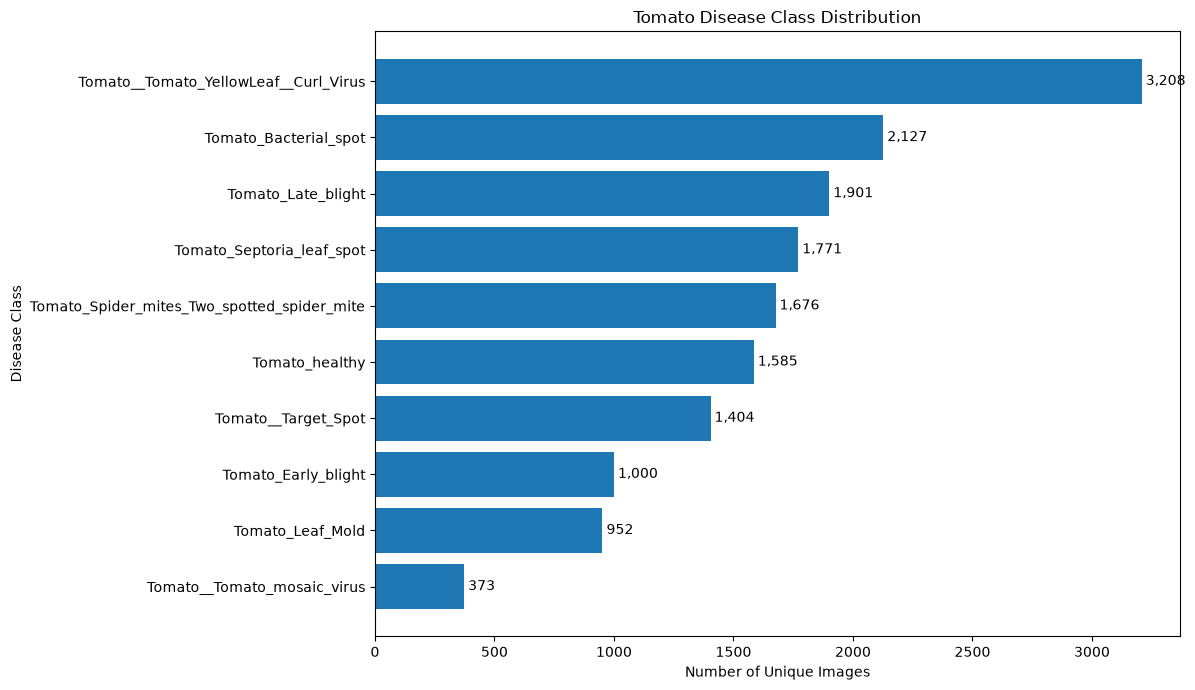

Saved: D:\Tomato_Disease_Research\results\eda\class_distribution.png


In [124]:
# ============================================================
# PART 6 — CLASS DISTRIBUTION VISUALIZATION
# ============================================================

CLASS_DISTRIBUTION_FIGURE = (
    EDA_DIR / "class_distribution.png"
)


plot_df = (
    CLASS_DISTRIBUTION_DF
    .sort_values(
        "unique_images",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(12, 7)
)


ax.barh(
    plot_df["class"],
    plot_df["unique_images"]
)


ax.set_title(
    "Tomato Disease Class Distribution"
)

ax.set_xlabel(
    "Number of Unique Images"
)

ax.set_ylabel(
    "Disease Class"
)


# ------------------------------------------------------------
# ADD VALUE LABELS
# ------------------------------------------------------------

for index, value in enumerate(
    plot_df["unique_images"]
):

    ax.text(
        value,
        index,
        f" {value:,}",
        va="center"
    )


plt.tight_layout()


plt.savefig(
    CLASS_DISTRIBUTION_FIGURE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    CLASS_DISTRIBUTION_FIGURE
)

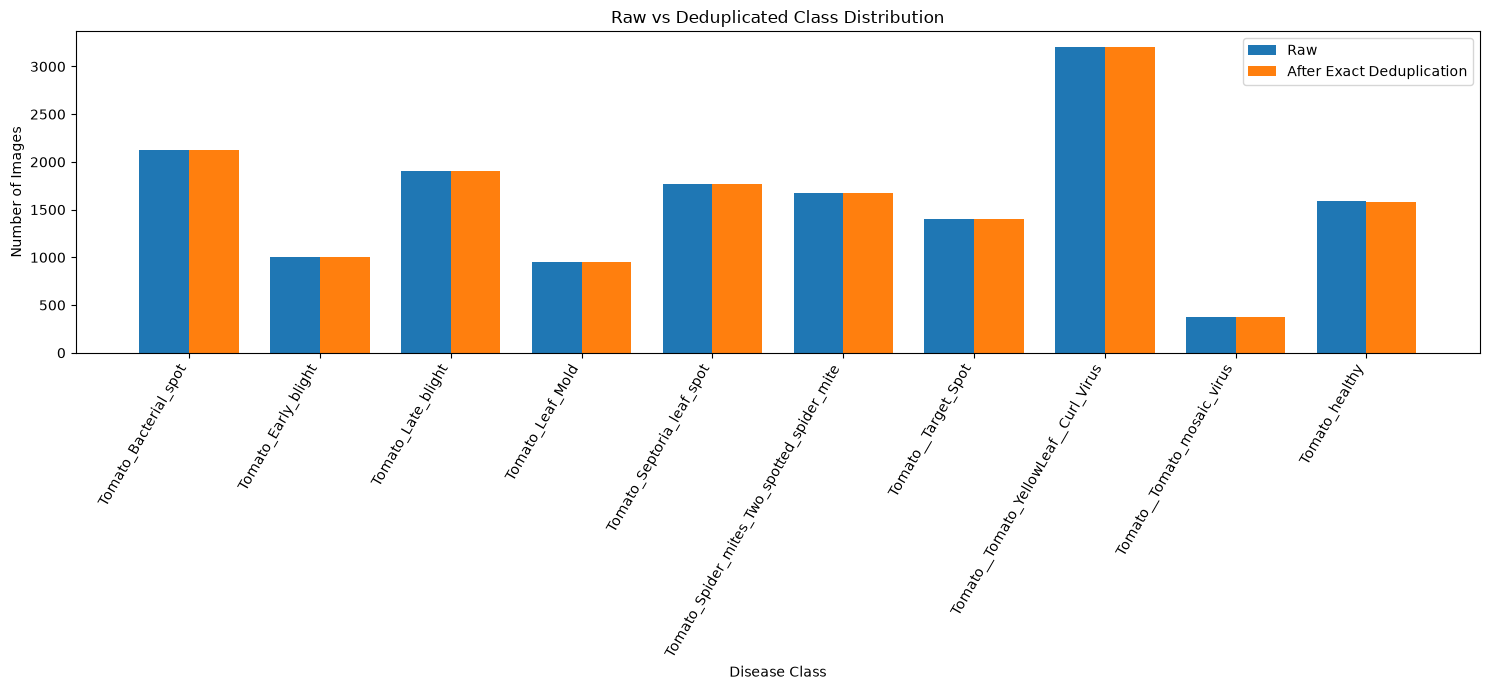

Saved: D:\Tomato_Disease_Research\results\eda\raw_vs_deduplicated_distribution.png


In [125]:
# ============================================================
# PART 6 — RAW VS DEDUPLICATED CLASS DISTRIBUTION
# ============================================================

RAW_VS_DEDUP_FIGURE = (
    EDA_DIR
    / "raw_vs_deduplicated_distribution.png"
)


comparison_df = (
    CLASS_DISTRIBUTION_DF
    .sort_values(
        "class"
    )
    .reset_index(drop=True)
)


x = np.arange(
    len(comparison_df)
)

bar_width = 0.38


fig, ax = plt.subplots(
    figsize=(15, 7)
)


ax.bar(
    x - bar_width / 2,
    comparison_df["raw_images"],
    width=bar_width,
    label="Raw"
)


ax.bar(
    x + bar_width / 2,
    comparison_df["unique_images"],
    width=bar_width,
    label="After Exact Deduplication"
)


ax.set_title(
    "Raw vs Deduplicated Class Distribution"
)

ax.set_xlabel(
    "Disease Class"
)

ax.set_ylabel(
    "Number of Images"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    comparison_df["class"],
    rotation=60,
    ha="right"
)


ax.legend()


plt.tight_layout()


plt.savefig(
    RAW_VS_DEDUP_FIGURE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    RAW_VS_DEDUP_FIGURE
)

In [126]:
# ============================================================
# PART 6 — IMAGE METADATA ANALYSIS
# ============================================================

IMAGE_METADATA_RECORDS = []


# ------------------------------------------------------------
# REQUIRED COLUMN VERIFICATION
# ------------------------------------------------------------

REQUIRED_EDA_COLUMNS = {
    "image_path",
    "class"
}

MISSING_EDA_COLUMNS = (
    REQUIRED_EDA_COLUMNS
    - set(EDA_DATASET_DF.columns)
)

if MISSING_EDA_COLUMNS:

    raise RuntimeError(
        "Missing required EDA columns: "
        f"{sorted(MISSING_EDA_COLUMNS)}"
    )


print("=" * 70)
print("PART 6 — IMAGE METADATA SCAN")
print("=" * 70)

print(
    f"Scanning {TOTAL_EDA_IMAGES:,} unique images..."
)

print()


# ------------------------------------------------------------
# SAFE ITERATION
#
# name=None prevents pandas from converting the
# 'class' column into a renamed namedtuple field.
# ------------------------------------------------------------

EDA_METADATA_ROWS = (
    EDA_DATASET_DF[
        [
            "image_path",
            "class"
        ]
    ]
    .itertuples(
        index=False,
        name=None
    )
)


for index, (
    image_path_value,
    class_name
) in enumerate(
    EDA_METADATA_ROWS,
    start=1
):

    image_path = Path(
        image_path_value
    )


    # --------------------------------------------------------
    # READ IMAGE METADATA
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        width, height = image.size

        image_mode = image.mode

        image_format = (
            image.format
            if image.format is not None
            else image_path.suffix
            .replace(".", "")
            .upper()
        )


    # --------------------------------------------------------
    # DERIVED METADATA
    # --------------------------------------------------------

    aspect_ratio = (
        width / height
    )

    megapixels = (
        width
        * height
        / 1_000_000
    )


    # --------------------------------------------------------
    # ORIENTATION CATEGORY
    # --------------------------------------------------------

    if aspect_ratio > 1.05:

        orientation = "Landscape"

    elif aspect_ratio < 0.95:

        orientation = "Portrait"

    else:

        orientation = "Square-like"


    # --------------------------------------------------------
    # RELATIVE PATH
    # --------------------------------------------------------

    try:

        relative_path = (
            image_path
            .relative_to(
                PLANTVILLAGE_DIR
            )
        )

    except ValueError:

        relative_path = (
            image_path.name
        )


    # --------------------------------------------------------
    # SAVE RECORD
    # --------------------------------------------------------

    IMAGE_METADATA_RECORDS.append(
        {
            "relative_path": str(
                relative_path
            ),

            "class": class_name,

            "width": width,

            "height": height,

            "aspect_ratio": (
                aspect_ratio
            ),

            "megapixels": (
                megapixels
            ),

            "orientation": (
                orientation
            ),

            "mode": (
                image_mode
            ),

            "format": (
                image_format
            )
        }
    )


    # --------------------------------------------------------
    # PROGRESS
    # --------------------------------------------------------

    if (
        index % 2000 == 0
        or
        index == TOTAL_EDA_IMAGES
    ):

        print(
            f"Scanned "
            f"{index:,}/"
            f"{TOTAL_EDA_IMAGES:,}"
        )


# ------------------------------------------------------------
# CREATE METADATA DATAFRAME
# ------------------------------------------------------------

IMAGE_METADATA_DF = pd.DataFrame(
    IMAGE_METADATA_RECORDS
)


# ------------------------------------------------------------
# FINAL CONSISTENCY CHECK
# ------------------------------------------------------------

if len(
    IMAGE_METADATA_DF
) != TOTAL_EDA_IMAGES:

    raise RuntimeError(
        "Metadata row count mismatch. "
        f"Expected {TOTAL_EDA_IMAGES:,}, "
        f"found {len(IMAGE_METADATA_DF):,}."
    )


# ------------------------------------------------------------
# SAVE METADATA
# ------------------------------------------------------------

IMAGE_METADATA_DF.to_csv(
    EDA_IMAGE_METADATA_CSV,
    index=False
)


if not EDA_IMAGE_METADATA_CSV.exists():

    raise RuntimeError(
        "Image metadata CSV was not saved."
    )


print()

print(
    "PASS — Image metadata scan completed."
)

print(
    "Metadata Rows:",
    f"{len(IMAGE_METADATA_DF):,}"
)

print(
    "Saved:",
    EDA_IMAGE_METADATA_CSV
)

PART 6 — IMAGE METADATA SCAN
Scanning 15,997 unique images...

Scanned 2,000/15,997
Scanned 4,000/15,997
Scanned 6,000/15,997
Scanned 8,000/15,997
Scanned 10,000/15,997
Scanned 12,000/15,997
Scanned 14,000/15,997
Scanned 15,997/15,997

PASS — Image metadata scan completed.
Metadata Rows: 15,997
Saved: D:\Tomato_Disease_Research\results\eda\image_metadata.csv


In [127]:
# ============================================================
# PART 6 — IMAGE METADATA SUMMARY
# ============================================================

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

EDA_DIR = (
    RESULTS_DIR / "eda"
)

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

EDA_METADATA_SUMMARY_CSV = (
    EDA_DIR / "image_metadata_summary.csv"
)


# ------------------------------------------------------------
# REQUIRED COLUMN CHECK
# ------------------------------------------------------------

REQUIRED_METADATA_COLUMNS = {
    "class",
    "width",
    "height",
    "aspect_ratio",
    "megapixels",
    "orientation",
    "mode",
    "format"
}

missing_columns = (
    REQUIRED_METADATA_COLUMNS
    - set(IMAGE_METADATA_DF.columns)
)

if missing_columns:

    raise RuntimeError(
        "Missing metadata columns: "
        f"{sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# NUMERICAL SUMMARY
# ------------------------------------------------------------

NUMERICAL_COLUMNS = [
    "width",
    "height",
    "aspect_ratio",
    "megapixels"
]

METADATA_NUMERICAL_SUMMARY = (
    IMAGE_METADATA_DF[
        NUMERICAL_COLUMNS
    ]
    .describe()
    .T
    .reset_index()
    .rename(
        columns={
            "index": "feature"
        }
    )
)


# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------

METADATA_NUMERICAL_SUMMARY.to_csv(
    EDA_METADATA_SUMMARY_CSV,
    index=False
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("PART 6 — IMAGE METADATA SUMMARY")
print("=" * 70)

print(
    "Total Unique Images :",
    f"{len(IMAGE_METADATA_DF):,}"
)

print()

print(
    "Width Range         :",
    f"{IMAGE_METADATA_DF['width'].min()} "
    f"to "
    f"{IMAGE_METADATA_DF['width'].max()}"
)

print(
    "Height Range        :",
    f"{IMAGE_METADATA_DF['height'].min()} "
    f"to "
    f"{IMAGE_METADATA_DF['height'].max()}"
)

print(
    "Mean Width          :",
    f"{IMAGE_METADATA_DF['width'].mean():.2f}"
)

print(
    "Mean Height         :",
    f"{IMAGE_METADATA_DF['height'].mean():.2f}"
)

print(
    "Mean Aspect Ratio   :",
    f"{IMAGE_METADATA_DF['aspect_ratio'].mean():.4f}"
)

print(
    "Mean Megapixels     :",
    f"{IMAGE_METADATA_DF['megapixels'].mean():.4f}"
)

print()

print("-" * 70)
print("ORIENTATION DISTRIBUTION")
print("-" * 70)

print(
    IMAGE_METADATA_DF[
        "orientation"
    ]
    .value_counts()
    .to_string()
)

print()

print("-" * 70)
print("IMAGE MODE DISTRIBUTION")
print("-" * 70)

print(
    IMAGE_METADATA_DF[
        "mode"
    ]
    .value_counts()
    .to_string()
)

print()

print("-" * 70)
print("IMAGE FORMAT DISTRIBUTION")
print("-" * 70)

print(
    IMAGE_METADATA_DF[
        "format"
    ]
    .value_counts()
    .to_string()
)

print()

print("-" * 70)
print("NUMERICAL STATISTICS")
print("-" * 70)

display(
    METADATA_NUMERICAL_SUMMARY
)

print()

print(
    "Saved:",
    EDA_METADATA_SUMMARY_CSV
)

print("=" * 70)

print(
    "PASS — Image metadata summary completed."
)

PART 6 — IMAGE METADATA SUMMARY
Total Unique Images : 15,997

Width Range         : 256 to 256
Height Range        : 256 to 256
Mean Width          : 256.00
Mean Height         : 256.00
Mean Aspect Ratio   : 1.0000
Mean Megapixels     : 0.0655

----------------------------------------------------------------------
ORIENTATION DISTRIBUTION
----------------------------------------------------------------------
orientation
Square-like    15997

----------------------------------------------------------------------
IMAGE MODE DISTRIBUTION
----------------------------------------------------------------------
mode
RGB    15997

----------------------------------------------------------------------
IMAGE FORMAT DISTRIBUTION
----------------------------------------------------------------------
format
JPEG    15997

----------------------------------------------------------------------
NUMERICAL STATISTICS
----------------------------------------------------------------------


,feature,count,mean,std,min,25%,50%,75%,max
0,width,15997.0,256.000000,0.000000e+00,256.000000,256.000000,256.000000,256.000000,256.000000
1,height,15997.0,256.000000,0.000000e+00,256.000000,256.000000,256.000000,256.000000,256.000000
2,aspect_ratio,15997.0,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000
3,megapixels,15997.0,0.065536,1.387822e-17,0.065536,0.065536,0.065536,0.065536,0.065536



Saved: D:\Tomato_Disease_Research\results\eda\image_metadata_summary.csv
PASS — Image metadata summary completed.


PART 6 — CLASS DISTRIBUTION ANALYSIS
Total Unique Images : 15,997
Number of Classes   : 10
Largest Class       : 3,208
Smallest Class      : 373
Imbalance Ratio     : 8.60:1



,class,image_count,percentage
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208,20.053760
1,Tomato_Bacterial_spot,2127,13.296243
2,Tomato_Late_blight,1901,11.883478
3,Tomato_Septoria_leaf_spot,1771,11.070826
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676,10.476964
5,Tomato_healthy,1585,9.908108
6,Tomato__Target_Spot,1404,8.776646
7,Tomato_Early_blight,1000,6.251172
8,Tomato_Leaf_Mold,952,5.951116
9,Tomato__Tomato_mosaic_virus,373,2.331687


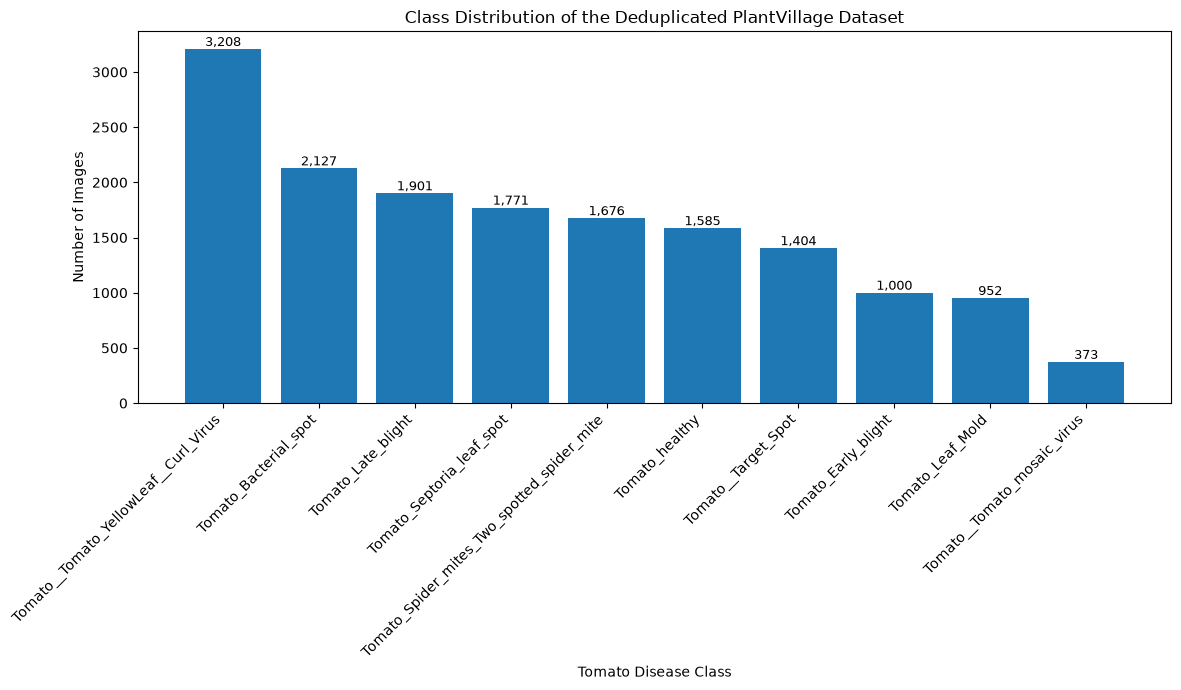


CSV Saved: D:\Tomato_Disease_Research\results\eda\class_distribution.csv
Figure Saved: D:\Tomato_Disease_Research\results\eda\class_distribution.png
PASS — Class distribution analysis completed.


In [128]:
# ============================================================
# PART 6 — CLASS DISTRIBUTION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# OUTPUT FILES
# ------------------------------------------------------------

EDA_CLASS_DISTRIBUTION_CSV = (
    EDA_DIR / "class_distribution.csv"
)

EDA_CLASS_DISTRIBUTION_PNG = (
    EDA_DIR / "class_distribution.png"
)


# ------------------------------------------------------------
# CLASS COUNTS
# ------------------------------------------------------------

CLASS_DISTRIBUTION_DF = (
    EDA_DATASET_DF["class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="image_count")
)


# ------------------------------------------------------------
# PERCENTAGE
# ------------------------------------------------------------

CLASS_DISTRIBUTION_DF[
    "percentage"
] = (
    CLASS_DISTRIBUTION_DF[
        "image_count"
    ]
    / TOTAL_EDA_IMAGES
    * 100
)


# ------------------------------------------------------------
# BASIC STATISTICS
# ------------------------------------------------------------

NUM_CLASSES_EDA = len(
    CLASS_DISTRIBUTION_DF
)

LARGEST_CLASS_COUNT = int(
    CLASS_DISTRIBUTION_DF[
        "image_count"
    ].max()
)

SMALLEST_CLASS_COUNT = int(
    CLASS_DISTRIBUTION_DF[
        "image_count"
    ].min()
)

CLASS_IMBALANCE_RATIO = (
    LARGEST_CLASS_COUNT
    / SMALLEST_CLASS_COUNT
)


# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

assert (
    CLASS_DISTRIBUTION_DF[
        "image_count"
    ].sum()
    ==
    TOTAL_EDA_IMAGES
), (
    "Class distribution total does not "
    "match the EDA dataset size."
)

assert (
    NUM_CLASSES_EDA == 10
), (
    f"Expected 10 classes, "
    f"found {NUM_CLASSES_EDA}."
)


# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

CLASS_DISTRIBUTION_DF.to_csv(
    EDA_CLASS_DISTRIBUTION_CSV,
    index=False
)


# ------------------------------------------------------------
# DISPLAY TABLE
# ------------------------------------------------------------

print("=" * 70)
print("PART 6 — CLASS DISTRIBUTION ANALYSIS")
print("=" * 70)

print(
    "Total Unique Images :",
    f"{TOTAL_EDA_IMAGES:,}"
)

print(
    "Number of Classes   :",
    NUM_CLASSES_EDA
)

print(
    "Largest Class       :",
    f"{LARGEST_CLASS_COUNT:,}"
)

print(
    "Smallest Class      :",
    f"{SMALLEST_CLASS_COUNT:,}"
)

print(
    "Imbalance Ratio     :",
    f"{CLASS_IMBALANCE_RATIO:.2f}:1"
)

print()

display(
    CLASS_DISTRIBUTION_DF
)


# ------------------------------------------------------------
# BAR CHART
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

bars = plt.bar(
    CLASS_DISTRIBUTION_DF[
        "class"
    ],
    CLASS_DISTRIBUTION_DF[
        "image_count"
    ]
)


# ------------------------------------------------------------
# VALUE LABELS
# ------------------------------------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.title(
    "Class Distribution of the Deduplicated PlantVillage Dataset"
)

plt.xlabel(
    "Tomato Disease Class"
)

plt.ylabel(
    "Number of Images"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()


# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

plt.savefig(
    EDA_CLASS_DISTRIBUTION_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print()

print(
    "CSV Saved:",
    EDA_CLASS_DISTRIBUTION_CSV
)

print(
    "Figure Saved:",
    EDA_CLASS_DISTRIBUTION_PNG
)

print("=" * 70)

print(
    "PASS — Class distribution analysis completed."
)

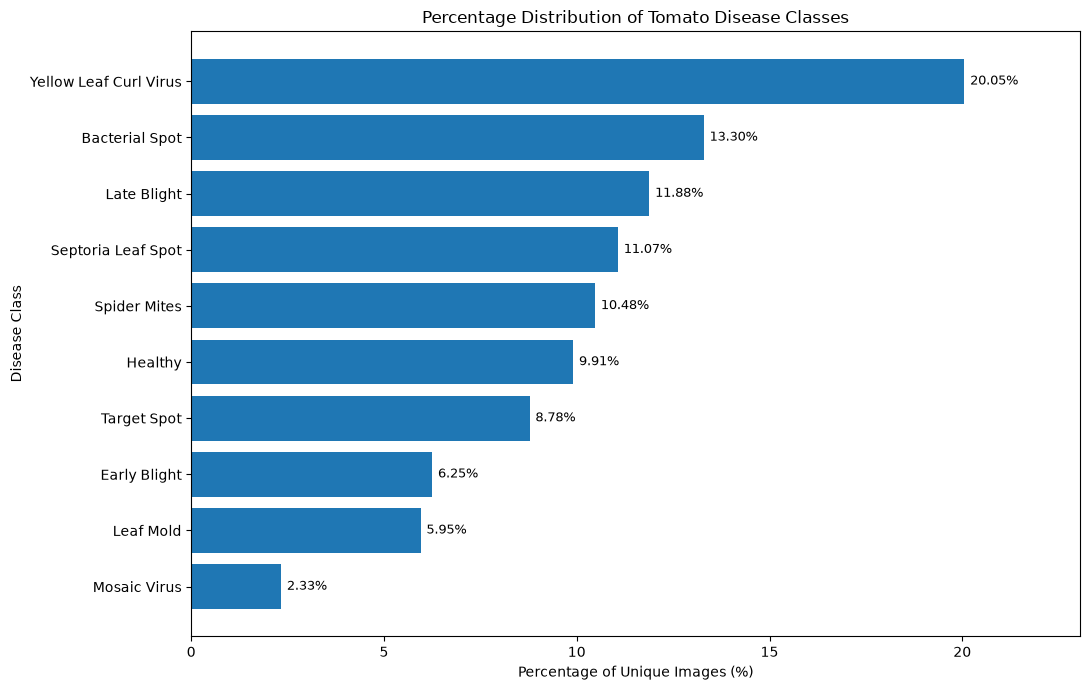

PART 6 — CLASS PERCENTAGE VISUALIZATION
Largest Class Percentage : 20.05%
Smallest Class Percentage: 2.33%
Imbalance Ratio          : 8.60:1

Figure Saved: D:\Tomato_Disease_Research\results\eda\class_percentage_distribution.png
PASS — Class percentage visualization completed.


In [129]:
# ============================================================
# PART 6 — CLASS PERCENTAGE VISUALIZATION
# ============================================================

EDA_CLASS_PERCENTAGE_PNG = (
    EDA_DIR / "class_percentage_distribution.png"
)


# ------------------------------------------------------------
# READABLE DISPLAY NAMES
# ------------------------------------------------------------

CLASS_DISPLAY_NAMES = {
    "Tomato_Bacterial_spot":
        "Bacterial Spot",

    "Tomato_Early_blight":
        "Early Blight",

    "Tomato_Late_blight":
        "Late Blight",

    "Tomato_Leaf_Mold":
        "Leaf Mold",

    "Tomato_Septoria_leaf_spot":
        "Septoria Leaf Spot",

    "Tomato_Spider_mites_Two_spotted_spider_mite":
        "Spider Mites",

    "Tomato__Target_Spot":
        "Target Spot",

    "Tomato__Tomato_YellowLeaf__Curl_Virus":
        "Yellow Leaf Curl Virus",

    "Tomato__Tomato_mosaic_virus":
        "Mosaic Virus",

    "Tomato_healthy":
        "Healthy"
}


# ------------------------------------------------------------
# PREPARE VISUALIZATION DATA
# ------------------------------------------------------------

CLASS_PERCENTAGE_DF = (
    CLASS_DISTRIBUTION_DF
    .copy()
)


CLASS_PERCENTAGE_DF[
    "display_name"
] = (
    CLASS_PERCENTAGE_DF[
        "class"
    ]
    .map(
        CLASS_DISPLAY_NAMES
    )
)


# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

if (
    CLASS_PERCENTAGE_DF[
        "display_name"
    ]
    .isna()
    .any()
):

    missing_labels = (
        CLASS_PERCENTAGE_DF.loc[
            CLASS_PERCENTAGE_DF[
                "display_name"
            ].isna(),
            "class"
        ]
        .tolist()
    )

    raise RuntimeError(
        "Missing display-name mapping for: "
        f"{missing_labels}"
    )


# ------------------------------------------------------------
# SORT FOR HORIZONTAL BAR CHART
# ------------------------------------------------------------

CLASS_PERCENTAGE_PLOT_DF = (
    CLASS_PERCENTAGE_DF
    .sort_values(
        "percentage",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)

bars = plt.barh(
    CLASS_PERCENTAGE_PLOT_DF[
        "display_name"
    ],
    CLASS_PERCENTAGE_PLOT_DF[
        "percentage"
    ]
)


# ------------------------------------------------------------
# ADD PERCENTAGE LABELS
# ------------------------------------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.15,
        bar.get_y()
        + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=9
    )


plt.title(
    "Percentage Distribution of Tomato Disease Classes"
)

plt.xlabel(
    "Percentage of Unique Images (%)"
)

plt.ylabel(
    "Disease Class"
)

plt.xlim(
    0,
    CLASS_PERCENTAGE_PLOT_DF[
        "percentage"
    ].max() + 3
)

plt.tight_layout()


# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

plt.savefig(
    EDA_CLASS_PERCENTAGE_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("PART 6 — CLASS PERCENTAGE VISUALIZATION")
print("=" * 70)

print(
    "Largest Class Percentage :",
    f"{CLASS_DISTRIBUTION_DF['percentage'].max():.2f}%"
)

print(
    "Smallest Class Percentage:",
    f"{CLASS_DISTRIBUTION_DF['percentage'].min():.2f}%"
)

print(
    "Imbalance Ratio          :",
    f"{CLASS_IMBALANCE_RATIO:.2f}:1"
)

print()

print(
    "Figure Saved:",
    EDA_CLASS_PERCENTAGE_PNG
)

print("=" * 70)

print(
    "PASS — Class percentage visualization completed."
)

In [ ]:
# ============================================================
# PART 6 — SAMPLE IMAGE VISUALIZATION
# ============================================================

EDA_SAMPLE_IMAGES_PNG = (
    EDA_DIR / "sample_images_all_classes.png"
)


# ------------------------------------------------------------
# VERIFY CLASS COUNT
# ------------------------------------------------------------

EDA_CLASSES = sorted(
    EDA_DATASET_DF[
        "class"
    ].unique()
)

if len(EDA_CLASSES) != 10:

    raise RuntimeError(
        f"Expected 10 classes, "
        f"found {len(EDA_CLASSES)}."
    )


# ------------------------------------------------------------
# SELECT ONE DETERMINISTIC SAMPLE PER CLASS
# ------------------------------------------------------------

SAMPLE_IMAGE_RECORDS = []


for class_index, class_name in enumerate(
    EDA_CLASSES
):

    class_df = (
        EDA_DATASET_DF[
            EDA_DATASET_DF[
                "class"
            ] == class_name
        ]
    )


    if len(class_df) == 0:

        raise RuntimeError(
            f"No images found for class: "
            f"{class_name}"
        )


    sample_row = (
        class_df
        .sample(
            n=1,
            random_state=(
                SEED
                + class_index
            )
        )
        .iloc[0]
    )


    SAMPLE_IMAGE_RECORDS.append(
        {
            "class": class_name,
            "image_path": (
                sample_row[
                    "image_path"
                ]
            )
        }
    )


# ------------------------------------------------------------
# VERIFY ONE SAMPLE PER CLASS
# ------------------------------------------------------------

assert (
    len(
        SAMPLE_IMAGE_RECORDS
    )
    == 10
)

assert (
    len(
        {
            record["class"]
            for record
            in SAMPLE_IMAGE_RECORDS
        }
    )
    == 10
)


# ------------------------------------------------------------
# CREATE IMAGE GRID
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    5,
    figsize=(16, 7)
)

axes = axes.flatten()


for axis, record in zip(
    axes,
    SAMPLE_IMAGE_RECORDS
):

    image_path = Path(
        record[
            "image_path"
        ]
    )

    class_name = (
        record[
            "class"
        ]
    )


    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        image_rgb = (
            image
            .convert(
                "RGB"
            )
            .copy()
        )


    # --------------------------------------------------------
    # READABLE DISPLAY NAME
    # --------------------------------------------------------

    display_name = (
        CLASS_DISPLAY_NAMES.get(
            class_name,
            class_name
        )
    )


    # --------------------------------------------------------
    # DISPLAY
    # --------------------------------------------------------

    axis.imshow(
        image_rgb
    )

    axis.set_title(
        display_name,
        fontsize=10
    )

    axis.axis(
        "off"
    )


# ------------------------------------------------------------
# FIGURE TITLE
# ------------------------------------------------------------

fig.suptitle(
    "Representative Samples from the 10 Tomato Disease Classes",
    fontsize=15
)

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)


# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

plt.savefig(
    EDA_SAMPLE_IMAGES_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("PART 6 — SAMPLE IMAGE VISUALIZATION")
print("=" * 70)

print(
    "Classes Visualized :",
    len(
        SAMPLE_IMAGE_RECORDS
    )
)

print(
    "Samples Per Class  : 1"
)

print(
    "Random Seed        :",
    SEED
)

print()

print(
    "Figure Saved:",
    EDA_SAMPLE_IMAGES_PNG
)

print("=" * 70)

print(
    "PASS — Sample visualization completed."
)

PART 6 — BRIGHTNESS & CONTRAST SCAN
Scanning 15,997 unique images...

Scanned 2,000/15,997
Scanned 4,000/15,997
Scanned 6,000/15,997
Scanned 8,000/15,997
Scanned 10,000/15,997
Scanned 12,000/15,997
Scanned 14,000/15,997
Scanned 15,997/15,997


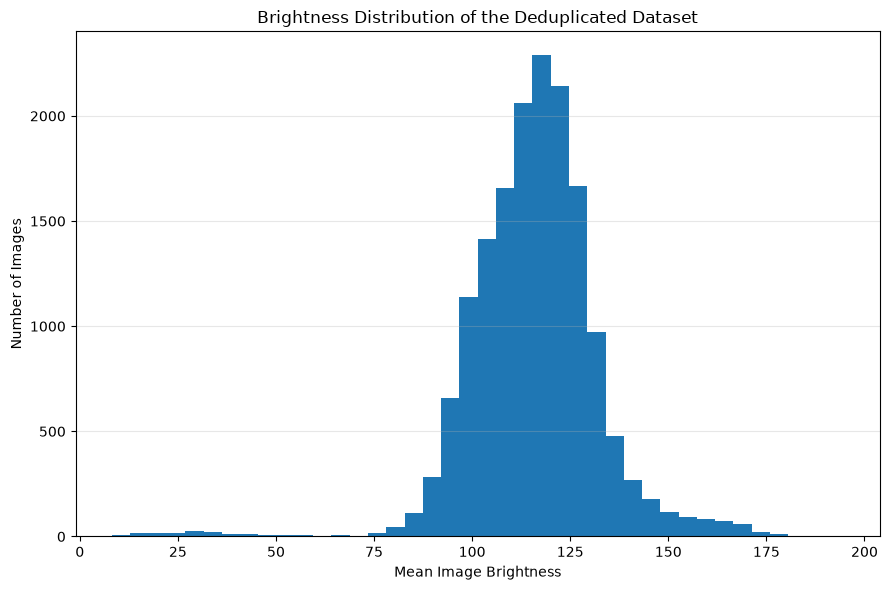

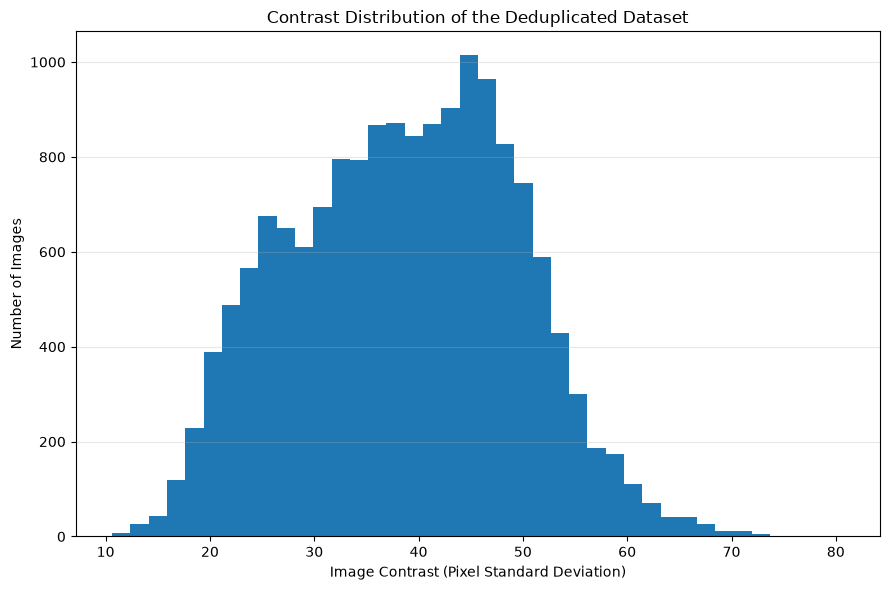


PART 6 — BRIGHTNESS & CONTRAST SUMMARY
Images Analysed     : 15,997

Mean Brightness     : 115.84
Brightness Std      : 16.59
Brightness Range    : 8.25 to 194.56

Mean Contrast       : 38.63
Contrast Std        : 10.77
Contrast Range      : 10.63 to 80.73



,class,mean_brightness,std_brightness,mean_contrast,std_contrast,image_count
0,Tomato_Bacterial_spot,104.916353,10.709770,33.414574,5.990446,2127
1,Tomato_Early_blight,110.582883,14.153619,46.310413,11.044766,1000
2,Tomato_Late_blight,113.610709,28.342334,39.634429,14.906082,1901
3,Tomato_Leaf_Mold,115.409122,12.585076,36.823933,9.170121,952
4,Tomato_Septoria_leaf_spot,130.901421,16.382934,37.839910,10.348355,1771
5,Tomato_Spider_mites_Two_spotted_spider_mite,119.272121,10.088237,44.563007,6.540654,1676
6,Tomato__Target_Spot,118.750901,9.302839,45.101670,6.104987,1404
7,Tomato__Tomato_YellowLeaf__Curl_Virus,114.418702,14.091332,34.741365,9.667289,3208
8,Tomato__Tomato_mosaic_virus,117.354544,12.349778,34.792129,6.111247,373
9,Tomato_healthy,116.238979,7.571095,38.340606,12.104005,1585



CSV Saved: D:\Tomato_Disease_Research\results\eda\brightness_contrast_analysis.csv
Brightness Figure: D:\Tomato_Disease_Research\results\eda\brightness_distribution.png
Contrast Figure: D:\Tomato_Disease_Research\results\eda\contrast_distribution.png
PASS — Brightness and contrast analysis verified.


In [ ]:
# ============================================================
# PART 6 — BRIGHTNESS & CONTRAST ANALYSIS
# ============================================================

EDA_BRIGHTNESS_CONTRAST_CSV = (
    EDA_DIR / "brightness_contrast_analysis.csv"
)

EDA_BRIGHTNESS_PNG = (
    EDA_DIR / "brightness_distribution.png"
)

EDA_CONTRAST_PNG = (
    EDA_DIR / "contrast_distribution.png"
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — INPUT CHECKS
# ------------------------------------------------------------

required_columns = {
    "image_path",
    "class"
}

missing_columns = (
    required_columns
    - set(EDA_DATASET_DF.columns)
)

if missing_columns:

    raise RuntimeError(
        "Missing required columns: "
        f"{sorted(missing_columns)}"
    )


if len(EDA_DATASET_DF) != TOTAL_EDA_IMAGES:

    raise RuntimeError(
        "EDA dataset row count mismatch."
    )


# ------------------------------------------------------------
# PIXEL STATISTICS SCAN
# ------------------------------------------------------------

BRIGHTNESS_CONTRAST_RECORDS = []


print("=" * 70)
print("PART 6 — BRIGHTNESS & CONTRAST SCAN")
print("=" * 70)

print(
    f"Scanning {TOTAL_EDA_IMAGES:,} unique images..."
)

print()


for index, (
    image_path_value,
    class_name
) in enumerate(

    EDA_DATASET_DF[
        [
            "image_path",
            "class"
        ]
    ].itertuples(
        index=False,
        name=None
    ),

    start=1
):

    image_path = Path(
        image_path_value
    )


    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        grayscale = np.asarray(
            image
            .convert("L"),
            dtype=np.float32
        )


    # --------------------------------------------------------
    # IMAGE-LEVEL STATISTICS
    # --------------------------------------------------------

    brightness = float(
        grayscale.mean()
    )

    contrast = float(
        grayscale.std()
    )


    BRIGHTNESS_CONTRAST_RECORDS.append(
        {
            "image_path": str(
                image_path
            ),

            "class": class_name,

            "brightness": brightness,

            "contrast": contrast
        }
    )


    # --------------------------------------------------------
    # PROGRESS
    # --------------------------------------------------------

    if (
        index % 2000 == 0
        or
        index == TOTAL_EDA_IMAGES
    ):

        print(
            f"Scanned "
            f"{index:,}/"
            f"{TOTAL_EDA_IMAGES:,}"
        )


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

BRIGHTNESS_CONTRAST_DF = pd.DataFrame(
    BRIGHTNESS_CONTRAST_RECORDS
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — OUTPUT CHECKS
# ------------------------------------------------------------

if (
    len(BRIGHTNESS_CONTRAST_DF)
    != TOTAL_EDA_IMAGES
):

    raise RuntimeError(
        "Brightness/contrast row count mismatch."
    )


if (
    BRIGHTNESS_CONTRAST_DF[
        [
            "brightness",
            "contrast"
        ]
    ]
    .isna()
    .any()
    .any()
):

    raise RuntimeError(
        "NaN values detected in "
        "brightness/contrast statistics."
    )


if not (
    BRIGHTNESS_CONTRAST_DF[
        "brightness"
    ]
    .between(
        0,
        255
    )
    .all()
):

    raise RuntimeError(
        "Brightness values outside "
        "valid 0–255 range."
    )


if (
    BRIGHTNESS_CONTRAST_DF[
        "contrast"
    ] < 0
).any():

    raise RuntimeError(
        "Negative contrast value detected."
    )


# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

BRIGHTNESS_CONTRAST_DF.to_csv(
    EDA_BRIGHTNESS_CONTRAST_CSV,
    index=False
)


if not EDA_BRIGHTNESS_CONTRAST_CSV.exists():

    raise RuntimeError(
        "Brightness/contrast CSV was not saved."
    )


# ------------------------------------------------------------
# OVERALL STATISTICS
# ------------------------------------------------------------

MEAN_BRIGHTNESS = (
    BRIGHTNESS_CONTRAST_DF[
        "brightness"
    ].mean()
)

STD_BRIGHTNESS = (
    BRIGHTNESS_CONTRAST_DF[
        "brightness"
    ].std()
)

MIN_BRIGHTNESS = (
    BRIGHTNESS_CONTRAST_DF[
        "brightness"
    ].min()
)

MAX_BRIGHTNESS = (
    BRIGHTNESS_CONTRAST_DF[
        "brightness"
    ].max()
)


MEAN_CONTRAST = (
    BRIGHTNESS_CONTRAST_DF[
        "contrast"
    ].mean()
)

STD_CONTRAST = (
    BRIGHTNESS_CONTRAST_DF[
        "contrast"
    ].std()
)

MIN_CONTRAST = (
    BRIGHTNESS_CONTRAST_DF[
        "contrast"
    ].min()
)

MAX_CONTRAST = (
    BRIGHTNESS_CONTRAST_DF[
        "contrast"
    ].max()
)


# ------------------------------------------------------------
# BRIGHTNESS HISTOGRAM
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    BRIGHTNESS_CONTRAST_DF[
        "brightness"
    ],
    bins=40
)

plt.xlabel(
    "Mean Image Brightness"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Brightness Distribution of the Deduplicated Dataset"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    EDA_BRIGHTNESS_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# CONTRAST HISTOGRAM
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    BRIGHTNESS_CONTRAST_DF[
        "contrast"
    ],
    bins=40
)

plt.xlabel(
    "Image Contrast (Pixel Standard Deviation)"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Contrast Distribution of the Deduplicated Dataset"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    EDA_CONTRAST_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# CLASS-WISE SUMMARY
# ------------------------------------------------------------

CLASS_BRIGHTNESS_CONTRAST_DF = (
    BRIGHTNESS_CONTRAST_DF
    .groupby(
        "class"
    )
    .agg(
        mean_brightness=(
            "brightness",
            "mean"
        ),

        std_brightness=(
            "brightness",
            "std"
        ),

        mean_contrast=(
            "contrast",
            "mean"
        ),

        std_contrast=(
            "contrast",
            "std"
        ),

        image_count=(
            "image_path",
            "count"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print()

print("=" * 70)
print("PART 6 — BRIGHTNESS & CONTRAST SUMMARY")
print("=" * 70)

print(
    "Images Analysed     :",
    f"{len(BRIGHTNESS_CONTRAST_DF):,}"
)

print()

print(
    "Mean Brightness     :",
    f"{MEAN_BRIGHTNESS:.2f}"
)

print(
    "Brightness Std      :",
    f"{STD_BRIGHTNESS:.2f}"
)

print(
    "Brightness Range    :",
    f"{MIN_BRIGHTNESS:.2f} "
    f"to {MAX_BRIGHTNESS:.2f}"
)

print()

print(
    "Mean Contrast       :",
    f"{MEAN_CONTRAST:.2f}"
)

print(
    "Contrast Std        :",
    f"{STD_CONTRAST:.2f}"
)

print(
    "Contrast Range      :",
    f"{MIN_CONTRAST:.2f} "
    f"to {MAX_CONTRAST:.2f}"
)

print()

display(
    CLASS_BRIGHTNESS_CONTRAST_DF
)

print()

print(
    "CSV Saved:",
    EDA_BRIGHTNESS_CONTRAST_CSV
)

print(
    "Brightness Figure:",
    EDA_BRIGHTNESS_PNG
)

print(
    "Contrast Figure:",
    EDA_CONTRAST_PNG
)

print("=" * 70)

print(
    "PASS — Brightness and contrast "
    "analysis verified."
)

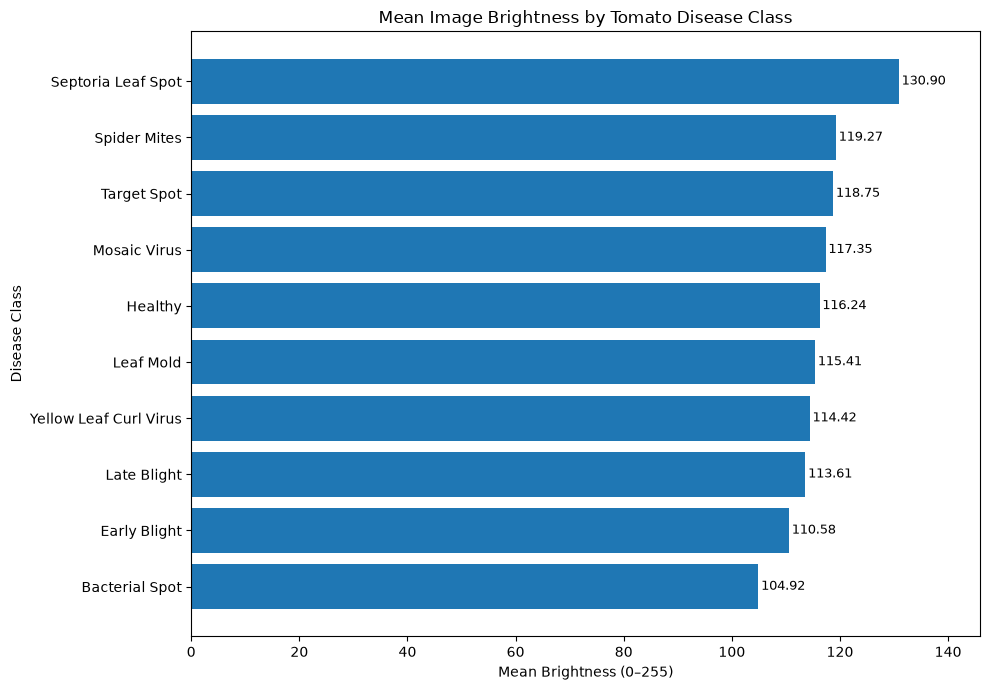

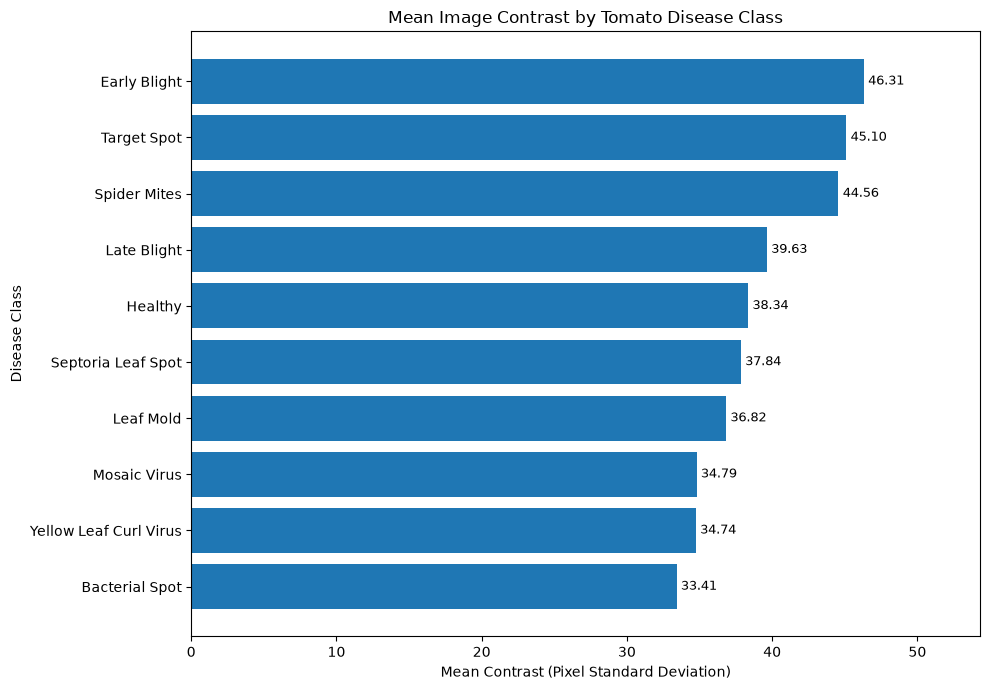

PART 6 — CLASS-WISE BRIGHTNESS & CONTRAST
Brightest Class : Septoria Leaf Spot (130.90)
Darkest Class   : Bacterial Spot (104.92)

Highest Contrast: Early Blight (46.31)
Lowest Contrast : Bacterial Spot (33.41)

Summary CSV: D:\Tomato_Disease_Research\results\eda\class_brightness_contrast_summary.csv
Brightness Figure: D:\Tomato_Disease_Research\results\eda\class_mean_brightness.png
Contrast Figure: D:\Tomato_Disease_Research\results\eda\class_mean_contrast.png
PASS — Class-wise brightness and contrast analysis verified.


In [ ]:
# ============================================================
# PART 6 — CLASS-WISE BRIGHTNESS & CONTRAST VISUALIZATION
# ============================================================

EDA_CLASS_BRIGHTNESS_CSV = (
    EDA_DIR / "class_brightness_contrast_summary.csv"
)

EDA_CLASS_BRIGHTNESS_PNG = (
    EDA_DIR / "class_mean_brightness.png"
)

EDA_CLASS_CONTRAST_PNG = (
    EDA_DIR / "class_mean_contrast.png"
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — SUMMARY CHECK
# ------------------------------------------------------------

if len(CLASS_BRIGHTNESS_CONTRAST_DF) != 10:

    raise RuntimeError(
        "Expected brightness/contrast statistics "
        f"for 10 classes, found "
        f"{len(CLASS_BRIGHTNESS_CONTRAST_DF)}."
    )


if (
    CLASS_BRIGHTNESS_CONTRAST_DF[
        [
            "mean_brightness",
            "std_brightness",
            "mean_contrast",
            "std_contrast",
            "image_count"
        ]
    ]
    .isna()
    .any()
    .any()
):

    raise RuntimeError(
        "NaN detected in class-wise "
        "brightness/contrast summary."
    )


if (
    CLASS_BRIGHTNESS_CONTRAST_DF[
        "image_count"
    ].sum()
    != TOTAL_EDA_IMAGES
):

    raise RuntimeError(
        "Class-wise image counts do not "
        "match total EDA images."
    )


# ------------------------------------------------------------
# ADD READABLE CLASS NAMES
# ------------------------------------------------------------

CLASS_BRIGHTNESS_CONTRAST_PLOT_DF = (
    CLASS_BRIGHTNESS_CONTRAST_DF
    .copy()
)


CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
    "display_name"
] = (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
        "class"
    ]
    .map(
        CLASS_DISPLAY_NAMES
    )
)


if (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
        "display_name"
    ]
    .isna()
    .any()
):

    missing_classes = (
        CLASS_BRIGHTNESS_CONTRAST_PLOT_DF.loc[
            CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
                "display_name"
            ].isna(),
            "class"
        ]
        .tolist()
    )

    raise RuntimeError(
        "Missing readable class names for: "
        f"{missing_classes}"
    )


# ------------------------------------------------------------
# SAVE CLASS-WISE SUMMARY
# ------------------------------------------------------------

CLASS_BRIGHTNESS_CONTRAST_PLOT_DF.to_csv(
    EDA_CLASS_BRIGHTNESS_CSV,
    index=False
)


# ============================================================
# MEAN BRIGHTNESS VISUALIZATION
# ============================================================

BRIGHTNESS_PLOT_DF = (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF
    .sort_values(
        "mean_brightness",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)

bars = plt.barh(
    BRIGHTNESS_PLOT_DF[
        "display_name"
    ],
    BRIGHTNESS_PLOT_DF[
        "mean_brightness"
    ]
)


for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.5,
        bar.get_y()
        + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )


plt.xlabel(
    "Mean Brightness (0–255)"
)

plt.ylabel(
    "Disease Class"
)

plt.title(
    "Mean Image Brightness by Tomato Disease Class"
)

plt.xlim(
    0,
    BRIGHTNESS_PLOT_DF[
        "mean_brightness"
    ].max() + 15
)

plt.tight_layout()


plt.savefig(
    EDA_CLASS_BRIGHTNESS_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# MEAN CONTRAST VISUALIZATION
# ============================================================

CONTRAST_PLOT_DF = (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF
    .sort_values(
        "mean_contrast",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)

bars = plt.barh(
    CONTRAST_PLOT_DF[
        "display_name"
    ],
    CONTRAST_PLOT_DF[
        "mean_contrast"
    ]
)


for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.3,
        bar.get_y()
        + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )


plt.xlabel(
    "Mean Contrast (Pixel Standard Deviation)"
)

plt.ylabel(
    "Disease Class"
)

plt.title(
    "Mean Image Contrast by Tomato Disease Class"
)

plt.xlim(
    0,
    CONTRAST_PLOT_DF[
        "mean_contrast"
    ].max() + 8
)

plt.tight_layout()


plt.savefig(
    EDA_CLASS_CONTRAST_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# IDENTIFY EXTREME CLASSES
# ------------------------------------------------------------

BRIGHTEST_CLASS_ROW = (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF
    .loc[
        CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
            "mean_brightness"
        ].idxmax()
    ]
)

DARKEST_CLASS_ROW = (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF
    .loc[
        CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
            "mean_brightness"
        ].idxmin()
    ]
)

HIGHEST_CONTRAST_ROW = (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF
    .loc[
        CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
            "mean_contrast"
        ].idxmax()
    ]
)

LOWEST_CONTRAST_ROW = (
    CLASS_BRIGHTNESS_CONTRAST_PLOT_DF
    .loc[
        CLASS_BRIGHTNESS_CONTRAST_PLOT_DF[
            "mean_contrast"
        ].idxmin()
    ]
)


# ------------------------------------------------------------
# FINAL RESEARCH SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("PART 6 — CLASS-WISE BRIGHTNESS & CONTRAST")
print("=" * 70)

print(
    "Brightest Class :",
    BRIGHTEST_CLASS_ROW[
        "display_name"
    ],
    f"({BRIGHTEST_CLASS_ROW['mean_brightness']:.2f})"
)

print(
    "Darkest Class   :",
    DARKEST_CLASS_ROW[
        "display_name"
    ],
    f"({DARKEST_CLASS_ROW['mean_brightness']:.2f})"
)

print()

print(
    "Highest Contrast:",
    HIGHEST_CONTRAST_ROW[
        "display_name"
    ],
    f"({HIGHEST_CONTRAST_ROW['mean_contrast']:.2f})"
)

print(
    "Lowest Contrast :",
    LOWEST_CONTRAST_ROW[
        "display_name"
    ],
    f"({LOWEST_CONTRAST_ROW['mean_contrast']:.2f})"
)

print()

print(
    "Summary CSV:",
    EDA_CLASS_BRIGHTNESS_CSV
)

print(
    "Brightness Figure:",
    EDA_CLASS_BRIGHTNESS_PNG
)

print(
    "Contrast Figure:",
    EDA_CLASS_CONTRAST_PNG
)

print("=" * 70)

print(
    "PASS — Class-wise brightness and "
    "contrast analysis verified."
)

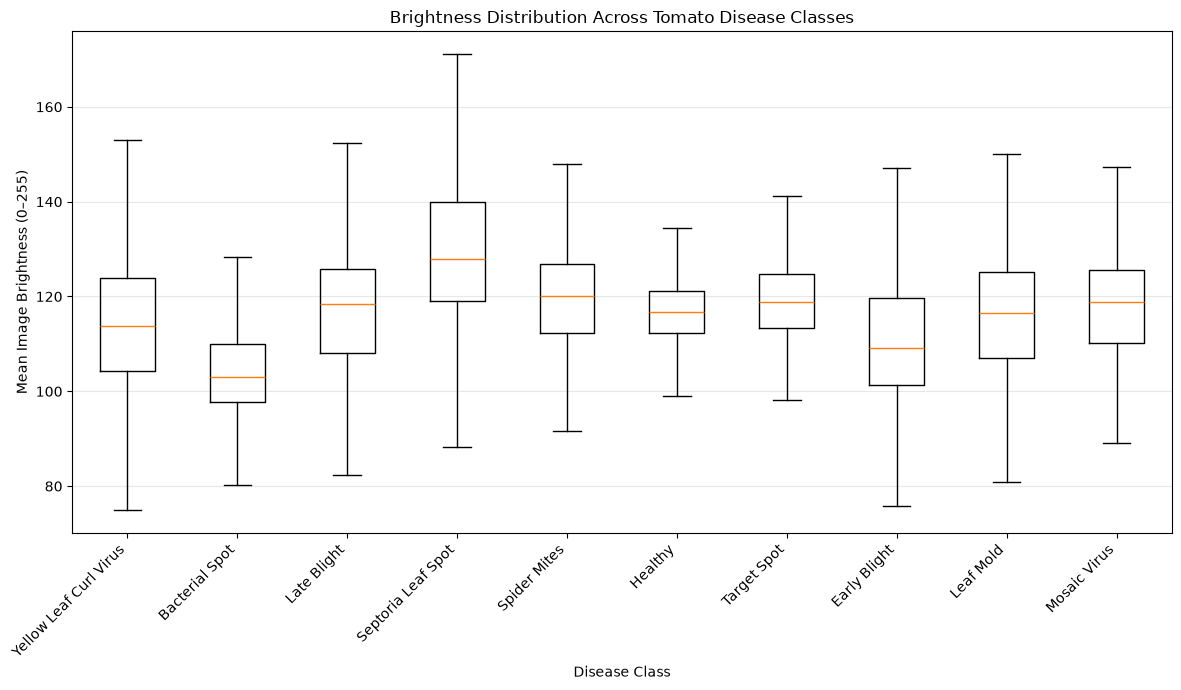

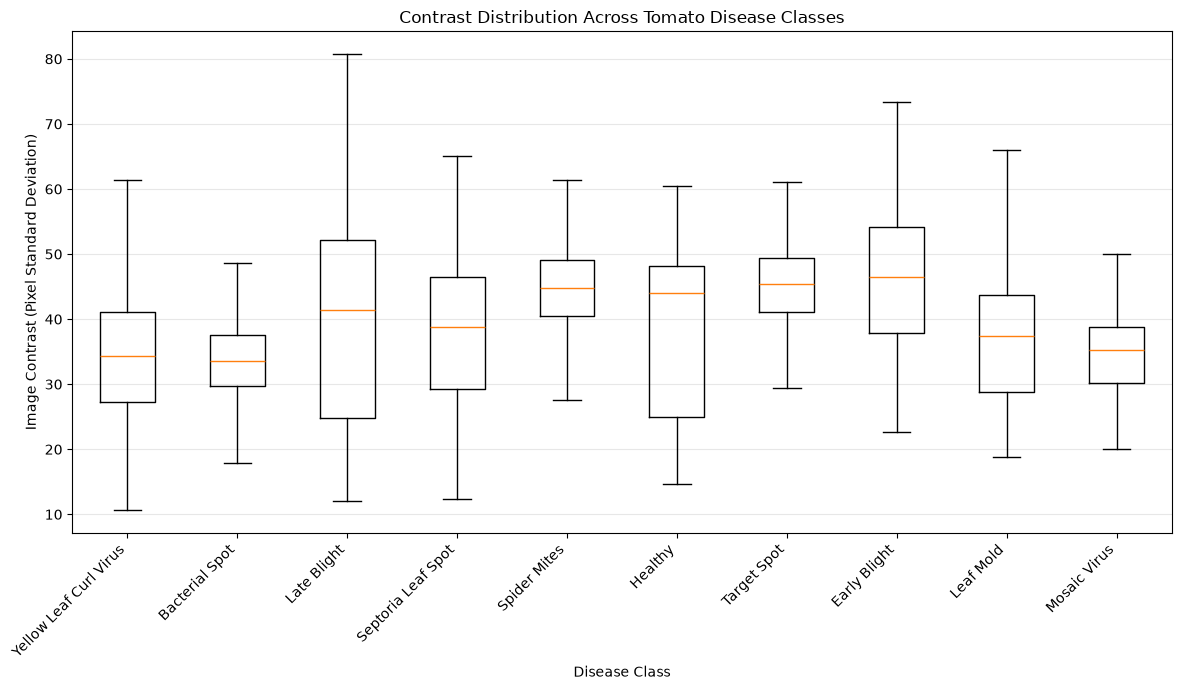

PART 6 — CLASS-WISE DISTRIBUTION VERIFICATION
Classes Analysed : 10
Images Analysed  : 15,997

Brightness Figure: D:\Tomato_Disease_Research\results\eda\class_brightness_boxplot.png
Contrast Figure  : D:\Tomato_Disease_Research\results\eda\class_contrast_boxplot.png
PASS — Class-wise brightness and contrast distributions verified.


In [ ]:
# ============================================================
# PART 6 — CLASS-WISE BRIGHTNESS & CONTRAST DISTRIBUTION
# ============================================================

EDA_BRIGHTNESS_BOXPLOT_PNG = (
    EDA_DIR / "class_brightness_boxplot.png"
)

EDA_CONTRAST_BOXPLOT_PNG = (
    EDA_DIR / "class_contrast_boxplot.png"
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — INPUT CHECK
# ------------------------------------------------------------

REQUIRED_COLUMNS = {
    "class",
    "brightness",
    "contrast"
}

missing_columns = (
    REQUIRED_COLUMNS
    - set(BRIGHTNESS_CONTRAST_DF.columns)
)

if missing_columns:

    raise RuntimeError(
        "Missing required columns: "
        f"{sorted(missing_columns)}"
    )


if len(BRIGHTNESS_CONTRAST_DF) != TOTAL_EDA_IMAGES:

    raise RuntimeError(
        "Brightness/contrast dataset size mismatch."
    )


if (
    BRIGHTNESS_CONTRAST_DF[
        [
            "brightness",
            "contrast"
        ]
    ]
    .isna()
    .any()
    .any()
):

    raise RuntimeError(
        "NaN detected in brightness/contrast values."
    )


# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

PLOT_CLASS_ORDER = (
    CLASS_DISTRIBUTION_DF[
        "class"
    ]
    .tolist()
)


DISPLAY_CLASS_ORDER = [
    CLASS_DISPLAY_NAMES[
        class_name
    ]
    for class_name in PLOT_CLASS_ORDER
]


# ------------------------------------------------------------
# PREPARE BRIGHTNESS VALUES
# ------------------------------------------------------------

BRIGHTNESS_BY_CLASS = [
    BRIGHTNESS_CONTRAST_DF.loc[
        BRIGHTNESS_CONTRAST_DF[
            "class"
        ] == class_name,
        "brightness"
    ].to_numpy()

    for class_name
    in PLOT_CLASS_ORDER
]


# ------------------------------------------------------------
# PREPARE CONTRAST VALUES
# ------------------------------------------------------------

CONTRAST_BY_CLASS = [
    BRIGHTNESS_CONTRAST_DF.loc[
        BRIGHTNESS_CONTRAST_DF[
            "class"
        ] == class_name,
        "contrast"
    ].to_numpy()

    for class_name
    in PLOT_CLASS_ORDER
]


# ------------------------------------------------------------
# RESEARCH VALIDATION — CLASS COVERAGE
# ------------------------------------------------------------

if any(
    len(values) == 0
    for values in BRIGHTNESS_BY_CLASS
):

    raise RuntimeError(
        "One or more classes contain no brightness values."
    )


if sum(
    len(values)
    for values in BRIGHTNESS_BY_CLASS
) != TOTAL_EDA_IMAGES:

    raise RuntimeError(
        "Class-wise brightness counts do not "
        "match total EDA images."
    )


# ============================================================
# BRIGHTNESS BOXPLOT
# ============================================================

plt.figure(
    figsize=(12, 7)
)

plt.boxplot(
    BRIGHTNESS_BY_CLASS,
    tick_labels=DISPLAY_CLASS_ORDER,
    showfliers=False
)

plt.ylabel(
    "Mean Image Brightness (0–255)"
)

plt.xlabel(
    "Disease Class"
)

plt.title(
    "Brightness Distribution Across Tomato Disease Classes"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    EDA_BRIGHTNESS_BOXPLOT_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CONTRAST BOXPLOT
# ============================================================

plt.figure(
    figsize=(12, 7)
)

plt.boxplot(
    CONTRAST_BY_CLASS,
    tick_labels=DISPLAY_CLASS_ORDER,
    showfliers=False
)

plt.ylabel(
    "Image Contrast (Pixel Standard Deviation)"
)

plt.xlabel(
    "Disease Class"
)

plt.title(
    "Contrast Distribution Across Tomato Disease Classes"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    EDA_CONTRAST_BOXPLOT_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

if not EDA_BRIGHTNESS_BOXPLOT_PNG.exists():

    raise RuntimeError(
        "Brightness boxplot was not saved."
    )


if not EDA_CONTRAST_BOXPLOT_PNG.exists():

    raise RuntimeError(
        "Contrast boxplot was not saved."
    )


print("=" * 70)
print("PART 6 — CLASS-WISE DISTRIBUTION VERIFICATION")
print("=" * 70)

print(
    "Classes Analysed :",
    len(PLOT_CLASS_ORDER)
)

print(
    "Images Analysed  :",
    f"{TOTAL_EDA_IMAGES:,}"
)

print()

print(
    "Brightness Figure:",
    EDA_BRIGHTNESS_BOXPLOT_PNG
)

print(
    "Contrast Figure  :",
    EDA_CONTRAST_BOXPLOT_PNG
)

print("=" * 70)

print(
    "PASS — Class-wise brightness and "
    "contrast distributions verified."
)

PART 6 — RGB COLOR CHANNEL SCAN
Scanning 15,997 unique images...

Scanned 2,000/15,997
Scanned 4,000/15,997
Scanned 6,000/15,997
Scanned 8,000/15,997
Scanned 10,000/15,997
Scanned 12,000/15,997
Scanned 14,000/15,997
Scanned 15,997/15,997


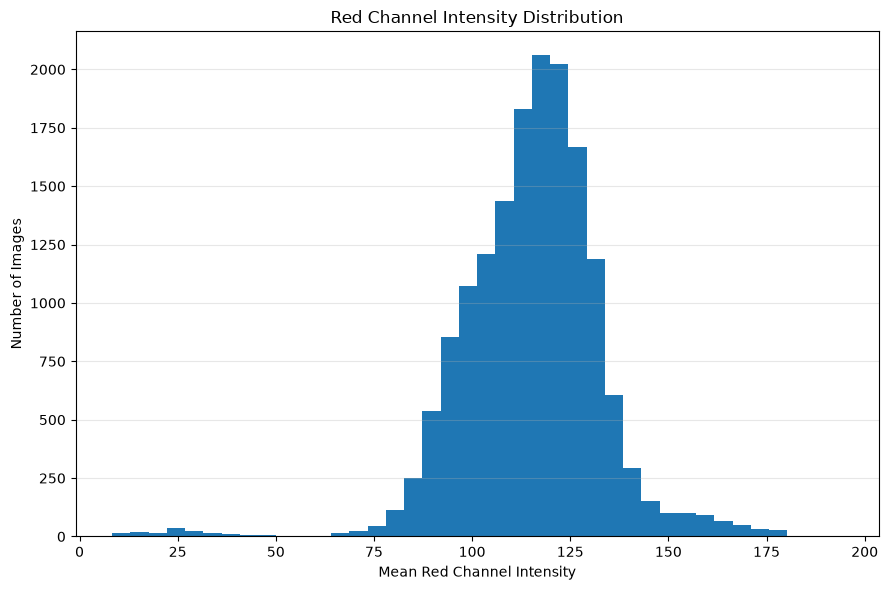

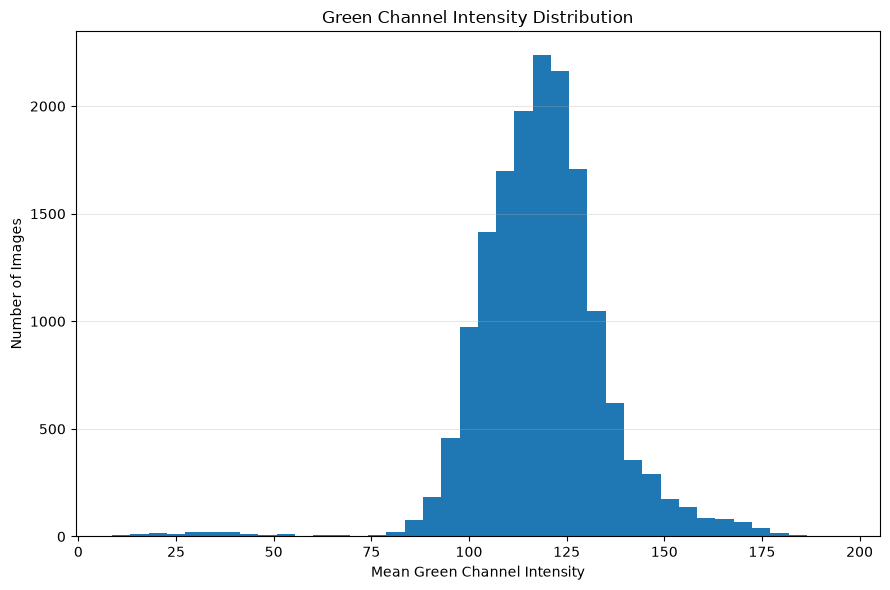

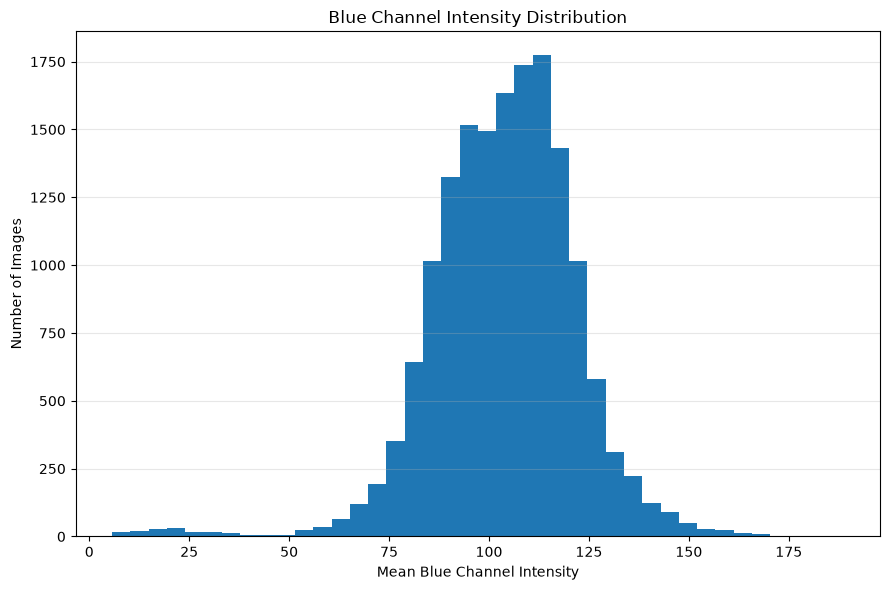


PART 6 — RGB COLOR CHANNEL SUMMARY
Images Analysed   : 15,997

Mean Red Channel  : 115.07
Mean Green Channel: 118.58
Mean Blue Channel : 103.77

Dominant Mean Channel: Green



,display_name,mean_red,mean_green,mean_blue,image_count
0,Bacterial Spot,101.966130,108.668254,93.261078,2127
1,Early Blight,109.333910,113.035147,101.258372,1000
2,Late Blight,114.259187,115.349632,103.008924,1901
3,Leaf Mold,112.087267,117.227910,114.718515,952
4,Septoria Leaf Spot,131.032253,133.070353,119.316735,1771
5,Spider Mites,122.916386,119.651030,107.660612,1676
6,Target Spot,118.915709,120.036321,111.671077,1404
7,Yellow Leaf Curl Virus,112.434157,120.171928,89.999080,3208
8,Mosaic Virus,118.709122,116.636025,117.400767,373
9,Healthy,113.950473,118.639904,109.966343,1585



Image-level CSV: D:\Tomato_Disease_Research\results\eda\rgb_channel_analysis.csv
Class Summary CSV: D:\Tomato_Disease_Research\results\eda\rgb_class_summary.csv
PASS — RGB channel analysis verified.


In [ ]:
# ============================================================
# PART 6 — RGB COLOR CHANNEL ANALYSIS
# ============================================================

EDA_RGB_ANALYSIS_CSV = (
    EDA_DIR / "rgb_channel_analysis.csv"
)

EDA_RGB_CLASS_SUMMARY_CSV = (
    EDA_DIR / "rgb_class_summary.csv"
)

EDA_RED_DISTRIBUTION_PNG = (
    EDA_DIR / "red_channel_distribution.png"
)

EDA_GREEN_DISTRIBUTION_PNG = (
    EDA_DIR / "green_channel_distribution.png"
)

EDA_BLUE_DISTRIBUTION_PNG = (
    EDA_DIR / "blue_channel_distribution.png"
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — INPUT CHECK
# ------------------------------------------------------------

REQUIRED_RGB_COLUMNS = {
    "image_path",
    "class"
}

missing_columns = (
    REQUIRED_RGB_COLUMNS
    - set(EDA_DATASET_DF.columns)
)

if missing_columns:

    raise RuntimeError(
        "Missing required columns: "
        f"{sorted(missing_columns)}"
    )


if len(EDA_DATASET_DF) != TOTAL_EDA_IMAGES:

    raise RuntimeError(
        "EDA dataset size mismatch before RGB analysis."
    )


# ------------------------------------------------------------
# RGB SCAN
# ------------------------------------------------------------

RGB_CHANNEL_RECORDS = []


print("=" * 70)
print("PART 6 — RGB COLOR CHANNEL SCAN")
print("=" * 70)

print(
    f"Scanning {TOTAL_EDA_IMAGES:,} unique images..."
)

print()


for index, (
    image_path_value,
    class_name
) in enumerate(

    EDA_DATASET_DF[
        [
            "image_path",
            "class"
        ]
    ].itertuples(
        index=False,
        name=None
    ),

    start=1
):

    image_path = Path(
        image_path_value
    )


    # --------------------------------------------------------
    # LOAD RGB IMAGE
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        rgb_array = np.asarray(
            image.convert("RGB"),
            dtype=np.float32
        )


    # --------------------------------------------------------
    # CHANNEL MEANS
    # --------------------------------------------------------

    red_mean = float(
        rgb_array[
            :, :, 0
        ].mean()
    )

    green_mean = float(
        rgb_array[
            :, :, 1
        ].mean()
    )

    blue_mean = float(
        rgb_array[
            :, :, 2
        ].mean()
    )


    # --------------------------------------------------------
    # CHANNEL STANDARD DEVIATIONS
    # --------------------------------------------------------

    red_std = float(
        rgb_array[
            :, :, 0
        ].std()
    )

    green_std = float(
        rgb_array[
            :, :, 1
        ].std()
    )

    blue_std = float(
        rgb_array[
            :, :, 2
        ].std()
    )


    # --------------------------------------------------------
    # SAVE IMAGE-LEVEL RECORD
    # --------------------------------------------------------

    RGB_CHANNEL_RECORDS.append(
        {
            "image_path": str(
                image_path
            ),

            "class": class_name,

            "red_mean": red_mean,

            "green_mean": green_mean,

            "blue_mean": blue_mean,

            "red_std": red_std,

            "green_std": green_std,

            "blue_std": blue_std
        }
    )


    # --------------------------------------------------------
    # PROGRESS DISPLAY
    # --------------------------------------------------------

    if (
        index % 2000 == 0
        or
        index == TOTAL_EDA_IMAGES
    ):

        print(
            f"Scanned "
            f"{index:,}/"
            f"{TOTAL_EDA_IMAGES:,}"
        )


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

RGB_CHANNEL_DF = pd.DataFrame(
    RGB_CHANNEL_RECORDS
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — ROW COUNT
# ------------------------------------------------------------

if len(RGB_CHANNEL_DF) != TOTAL_EDA_IMAGES:

    raise RuntimeError(
        "RGB analysis row count mismatch."
    )


# ------------------------------------------------------------
# RESEARCH VALIDATION — NaN CHECK
# ------------------------------------------------------------

RGB_NUMERIC_COLUMNS = [
    "red_mean",
    "green_mean",
    "blue_mean",
    "red_std",
    "green_std",
    "blue_std"
]


if (
    RGB_CHANNEL_DF[
        RGB_NUMERIC_COLUMNS
    ]
    .isna()
    .any()
    .any()
):

    raise RuntimeError(
        "NaN values detected in RGB analysis."
    )


# ------------------------------------------------------------
# RESEARCH VALIDATION — INTENSITY RANGE
# ------------------------------------------------------------

for channel in [
    "red_mean",
    "green_mean",
    "blue_mean"
]:

    if not (
        RGB_CHANNEL_DF[
            channel
        ]
        .between(
            0,
            255
        )
        .all()
    ):

        raise RuntimeError(
            f"Invalid intensity values detected "
            f"in {channel}."
        )


# ------------------------------------------------------------
# RESEARCH VALIDATION — STANDARD DEVIATION
# ------------------------------------------------------------

for channel in [
    "red_std",
    "green_std",
    "blue_std"
]:

    if (
        RGB_CHANNEL_DF[
            channel
        ] < 0
    ).any():

        raise RuntimeError(
            f"Negative standard deviation "
            f"detected in {channel}."
        )


# ------------------------------------------------------------
# SAVE IMAGE-LEVEL RGB DATA
# ------------------------------------------------------------

RGB_CHANNEL_DF.to_csv(
    EDA_RGB_ANALYSIS_CSV,
    index=False
)


# ============================================================
# CLASS-WISE RGB SUMMARY
# ============================================================

RGB_CLASS_SUMMARY_DF = (
    RGB_CHANNEL_DF
    .groupby(
        "class"
    )
    .agg(
        mean_red=(
            "red_mean",
            "mean"
        ),

        std_red=(
            "red_mean",
            "std"
        ),

        mean_green=(
            "green_mean",
            "mean"
        ),

        std_green=(
            "green_mean",
            "std"
        ),

        mean_blue=(
            "blue_mean",
            "mean"
        ),

        std_blue=(
            "blue_mean",
            "std"
        ),

        image_count=(
            "image_path",
            "count"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# READABLE CLASS NAMES
# ------------------------------------------------------------

RGB_CLASS_SUMMARY_DF[
    "display_name"
] = (
    RGB_CLASS_SUMMARY_DF[
        "class"
    ]
    .map(
        CLASS_DISPLAY_NAMES
    )
)


if (
    RGB_CLASS_SUMMARY_DF[
        "display_name"
    ]
    .isna()
    .any()
):

    raise RuntimeError(
        "Missing readable class name "
        "in RGB class summary."
    )


# ------------------------------------------------------------
# CLASS COUNT VERIFICATION
# ------------------------------------------------------------

if len(RGB_CLASS_SUMMARY_DF) != 10:

    raise RuntimeError(
        "Expected RGB statistics for 10 classes, "
        f"found {len(RGB_CLASS_SUMMARY_DF)}."
    )


if (
    RGB_CLASS_SUMMARY_DF[
        "image_count"
    ].sum()
    != TOTAL_EDA_IMAGES
):

    raise RuntimeError(
        "RGB class-wise image counts "
        "do not match total images."
    )


# ------------------------------------------------------------
# SAVE CLASS-WISE SUMMARY
# ------------------------------------------------------------

RGB_CLASS_SUMMARY_DF.to_csv(
    EDA_RGB_CLASS_SUMMARY_CSV,
    index=False
)


# ============================================================
# RED CHANNEL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    RGB_CHANNEL_DF[
        "red_mean"
    ],
    bins=40
)

plt.xlabel(
    "Mean Red Channel Intensity"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Red Channel Intensity Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    EDA_RED_DISTRIBUTION_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GREEN CHANNEL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    RGB_CHANNEL_DF[
        "green_mean"
    ],
    bins=40
)

plt.xlabel(
    "Mean Green Channel Intensity"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Green Channel Intensity Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    EDA_GREEN_DISTRIBUTION_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# BLUE CHANNEL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    RGB_CHANNEL_DF[
        "blue_mean"
    ],
    bins=40
)

plt.xlabel(
    "Mean Blue Channel Intensity"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Blue Channel Intensity Distribution"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    EDA_BLUE_DISTRIBUTION_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# OVERALL RGB STATISTICS
# ============================================================

OVERALL_RED_MEAN = (
    RGB_CHANNEL_DF[
        "red_mean"
    ].mean()
)

OVERALL_GREEN_MEAN = (
    RGB_CHANNEL_DF[
        "green_mean"
    ].mean()
)

OVERALL_BLUE_MEAN = (
    RGB_CHANNEL_DF[
        "blue_mean"
    ].mean()
)


# ------------------------------------------------------------
# DOMINANT MEAN CHANNEL
# ------------------------------------------------------------

OVERALL_CHANNEL_MEANS = {
    "Red": OVERALL_RED_MEAN,
    "Green": OVERALL_GREEN_MEAN,
    "Blue": OVERALL_BLUE_MEAN
}

DOMINANT_CHANNEL = max(
    OVERALL_CHANNEL_MEANS,
    key=OVERALL_CHANNEL_MEANS.get
)


# ------------------------------------------------------------
# SAVED FILE VERIFICATION
# ------------------------------------------------------------

REQUIRED_RGB_OUTPUTS = [
    EDA_RGB_ANALYSIS_CSV,
    EDA_RGB_CLASS_SUMMARY_CSV,
    EDA_RED_DISTRIBUTION_PNG,
    EDA_GREEN_DISTRIBUTION_PNG,
    EDA_BLUE_DISTRIBUTION_PNG
]


missing_outputs = [
    output_path
    for output_path
    in REQUIRED_RGB_OUTPUTS
    if not output_path.exists()
]


if missing_outputs:

    raise RuntimeError(
        "Missing RGB output files: "
        f"{missing_outputs}"
    )


# ------------------------------------------------------------
# FINAL RESEARCH SUMMARY
# ------------------------------------------------------------

print()

print("=" * 70)
print("PART 6 — RGB COLOR CHANNEL SUMMARY")
print("=" * 70)

print(
    "Images Analysed   :",
    f"{len(RGB_CHANNEL_DF):,}"
)

print()

print(
    "Mean Red Channel  :",
    f"{OVERALL_RED_MEAN:.2f}"
)

print(
    "Mean Green Channel:",
    f"{OVERALL_GREEN_MEAN:.2f}"
)

print(
    "Mean Blue Channel :",
    f"{OVERALL_BLUE_MEAN:.2f}"
)

print()

print(
    "Dominant Mean Channel:",
    DOMINANT_CHANNEL
)

print()

display(
    RGB_CLASS_SUMMARY_DF[
        [
            "display_name",
            "mean_red",
            "mean_green",
            "mean_blue",
            "image_count"
        ]
    ]
)

print()

print(
    "Image-level CSV:",
    EDA_RGB_ANALYSIS_CSV
)

print(
    "Class Summary CSV:",
    EDA_RGB_CLASS_SUMMARY_CSV
)

print("=" * 70)

print(
    "PASS — RGB channel analysis verified."
)

In [ ]:
# ============================================================
# PART 6 — FINAL EDA RESEARCH SUMMARY
# ============================================================

import json


EDA_FINAL_SUMMARY_CSV = (
    EDA_DIR / "final_eda_summary.csv"
)

EDA_FINAL_SUMMARY_JSON = (
    EDA_DIR / "final_eda_summary.json"
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — CORE COUNTS
# ------------------------------------------------------------

if TOTAL_EDA_IMAGES != 15997:

    raise RuntimeError(
        f"Expected 15,997 deduplicated images, "
        f"found {TOTAL_EDA_IMAGES:,}."
    )


if NUM_CLASSES_EDA != 10:

    raise RuntimeError(
        f"Expected 10 classes, found {NUM_CLASSES_EDA}."
    )


if (
    CLASS_DISTRIBUTION_DF[
        "image_count"
    ].sum()
    != TOTAL_EDA_IMAGES
):

    raise RuntimeError(
        "Class counts do not match "
        "the total EDA dataset size."
    )


if (
    len(IMAGE_METADATA_DF)
    != TOTAL_EDA_IMAGES
):

    raise RuntimeError(
        "Metadata count does not match "
        "the total EDA dataset size."
    )


if (
    len(BRIGHTNESS_CONTRAST_DF)
    != TOTAL_EDA_IMAGES
):

    raise RuntimeError(
        "Brightness/contrast count mismatch."
    )


if (
    len(RGB_CHANNEL_DF)
    != TOTAL_EDA_IMAGES
):

    raise RuntimeError(
        "RGB analysis count mismatch."
    )


# ------------------------------------------------------------
# IMAGE PROPERTY VALIDATION
# ------------------------------------------------------------

UNIQUE_WIDTHS = sorted(
    IMAGE_METADATA_DF[
        "width"
    ].unique()
)

UNIQUE_HEIGHTS = sorted(
    IMAGE_METADATA_DF[
        "height"
    ].unique()
)

UNIQUE_MODES = sorted(
    IMAGE_METADATA_DF[
        "mode"
    ].unique()
)

UNIQUE_FORMATS = sorted(
    IMAGE_METADATA_DF[
        "format"
    ].unique()
)


if UNIQUE_WIDTHS != [256]:

    raise RuntimeError(
        f"Unexpected image widths: {UNIQUE_WIDTHS}"
    )


if UNIQUE_HEIGHTS != [256]:

    raise RuntimeError(
        f"Unexpected image heights: {UNIQUE_HEIGHTS}"
    )


if UNIQUE_MODES != ["RGB"]:

    raise RuntimeError(
        f"Unexpected image modes: {UNIQUE_MODES}"
    )


if UNIQUE_FORMATS != ["JPEG"]:

    raise RuntimeError(
        f"Unexpected image formats: {UNIQUE_FORMATS}"
    )


# ------------------------------------------------------------
# IDENTIFY CLASS EXTREMES
# ------------------------------------------------------------

LARGEST_CLASS_ROW = (
    CLASS_DISTRIBUTION_DF
    .loc[
        CLASS_DISTRIBUTION_DF[
            "image_count"
        ].idxmax()
    ]
)

SMALLEST_CLASS_ROW = (
    CLASS_DISTRIBUTION_DF
    .loc[
        CLASS_DISTRIBUTION_DF[
            "image_count"
        ].idxmin()
    ]
)


LARGEST_CLASS_NAME = (
    CLASS_DISPLAY_NAMES.get(
        LARGEST_CLASS_ROW["class"],
        LARGEST_CLASS_ROW["class"]
    )
)

SMALLEST_CLASS_NAME = (
    CLASS_DISPLAY_NAMES.get(
        SMALLEST_CLASS_ROW["class"],
        SMALLEST_CLASS_ROW["class"]
    )
)


# ------------------------------------------------------------
# FINAL EDA SUMMARY
# ------------------------------------------------------------

EDA_FINAL_SUMMARY = {
    "raw_images": 16011,

    "exact_redundant_duplicates": int(
        TOTAL_REDUNDANT_IMAGES
    ),

    "deduplicated_images": int(
        TOTAL_EDA_IMAGES
    ),

    "number_of_classes": int(
        NUM_CLASSES_EDA
    ),

    "image_width": 256,

    "image_height": 256,

    "image_mode": "RGB",

    "image_format": "JPEG",

    "largest_class": (
        LARGEST_CLASS_NAME
    ),

    "largest_class_count": int(
        LARGEST_CLASS_ROW[
            "image_count"
        ]
    ),

    "largest_class_percentage": float(
        LARGEST_CLASS_ROW[
            "percentage"
        ]
    ),

    "smallest_class": (
        SMALLEST_CLASS_NAME
    ),

    "smallest_class_count": int(
        SMALLEST_CLASS_ROW[
            "image_count"
        ]
    ),

    "smallest_class_percentage": float(
        SMALLEST_CLASS_ROW[
            "percentage"
        ]
    ),

    "class_imbalance_ratio": float(
        CLASS_IMBALANCE_RATIO
    ),

    "mean_brightness": float(
        MEAN_BRIGHTNESS
    ),

    "brightness_std": float(
        STD_BRIGHTNESS
    ),

    "minimum_brightness": float(
        MIN_BRIGHTNESS
    ),

    "maximum_brightness": float(
        MAX_BRIGHTNESS
    ),

    "mean_contrast": float(
        MEAN_CONTRAST
    ),

    "contrast_std": float(
        STD_CONTRAST
    ),

    "minimum_contrast": float(
        MIN_CONTRAST
    ),

    "maximum_contrast": float(
        MAX_CONTRAST
    ),

    "mean_red_channel": float(
        OVERALL_RED_MEAN
    ),

    "mean_green_channel": float(
        OVERALL_GREEN_MEAN
    ),

    "mean_blue_channel": float(
        OVERALL_BLUE_MEAN
    ),

    "dominant_mean_channel": (
        DOMINANT_CHANNEL
    )
}


# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

EDA_FINAL_SUMMARY_DF = pd.DataFrame(
    [
        EDA_FINAL_SUMMARY
    ]
)


EDA_FINAL_SUMMARY_DF.to_csv(
    EDA_FINAL_SUMMARY_CSV,
    index=False
)


# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

with open(
    EDA_FINAL_SUMMARY_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        EDA_FINAL_SUMMARY,
        file,
        indent=4
    )


# ------------------------------------------------------------
# OUTPUT FILE VERIFICATION
# ------------------------------------------------------------

if not EDA_FINAL_SUMMARY_CSV.exists():

    raise RuntimeError(
        "Final EDA CSV was not saved."
    )


if not EDA_FINAL_SUMMARY_JSON.exists():

    raise RuntimeError(
        "Final EDA JSON was not saved."
    )


# ------------------------------------------------------------
# FINAL REPORT
# ------------------------------------------------------------

print("=" * 70)
print("PART 6 — FINAL EDA RESEARCH SUMMARY")
print("=" * 70)

print(
    "Raw Images             :",
    f"{EDA_FINAL_SUMMARY['raw_images']:,}"
)

print(
    "Exact Duplicates       :",
    EDA_FINAL_SUMMARY[
        "exact_redundant_duplicates"
    ]
)

print(
    "Unique Images          :",
    f"{EDA_FINAL_SUMMARY['deduplicated_images']:,}"
)

print(
    "Classes                :",
    EDA_FINAL_SUMMARY[
        "number_of_classes"
    ]
)

print()

print(
    "Image Resolution       :",
    "256 × 256"
)

print(
    "Image Mode             :",
    EDA_FINAL_SUMMARY[
        "image_mode"
    ]
)

print(
    "Image Format           :",
    EDA_FINAL_SUMMARY[
        "image_format"
    ]
)

print()

print(
    "Largest Class          :",
    EDA_FINAL_SUMMARY[
        "largest_class"
    ],
    f"({EDA_FINAL_SUMMARY['largest_class_count']:,})"
)

print(
    "Smallest Class         :",
    EDA_FINAL_SUMMARY[
        "smallest_class"
    ],
    f"({EDA_FINAL_SUMMARY['smallest_class_count']:,})"
)

print(
    "Class Imbalance Ratio  :",
    f"{EDA_FINAL_SUMMARY['class_imbalance_ratio']:.2f}:1"
)

print()

print(
    "Mean Brightness        :",
    f"{EDA_FINAL_SUMMARY['mean_brightness']:.2f}"
)

print(
    "Mean Contrast          :",
    f"{EDA_FINAL_SUMMARY['mean_contrast']:.2f}"
)

print()

print(
    "Mean Red Channel       :",
    f"{EDA_FINAL_SUMMARY['mean_red_channel']:.2f}"
)

print(
    "Mean Green Channel     :",
    f"{EDA_FINAL_SUMMARY['mean_green_channel']:.2f}"
)

print(
    "Mean Blue Channel      :",
    f"{EDA_FINAL_SUMMARY['mean_blue_channel']:.2f}"
)

print(
    "Dominant Mean Channel  :",
    EDA_FINAL_SUMMARY[
        "dominant_mean_channel"
    ]
)

print()

print(
    "CSV Saved :",
    EDA_FINAL_SUMMARY_CSV
)

print(
    "JSON Saved:",
    EDA_FINAL_SUMMARY_JSON
)

print()

print(
    "PASS — Dataset counts verified."
)

print(
    "PASS — Image properties verified."
)

print(
    "PASS — Class distribution verified."
)

print(
    "PASS — Brightness/contrast analysis verified."
)

print(
    "PASS — RGB channel analysis verified."
)

print()

print(
    "✓ PART 6 — EDA + VISUALIZATION COMPLETED"
)

print("=" * 70)

PART 6 — FINAL EDA RESEARCH SUMMARY
Raw Images             : 16,011
Exact Duplicates       : 14
Unique Images          : 15,997
Classes                : 10

Image Resolution       : 256 × 256
Image Mode             : RGB
Image Format           : JPEG

Largest Class          : Yellow Leaf Curl Virus (3,208)
Smallest Class         : Mosaic Virus (373)
Class Imbalance Ratio  : 8.60:1

Mean Brightness        : 115.84
Mean Contrast          : 38.63

Mean Red Channel       : 115.07
Mean Green Channel     : 118.58
Mean Blue Channel      : 103.77
Dominant Mean Channel  : Green

CSV Saved : D:\Tomato_Disease_Research\results\eda\final_eda_summary.csv
JSON Saved: D:\Tomato_Disease_Research\results\eda\final_eda_summary.json

PASS — Dataset counts verified.
PASS — Image properties verified.
PASS — Class distribution verified.
PASS — Brightness/contrast analysis verified.
PASS — RGB channel analysis verified.

✓ PART 6 — EDA + VISUALIZATION COMPLETED


# PART 7 — Clean Dataset Construction

This part constructs the final clean source-dataset inventory used for all
subsequent experiments.

The clean dataset is derived from the previously validated and exact-deduplicated
PlantVillage tomato subset. The original image files are kept unchanged to preserve
data integrity and avoid unnecessary re-encoding.

### Objectives

- Construct a deterministic clean dataset manifest
- Preserve the original PlantVillage image files
- Recompute MD5 hashes as an independent integrity verification
- Confirm that all image paths are valid
- Confirm that no exact duplicate remains
- Confirm that class counts match the EDA results
- Generate stable image identifiers
- Save reproducible clean-dataset metadata for subsequent splitting and training

### Expected Clean Dataset

- Original valid images: 16,011
- Removed redundant exact duplicates: 14
- Final unique images: 15,997
- Number of classes: 10
- Storage strategy: Manifest-based; original images remain untouched

In [ ]:
# ============================================================
# PART 7 — CLEAN DATASET CONSTRUCTION
# ============================================================

import hashlib
import json


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

EXPECTED_CLEAN_IMAGES = 15997
EXPECTED_NUM_CLASSES = 10


CLEAN_DATASET_MANIFEST_CSV = (
    PROCESSED_DATASET_DIR
    / "clean_dataset_manifest.csv"
)

CLEAN_DATASET_CLASS_SUMMARY_CSV = (
    RESULTS_DIR
    / "clean_dataset_class_summary.csv"
)

CLEAN_DATASET_VALIDATION_JSON = (
    RESULTS_DIR
    / "clean_dataset_validation.json"
)


PROCESSED_DATASET_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# RESEARCH VALIDATION — SOURCE DATA
# ------------------------------------------------------------

if "EDA_DATASET_DF" not in globals():

    raise RuntimeError(
        "EDA_DATASET_DF is not available. "
        "Run PART 6 before PART 7."
    )


required_columns = {
    "image_path",
    "class"
}

missing_columns = (
    required_columns
    - set(EDA_DATASET_DF.columns)
)


if missing_columns:

    raise RuntimeError(
        "Required source columns are missing: "
        f"{sorted(missing_columns)}"
    )


CLEAN_SOURCE_DF = (
    EDA_DATASET_DF[
        [
            "image_path",
            "class"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# SOURCE ROW COUNT VALIDATION
# ------------------------------------------------------------

if len(CLEAN_SOURCE_DF) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Unexpected number of source images. "
        f"Expected {EXPECTED_CLEAN_IMAGES:,}, "
        f"found {len(CLEAN_SOURCE_DF):,}."
    )


if (
    CLEAN_SOURCE_DF[
        "image_path"
    ]
    .isna()
    .any()
):

    raise RuntimeError(
        "Missing image paths detected."
    )


if (
    CLEAN_SOURCE_DF[
        "class"
    ]
    .isna()
    .any()
):

    raise RuntimeError(
        "Missing class labels detected."
    )


print("=" * 70)
print("PART 7 — CLEAN DATASET CONSTRUCTION")
print("=" * 70)

print(
    "Source Images:",
    f"{len(CLEAN_SOURCE_DF):,}"
)

print(
    "Expected Classes:",
    EXPECTED_NUM_CLASSES
)

print()

print(
    "Constructing clean manifest "
    "and independently verifying MD5 hashes..."
)

print()


# ------------------------------------------------------------
# MD5 HELPER
# ------------------------------------------------------------

def calculate_md5(
    file_path,
    chunk_size=1024 * 1024
):

    md5_hash = hashlib.md5()

    with open(
        file_path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:
                break

            md5_hash.update(
                chunk
            )

    return md5_hash.hexdigest()


# ------------------------------------------------------------
# CONSTRUCT CLEAN RECORDS
# ------------------------------------------------------------

CLEAN_DATASET_RECORDS = []

missing_files = []


plantvillage_root = (
    PLANTVILLAGE_DIR.resolve()
)


for index, (
    image_path_value,
    class_name
) in enumerate(

    CLEAN_SOURCE_DF[
        [
            "image_path",
            "class"
        ]
    ].itertuples(
        index=False,
        name=None
    ),

    start=1
):

    image_path = Path(
        image_path_value
    )


    # --------------------------------------------------------
    # FILE EXISTENCE VALIDATION
    # --------------------------------------------------------

    if not image_path.is_file():

        missing_files.append(
            str(image_path)
        )

        continue


    resolved_path = (
        image_path.resolve()
    )


    # --------------------------------------------------------
    # VERIFY IMAGE IS INSIDE PLANTVILLAGE ROOT
    # --------------------------------------------------------

    try:

        relative_path = (
            resolved_path
            .relative_to(
                plantvillage_root
            )
        )

    except ValueError:

        raise RuntimeError(
            "Image located outside PlantVillage dataset root: "
            f"{resolved_path}"
        )


    # --------------------------------------------------------
    # INDEPENDENT MD5 VERIFICATION
    # --------------------------------------------------------

    md5_hash = calculate_md5(
        resolved_path
    )


    # --------------------------------------------------------
    # STABLE CONTENT-BASED IMAGE ID
    # --------------------------------------------------------

    image_id = (
        "PV_"
        + md5_hash[:16]
    )


    CLEAN_DATASET_RECORDS.append(
        {
            "image_id": image_id,

            "image_path": str(
                resolved_path
            ),

            "relative_path": (
                relative_path.as_posix()
            ),

            "class": str(
                class_name
            ),

            "md5_hash": md5_hash
        }
    )


    # --------------------------------------------------------
    # PROGRESS
    # --------------------------------------------------------

    if (
        index % 2000 == 0
        or
        index == len(CLEAN_SOURCE_DF)
    ):

        print(
            f"Verified "
            f"{index:,}/"
            f"{len(CLEAN_SOURCE_DF):,}"
        )


# ------------------------------------------------------------
# MISSING FILE CHECK
# ------------------------------------------------------------

if missing_files:

    raise RuntimeError(
        f"{len(missing_files)} missing image files detected. "
        f"First example: {missing_files[0]}"
    )


# ------------------------------------------------------------
# CREATE CLEAN DATAFRAME
# ------------------------------------------------------------

CLEAN_DATASET_DF = pd.DataFrame(
    CLEAN_DATASET_RECORDS
)


# ------------------------------------------------------------
# DETERMINISTIC ORDER
# ------------------------------------------------------------

CLEAN_DATASET_DF = (
    CLEAN_DATASET_DF
    .sort_values(
        by=[
            "class",
            "relative_path"
        ]
    )
    .reset_index(
        drop=True
    )
)


print()

print(
    "PASS — Clean manifest records constructed."
)

PART 7 — CLEAN DATASET CONSTRUCTION
Source Images: 15,997
Expected Classes: 10

Constructing clean manifest and independently verifying MD5 hashes...

Verified 2,000/15,997
Verified 4,000/15,997
Verified 6,000/15,997
Verified 8,000/15,997
Verified 10,000/15,997
Verified 12,000/15,997
Verified 14,000/15,997
Verified 15,997/15,997

PASS — Clean manifest records constructed.


In [ ]:
# ============================================================
# PART 7 — CLEAN DATASET VALIDATION
# ============================================================

print("=" * 70)
print("PART 7 — RESEARCH VALIDATION / VERIFICATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. ROW COUNT
# ------------------------------------------------------------

manifest_rows = len(
    CLEAN_DATASET_DF
)


if manifest_rows != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Clean manifest row-count mismatch. "
        f"Expected {EXPECTED_CLEAN_IMAGES:,}, "
        f"found {manifest_rows:,}."
    )


print(
    "PASS — Manifest rows:",
    f"{manifest_rows:,}"
)


# ------------------------------------------------------------
# 2. CLASS COUNT
# ------------------------------------------------------------

clean_num_classes = (
    CLEAN_DATASET_DF[
        "class"
    ]
    .nunique()
)


if clean_num_classes != EXPECTED_NUM_CLASSES:

    raise RuntimeError(
        "Unexpected number of classes. "
        f"Expected {EXPECTED_NUM_CLASSES}, "
        f"found {clean_num_classes}."
    )


print(
    "PASS — Number of classes:",
    clean_num_classes
)


# ------------------------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------------------------

required_clean_columns = [
    "image_id",
    "image_path",
    "relative_path",
    "class",
    "md5_hash"
]


missing_value_counts = (
    CLEAN_DATASET_DF[
        required_clean_columns
    ]
    .isna()
    .sum()
)


if (
    missing_value_counts > 0
).any():

    raise RuntimeError(
        "Missing values detected in clean manifest:\n"
        f"{missing_value_counts}"
    )


print(
    "PASS — No missing manifest values."
)


# ------------------------------------------------------------
# 4. UNIQUE IMAGE PATHS
# ------------------------------------------------------------

duplicate_image_paths = int(
    CLEAN_DATASET_DF[
        "image_path"
    ]
    .duplicated()
    .sum()
)


if duplicate_image_paths != 0:

    raise RuntimeError(
        f"{duplicate_image_paths} duplicated "
        "image paths detected."
    )


print(
    "PASS — Duplicate image paths: 0"
)


# ------------------------------------------------------------
# 5. UNIQUE RELATIVE PATHS
# ------------------------------------------------------------

duplicate_relative_paths = int(
    CLEAN_DATASET_DF[
        "relative_path"
    ]
    .duplicated()
    .sum()
)


if duplicate_relative_paths != 0:

    raise RuntimeError(
        f"{duplicate_relative_paths} duplicated "
        "relative paths detected."
    )


print(
    "PASS — Duplicate relative paths: 0"
)


# ------------------------------------------------------------
# 6. EXACT DUPLICATE HASH CHECK
# ------------------------------------------------------------

duplicate_md5_hashes = int(
    CLEAN_DATASET_DF[
        "md5_hash"
    ]
    .duplicated()
    .sum()
)


if duplicate_md5_hashes != 0:

    duplicate_examples = (
        CLEAN_DATASET_DF[
            CLEAN_DATASET_DF[
                "md5_hash"
            ]
            .duplicated(
                keep=False
            )
        ]
        .sort_values(
            "md5_hash"
        )
    )

    raise RuntimeError(
        "Exact duplicates remain in the clean dataset.\n"
        f"{duplicate_examples.head()}"
    )


print(
    "PASS — Remaining exact duplicate hashes: 0"
)


# ------------------------------------------------------------
# 7. IMAGE ID UNIQUENESS
# ------------------------------------------------------------

duplicate_image_ids = int(
    CLEAN_DATASET_DF[
        "image_id"
    ]
    .duplicated()
    .sum()
)


if duplicate_image_ids != 0:

    raise RuntimeError(
        f"{duplicate_image_ids} image-ID "
        "collisions detected."
    )


print(
    "PASS — Image ID collisions: 0"
)


# ------------------------------------------------------------
# 8. FILE EXISTENCE RECHECK
# ------------------------------------------------------------

manifest_missing_files = int(
    sum(
        not Path(
            path
        ).is_file()

        for path
        in CLEAN_DATASET_DF[
            "image_path"
        ]
    )
)


if manifest_missing_files != 0:

    raise RuntimeError(
        f"{manifest_missing_files} manifest "
        "files are missing."
    )


print(
    "PASS — Missing physical files: 0"
)


# ------------------------------------------------------------
# 9. CLASS DISTRIBUTION
# ------------------------------------------------------------

CLEAN_DATASET_CLASS_SUMMARY_DF = (
    CLEAN_DATASET_DF[
        "class"
    ]
    .value_counts()
    .rename_axis(
        "class"
    )
    .reset_index(
        name="image_count"
    )
)


CLEAN_DATASET_CLASS_SUMMARY_DF[
    "percentage"
] = (
    CLEAN_DATASET_CLASS_SUMMARY_DF[
        "image_count"
    ]
    / manifest_rows
    * 100
)


# ------------------------------------------------------------
# 10. VERIFY CLASS COUNTS AGAINST PART 6
# ------------------------------------------------------------

part6_class_counts = dict(
    zip(
        CLASS_DISTRIBUTION_DF[
            "class"
        ],

        CLASS_DISTRIBUTION_DF[
            "image_count"
        ]
    )
)


part7_class_counts = dict(
    zip(
        CLEAN_DATASET_CLASS_SUMMARY_DF[
            "class"
        ],

        CLEAN_DATASET_CLASS_SUMMARY_DF[
            "image_count"
        ]
    )
)


class_distribution_match = (
    part6_class_counts
    == part7_class_counts
)


if not class_distribution_match:

    raise RuntimeError(
        "PART 7 class distribution does not "
        "match PART 6."
    )


print(
    "PASS — Class distribution matches PART 6."
)


# ------------------------------------------------------------
# 11. OPTIONAL PART 5 HASH CONSISTENCY CHECK
# ------------------------------------------------------------

part5_hash_consistency = None


if "DEDUPLICATED_HASHES" in globals():

    current_hashes = set(
        CLEAN_DATASET_DF[
            "md5_hash"
        ]
    )

    previous_hashes = set(
        DEDUPLICATED_HASHES
    )


    part5_hash_consistency = (
        current_hashes
        == previous_hashes
    )


    if not part5_hash_consistency:

        raise RuntimeError(
            "Independent MD5 scan does not "
            "match PART 5 deduplicated hashes."
        )


    print(
        "PASS — MD5 hashes match PART 5."
    )

else:

    print(
        "INFO — PART 5 hash set not available "
        "for optional cross-check."
    )


print()

display(
    CLEAN_DATASET_CLASS_SUMMARY_DF
)

PART 7 — RESEARCH VALIDATION / VERIFICATION
PASS — Manifest rows: 15,997
PASS — Number of classes: 10
PASS — No missing manifest values.
PASS — Duplicate image paths: 0
PASS — Duplicate relative paths: 0
PASS — Remaining exact duplicate hashes: 0
PASS — Image ID collisions: 0
PASS — Missing physical files: 0
PASS — Class distribution matches PART 6.
PASS — MD5 hashes match PART 5.



,class,image_count,percentage
0,Tomato__Tomato_YellowLeaf__Curl_Virus,3208,20.053760
1,Tomato_Bacterial_spot,2127,13.296243
2,Tomato_Late_blight,1901,11.883478
3,Tomato_Septoria_leaf_spot,1771,11.070826
4,Tomato_Spider_mites_Two_spotted_spider_mite,1676,10.476964
5,Tomato_healthy,1585,9.908108
6,Tomato__Target_Spot,1404,8.776646
7,Tomato_Early_blight,1000,6.251172
8,Tomato_Leaf_Mold,952,5.951116
9,Tomato__Tomato_mosaic_virus,373,2.331687


In [ ]:
# ============================================================
# PART 7 — SAVE CLEAN DATASET ARTIFACTS
# ============================================================


# ------------------------------------------------------------
# SAVE CLEAN MANIFEST
# ------------------------------------------------------------

CLEAN_DATASET_DF.to_csv(
    CLEAN_DATASET_MANIFEST_CSV,
    index=False
)


# ------------------------------------------------------------
# SAVE CLASS SUMMARY
# ------------------------------------------------------------

CLEAN_DATASET_CLASS_SUMMARY_DF.to_csv(
    CLEAN_DATASET_CLASS_SUMMARY_CSV,
    index=False
)


# ------------------------------------------------------------
# BUILD VALIDATION REPORT
# ------------------------------------------------------------

CLEAN_DATASET_VALIDATION = {

    "source_dataset": (
        "PlantVillage Tomato Subset"
    ),

    "storage_strategy": (
        "manifest_only_raw_images_untouched"
    ),

    "raw_valid_images": 16011,

    "removed_redundant_exact_duplicates": int(
        TOTAL_REDUNDANT_IMAGES
    ),

    "clean_manifest_rows": int(
        manifest_rows
    ),

    "number_of_classes": int(
        clean_num_classes
    ),

    "missing_manifest_values": int(
        missing_value_counts.sum()
    ),

    "duplicate_image_paths": int(
        duplicate_image_paths
    ),

    "duplicate_relative_paths": int(
        duplicate_relative_paths
    ),

    "duplicate_md5_hashes": int(
        duplicate_md5_hashes
    ),

    "duplicate_image_ids": int(
        duplicate_image_ids
    ),

    "missing_physical_files": int(
        manifest_missing_files
    ),

    "class_distribution_matches_part6": bool(
        class_distribution_match
    ),

    "part5_hash_consistency": (
        part5_hash_consistency
    )
}


# ------------------------------------------------------------
# SAVE VALIDATION JSON
# ------------------------------------------------------------

with open(
    CLEAN_DATASET_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        CLEAN_DATASET_VALIDATION,
        file,
        indent=4
    )


# ------------------------------------------------------------
# SAVED ARTIFACT VERIFICATION
# ------------------------------------------------------------

required_outputs = [
    CLEAN_DATASET_MANIFEST_CSV,
    CLEAN_DATASET_CLASS_SUMMARY_CSV,
    CLEAN_DATASET_VALIDATION_JSON
]


missing_outputs = [
    path
    for path
    in required_outputs
    if not path.exists()
]


if missing_outputs:

    raise RuntimeError(
        "Failed to save required PART 7 artifacts: "
        f"{missing_outputs}"
    )


# ------------------------------------------------------------
# RELOAD MANIFEST FOR STORAGE-INTEGRITY CHECK
# ------------------------------------------------------------

RELOADED_CLEAN_DATASET_DF = pd.read_csv(
    CLEAN_DATASET_MANIFEST_CSV,
    keep_default_na=False
)


if len(
    RELOADED_CLEAN_DATASET_DF
) != manifest_rows:

    raise RuntimeError(
        "Saved clean manifest row count changed "
        "after reloading."
    )


if (
    RELOADED_CLEAN_DATASET_DF[
        "md5_hash"
    ]
    .nunique()
    != manifest_rows
):

    raise RuntimeError(
        "Saved manifest contains non-unique hashes."
    )


# ------------------------------------------------------------
# FINAL PART 7 REPORT
# ------------------------------------------------------------

print("=" * 70)
print("PART 7 — CLEAN DATASET FINAL SUMMARY")
print("=" * 70)

print(
    "Raw Valid Images       :",
    f"{16011:,}"
)

print(
    "Exact Duplicates Removed:",
    int(
        TOTAL_REDUNDANT_IMAGES
    )
)

print(
    "Clean Dataset Images   :",
    f"{manifest_rows:,}"
)

print(
    "Classes                :",
    clean_num_classes
)

print()

print(
    "Missing Files          :",
    manifest_missing_files
)

print(
    "Duplicate Paths        :",
    duplicate_image_paths
)

print(
    "Duplicate MD5 Hashes   :",
    duplicate_md5_hashes
)

print(
    "Image ID Collisions    :",
    duplicate_image_ids
)

print()

print(
    "Storage Strategy       :",
    "Manifest only"
)

print(
    "Raw Images Modified    : No"
)

print(
    "Raw Images Copied      : No"
)

print()

print(
    "Manifest Saved:",
    CLEAN_DATASET_MANIFEST_CSV
)

print(
    "Class Summary :",
    CLEAN_DATASET_CLASS_SUMMARY_CSV
)

print(
    "Validation JSON:",
    CLEAN_DATASET_VALIDATION_JSON
)

print()

print(
    "PASS — Clean manifest verified."
)

print(
    "PASS — All physical files verified."
)

print(
    "PASS — No exact duplicates remain."
)

print(
    "PASS — Class distribution preserved."
)

print(
    "PASS — Saved manifest reloaded successfully."
)

print()

print(
    "✓ PART 7 — CLEAN DATASET CONSTRUCTION COMPLETED"
)

print("=" * 70)

PART 7 — CLEAN DATASET FINAL SUMMARY
Raw Valid Images       : 16,011
Exact Duplicates Removed: 14
Clean Dataset Images   : 15,997
Classes                : 10

Missing Files          : 0
Duplicate Paths        : 0
Duplicate MD5 Hashes   : 0
Image ID Collisions    : 0

Storage Strategy       : Manifest only
Raw Images Modified    : No
Raw Images Copied      : No

Manifest Saved: D:\Tomato_Disease_Research\processed_dataset\clean_dataset_manifest.csv
Class Summary : D:\Tomato_Disease_Research\results\clean_dataset_class_summary.csv
Validation JSON: D:\Tomato_Disease_Research\results\clean_dataset_validation.json

PASS — Clean manifest verified.
PASS — All physical files verified.
PASS — No exact duplicates remain.
PASS — Class distribution preserved.
PASS — Saved manifest reloaded successfully.

✓ PART 7 — CLEAN DATASET CONSTRUCTION COMPLETED


# PART 8 — Near-Duplicate-Aware Train / Validation / Test Split

This part creates the final internal experimental split from the verified
15,997-image clean PlantVillage tomato dataset.

A conventional stratified random split may place visually near-identical images
across training and evaluation subsets. Such leakage can produce overly optimistic
classification performance. Therefore, this study uses a perceptual-hash-aware
grouping strategy before splitting.

### Strategy

- Compute a 64-bit DCT-based perceptual hash (pHash) for every clean image
- Detect conservative near-duplicates using Hamming distance ≤ 4
- Merge connected near-duplicate images into image groups
- Prevent every near-duplicate group from crossing dataset partitions
- Stop for manual review if a near-duplicate group contains multiple class labels
- Perform deterministic class-stratified group assignment
- Use a 70% training, 15% validation, and 15% test target ratio
- Use seed 42 for reproducibility
- Keep the test set isolated for final model evaluation

### Research Validation

The split is verified for:

- Complete image coverage
- Split overlap
- Near-duplicate group leakage
- Class preservation
- Approximate split ratios
- Image-ID uniqueness
- MD5 uniqueness
- Reproducibility

In [ ]:
# ============================================================
# PART 8 — CONFIGURATION + PERCEPTUAL HASH COMPUTATION
# ============================================================

import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image


# ------------------------------------------------------------
# PART 8 CONFIGURATION
# ------------------------------------------------------------

EXPECTED_CLEAN_IMAGES = 15997
EXPECTED_NUM_CLASSES = 10

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

SPLIT_NAMES = [
    "train",
    "validation",
    "test"
]

SPLIT_RATIO_ARRAY = np.array(
    [
        TRAIN_RATIO,
        VALIDATION_RATIO,
        TEST_RATIO
    ],
    dtype=np.float64
)

SPLIT_RATIOS = {
    "train": TRAIN_RATIO,
    "validation": VALIDATION_RATIO,
    "test": TEST_RATIO
}

PHASH_HASH_SIZE = 8
PHASH_HIGHFREQ_FACTOR = 4

PHASH_IMAGE_SIZE = (
    PHASH_HASH_SIZE
    * PHASH_HIGHFREQ_FACTOR
)

PHASH_HAMMING_THRESHOLD = 4

# Maximum acceptable absolute deviation
# from target ratios.
SPLIT_RATIO_TOLERANCE = 0.03


# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

SPLITS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SPLIT_RESULTS_DIR = (
    RESULTS_DIR
    / "splits"
)

SPLIT_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# OUTPUT FILES
# ------------------------------------------------------------

PHASH_MANIFEST_CSV = (
    SPLIT_RESULTS_DIR
    / "phash_manifest.csv"
)

NEAR_DUPLICATE_GROUPS_CSV = (
    SPLIT_RESULTS_DIR
    / "near_duplicate_groups.csv"
)

NEAR_DUPLICATE_GROUP_SUMMARY_CSV = (
    SPLIT_RESULTS_DIR
    / "near_duplicate_group_summary.csv"
)

CROSS_CLASS_NEAR_DUPLICATE_CSV = (
    SPLIT_RESULTS_DIR
    / "cross_class_near_duplicate_groups.csv"
)

TRAIN_SPLIT_CSV = (
    SPLITS_DIR
    / "train_split.csv"
)

VALIDATION_SPLIT_CSV = (
    SPLITS_DIR
    / "validation_split.csv"
)

TEST_SPLIT_CSV = (
    SPLITS_DIR
    / "test_split.csv"
)

COMPLETE_SPLIT_CSV = (
    SPLITS_DIR
    / "complete_split_manifest.csv"
)

SPLIT_SUMMARY_CSV = (
    SPLIT_RESULTS_DIR
    / "split_summary.csv"
)

SPLIT_CLASS_DISTRIBUTION_CSV = (
    SPLIT_RESULTS_DIR
    / "split_class_distribution.csv"
)

PART8_VALIDATION_JSON = (
    SPLIT_RESULTS_DIR
    / "part8_split_validation.json"
)


# ============================================================
# LOAD PART 7 CLEAN DATASET
# ============================================================

if "CLEAN_DATASET_DF" not in globals():

    CLEAN_DATASET_MANIFEST_CSV = (
        PROCESSED_DATASET_DIR
        / "clean_dataset_manifest.csv"
    )

    if not CLEAN_DATASET_MANIFEST_CSV.exists():

        raise RuntimeError(
            "Clean dataset manifest not found. "
            "Run PART 7 first."
        )

    CLEAN_DATASET_DF = pd.read_csv(
        CLEAN_DATASET_MANIFEST_CSV,
        dtype=str,
        keep_default_na=False
    )


CLEAN_DATASET_DF = (
    CLEAN_DATASET_DF
    .copy()
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# REQUIRED COLUMN VALIDATION
# ------------------------------------------------------------

REQUIRED_CLEAN_COLUMNS = {
    "image_id",
    "image_path",
    "relative_path",
    "class",
    "md5_hash"
}

missing_columns = (
    REQUIRED_CLEAN_COLUMNS
    - set(
        CLEAN_DATASET_DF.columns
    )
)

if missing_columns:

    raise RuntimeError(
        "Missing clean-dataset columns: "
        f"{sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# DATASET SIZE VALIDATION
# ------------------------------------------------------------

if len(
    CLEAN_DATASET_DF
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        f"Expected {EXPECTED_CLEAN_IMAGES:,} images, "
        f"found {len(CLEAN_DATASET_DF):,}."
    )


# ------------------------------------------------------------
# CLASS VALIDATION
# ------------------------------------------------------------

if (
    CLEAN_DATASET_DF[
        "class"
    ].nunique()
    != EXPECTED_NUM_CLASSES
):

    raise RuntimeError(
        "Unexpected number of classes "
        "before splitting."
    )


# ------------------------------------------------------------
# EXACT DUPLICATE VALIDATION
# ------------------------------------------------------------

if (
    CLEAN_DATASET_DF[
        "md5_hash"
    ]
    .duplicated()
    .any()
):

    raise RuntimeError(
        "Exact duplicate hashes detected "
        "before PART 8."
    )


# ------------------------------------------------------------
# IMAGE-ID VALIDATION
# ------------------------------------------------------------

if (
    CLEAN_DATASET_DF[
        "image_id"
    ]
    .duplicated()
    .any()
):

    raise RuntimeError(
        "Duplicate image IDs detected."
    )


# ------------------------------------------------------------
# RATIO VALIDATION
# ------------------------------------------------------------

if not np.isclose(
    SPLIT_RATIO_ARRAY.sum(),
    1.0
):

    raise RuntimeError(
        "Train/validation/test ratios "
        "must sum to 1.0."
    )


# ============================================================
# DCT BACKEND
# ============================================================

try:

    from scipy.fft import dctn

    USE_SCIPY_DCT = True

    PHASH_BACKEND = (
        "scipy.fft.dctn"
    )

except ImportError:

    USE_SCIPY_DCT = False

    PHASH_BACKEND = (
        "numpy_dct_matrix"
    )


# ------------------------------------------------------------
# NUMPY DCT FALLBACK
# ------------------------------------------------------------

if not USE_SCIPY_DCT:

    n = PHASH_IMAGE_SIZE

    k = np.arange(
        n,
        dtype=np.float32
    )[:, None]

    i = np.arange(
        n,
        dtype=np.float32
    )[None, :]

    DCT_MATRIX = np.cos(
        (
            np.pi / n
        )
        * (
            i + 0.5
        )
        * k
    )

    DCT_MATRIX[
        0,
        :
    ] *= (
        1.0 / np.sqrt(2.0)
    )

    DCT_MATRIX *= np.sqrt(
        2.0 / n
    )

    DCT_MATRIX = (
        DCT_MATRIX
        .astype(
            np.float32
        )
    )


# ------------------------------------------------------------
# PIL RESAMPLING
# ------------------------------------------------------------

try:

    PHASH_RESAMPLING = (
        Image.Resampling.LANCZOS
    )

except AttributeError:

    PHASH_RESAMPLING = (
        Image.LANCZOS
    )


# ============================================================
# PERCEPTUAL HASH FUNCTION
# ============================================================

def compute_perceptual_hash(
    image_path
):

    with Image.open(
        image_path
    ) as image:

        grayscale_image = (
            image
            .convert("L")
            .resize(
                (
                    PHASH_IMAGE_SIZE,
                    PHASH_IMAGE_SIZE
                ),
                PHASH_RESAMPLING
            )
        )

        pixels = np.asarray(
            grayscale_image,
            dtype=np.float32
        )


    # --------------------------------------------------------
    # 2D DCT
    # --------------------------------------------------------

    if USE_SCIPY_DCT:

        dct_values = dctn(
            pixels,
            type=2,
            norm="ortho"
        )

    else:

        dct_values = (
            DCT_MATRIX
            @ pixels
            @ DCT_MATRIX.T
        )


    # --------------------------------------------------------
    # LOW-FREQUENCY DCT REGION
    # --------------------------------------------------------

    low_frequency = (
        dct_values[
            :PHASH_HASH_SIZE,
            :PHASH_HASH_SIZE
        ]
    )


    median_value = np.median(
        low_frequency
    )


    bits = (
        low_frequency
        > median_value
    ).flatten()


    # --------------------------------------------------------
    # 64-BIT INTEGER HASH
    # --------------------------------------------------------

    hash_integer = 0

    for bit in bits:

        hash_integer = (
            hash_integer << 1
        ) | int(
            bit
        )


    return hash_integer


# ============================================================
# COMPUTE pHASHES
# ============================================================

print("=" * 70)
print("PART 8 — PERCEPTUAL HASH SCAN")
print("=" * 70)

print(
    "Clean Images       :",
    f"{len(CLEAN_DATASET_DF):,}"
)

print(
    "Classes            :",
    EXPECTED_NUM_CLASSES
)

print(
    "pHash              : 64-bit DCT"
)

print(
    "Hamming Threshold  :",
    PHASH_HAMMING_THRESHOLD
)

print(
    "DCT Backend        :",
    PHASH_BACKEND
)

print()


PHASH_INTEGER_VALUES = []
PHASH_HEX_VALUES = []


for index, image_path_value in enumerate(

    CLEAN_DATASET_DF[
        "image_path"
    ],

    start=1
):

    image_path = Path(
        image_path_value
    )


    if not image_path.is_file():

        raise RuntimeError(
            "Missing image during pHash scan: "
            f"{image_path}"
        )


    phash_integer = (
        compute_perceptual_hash(
            image_path
        )
    )


    phash_hex = (
        f"{phash_integer:016x}"
    )


    PHASH_INTEGER_VALUES.append(
        phash_integer
    )

    PHASH_HEX_VALUES.append(
        phash_hex
    )


    if (
        index % 2000 == 0
        or
        index
        == len(CLEAN_DATASET_DF)
    ):

        print(
            f"Hashed "
            f"{index:,}/"
            f"{len(CLEAN_DATASET_DF):,}"
        )


# ------------------------------------------------------------
# ATTACH pHASH
# ------------------------------------------------------------

CLEAN_DATASET_DF[
    "phash"
] = PHASH_HEX_VALUES


# ------------------------------------------------------------
# pHASH VALIDATION
# ------------------------------------------------------------

if len(
    PHASH_INTEGER_VALUES
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "pHash count mismatch."
    )


if (
    CLEAN_DATASET_DF[
        "phash"
    ]
    .isna()
    .any()
):

    raise RuntimeError(
        "Missing pHash detected."
    )


if not (
    CLEAN_DATASET_DF[
        "phash"
    ]
    .str.len()
    .eq(16)
    .all()
):

    raise RuntimeError(
        "Invalid 64-bit pHash representation."
    )


# ------------------------------------------------------------
# SAVE pHASH MANIFEST
# ------------------------------------------------------------

PHASH_MANIFEST_DF = (
    CLEAN_DATASET_DF[
        [
            "image_id",
            "relative_path",
            "class",
            "md5_hash",
            "phash"
        ]
    ]
    .copy()
)


PHASH_MANIFEST_DF.to_csv(
    PHASH_MANIFEST_CSV,
    index=False
)


print()

print(
    "Unique pHash Values:",
    f"{CLEAN_DATASET_DF['phash'].nunique():,}"
)

print(
    "PASS — Perceptual hashes computed "
    "for all images."
)

print(
    "Saved:",
    PHASH_MANIFEST_CSV
)

PART 8 — PERCEPTUAL HASH SCAN
Clean Images       : 15,997
Classes            : 10
pHash              : 64-bit DCT
Hamming Threshold  : 4
DCT Backend        : scipy.fft.dctn

Hashed 2,000/15,997
Hashed 4,000/15,997
Hashed 6,000/15,997
Hashed 8,000/15,997
Hashed 10,000/15,997
Hashed 12,000/15,997
Hashed 14,000/15,997
Hashed 15,997/15,997

Unique pHash Values: 15,997
PASS — Perceptual hashes computed for all images.
Saved: D:\Tomato_Disease_Research\results\splits\phash_manifest.csv


In [ ]:
# ============================================================
# PART 8 — NEAR-DUPLICATE GROUP CONSTRUCTION
# ============================================================


# ============================================================
# HAMMING DISTANCE
# ============================================================

def hamming_distance(
    hash_a,
    hash_b
):

    return (
        hash_a
        ^ hash_b
    ).bit_count()


# ============================================================
# BK-TREE
# ============================================================

class BKTree:

    def __init__(
        self
    ):

        self.root = None


    def add(
        self,
        value
    ):

        if self.root is None:

            self.root = [
                value,
                {}
            ]

            return


        node = self.root


        while True:

            node_value = (
                node[0]
            )

            distance = (
                hamming_distance(
                    value,
                    node_value
                )
            )


            if distance == 0:

                return


            children = (
                node[1]
            )


            if distance in children:

                node = (
                    children[
                        distance
                    ]
                )

            else:

                children[
                    distance
                ] = [
                    value,
                    {}
                ]

                return


    def query(
        self,
        value,
        max_distance
    ):

        if self.root is None:

            return []


        matches = []

        stack = [
            self.root
        ]


        while stack:

            node = (
                stack.pop()
            )

            node_value = (
                node[0]
            )

            children = (
                node[1]
            )


            distance = (
                hamming_distance(
                    value,
                    node_value
                )
            )


            if distance <= max_distance:

                matches.append(
                    (
                        node_value,
                        distance
                    )
                )


            lower_bound = (
                distance
                - max_distance
            )

            upper_bound = (
                distance
                + max_distance
            )


            for (
                edge_distance,
                child
            ) in children.items():

                if (
                    lower_bound
                    <= edge_distance
                    <= upper_bound
                ):

                    stack.append(
                        child
                    )


        return matches


# ============================================================
# UNION-FIND
# ============================================================

class UnionFind:

    def __init__(
        self,
        size
    ):

        self.parent = list(
            range(size)
        )

        self.rank = [
            0
        ] * size


    def find(
        self,
        item
    ):

        while (
            self.parent[
                item
            ] != item
        ):

            self.parent[
                item
            ] = (
                self.parent[
                    self.parent[
                        item
                    ]
                ]
            )

            item = (
                self.parent[
                    item
                ]
            )


        return item


    def union(
        self,
        item_a,
        item_b
    ):

        root_a = (
            self.find(
                item_a
            )
        )

        root_b = (
            self.find(
                item_b
            )
        )


        if root_a == root_b:

            return


        if (
            self.rank[
                root_a
            ]
            <
            self.rank[
                root_b
            ]
        ):

            root_a, root_b = (
                root_b,
                root_a
            )


        self.parent[
            root_b
        ] = root_a


        if (
            self.rank[
                root_a
            ]
            ==
            self.rank[
                root_b
            ]
        ):

            self.rank[
                root_a
            ] += 1


# ============================================================
# MAP pHASH → ROW INDICES
# ============================================================

HASH_TO_ROW_INDICES = {}


for (
    row_index,
    hash_integer
) in enumerate(
    PHASH_INTEGER_VALUES
):

    HASH_TO_ROW_INDICES.setdefault(
        hash_integer,
        []
    ).append(
        row_index
    )


UNIQUE_PHASH_VALUES = sorted(
    HASH_TO_ROW_INDICES.keys()
)


# ============================================================
# BUILD BK-TREE
# ============================================================

print("=" * 70)
print("PART 8 — NEAR-DUPLICATE SEARCH")
print("=" * 70)

print(
    "Unique pHash Values:",
    f"{len(UNIQUE_PHASH_VALUES):,}"
)

print(
    "Threshold          :",
    f"≤ {PHASH_HAMMING_THRESHOLD}"
)

print()

print(
    "Building pHash search tree..."
)


PHASH_TREE = (
    BKTree()
)


for hash_value in (
    UNIQUE_PHASH_VALUES
):

    PHASH_TREE.add(
        hash_value
    )


print(
    "PASS — Search tree constructed."
)


# ============================================================
# UNION-FIND INITIALIZATION
# ============================================================

NEAR_DUPLICATE_UF = (
    UnionFind(
        len(
            CLEAN_DATASET_DF
        )
    )
)


# ------------------------------------------------------------
# IDENTICAL pHASH VALUES
# ------------------------------------------------------------

for row_indices in (
    HASH_TO_ROW_INDICES.values()
):

    representative = (
        row_indices[0]
    )


    for other_index in (
        row_indices[1:]
    ):

        NEAR_DUPLICATE_UF.union(
            representative,
            other_index
        )


# ============================================================
# NEAR-NEIGHBOR SEARCH
# ============================================================

print()

print(
    "Searching for perceptually "
    "similar image pairs..."
)


PHASH_NEAR_LINK_COUNT = 0


for (
    query_number,
    hash_value
) in enumerate(
    UNIQUE_PHASH_VALUES,
    start=1
):

    matches = (
        PHASH_TREE.query(
            hash_value,
            PHASH_HAMMING_THRESHOLD
        )
    )


    source_index = (
        HASH_TO_ROW_INDICES[
            hash_value
        ][0]
    )


    for (
        matched_hash,
        distance
    ) in matches:

        # Each pair only once
        if matched_hash <= hash_value:

            continue


        matched_index = (
            HASH_TO_ROW_INDICES[
                matched_hash
            ][0]
        )


        NEAR_DUPLICATE_UF.union(
            source_index,
            matched_index
        )


        PHASH_NEAR_LINK_COUNT += 1


    if (
        query_number % 2000 == 0
        or
        query_number
        == len(
            UNIQUE_PHASH_VALUES
        )
    ):

        print(
            f"Searched "
            f"{query_number:,}/"
            f"{len(UNIQUE_PHASH_VALUES):,}"
        )


# ============================================================
# CONNECTED COMPONENTS
# ============================================================

COMPONENTS = {}


for row_index in range(
    len(
        CLEAN_DATASET_DF
    )
):

    root = (
        NEAR_DUPLICATE_UF.find(
            row_index
        )
    )


    COMPONENTS.setdefault(
        root,
        []
    ).append(
        row_index
    )


COMPONENT_LIST = list(
    COMPONENTS.values()
)


# ------------------------------------------------------------
# DETERMINISTIC COMPONENT ORDER
# ------------------------------------------------------------

COMPONENT_LIST.sort(
    key=lambda indices:
    min(
        CLEAN_DATASET_DF
        .iloc[
            indices
        ][
            "image_id"
        ]
        .tolist()
    )
)


# ============================================================
# ASSIGN STABLE GROUP IDs
# ============================================================

ROW_TO_GROUP_ID = {}


for (
    group_number,
    indices
) in enumerate(
    COMPONENT_LIST,
    start=1
):

    group_id = (
        f"NDG_{group_number:06d}"
    )


    for row_index in indices:

        ROW_TO_GROUP_ID[
            row_index
        ] = group_id


CLEAN_DATASET_DF[
    "near_duplicate_group"
] = [
    ROW_TO_GROUP_ID[
        row_index
    ]

    for row_index
    in range(
        len(
            CLEAN_DATASET_DF
        )
    )
]


# ============================================================
# GROUP STATISTICS
# ============================================================

GROUP_SIZE_SERIES = (
    CLEAN_DATASET_DF
    .groupby(
        "near_duplicate_group"
    )
    .size()
)


GROUP_CLASS_COUNT_SERIES = (
    CLEAN_DATASET_DF
    .groupby(
        "near_duplicate_group"
    )[
        "class"
    ]
    .nunique()
)


TOTAL_IMAGE_GROUPS = int(
    len(
        GROUP_SIZE_SERIES
    )
)


SINGLETON_GROUP_COUNT = int(
    (
        GROUP_SIZE_SERIES
        == 1
    ).sum()
)


NEAR_DUPLICATE_GROUP_COUNT = int(
    (
        GROUP_SIZE_SERIES
        > 1
    ).sum()
)


IMAGES_IN_NEAR_DUPLICATE_GROUPS = int(
    GROUP_SIZE_SERIES[
        GROUP_SIZE_SERIES
        > 1
    ].sum()
)


MAX_NEAR_DUPLICATE_GROUP_SIZE = int(
    GROUP_SIZE_SERIES.max()
)


CROSS_CLASS_GROUP_IDS = (
    GROUP_CLASS_COUNT_SERIES[
        GROUP_CLASS_COUNT_SERIES
        > 1
    ]
    .index
    .tolist()
)


CROSS_CLASS_GROUP_COUNT = int(
    len(
        CROSS_CLASS_GROUP_IDS
    )
)


# ============================================================
# NEAR-DUPLICATE MEMBER REPORT
# ============================================================

group_size_mapping = (
    GROUP_SIZE_SERIES
    .to_dict()
)

group_class_count_mapping = (
    GROUP_CLASS_COUNT_SERIES
    .to_dict()
)


NEAR_DUPLICATE_MEMBERS_DF = (
    CLEAN_DATASET_DF[
        CLEAN_DATASET_DF[
            "near_duplicate_group"
        ]
        .map(
            group_size_mapping
        )
        > 1
    ]
    [
        [
            "near_duplicate_group",
            "image_id",
            "relative_path",
            "class",
            "md5_hash",
            "phash"
        ]
    ]
    .copy()
)


NEAR_DUPLICATE_MEMBERS_DF[
    "group_size"
] = (
    NEAR_DUPLICATE_MEMBERS_DF[
        "near_duplicate_group"
    ]
    .map(
        group_size_mapping
    )
)


NEAR_DUPLICATE_MEMBERS_DF[
    "class_count"
] = (
    NEAR_DUPLICATE_MEMBERS_DF[
        "near_duplicate_group"
    ]
    .map(
        group_class_count_mapping
    )
)


NEAR_DUPLICATE_MEMBERS_DF = (
    NEAR_DUPLICATE_MEMBERS_DF
    .sort_values(
        [
            "near_duplicate_group",
            "class",
            "relative_path"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# GROUP SUMMARY
# ============================================================

NEAR_DUPLICATE_GROUP_SUMMARY_DF = (
    CLEAN_DATASET_DF
    .groupby(
        "near_duplicate_group"
    )
    .agg(
        group_size=(
            "image_id",
            "count"
        ),

        class_count=(
            "class",
            "nunique"
        ),

        unique_phashes=(
            "phash",
            "nunique"
        )
    )
    .reset_index()
)


NEAR_DUPLICATE_GROUP_SUMMARY_DF = (
    NEAR_DUPLICATE_GROUP_SUMMARY_DF[
        NEAR_DUPLICATE_GROUP_SUMMARY_DF[
            "group_size"
        ] > 1
    ]
    .reset_index(
        drop=True
    )
)


# ============================================================
# CROSS-CLASS GROUP REPORT
# ============================================================

if CROSS_CLASS_GROUP_COUNT > 0:

    CROSS_CLASS_NEAR_DUPLICATE_DF = (
        CLEAN_DATASET_DF[
            CLEAN_DATASET_DF[
                "near_duplicate_group"
            ]
            .isin(
                CROSS_CLASS_GROUP_IDS
            )
        ]
        [
            [
                "near_duplicate_group",
                "image_id",
                "relative_path",
                "class",
                "md5_hash",
                "phash"
            ]
        ]
        .copy()
        .sort_values(
            [
                "near_duplicate_group",
                "class",
                "relative_path"
            ]
        )
        .reset_index(
            drop=True
        )
    )

else:

    CROSS_CLASS_NEAR_DUPLICATE_DF = pd.DataFrame(
        columns=[
            "near_duplicate_group",
            "image_id",
            "relative_path",
            "class",
            "md5_hash",
            "phash"
        ]
    )


# ============================================================
# SAVE GROUP REPORTS
# ============================================================

NEAR_DUPLICATE_MEMBERS_DF.to_csv(
    NEAR_DUPLICATE_GROUPS_CSV,
    index=False
)


NEAR_DUPLICATE_GROUP_SUMMARY_DF.to_csv(
    NEAR_DUPLICATE_GROUP_SUMMARY_CSV,
    index=False
)


CROSS_CLASS_NEAR_DUPLICATE_DF.to_csv(
    CROSS_CLASS_NEAR_DUPLICATE_CSV,
    index=False
)


# ============================================================
# RESEARCH VALIDATION
# ============================================================

if (
    CLEAN_DATASET_DF[
        "near_duplicate_group"
    ]
    .isna()
    .any()
):

    raise RuntimeError(
        "Missing near-duplicate group assignment."
    )


if (
    GROUP_SIZE_SERIES.sum()
    != EXPECTED_CLEAN_IMAGES
):

    raise RuntimeError(
        "Group membership does not cover "
        "the complete dataset."
    )


# ============================================================
# SUMMARY
# ============================================================

print()

print("=" * 70)
print("PART 8 — NEAR-DUPLICATE GROUP SUMMARY")
print("=" * 70)

print(
    "Total Images                 :",
    f"{len(CLEAN_DATASET_DF):,}"
)

print(
    "Total Image Groups           :",
    f"{TOTAL_IMAGE_GROUPS:,}"
)

print(
    "Singleton Groups             :",
    f"{SINGLETON_GROUP_COUNT:,}"
)

print(
    "Near-Duplicate Groups (>1)   :",
    f"{NEAR_DUPLICATE_GROUP_COUNT:,}"
)

print(
    "Images in Near-Dup Groups    :",
    f"{IMAGES_IN_NEAR_DUPLICATE_GROUPS:,}"
)

print(
    "Largest Group Size           :",
    MAX_NEAR_DUPLICATE_GROUP_SIZE
)

print(
    "pHash Neighbor Links         :",
    f"{PHASH_NEAR_LINK_COUNT:,}"
)

print(
    "Cross-Class Groups           :",
    CROSS_CLASS_GROUP_COUNT
)

print()

print(
    "PASS — pHash-connected groups constructed."
)

print(
    "PASS — Complete image coverage verified."
)


if CROSS_CLASS_GROUP_COUNT > 0:

    print(
        "WARNING — Cross-class perceptual groups detected."
    )

    print(
        "WARNING — They will NOT be deleted or relabeled."
    )

    print(
        "PASS — Each complete group will be kept "
        "inside one split to prevent leakage."
    )

    print(
        "Cross-Class Report:",
        CROSS_CLASS_NEAR_DUPLICATE_CSV
    )

else:

    print(
        "PASS — No cross-class perceptual groups detected."
    )

PART 8 — NEAR-DUPLICATE SEARCH
Unique pHash Values: 15,997
Threshold          : ≤ 4

Building pHash search tree...
PASS — Search tree constructed.

Searching for perceptually similar image pairs...
Searched 2,000/15,997
Searched 4,000/15,997
Searched 6,000/15,997
Searched 8,000/15,997
Searched 10,000/15,997
Searched 12,000/15,997
Searched 14,000/15,997
Searched 15,997/15,997

PART 8 — NEAR-DUPLICATE GROUP SUMMARY
Total Images                 : 15,997
Total Image Groups           : 15,963
Singleton Groups             : 15,929
Near-Duplicate Groups (>1)   : 34
Images in Near-Dup Groups    : 68
Largest Group Size           : 2
pHash Neighbor Links         : 34
Cross-Class Groups           : 6

PASS — pHash-connected groups constructed.
PASS — Complete image coverage verified.
WARNING — Cross-class perceptual groups detected.
WARNING — They will NOT be deleted or relabeled.
PASS — Each complete group will be kept inside one split to prevent leakage.
Cross-Class Report: D:\Tomato_Disease_Re

In [ ]:
# ============================================================
# PART 8 — GROUP-AWARE STRATIFIED SPLITTING
# ============================================================


# ============================================================
# CLASS ORDER
# ============================================================

CLASS_NAMES_FOR_SPLIT = sorted(
    CLEAN_DATASET_DF[
        "class"
    ].unique()
)


if len(
    CLASS_NAMES_FOR_SPLIT
) != EXPECTED_NUM_CLASSES:

    raise RuntimeError(
        "Expected 10 classes before split."
    )


# ============================================================
# GROUP × CLASS MATRIX
# ============================================================

GROUP_CLASS_MATRIX_DF = (
    pd.crosstab(
        CLEAN_DATASET_DF[
            "near_duplicate_group"
        ],
        CLEAN_DATASET_DF[
            "class"
        ]
    )
    .reindex(
        columns=CLASS_NAMES_FOR_SPLIT,
        fill_value=0
    )
)


# ------------------------------------------------------------
# VALIDATE GROUP MATRIX
# ------------------------------------------------------------

if int(
    GROUP_CLASS_MATRIX_DF
    .to_numpy()
    .sum()
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Group-class matrix image count mismatch."
    )


# ============================================================
# CLASS TOTALS
# ============================================================

CLASS_TOTAL_COUNTS = (
    GROUP_CLASS_MATRIX_DF[
        CLASS_NAMES_FOR_SPLIT
    ]
    .sum(
        axis=0
    )
    .to_numpy(
        dtype=np.float64
    )
)


TOTAL_IMAGES_FOR_SPLIT = int(
    CLASS_TOTAL_COUNTS.sum()
)


# ============================================================
# DETERMINISTIC GROUP-STRATIFICATION FUNCTION
# ============================================================

def assign_groups_to_splits(
    group_class_matrix_df,
    class_names,
    split_names,
    split_ratio_array,
    seed
):

    class_totals = (
        group_class_matrix_df[
            class_names
        ]
        .sum(
            axis=0
        )
        .to_numpy(
            dtype=np.float64
        )
    )


    total_images = float(
        class_totals.sum()
    )


    # --------------------------------------------------------
    # TARGETS
    # --------------------------------------------------------

    target_class_counts = (
        split_ratio_array[
            :,
            None
        ]
        * class_totals[
            None,
            :
        ]
    )


    target_total_counts = (
        split_ratio_array
        * total_images
    )


    # --------------------------------------------------------
    # BUILD GROUP RECORDS
    # --------------------------------------------------------

    group_records = []


    for (
        group_id,
        row
    ) in group_class_matrix_df.iterrows():

        class_vector = (
            row[
                class_names
            ]
            .to_numpy(
                dtype=np.int64
            )
        )


        group_size = int(
            class_vector.sum()
        )


        rarity_score = float(
            np.sum(
                class_vector
                /
                np.maximum(
                    class_totals,
                    1.0
                )
            )
        )


        stable_key_text = (
            f"{seed}|{group_id}"
        )


        stable_tie_key = int(
            hashlib.sha256(
                stable_key_text.encode(
                    "utf-8"
                )
            )
            .hexdigest()[:16],
            16
        )


        group_records.append(
            {
                "group_id":
                    group_id,

                "class_vector":
                    class_vector,

                "group_size":
                    group_size,

                "rarity_score":
                    rarity_score,

                "tie_key":
                    stable_tie_key
            }
        )


    # --------------------------------------------------------
    # LARGE / RARE GROUPS FIRST
    # --------------------------------------------------------

    group_records.sort(
        key=lambda record: (
            -record[
                "group_size"
            ],

            -record[
                "rarity_score"
            ],

            record[
                "tie_key"
            ]
        )
    )


    # --------------------------------------------------------
    # CURRENT COUNTS
    # --------------------------------------------------------

    current_class_counts = np.zeros(
        (
            len(split_names),
            len(class_names)
        ),
        dtype=np.int64
    )


    current_total_counts = np.zeros(
        len(split_names),
        dtype=np.int64
    )


    group_to_split = {}


    # ========================================================
    # GREEDY DEFICIT-BASED ASSIGNMENT
    # ========================================================

    for record in group_records:

        group_id = (
            record[
                "group_id"
            ]
        )

        class_vector = (
            record[
                "class_vector"
            ]
        )

        group_size = (
            record[
                "group_size"
            ]
        )


        candidate_scores = []


        for split_index in range(
            len(split_names)
        ):

            # ------------------------------------------------
            # HOW MUCH THIS SPLIT STILL NEEDS
            # ------------------------------------------------

            class_deficit_fraction = (
                target_class_counts[
                    split_index
                ]
                -
                current_class_counts[
                    split_index
                ]
            ) / np.maximum(
                target_class_counts[
                    split_index
                ],
                1.0
            )


            group_class_need = float(
                np.sum(
                    class_vector
                    * class_deficit_fraction
                )
                /
                max(
                    group_size,
                    1
                )
            )


            total_deficit_fraction = float(
                (
                    target_total_counts[
                        split_index
                    ]
                    -
                    current_total_counts[
                        split_index
                    ]
                )
                /
                max(
                    target_total_counts[
                        split_index
                    ],
                    1.0
                )
            )


            # ------------------------------------------------
            # PROJECTED OVERSHOOT
            # ------------------------------------------------

            projected_class_counts = (
                current_class_counts[
                    split_index
                ]
                +
                class_vector
            )


            class_overshoot = (
                np.maximum(
                    projected_class_counts
                    -
                    target_class_counts[
                        split_index
                    ],
                    0
                )
                /
                np.maximum(
                    target_class_counts[
                        split_index
                    ],
                    1.0
                )
            )


            weighted_class_overshoot = float(
                np.sum(
                    class_vector
                    * class_overshoot
                )
                /
                max(
                    group_size,
                    1
                )
            )


            projected_total = (
                current_total_counts[
                    split_index
                ]
                +
                group_size
            )


            total_overshoot = float(
                max(
                    (
                        projected_total
                        -
                        target_total_counts[
                            split_index
                        ]
                    )
                    /
                    max(
                        target_total_counts[
                            split_index
                        ],
                        1.0
                    ),
                    0.0
                )
            )


            # ------------------------------------------------
            # HIGHER SCORE = BETTER FIT
            # ------------------------------------------------

            score = (
                group_class_need
                +
                0.25
                * total_deficit_fraction
                -
                2.0
                * weighted_class_overshoot
                -
                0.50
                * total_overshoot
            )


            candidate_scores.append(
                score
            )


        selected_index = int(
            np.argmax(
                candidate_scores
            )
        )


        selected_split = (
            split_names[
                selected_index
            ]
        )


        group_to_split[
            group_id
        ] = selected_split


        current_class_counts[
            selected_index
        ] += (
            class_vector
        )


        current_total_counts[
            selected_index
        ] += (
            group_size
        )


    return (
        group_to_split,
        current_class_counts,
        current_total_counts
    )


# ============================================================
# RUN SPLIT ASSIGNMENT
# ============================================================

(
    GROUP_TO_SPLIT,
    FINAL_CLASS_COUNT_MATRIX,
    FINAL_TOTAL_COUNTS
) = assign_groups_to_splits(

    GROUP_CLASS_MATRIX_DF,

    CLASS_NAMES_FOR_SPLIT,

    SPLIT_NAMES,

    SPLIT_RATIO_ARRAY,

    SEED
)


# ============================================================
# REPRODUCIBILITY CHECK
# ============================================================

(
    GROUP_TO_SPLIT_RECHECK,
    CLASS_MATRIX_RECHECK,
    TOTAL_COUNTS_RECHECK
) = assign_groups_to_splits(

    GROUP_CLASS_MATRIX_DF,

    CLASS_NAMES_FOR_SPLIT,

    SPLIT_NAMES,

    SPLIT_RATIO_ARRAY,

    SEED
)


if (
    GROUP_TO_SPLIT
    != GROUP_TO_SPLIT_RECHECK
):

    raise RuntimeError(
        "Group assignment is not reproducible."
    )


if not np.array_equal(
    FINAL_CLASS_COUNT_MATRIX,
    CLASS_MATRIX_RECHECK
):

    raise RuntimeError(
        "Class-count matrix is not reproducible."
    )


print(
    "PASS — Deterministic split reproducibility verified."
)


# ============================================================
# ASSIGN SPLIT LABEL
# ============================================================

COMPLETE_SPLIT_DF = (
    CLEAN_DATASET_DF
    .copy()
)


COMPLETE_SPLIT_DF[
    "split"
] = (
    COMPLETE_SPLIT_DF[
        "near_duplicate_group"
    ]
    .map(
        GROUP_TO_SPLIT
    )
)


if (
    COMPLETE_SPLIT_DF[
        "split"
    ]
    .isna()
    .any()
):

    raise RuntimeError(
        "Some images were not assigned "
        "to a split."
    )


# ============================================================
# INDIVIDUAL SPLITS
# ============================================================

TRAIN_SPLIT_DF = (
    COMPLETE_SPLIT_DF[
        COMPLETE_SPLIT_DF[
            "split"
        ]
        == "train"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


VALIDATION_SPLIT_DF = (
    COMPLETE_SPLIT_DF[
        COMPLETE_SPLIT_DF[
            "split"
        ]
        == "validation"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


TEST_SPLIT_DF = (
    COMPLETE_SPLIT_DF[
        COMPLETE_SPLIT_DF[
            "split"
        ]
        == "test"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


# ============================================================
# RESEARCH VALIDATION — TOTAL COVERAGE
# ============================================================

TOTAL_SPLIT_IMAGES = (
    len(
        TRAIN_SPLIT_DF
    )
    +
    len(
        VALIDATION_SPLIT_DF
    )
    +
    len(
        TEST_SPLIT_DF
    )
)


if (
    TOTAL_SPLIT_IMAGES
    != EXPECTED_CLEAN_IMAGES
):

    raise RuntimeError(
        "Split total does not match "
        "the clean dataset."
    )


# ============================================================
# IMAGE-ID OVERLAP
# ============================================================

train_ids = set(
    TRAIN_SPLIT_DF[
        "image_id"
    ]
)

validation_ids = set(
    VALIDATION_SPLIT_DF[
        "image_id"
    ]
)

test_ids = set(
    TEST_SPLIT_DF[
        "image_id"
    ]
)


TRAIN_VALIDATION_OVERLAP = (
    train_ids
    & validation_ids
)

TRAIN_TEST_OVERLAP = (
    train_ids
    & test_ids
)

VALIDATION_TEST_OVERLAP = (
    validation_ids
    & test_ids
)


if (
    TRAIN_VALIDATION_OVERLAP
    or
    TRAIN_TEST_OVERLAP
    or
    VALIDATION_TEST_OVERLAP
):

    raise RuntimeError(
        "Image-ID overlap detected "
        "between splits."
    )


# ============================================================
# NEAR-DUPLICATE GROUP LEAKAGE
# ============================================================

GROUP_SPLIT_COUNTS = (
    COMPLETE_SPLIT_DF
    .groupby(
        "near_duplicate_group"
    )[
        "split"
    ]
    .nunique()
)


LEAKED_NEAR_DUPLICATE_GROUPS = int(
    (
        GROUP_SPLIT_COUNTS
        > 1
    ).sum()
)


if (
    LEAKED_NEAR_DUPLICATE_GROUPS
    != 0
):

    raise RuntimeError(
        "Near-duplicate groups cross "
        "dataset splits."
    )


# ============================================================
# EXACT HASH VALIDATION
# ============================================================

if (
    COMPLETE_SPLIT_DF[
        "md5_hash"
    ]
    .duplicated()
    .any()
):

    raise RuntimeError(
        "Duplicate MD5 hashes detected."
    )


# ============================================================
# ALL CLASSES IN ALL SPLITS
# ============================================================

CLASSES_PER_SPLIT = (
    COMPLETE_SPLIT_DF
    .groupby(
        "split"
    )[
        "class"
    ]
    .nunique()
    .reindex(
        SPLIT_NAMES
    )
)


if not (
    CLASSES_PER_SPLIT
    == EXPECTED_NUM_CLASSES
).all():

    raise RuntimeError(
        "One or more splits do not "
        "contain all 10 classes."
    )


# ============================================================
# SPLIT SUMMARY
# ============================================================

SPLIT_COUNTS = (
    COMPLETE_SPLIT_DF[
        "split"
    ]
    .value_counts()
    .reindex(
        SPLIT_NAMES
    )
)


SPLIT_SUMMARY_DF = pd.DataFrame(
    {
        "split":
            SPLIT_NAMES,

        "image_count":
            [
                int(
                    SPLIT_COUNTS[
                        split_name
                    ]
                )

                for split_name
                in SPLIT_NAMES
            ]
    }
)


SPLIT_SUMMARY_DF[
    "percentage"
] = (
    SPLIT_SUMMARY_DF[
        "image_count"
    ]
    /
    EXPECTED_CLEAN_IMAGES
    * 100
)


SPLIT_SUMMARY_DF[
    "target_percentage"
] = [
    SPLIT_RATIOS[
        split_name
    ] * 100

    for split_name
    in SPLIT_NAMES
]


SPLIT_SUMMARY_DF[
    "absolute_deviation"
] = (
    (
        SPLIT_SUMMARY_DF[
            "percentage"
        ]
        -
        SPLIT_SUMMARY_DF[
            "target_percentage"
        ]
    )
    .abs()
)


MAX_OVERALL_RATIO_DEVIATION = float(
    (
        SPLIT_SUMMARY_DF[
            "percentage"
        ]
        / 100
        -
        SPLIT_RATIO_ARRAY
    )
    .abs()
    .max()
)


# ============================================================
# CLASS-WISE DISTRIBUTION
# ============================================================

SPLIT_CLASS_COUNTS_DF = (
    pd.crosstab(
        COMPLETE_SPLIT_DF[
            "class"
        ],
        COMPLETE_SPLIT_DF[
            "split"
        ]
    )
    .reindex(
        columns=SPLIT_NAMES,
        fill_value=0
    )
)


SPLIT_CLASS_RATIOS_DF = (
    SPLIT_CLASS_COUNTS_DF
    .div(
        SPLIT_CLASS_COUNTS_DF
        .sum(
            axis=1
        ),
        axis=0
    )
)


MAX_CLASS_SPLIT_RATIO_DEVIATION = float(
    np.max(
        np.abs(
            SPLIT_CLASS_RATIOS_DF[
                SPLIT_NAMES
            ]
            .to_numpy()
            -
            SPLIT_RATIO_ARRAY
        )
    )
)


# ------------------------------------------------------------
# RATIO VALIDATION
# ------------------------------------------------------------

if (
    MAX_OVERALL_RATIO_DEVIATION
    >
    SPLIT_RATIO_TOLERANCE
):

    raise RuntimeError(
        "Overall split ratio deviation "
        "exceeds research tolerance.\n"
        f"Deviation: "
        f"{MAX_OVERALL_RATIO_DEVIATION:.4f}"
    )


if (
    MAX_CLASS_SPLIT_RATIO_DEVIATION
    >
    SPLIT_RATIO_TOLERANCE
):

    raise RuntimeError(
        "Class-level stratification deviation "
        "exceeds research tolerance.\n"
        f"Deviation: "
        f"{MAX_CLASS_SPLIT_RATIO_DEVIATION:.4f}"
    )


# ============================================================
# SPLIT SUMMARY OUTPUT
# ============================================================

print()

print("=" * 70)
print("PART 8 — SPLIT CONSTRUCTION SUMMARY")
print("=" * 70)

display(
    SPLIT_SUMMARY_DF
)

print()

print(
    "Classes per Split:"
)

print(
    CLASSES_PER_SPLIT.to_string()
)

print()

print(
    "Maximum Overall Ratio Deviation:",
    f"{MAX_OVERALL_RATIO_DEVIATION:.4f}"
)

print(
    "Maximum Class Ratio Deviation  :",
    f"{MAX_CLASS_SPLIT_RATIO_DEVIATION:.4f}"
)

print()

print(
    "PASS — 100% image coverage verified."
)

print(
    "PASS — Image-ID overlap = 0."
)

print(
    "PASS — Exact-hash leakage = 0."
)

print(
    "PASS — Near-duplicate group leakage = 0."
)

print(
    "PASS — All 10 classes preserved in every split."
)

print(
    "PASS — Split-ratio tolerance verified."
)

print(
    "PASS — Class-level stratification verified."
)

PASS — Deterministic split reproducibility verified.

PART 8 — SPLIT CONSTRUCTION SUMMARY


,split,image_count,percentage,target_percentage,absolute_deviation
0,train,11199,70.006876,70.0,0.006876
1,validation,2399,14.996562,15.0,0.003438
2,test,2399,14.996562,15.0,0.003438



Classes per Split:
split
train         10
validation    10
test          10

Maximum Overall Ratio Deviation: 0.0001
Maximum Class Ratio Deviation  : 0.0005

PASS — 100% image coverage verified.
PASS — Image-ID overlap = 0.
PASS — Exact-hash leakage = 0.
PASS — Near-duplicate group leakage = 0.
PASS — All 10 classes preserved in every split.
PASS — Split-ratio tolerance verified.
PASS — Class-level stratification verified.


In [ ]:
# ============================================================
# PART 8 — SAVE SPLITS + FINAL RESEARCH VALIDATION
# ============================================================


# ============================================================
# DETERMINISTIC ROW ORDER
# ============================================================

SORT_COLUMNS = [
    "class",
    "relative_path"
]


TRAIN_SPLIT_DF = (
    TRAIN_SPLIT_DF
    .sort_values(
        SORT_COLUMNS
    )
    .reset_index(
        drop=True
    )
)


VALIDATION_SPLIT_DF = (
    VALIDATION_SPLIT_DF
    .sort_values(
        SORT_COLUMNS
    )
    .reset_index(
        drop=True
    )
)


TEST_SPLIT_DF = (
    TEST_SPLIT_DF
    .sort_values(
        SORT_COLUMNS
    )
    .reset_index(
        drop=True
    )
)


COMPLETE_SPLIT_DF = (
    COMPLETE_SPLIT_DF
    .sort_values(
        [
            "split",
            "class",
            "relative_path"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# SAVE SPLITS
# ============================================================

TRAIN_SPLIT_DF.to_csv(
    TRAIN_SPLIT_CSV,
    index=False
)


VALIDATION_SPLIT_DF.to_csv(
    VALIDATION_SPLIT_CSV,
    index=False
)


TEST_SPLIT_DF.to_csv(
    TEST_SPLIT_CSV,
    index=False
)


COMPLETE_SPLIT_DF.to_csv(
    COMPLETE_SPLIT_CSV,
    index=False
)


# ============================================================
# SAVE SPLIT SUMMARY
# ============================================================

SPLIT_SUMMARY_DF.to_csv(
    SPLIT_SUMMARY_CSV,
    index=False
)


# ============================================================
# CLASS-WISE SPLIT REPORT
# ============================================================

SPLIT_CLASS_DISTRIBUTION_DF = (
    SPLIT_CLASS_COUNTS_DF
    .reset_index()
)


class_total_series = (
    SPLIT_CLASS_COUNTS_DF
    .sum(
        axis=1
    )
)


for split_name in (
    SPLIT_NAMES
):

    SPLIT_CLASS_DISTRIBUTION_DF[
        f"{split_name}_percentage"
    ] = (
        SPLIT_CLASS_DISTRIBUTION_DF[
            split_name
        ]
        /
        class_total_series.values
        * 100
    )


SPLIT_CLASS_DISTRIBUTION_DF.to_csv(
    SPLIT_CLASS_DISTRIBUTION_CSV,
    index=False
)


# ============================================================
# ADD SPLIT INFORMATION TO GROUP REPORTS
# ============================================================

GROUP_SPLIT_LOOKUP = (
    COMPLETE_SPLIT_DF
    .groupby(
        "near_duplicate_group"
    )[
        "split"
    ]
    .first()
    .to_dict()
)


if len(
    NEAR_DUPLICATE_MEMBERS_DF
) > 0:

    NEAR_DUPLICATE_MEMBERS_DF[
        "split"
    ] = (
        NEAR_DUPLICATE_MEMBERS_DF[
            "near_duplicate_group"
        ]
        .map(
            GROUP_SPLIT_LOOKUP
        )
    )


if len(
    NEAR_DUPLICATE_GROUP_SUMMARY_DF
) > 0:

    NEAR_DUPLICATE_GROUP_SUMMARY_DF[
        "split"
    ] = (
        NEAR_DUPLICATE_GROUP_SUMMARY_DF[
            "near_duplicate_group"
        ]
        .map(
            GROUP_SPLIT_LOOKUP
        )
    )


if len(
    CROSS_CLASS_NEAR_DUPLICATE_DF
) > 0:

    CROSS_CLASS_NEAR_DUPLICATE_DF[
        "split"
    ] = (
        CROSS_CLASS_NEAR_DUPLICATE_DF[
            "near_duplicate_group"
        ]
        .map(
            GROUP_SPLIT_LOOKUP
        )
    )


# ------------------------------------------------------------
# RE-SAVE GROUP REPORTS
# ------------------------------------------------------------

NEAR_DUPLICATE_MEMBERS_DF.to_csv(
    NEAR_DUPLICATE_GROUPS_CSV,
    index=False
)


NEAR_DUPLICATE_GROUP_SUMMARY_DF.to_csv(
    NEAR_DUPLICATE_GROUP_SUMMARY_CSV,
    index=False
)


CROSS_CLASS_NEAR_DUPLICATE_DF.to_csv(
    CROSS_CLASS_NEAR_DUPLICATE_CSV,
    index=False
)


# ============================================================
# VALIDATION JSON
# ============================================================

PART8_VALIDATION_REPORT = {

    "clean_dataset_images": int(
        EXPECTED_CLEAN_IMAGES
    ),

    "number_of_classes": int(
        EXPECTED_NUM_CLASSES
    ),

    "seed": int(
        SEED
    ),

    "split_strategy": (
        "pHash-connected-group-aware "
        "stratified 70-15-15 split"
    ),

    "target_ratios": {

        "train":
            float(
                TRAIN_RATIO
            ),

        "validation":
            float(
                VALIDATION_RATIO
            ),

        "test":
            float(
                TEST_RATIO
            )
    },

    "actual_counts": {

        "train":
            int(
                len(
                    TRAIN_SPLIT_DF
                )
            ),

        "validation":
            int(
                len(
                    VALIDATION_SPLIT_DF
                )
            ),

        "test":
            int(
                len(
                    TEST_SPLIT_DF
                )
            )
    },

    "actual_ratios": {

        "train":
            float(
                len(
                    TRAIN_SPLIT_DF
                )
                /
                EXPECTED_CLEAN_IMAGES
            ),

        "validation":
            float(
                len(
                    VALIDATION_SPLIT_DF
                )
                /
                EXPECTED_CLEAN_IMAGES
            ),

        "test":
            float(
                len(
                    TEST_SPLIT_DF
                )
                /
                EXPECTED_CLEAN_IMAGES
            )
    },

    "phash": {

        "algorithm":
            "64-bit DCT-based perceptual hash",

        "hash_size":
            int(
                PHASH_HASH_SIZE
            ),

        "high_frequency_factor":
            int(
                PHASH_HIGHFREQ_FACTOR
            ),

        "hamming_threshold":
            int(
                PHASH_HAMMING_THRESHOLD
            ),

        "backend":
            PHASH_BACKEND
    },

    "total_image_groups": int(
        TOTAL_IMAGE_GROUPS
    ),

    "singleton_groups": int(
        SINGLETON_GROUP_COUNT
    ),

    "near_duplicate_groups": int(
        NEAR_DUPLICATE_GROUP_COUNT
    ),

    "images_in_near_duplicate_groups": int(
        IMAGES_IN_NEAR_DUPLICATE_GROUPS
    ),

    "largest_near_duplicate_group": int(
        MAX_NEAR_DUPLICATE_GROUP_SIZE
    ),

    "cross_class_groups": int(
        CROSS_CLASS_GROUP_COUNT
    ),

    "cross_class_groups_action": (
        "preserved_and_kept_within_single_split"
    ),

    "groups_crossing_splits": int(
        LEAKED_NEAR_DUPLICATE_GROUPS
    ),

    "train_validation_overlap": int(
        len(
            TRAIN_VALIDATION_OVERLAP
        )
    ),

    "train_test_overlap": int(
        len(
            TRAIN_TEST_OVERLAP
        )
    ),

    "validation_test_overlap": int(
        len(
            VALIDATION_TEST_OVERLAP
        )
    ),

    "maximum_overall_ratio_deviation": float(
        MAX_OVERALL_RATIO_DEVIATION
    ),

    "maximum_class_ratio_deviation": float(
        MAX_CLASS_SPLIT_RATIO_DEVIATION
    ),

    "ratio_tolerance": float(
        SPLIT_RATIO_TOLERANCE
    ),

    "reproducibility_verified": True
}


with open(
    PART8_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        PART8_VALIDATION_REPORT,
        file,
        indent=4
    )


# ============================================================
# SAVED ARTIFACT VERIFICATION
# ============================================================

REQUIRED_PART8_OUTPUTS = [

    PHASH_MANIFEST_CSV,

    NEAR_DUPLICATE_GROUPS_CSV,

    NEAR_DUPLICATE_GROUP_SUMMARY_CSV,

    CROSS_CLASS_NEAR_DUPLICATE_CSV,

    TRAIN_SPLIT_CSV,

    VALIDATION_SPLIT_CSV,

    TEST_SPLIT_CSV,

    COMPLETE_SPLIT_CSV,

    SPLIT_SUMMARY_CSV,

    SPLIT_CLASS_DISTRIBUTION_CSV,

    PART8_VALIDATION_JSON
]


missing_outputs = [

    output_path

    for output_path
    in REQUIRED_PART8_OUTPUTS

    if not output_path.exists()
]


if missing_outputs:

    raise RuntimeError(
        "Missing PART 8 output artifacts: "
        f"{missing_outputs}"
    )


# ============================================================
# RELOAD SPLITS
# ============================================================

RELOADED_TRAIN_DF = pd.read_csv(
    TRAIN_SPLIT_CSV,
    keep_default_na=False
)


RELOADED_VALIDATION_DF = pd.read_csv(
    VALIDATION_SPLIT_CSV,
    keep_default_na=False
)


RELOADED_TEST_DF = pd.read_csv(
    TEST_SPLIT_CSV,
    keep_default_na=False
)


RELOADED_COMPLETE_SPLIT_DF = pd.read_csv(
    COMPLETE_SPLIT_CSV,
    keep_default_na=False
)


# ------------------------------------------------------------
# STORAGE-INTEGRITY CHECK
# ------------------------------------------------------------

if len(
    RELOADED_TRAIN_DF
) != len(
    TRAIN_SPLIT_DF
):

    raise RuntimeError(
        "Saved training split row-count mismatch."
    )


if len(
    RELOADED_VALIDATION_DF
) != len(
    VALIDATION_SPLIT_DF
):

    raise RuntimeError(
        "Saved validation split row-count mismatch."
    )


if len(
    RELOADED_TEST_DF
) != len(
    TEST_SPLIT_DF
):

    raise RuntimeError(
        "Saved test split row-count mismatch."
    )


if len(
    RELOADED_COMPLETE_SPLIT_DF
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Saved complete split manifest "
        "row-count mismatch."
    )


if (
    RELOADED_COMPLETE_SPLIT_DF[
        "image_id"
    ]
    .nunique()
    != EXPECTED_CLEAN_IMAGES
):

    raise RuntimeError(
        "Saved complete manifest contains "
        "duplicate image IDs."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 70)
print("PART 8 — FINAL SPLIT RESEARCH SUMMARY")
print("=" * 70)

print(
    "Clean Dataset Images       :",
    f"{EXPECTED_CLEAN_IMAGES:,}"
)

print(
    "Classes                    :",
    EXPECTED_NUM_CLASSES
)

print(
    "Random Seed                :",
    SEED
)

print()

print(
    "Training Images            :",
    f"{len(TRAIN_SPLIT_DF):,}",
    f"({len(TRAIN_SPLIT_DF) / EXPECTED_CLEAN_IMAGES * 100:.2f}%)"
)

print(
    "Validation Images          :",
    f"{len(VALIDATION_SPLIT_DF):,}",
    f"({len(VALIDATION_SPLIT_DF) / EXPECTED_CLEAN_IMAGES * 100:.2f}%)"
)

print(
    "Test Images                :",
    f"{len(TEST_SPLIT_DF):,}",
    f"({len(TEST_SPLIT_DF) / EXPECTED_CLEAN_IMAGES * 100:.2f}%)"
)

print()

print(
    "Total Image Groups         :",
    f"{TOTAL_IMAGE_GROUPS:,}"
)

print(
    "Near-Duplicate Groups      :",
    f"{NEAR_DUPLICATE_GROUP_COUNT:,}"
)

print(
    "Images in Near-Dup Groups  :",
    f"{IMAGES_IN_NEAR_DUPLICATE_GROUPS:,}"
)

print(
    "Largest Near-Dup Group     :",
    MAX_NEAR_DUPLICATE_GROUP_SIZE
)

print(
    "Cross-Class Groups         :",
    CROSS_CLASS_GROUP_COUNT
)

print()

print(
    "Groups Crossing Splits     :",
    LEAKED_NEAR_DUPLICATE_GROUPS
)

print(
    "Train ↔ Validation Overlap :",
    len(
        TRAIN_VALIDATION_OVERLAP
    )
)

print(
    "Train ↔ Test Overlap       :",
    len(
        TRAIN_TEST_OVERLAP
    )
)

print(
    "Validation ↔ Test Overlap  :",
    len(
        VALIDATION_TEST_OVERLAP
    )
)

print()

print(
    "Max Overall Ratio Deviation:",
    f"{MAX_OVERALL_RATIO_DEVIATION:.4f}"
)

print(
    "Max Class Ratio Deviation  :",
    f"{MAX_CLASS_SPLIT_RATIO_DEVIATION:.4f}"
)

print()

print(
    "Train CSV:",
    TRAIN_SPLIT_CSV
)

print(
    "Validation CSV:",
    VALIDATION_SPLIT_CSV
)

print(
    "Test CSV:",
    TEST_SPLIT_CSV
)

print(
    "Complete Manifest:",
    COMPLETE_SPLIT_CSV
)

print(
    "Cross-Class Report:",
    CROSS_CLASS_NEAR_DUPLICATE_CSV
)

print(
    "Validation JSON:",
    PART8_VALIDATION_JSON
)

print()

print(
    "PASS — Complete clean-dataset coverage verified."
)

print(
    "PASS — Train/validation/test image overlap is zero."
)

print(
    "PASS — Exact duplicate leakage is zero."
)

print(
    "PASS — pHash-connected group leakage is zero."
)

print(
    "PASS — All 10 classes exist in every split."
)

print(
    "PASS — Class-level stratification verified."
)

print(
    "PASS — Deterministic reproducibility verified."
)

print(
    "PASS — Saved split artifacts reloaded successfully."
)


if CROSS_CLASS_GROUP_COUNT > 0:

    print()

    print(
        "WARNING —",
        CROSS_CLASS_GROUP_COUNT,
        "cross-class perceptual groups remain "
        "flagged for PART 9 review."
    )


print()

print(
    "✓ PART 8 — TRAIN / VALIDATION / TEST SPLIT COMPLETED"
)

print("=" * 70)

PART 8 — FINAL SPLIT RESEARCH SUMMARY
Clean Dataset Images       : 15,997
Classes                    : 10
Random Seed                : 42

Training Images            : 11,199 (70.01%)
Validation Images          : 2,399 (15.00%)
Test Images                : 2,399 (15.00%)

Total Image Groups         : 15,963
Near-Duplicate Groups      : 34
Images in Near-Dup Groups  : 68
Largest Near-Dup Group     : 2
Cross-Class Groups         : 6

Groups Crossing Splits     : 0
Train ↔ Validation Overlap : 0
Train ↔ Test Overlap       : 0
Validation ↔ Test Overlap  : 0

Max Overall Ratio Deviation: 0.0001
Max Class Ratio Deviation  : 0.0005

Train CSV: D:\Tomato_Disease_Research\splits\train_split.csv
Validation CSV: D:\Tomato_Disease_Research\splits\validation_split.csv
Test CSV: D:\Tomato_Disease_Research\splits\test_split.csv
Complete Manifest: D:\Tomato_Disease_Research\splits\complete_split_manifest.csv
Cross-Class Report: D:\Tomato_Disease_Research\results\splits\cross_class_near_duplicate_group

# PART 9 — Data Leakage and Split Verification

This part independently audits the train, validation, and test partitions
created in PART 8.

Instead of relying only on in-memory split variables, the saved split manifests
are reloaded from disk and verified against the clean dataset inventory.

### Verification Objectives

- Confirm complete coverage of all 15,997 clean images
- Confirm zero image-ID overlap between splits
- Confirm zero relative-path overlap
- Confirm zero MD5 exact-duplicate leakage
- Confirm zero near-duplicate-group leakage
- Independently search for cross-split pHash matches with Hamming distance ≤ 4
- Verify all 10 classes are represented in each split
- Verify overall and class-level split ratios
- Verify all physical image files still exist
- Audit cross-class perceptual near-duplicate groups
- Generate visual review figures for flagged cross-class groups

No images are deleted, relabeled, or reassigned during this audit.

In [ ]:
# ============================================================
# PART 9 — RELOAD SAVED SPLITS + BASIC INTEGRITY
# ============================================================

import json
import hashlib
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

EXPECTED_CLEAN_IMAGES = 15997
EXPECTED_NUM_CLASSES = 10

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

PHASH_HAMMING_THRESHOLD = 4

PART9_SPLIT_NAMES = [
    "train",
    "validation",
    "test"
]

PART9_TARGET_RATIOS = {
    "train": TRAIN_RATIO,
    "validation": VALIDATION_RATIO,
    "test": TEST_RATIO
}


# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

LEAKAGE_AUDIT_DIR = (
    RESULTS_DIR / "leakage_audit"
)

LEAKAGE_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CROSS_CLASS_REVIEW_DIR = (
    LEAKAGE_AUDIT_DIR
    / "cross_class_review"
)

CROSS_CLASS_REVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# INPUT FILES
# ------------------------------------------------------------

PART9_TRAIN_CSV = (
    SPLITS_DIR / "train_split.csv"
)

PART9_VALIDATION_CSV = (
    SPLITS_DIR / "validation_split.csv"
)

PART9_TEST_CSV = (
    SPLITS_DIR / "test_split.csv"
)

PART9_COMPLETE_CSV = (
    SPLITS_DIR / "complete_split_manifest.csv"
)

PART9_CLEAN_MANIFEST_CSV = (
    PROCESSED_DATASET_DIR
    / "clean_dataset_manifest.csv"
)

PART9_CROSS_CLASS_SOURCE_CSV = (
    RESULTS_DIR
    / "splits"
    / "cross_class_near_duplicate_groups.csv"
)


# ------------------------------------------------------------
# OUTPUT FILES
# ------------------------------------------------------------

PART9_CROSS_SPLIT_PHASH_CSV = (
    LEAKAGE_AUDIT_DIR
    / "cross_split_phash_matches.csv"
)

PART9_CROSS_CLASS_AUDIT_CSV = (
    LEAKAGE_AUDIT_DIR
    / "cross_class_group_audit.csv"
)

PART9_SPLIT_AUDIT_CSV = (
    LEAKAGE_AUDIT_DIR
    / "split_audit_summary.csv"
)

PART9_CLASS_AUDIT_CSV = (
    LEAKAGE_AUDIT_DIR
    / "class_split_audit.csv"
)

PART9_VALIDATION_JSON = (
    LEAKAGE_AUDIT_DIR
    / "part9_validation.json"
)


# ------------------------------------------------------------
# VERIFY INPUT FILES
# ------------------------------------------------------------

PART9_REQUIRED_INPUTS = [
    PART9_TRAIN_CSV,
    PART9_VALIDATION_CSV,
    PART9_TEST_CSV,
    PART9_COMPLETE_CSV,
    PART9_CLEAN_MANIFEST_CSV,
    PART9_CROSS_CLASS_SOURCE_CSV
]


missing_inputs = [
    path
    for path
    in PART9_REQUIRED_INPUTS
    if not path.exists()
]


if missing_inputs:

    raise RuntimeError(
        "Missing PART 9 input files:\n"
        + "\n".join(
            str(path)
            for path in missing_inputs
        )
    )


# ------------------------------------------------------------
# LOAD SAVED FILES FRESH FROM DISK
# ------------------------------------------------------------

PART9_TRAIN_DF = pd.read_csv(
    PART9_TRAIN_CSV,
    dtype=str,
    keep_default_na=False
)

PART9_VALIDATION_DF = pd.read_csv(
    PART9_VALIDATION_CSV,
    dtype=str,
    keep_default_na=False
)

PART9_TEST_DF = pd.read_csv(
    PART9_TEST_CSV,
    dtype=str,
    keep_default_na=False
)

PART9_COMPLETE_DF = pd.read_csv(
    PART9_COMPLETE_CSV,
    dtype=str,
    keep_default_na=False
)

PART9_CLEAN_DF = pd.read_csv(
    PART9_CLEAN_MANIFEST_CSV,
    dtype=str,
    keep_default_na=False
)


# ------------------------------------------------------------
# REQUIRED SPLIT COLUMNS
# ------------------------------------------------------------

PART9_REQUIRED_COLUMNS = {
    "image_id",
    "image_path",
    "relative_path",
    "class",
    "md5_hash",
    "phash",
    "near_duplicate_group",
    "split"
}


for dataframe_name, dataframe in [

    ("train", PART9_TRAIN_DF),
    ("validation", PART9_VALIDATION_DF),
    ("test", PART9_TEST_DF),
    ("complete", PART9_COMPLETE_DF)

]:

    missing_columns = (
        PART9_REQUIRED_COLUMNS
        - set(
            dataframe.columns
        )
    )

    if missing_columns:

        raise RuntimeError(
            f"{dataframe_name} split is missing "
            f"columns: {sorted(missing_columns)}"
        )


# ------------------------------------------------------------
# SPLIT LABEL VALIDATION
# ------------------------------------------------------------

if set(
    PART9_TRAIN_DF["split"].unique()
) != {"train"}:

    raise RuntimeError(
        "Invalid split labels in train_split.csv"
    )


if set(
    PART9_VALIDATION_DF["split"].unique()
) != {"validation"}:

    raise RuntimeError(
        "Invalid split labels in validation_split.csv"
    )


if set(
    PART9_TEST_DF["split"].unique()
) != {"test"}:

    raise RuntimeError(
        "Invalid split labels in test_split.csv"
    )


# ------------------------------------------------------------
# BASIC COUNTS
# ------------------------------------------------------------

PART9_TRAIN_COUNT = len(
    PART9_TRAIN_DF
)

PART9_VALIDATION_COUNT = len(
    PART9_VALIDATION_DF
)

PART9_TEST_COUNT = len(
    PART9_TEST_DF
)

PART9_TOTAL_COUNT = (
    PART9_TRAIN_COUNT
    +
    PART9_VALIDATION_COUNT
    +
    PART9_TEST_COUNT
)


if PART9_TOTAL_COUNT != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Split total does not match clean dataset. "
        f"Found {PART9_TOTAL_COUNT:,}."
    )


if len(
    PART9_COMPLETE_DF
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Complete split manifest count mismatch."
    )


if len(
    PART9_CLEAN_DF
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Clean dataset manifest count mismatch."
    )


print("=" * 70)
print("PART 9 — SAVED SPLIT INTEGRITY")
print("=" * 70)

print(
    "Training Images   :",
    f"{PART9_TRAIN_COUNT:,}"
)

print(
    "Validation Images :",
    f"{PART9_VALIDATION_COUNT:,}"
)

print(
    "Test Images       :",
    f"{PART9_TEST_COUNT:,}"
)

print(
    "Total Images      :",
    f"{PART9_TOTAL_COUNT:,}"
)

print()

print(
    "PASS — Saved split files loaded successfully."
)

print(
    "PASS — Total split coverage matches "
    "the clean dataset."
)

PART 9 — SAVED SPLIT INTEGRITY
Training Images   : 11,199
Validation Images : 2,399
Test Images       : 2,399
Total Images      : 15,997

PASS — Saved split files loaded successfully.
PASS — Total split coverage matches the clean dataset.


In [ ]:
# ============================================================
# PART 9 — EXACT LEAKAGE + COVERAGE VERIFICATION
# ============================================================


# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------

def calculate_pairwise_overlap(
    train_values,
    validation_values,
    test_values
):

    train_set = set(
        train_values
    )

    validation_set = set(
        validation_values
    )

    test_set = set(
        test_values
    )


    return {

        "train_validation":
            train_set
            & validation_set,

        "train_test":
            train_set
            & test_set,

        "validation_test":
            validation_set
            & test_set
    }


# ============================================================
# IMAGE-ID OVERLAP
# ============================================================

IMAGE_ID_OVERLAPS = (
    calculate_pairwise_overlap(

        PART9_TRAIN_DF[
            "image_id"
        ],

        PART9_VALIDATION_DF[
            "image_id"
        ],

        PART9_TEST_DF[
            "image_id"
        ]
    )
)


# ============================================================
# RELATIVE-PATH OVERLAP
# ============================================================

PATH_OVERLAPS = (
    calculate_pairwise_overlap(

        PART9_TRAIN_DF[
            "relative_path"
        ],

        PART9_VALIDATION_DF[
            "relative_path"
        ],

        PART9_TEST_DF[
            "relative_path"
        ]
    )
)


# ============================================================
# MD5 OVERLAP
# ============================================================

MD5_OVERLAPS = (
    calculate_pairwise_overlap(

        PART9_TRAIN_DF[
            "md5_hash"
        ],

        PART9_VALIDATION_DF[
            "md5_hash"
        ],

        PART9_TEST_DF[
            "md5_hash"
        ]
    )
)


# ============================================================
# NEAR-DUPLICATE GROUP OVERLAP
# ============================================================

GROUP_OVERLAPS = (
    calculate_pairwise_overlap(

        PART9_TRAIN_DF[
            "near_duplicate_group"
        ],

        PART9_VALIDATION_DF[
            "near_duplicate_group"
        ],

        PART9_TEST_DF[
            "near_duplicate_group"
        ]
    )
)


# ------------------------------------------------------------
# COUNTS
# ------------------------------------------------------------

IMAGE_ID_OVERLAP_COUNT = sum(
    len(values)
    for values
    in IMAGE_ID_OVERLAPS.values()
)

PATH_OVERLAP_COUNT = sum(
    len(values)
    for values
    in PATH_OVERLAPS.values()
)

MD5_OVERLAP_COUNT = sum(
    len(values)
    for values
    in MD5_OVERLAPS.values()
)

GROUP_OVERLAP_COUNT = sum(
    len(values)
    for values
    in GROUP_OVERLAPS.values()
)


# ------------------------------------------------------------
# FAIL ON CRITICAL LEAKAGE
# ------------------------------------------------------------

if IMAGE_ID_OVERLAP_COUNT != 0:

    raise RuntimeError(
        "Image-ID leakage detected."
    )


if PATH_OVERLAP_COUNT != 0:

    raise RuntimeError(
        "Relative-path leakage detected."
    )


if MD5_OVERLAP_COUNT != 0:

    raise RuntimeError(
        "Exact MD5 leakage detected."
    )


if GROUP_OVERLAP_COUNT != 0:

    raise RuntimeError(
        "Near-duplicate group leakage detected."
    )


# ============================================================
# CLEAN MANIFEST COVERAGE
# ============================================================

CLEAN_IMAGE_IDS = set(
    PART9_CLEAN_DF[
        "image_id"
    ]
)


SPLIT_IMAGE_IDS = set(
    PART9_COMPLETE_DF[
        "image_id"
    ]
)


MISSING_FROM_SPLITS = (
    CLEAN_IMAGE_IDS
    -
    SPLIT_IMAGE_IDS
)


UNKNOWN_IN_SPLITS = (
    SPLIT_IMAGE_IDS
    -
    CLEAN_IMAGE_IDS
)


if MISSING_FROM_SPLITS:

    raise RuntimeError(
        f"{len(MISSING_FROM_SPLITS)} "
        "clean images are missing from splits."
    )


if UNKNOWN_IN_SPLITS:

    raise RuntimeError(
        f"{len(UNKNOWN_IN_SPLITS)} "
        "unknown images detected in splits."
    )


# ============================================================
# INDIVIDUAL SPLITS vs COMPLETE MANIFEST
# ============================================================

INDIVIDUAL_SPLIT_IDS = (
    set(
        PART9_TRAIN_DF[
            "image_id"
        ]
    )
    |
    set(
        PART9_VALIDATION_DF[
            "image_id"
        ]
    )
    |
    set(
        PART9_TEST_DF[
            "image_id"
        ]
    )
)


if (
    INDIVIDUAL_SPLIT_IDS
    != SPLIT_IMAGE_IDS
):

    raise RuntimeError(
        "Individual split files do not match "
        "the complete split manifest."
    )


# ============================================================
# FILE EXISTENCE VERIFICATION
# ============================================================

print("=" * 70)
print("PART 9 — PHYSICAL FILE VERIFICATION")
print("=" * 70)

print(
    f"Checking {EXPECTED_CLEAN_IMAGES:,} image files..."
)


MISSING_PHYSICAL_FILES = []


for index, path_value in enumerate(

    PART9_COMPLETE_DF[
        "image_path"
    ],

    start=1
):

    image_path = Path(
        path_value
    )


    if not image_path.is_file():

        MISSING_PHYSICAL_FILES.append(
            str(
                image_path
            )
        )


    if (
        index % 3000 == 0
        or
        index
        == EXPECTED_CLEAN_IMAGES
    ):

        print(
            f"Checked "
            f"{index:,}/"
            f"{EXPECTED_CLEAN_IMAGES:,}"
        )


MISSING_PHYSICAL_FILE_COUNT = len(
    MISSING_PHYSICAL_FILES
)


if MISSING_PHYSICAL_FILE_COUNT != 0:

    raise RuntimeError(
        f"{MISSING_PHYSICAL_FILE_COUNT} "
        "physical image files are missing."
    )


# ============================================================
# CLASS COVERAGE
# ============================================================

CLASSES_PER_SPLIT_PART9 = (
    PART9_COMPLETE_DF
    .groupby(
        "split"
    )[
        "class"
    ]
    .nunique()
    .reindex(
        PART9_SPLIT_NAMES
    )
)


if not (
    CLASSES_PER_SPLIT_PART9
    == EXPECTED_NUM_CLASSES
).all():

    raise RuntimeError(
        "Not all splits contain all 10 classes."
    )


# ============================================================
# SUMMARY
# ============================================================

print()

print("=" * 70)
print("PART 9 — EXACT LEAKAGE AUDIT")
print("=" * 70)

print(
    "Image-ID Overlap          :",
    IMAGE_ID_OVERLAP_COUNT
)

print(
    "Relative-Path Overlap     :",
    PATH_OVERLAP_COUNT
)

print(
    "MD5 Hash Overlap          :",
    MD5_OVERLAP_COUNT
)

print(
    "Near-Duplicate Group Leak :",
    GROUP_OVERLAP_COUNT
)

print(
    "Missing Physical Files    :",
    MISSING_PHYSICAL_FILE_COUNT
)

print(
    "Missing Clean Images      :",
    len(
        MISSING_FROM_SPLITS
    )
)

print(
    "Unknown Split Images      :",
    len(
        UNKNOWN_IN_SPLITS
    )
)

print()

print(
    "PASS — Exact identity leakage = 0."
)

print(
    "PASS — Exact MD5 leakage = 0."
)

print(
    "PASS — Near-duplicate group leakage = 0."
)

print(
    "PASS — Clean dataset coverage verified."
)

print(
    "PASS — All physical files exist."
)

print(
    "PASS — All 10 classes exist in every split."
)

PART 9 — PHYSICAL FILE VERIFICATION
Checking 15,997 image files...
Checked 3,000/15,997
Checked 6,000/15,997
Checked 9,000/15,997
Checked 12,000/15,997
Checked 15,000/15,997
Checked 15,997/15,997

PART 9 — EXACT LEAKAGE AUDIT
Image-ID Overlap          : 0
Relative-Path Overlap     : 0
MD5 Hash Overlap          : 0
Near-Duplicate Group Leak : 0
Missing Physical Files    : 0
Missing Clean Images      : 0
Unknown Split Images      : 0

PASS — Exact identity leakage = 0.
PASS — Exact MD5 leakage = 0.
PASS — Near-duplicate group leakage = 0.
PASS — Clean dataset coverage verified.
PASS — All physical files exist.
PASS — All 10 classes exist in every split.


In [ ]:
# ============================================================
# PART 9 — INDEPENDENT CROSS-SPLIT pHASH AUDIT
# ============================================================


# ============================================================
# HAMMING DISTANCE
# ============================================================

def part9_hamming_distance(
    hash_a,
    hash_b
):

    return (
        hash_a
        ^ hash_b
    ).bit_count()


# ============================================================
# INDEPENDENT BK-TREE
# ============================================================

class Part9BKTree:

    def __init__(
        self
    ):

        self.root = None


    def add(
        self,
        value
    ):

        if self.root is None:

            self.root = [
                value,
                {}
            ]

            return


        node = self.root


        while True:

            node_value = (
                node[0]
            )

            distance = (
                part9_hamming_distance(
                    value,
                    node_value
                )
            )


            if distance == 0:

                return


            children = (
                node[1]
            )


            if distance in children:

                node = (
                    children[
                        distance
                    ]
                )

            else:

                children[
                    distance
                ] = [
                    value,
                    {}
                ]

                return


    def query(
        self,
        value,
        max_distance
    ):

        if self.root is None:

            return []


        matches = []

        stack = [
            self.root
        ]


        while stack:

            node = (
                stack.pop()
            )

            node_value = (
                node[0]
            )

            children = (
                node[1]
            )


            distance = (
                part9_hamming_distance(
                    value,
                    node_value
                )
            )


            if distance <= max_distance:

                matches.append(
                    (
                        node_value,
                        distance
                    )
                )


            lower_bound = (
                distance
                -
                max_distance
            )

            upper_bound = (
                distance
                +
                max_distance
            )


            for (
                edge_distance,
                child
            ) in children.items():

                if (
                    lower_bound
                    <= edge_distance
                    <= upper_bound
                ):

                    stack.append(
                        child
                    )


        return matches


# ============================================================
# CROSS-SPLIT AUDIT FUNCTION
# ============================================================

def audit_cross_split_phash(
    source_df,
    target_df,
    source_name,
    target_name,
    threshold
):

    # --------------------------------------------------------
    # TARGET HASH → TARGET ROWS
    # --------------------------------------------------------

    target_hash_to_rows = {}


    for (
        image_id,
        relative_path,
        class_name,
        phash_hex,
        group_id
    ) in target_df[
        [
            "image_id",
            "relative_path",
            "class",
            "phash",
            "near_duplicate_group"
        ]
    ].itertuples(
        index=False,
        name=None
    ):

        hash_integer = int(
            phash_hex,
            16
        )


        target_hash_to_rows.setdefault(
            hash_integer,
            []
        ).append(
            (
                image_id,
                relative_path,
                class_name,
                phash_hex,
                group_id
            )
        )


    # --------------------------------------------------------
    # BUILD TARGET SEARCH TREE
    # --------------------------------------------------------

    tree = (
        Part9BKTree()
    )


    for hash_integer in (
        target_hash_to_rows.keys()
    ):

        tree.add(
            hash_integer
        )


    # --------------------------------------------------------
    # QUERY SOURCE SPLIT
    # --------------------------------------------------------

    records = []


    for (
        image_id_a,
        relative_path_a,
        class_a,
        phash_a,
        group_a
    ) in source_df[
        [
            "image_id",
            "relative_path",
            "class",
            "phash",
            "near_duplicate_group"
        ]
    ].itertuples(
        index=False,
        name=None
    ):

        hash_a = int(
            phash_a,
            16
        )


        matches = tree.query(
            hash_a,
            threshold
        )


        for (
            matched_hash,
            distance
        ) in matches:

            for (
                image_id_b,
                relative_path_b,
                class_b,
                phash_b,
                group_b
            ) in target_hash_to_rows[
                matched_hash
            ]:

                records.append(
                    {
                        "split_a":
                            source_name,

                        "split_b":
                            target_name,

                        "image_id_a":
                            image_id_a,

                        "image_id_b":
                            image_id_b,

                        "class_a":
                            class_a,

                        "class_b":
                            class_b,

                        "relative_path_a":
                            relative_path_a,

                        "relative_path_b":
                            relative_path_b,

                        "phash_a":
                            phash_a,

                        "phash_b":
                            phash_b,

                        "hamming_distance":
                            int(
                                distance
                            ),

                        "group_a":
                            group_a,

                        "group_b":
                            group_b
                    }
                )


    return records


# ============================================================
# AUDIT ALL THREE CROSS-SPLIT PAIRS
# ============================================================

print("=" * 70)
print("PART 9 — INDEPENDENT CROSS-SPLIT pHASH SEARCH")
print("=" * 70)

print(
    "Threshold:",
    f"≤ {PHASH_HAMMING_THRESHOLD}"
)

print()


CROSS_SPLIT_PHASH_RECORDS = []


print(
    "Auditing Train ↔ Validation..."
)

CROSS_SPLIT_PHASH_RECORDS.extend(
    audit_cross_split_phash(

        PART9_TRAIN_DF,
        PART9_VALIDATION_DF,

        "train",
        "validation",

        PHASH_HAMMING_THRESHOLD
    )
)


print(
    "Auditing Train ↔ Test..."
)

CROSS_SPLIT_PHASH_RECORDS.extend(
    audit_cross_split_phash(

        PART9_TRAIN_DF,
        PART9_TEST_DF,

        "train",
        "test",

        PHASH_HAMMING_THRESHOLD
    )
)


print(
    "Auditing Validation ↔ Test..."
)

CROSS_SPLIT_PHASH_RECORDS.extend(
    audit_cross_split_phash(

        PART9_VALIDATION_DF,
        PART9_TEST_DF,

        "validation",
        "test",

        PHASH_HAMMING_THRESHOLD
    )
)


# ------------------------------------------------------------
# CREATE RESULT DATAFRAME
# ------------------------------------------------------------

PART9_PHASH_MATCH_COLUMNS = [
    "split_a",
    "split_b",
    "image_id_a",
    "image_id_b",
    "class_a",
    "class_b",
    "relative_path_a",
    "relative_path_b",
    "phash_a",
    "phash_b",
    "hamming_distance",
    "group_a",
    "group_b"
]


if CROSS_SPLIT_PHASH_RECORDS:

    CROSS_SPLIT_PHASH_MATCH_DF = pd.DataFrame(
        CROSS_SPLIT_PHASH_RECORDS
    )

else:

    CROSS_SPLIT_PHASH_MATCH_DF = pd.DataFrame(
        columns=PART9_PHASH_MATCH_COLUMNS
    )


# ------------------------------------------------------------
# SAVE REPORT EVEN IF EMPTY
# ------------------------------------------------------------

CROSS_SPLIT_PHASH_MATCH_DF.to_csv(
    PART9_CROSS_SPLIT_PHASH_CSV,
    index=False
)


CROSS_SPLIT_PHASH_MATCH_COUNT = len(
    CROSS_SPLIT_PHASH_MATCH_DF
)


# ------------------------------------------------------------
# CRITICAL LEAKAGE CHECK
# ------------------------------------------------------------

if CROSS_SPLIT_PHASH_MATCH_COUNT != 0:

    print()

    display(
        CROSS_SPLIT_PHASH_MATCH_DF.head(
            20
        )
    )

    raise RuntimeError(
        "Cross-split perceptual similarity leakage "
        f"detected: {CROSS_SPLIT_PHASH_MATCH_COUNT} pairs."
    )


print()

print(
    "Cross-Split pHash Matches:",
    CROSS_SPLIT_PHASH_MATCH_COUNT
)

print(
    "Saved:",
    PART9_CROSS_SPLIT_PHASH_CSV
)

print()

print(
    "PASS — Independent pHash audit found "
    "no cross-split pairs with Hamming distance ≤ 4."
)

PART 9 — INDEPENDENT CROSS-SPLIT pHASH SEARCH
Threshold: ≤ 4

Auditing Train ↔ Validation...
Auditing Train ↔ Test...
Auditing Validation ↔ Test...

Cross-Split pHash Matches: 0
Saved: D:\Tomato_Disease_Research\results\leakage_audit\cross_split_phash_matches.csv

PASS — Independent pHash audit found no cross-split pairs with Hamming distance ≤ 4.


PART 9 — CROSS-CLASS VISUAL REVIEW
Cross-Class Groups: 6



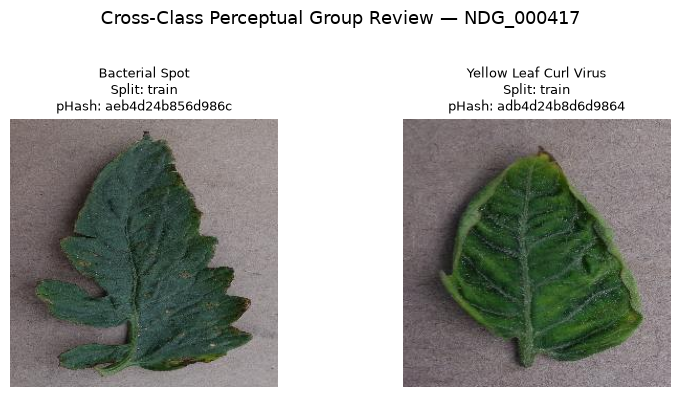

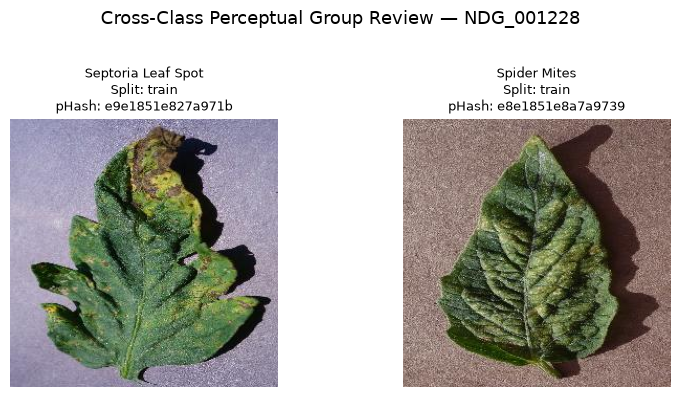

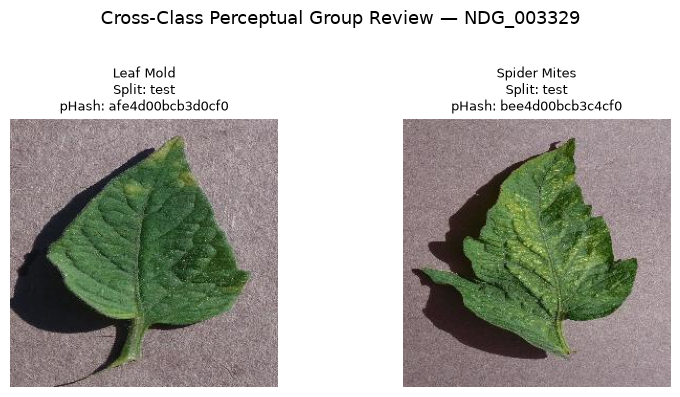

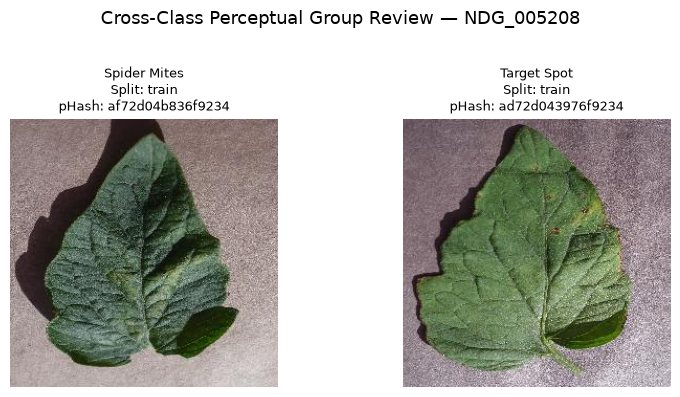

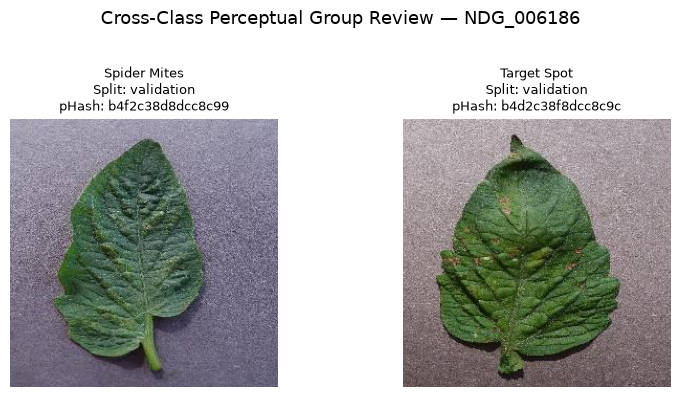

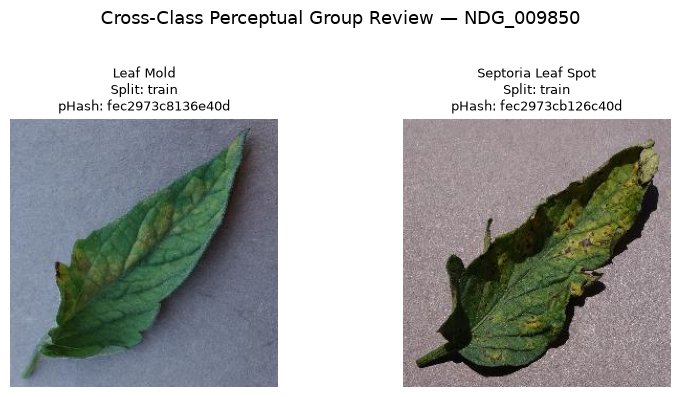

,near_duplicate_group,image_count,class_count,split_count,assigned_split,minimum_cross_class_hamming_distance,maximum_cross_class_hamming_distance
0,NDG_000417,2,2,1,train,4,4
1,NDG_001228,2,2,1,train,4,4
2,NDG_003329,2,2,1,test,4,4
3,NDG_005208,2,2,1,train,4,4
4,NDG_006186,2,2,1,validation,4,4
5,NDG_009850,2,2,1,train,4,4



Cross-Class Groups                  : 6
Cross-Class Groups Crossing Splits  : 0

PASS — Cross-class groups are contained within individual splits.
WARNING — Cross-class perceptual similarity does not automatically prove mislabeling.
WARNING — Visual review figures should be inspected before making label decisions.

Audit CSV: D:\Tomato_Disease_Research\results\leakage_audit\cross_class_group_audit.csv
Review Figures: D:\Tomato_Disease_Research\results\leakage_audit\cross_class_review


In [ ]:
# ============================================================
# PART 9 — CROSS-CLASS PERCEPTUAL GROUP AUDIT
# ============================================================


# ------------------------------------------------------------
# LOAD CROSS-CLASS REPORT
# ------------------------------------------------------------

PART9_CROSS_CLASS_DF = pd.read_csv(
    PART9_CROSS_CLASS_SOURCE_CSV,
    dtype=str,
    keep_default_na=False
)


# ------------------------------------------------------------
# IMAGE PATH LOOKUP
# ------------------------------------------------------------

IMAGE_PATH_LOOKUP = dict(
    zip(
        PART9_COMPLETE_DF[
            "image_id"
        ],

        PART9_COMPLETE_DF[
            "image_path"
        ]
    )
)


SPLIT_LOOKUP = dict(
    zip(
        PART9_COMPLETE_DF[
            "image_id"
        ],

        PART9_COMPLETE_DF[
            "split"
        ]
    )
)


# ------------------------------------------------------------
# CLASS DISPLAY NAMES
# ------------------------------------------------------------

PART9_CLASS_DISPLAY_NAMES = {

    "Tomato_Bacterial_spot":
        "Bacterial Spot",

    "Tomato_Early_blight":
        "Early Blight",

    "Tomato_Late_blight":
        "Late Blight",

    "Tomato_Leaf_Mold":
        "Leaf Mold",

    "Tomato_Septoria_leaf_spot":
        "Septoria Leaf Spot",

    "Tomato_Spider_mites_Two_spotted_spider_mite":
        "Spider Mites",

    "Tomato__Target_Spot":
        "Target Spot",

    "Tomato__Tomato_YellowLeaf__Curl_Virus":
        "Yellow Leaf Curl Virus",

    "Tomato__Tomato_mosaic_virus":
        "Mosaic Virus",

    "Tomato_healthy":
        "Healthy"
}


# ============================================================
# INDEPENDENTLY IDENTIFY CROSS-CLASS GROUPS
# ============================================================

COMPLETE_GROUP_CLASS_COUNTS = (
    PART9_COMPLETE_DF
    .groupby(
        "near_duplicate_group"
    )[
        "class"
    ]
    .nunique()
)


PART9_CROSS_CLASS_GROUP_IDS = (
    COMPLETE_GROUP_CLASS_COUNTS[
        COMPLETE_GROUP_CLASS_COUNTS
        > 1
    ]
    .index
    .tolist()
)


PART9_CROSS_CLASS_GROUP_COUNT = len(
    PART9_CROSS_CLASS_GROUP_IDS
)


# ------------------------------------------------------------
# VERIFY SOURCE REPORT AGREES
# ------------------------------------------------------------

SOURCE_REPORT_GROUP_IDS = set(
    PART9_CROSS_CLASS_DF[
        "near_duplicate_group"
    ].unique()
)


if (
    SOURCE_REPORT_GROUP_IDS
    != set(
        PART9_CROSS_CLASS_GROUP_IDS
    )
):

    raise RuntimeError(
        "PART 8 cross-class report does not "
        "match independent PART 9 detection."
    )


# ============================================================
# PAIRWISE CROSS-CLASS DISTANCE AUDIT
# ============================================================

CROSS_CLASS_PAIR_RECORDS = []


for group_id in (
    PART9_CROSS_CLASS_GROUP_IDS
):

    group_df = (
        PART9_COMPLETE_DF[
            PART9_COMPLETE_DF[
                "near_duplicate_group"
            ]
            == group_id
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    group_rows = list(
        group_df[
            [
                "image_id",
                "relative_path",
                "class",
                "phash",
                "split"
            ]
        ].itertuples(
            index=False,
            name=None
        )
    )


    for (
        row_a,
        row_b
    ) in combinations(
        group_rows,
        2
    ):

        (
            image_id_a,
            path_a,
            class_a,
            phash_a,
            split_a
        ) = row_a


        (
            image_id_b,
            path_b,
            class_b,
            phash_b,
            split_b
        ) = row_b


        if class_a == class_b:

            continue


        distance = (
            int(
                phash_a,
                16
            )
            ^
            int(
                phash_b,
                16
            )
        ).bit_count()


        CROSS_CLASS_PAIR_RECORDS.append(
            {
                "near_duplicate_group":
                    group_id,

                "image_id_a":
                    image_id_a,

                "image_id_b":
                    image_id_b,

                "class_a":
                    class_a,

                "class_b":
                    class_b,

                "split_a":
                    split_a,

                "split_b":
                    split_b,

                "relative_path_a":
                    path_a,

                "relative_path_b":
                    path_b,

                "hamming_distance":
                    int(
                        distance
                    ),

                "same_split":
                    bool(
                        split_a
                        == split_b
                    )
            }
        )


PART9_CROSS_CLASS_PAIR_DF = pd.DataFrame(
    CROSS_CLASS_PAIR_RECORDS
)


# ============================================================
# GROUP-LEVEL AUDIT SUMMARY
# ============================================================

PART9_CROSS_CLASS_AUDIT_RECORDS = []


for group_id in (
    PART9_CROSS_CLASS_GROUP_IDS
):

    group_df = (
        PART9_COMPLETE_DF[
            PART9_COMPLETE_DF[
                "near_duplicate_group"
            ]
            == group_id
        ]
    )


    pair_df = (
        PART9_CROSS_CLASS_PAIR_DF[
            PART9_CROSS_CLASS_PAIR_DF[
                "near_duplicate_group"
            ]
            == group_id
        ]
    )


    split_count = (
        group_df[
            "split"
        ]
        .nunique()
    )


    if len(
        pair_df
    ) > 0:

        minimum_distance = int(
            pair_df[
                "hamming_distance"
            ].min()
        )

        maximum_distance = int(
            pair_df[
                "hamming_distance"
            ].max()
        )

    else:

        minimum_distance = None
        maximum_distance = None


    PART9_CROSS_CLASS_AUDIT_RECORDS.append(
        {
            "near_duplicate_group":
                group_id,

            "image_count":
                int(
                    len(
                        group_df
                    )
                ),

            "class_count":
                int(
                    group_df[
                        "class"
                    ].nunique()
                ),

            "split_count":
                int(
                    split_count
                ),

            "assigned_split":
                group_df[
                    "split"
                ].iloc[0],

            "minimum_cross_class_hamming_distance":
                minimum_distance,

            "maximum_cross_class_hamming_distance":
                maximum_distance
        }
    )


PART9_CROSS_CLASS_AUDIT_DF = pd.DataFrame(
    PART9_CROSS_CLASS_AUDIT_RECORDS
)


# ------------------------------------------------------------
# VERIFY CROSS-CLASS GROUPS DO NOT CROSS SPLITS
# ------------------------------------------------------------

CROSS_CLASS_GROUPS_CROSSING_SPLITS = int(
    (
        PART9_CROSS_CLASS_AUDIT_DF[
            "split_count"
        ]
        > 1
    ).sum()
)


if (
    CROSS_CLASS_GROUPS_CROSSING_SPLITS
    != 0
):

    raise RuntimeError(
        "Cross-class perceptual group leakage detected."
    )


# ------------------------------------------------------------
# SAVE AUDIT TABLE
# ------------------------------------------------------------

PART9_CROSS_CLASS_AUDIT_DF.to_csv(
    PART9_CROSS_CLASS_AUDIT_CSV,
    index=False
)


# ============================================================
# VISUAL REVIEW FIGURES
# ============================================================

print("=" * 70)
print("PART 9 — CROSS-CLASS VISUAL REVIEW")
print("=" * 70)

print(
    "Cross-Class Groups:",
    PART9_CROSS_CLASS_GROUP_COUNT
)

print()


for group_id in (
    PART9_CROSS_CLASS_GROUP_IDS
):

    group_df = (
        PART9_COMPLETE_DF[
            PART9_COMPLETE_DF[
                "near_duplicate_group"
            ]
            == group_id
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    number_of_images = len(
        group_df
    )


    fig, axes = plt.subplots(
        1,
        number_of_images,
        figsize=(
            max(
                4 * number_of_images,
                8
            ),
            4
        )
    )


    if number_of_images == 1:

        axes = [
            axes
        ]


    for (
        axis,
        (
            image_id,
            class_name,
            phash_value,
            split_name
        )
    ) in zip(

        axes,

        group_df[
            [
                "image_id",
                "class",
                "phash",
                "split"
            ]
        ].itertuples(
            index=False,
            name=None
        )
    ):

        image_path = Path(
            IMAGE_PATH_LOOKUP[
                image_id
            ]
        )


        with Image.open(
            image_path
        ) as image:

            image_rgb = (
                image
                .convert(
                    "RGB"
                )
                .copy()
            )


        readable_class = (
            PART9_CLASS_DISPLAY_NAMES.get(
                class_name,
                class_name
            )
        )


        axis.imshow(
            image_rgb
        )


        axis.set_title(
            f"{readable_class}\n"
            f"Split: {split_name}\n"
            f"pHash: {phash_value}",
            fontsize=9
        )


        axis.axis(
            "off"
        )


    figure_path = (
        CROSS_CLASS_REVIEW_DIR
        /
        f"{group_id}_review.png"
    )


    fig.suptitle(
        f"Cross-Class Perceptual Group Review — {group_id}",
        fontsize=13
    )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.93
        ]
    )


    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

print()

display(
    PART9_CROSS_CLASS_AUDIT_DF
)

print()

print(
    "Cross-Class Groups                  :",
    PART9_CROSS_CLASS_GROUP_COUNT
)

print(
    "Cross-Class Groups Crossing Splits  :",
    CROSS_CLASS_GROUPS_CROSSING_SPLITS
)

print()

print(
    "PASS — Cross-class groups are "
    "contained within individual splits."
)

print(
    "WARNING — Cross-class perceptual similarity "
    "does not automatically prove mislabeling."
)

print(
    "WARNING — Visual review figures should be "
    "inspected before making label decisions."
)

print()

print(
    "Audit CSV:",
    PART9_CROSS_CLASS_AUDIT_CSV
)

print(
    "Review Figures:",
    CROSS_CLASS_REVIEW_DIR
)

In [ ]:
# ============================================================
# PART 9 — FINAL RESEARCH VALIDATION
# ============================================================


# ============================================================
# OVERALL SPLIT RATIOS
# ============================================================

PART9_SPLIT_SUMMARY_DF = pd.DataFrame(
    {
        "split": [
            "train",
            "validation",
            "test"
        ],

        "image_count": [
            PART9_TRAIN_COUNT,
            PART9_VALIDATION_COUNT,
            PART9_TEST_COUNT
        ],

        "target_ratio": [
            TRAIN_RATIO,
            VALIDATION_RATIO,
            TEST_RATIO
        ]
    }
)


PART9_SPLIT_SUMMARY_DF[
    "actual_ratio"
] = (
    PART9_SPLIT_SUMMARY_DF[
        "image_count"
    ]
    /
    EXPECTED_CLEAN_IMAGES
)


PART9_SPLIT_SUMMARY_DF[
    "absolute_deviation"
] = (
    PART9_SPLIT_SUMMARY_DF[
        "actual_ratio"
    ]
    -
    PART9_SPLIT_SUMMARY_DF[
        "target_ratio"
    ]
).abs()


PART9_MAX_OVERALL_RATIO_DEVIATION = float(
    PART9_SPLIT_SUMMARY_DF[
        "absolute_deviation"
    ].max()
)


# ============================================================
# CLASS-LEVEL SPLIT RATIOS
# ============================================================

PART9_CLASS_COUNTS_DF = (
    pd.crosstab(
        PART9_COMPLETE_DF[
            "class"
        ],
        PART9_COMPLETE_DF[
            "split"
        ]
    )
    .reindex(
        columns=[
            "train",
            "validation",
            "test"
        ],
        fill_value=0
    )
)


PART9_CLASS_RATIO_DF = (
    PART9_CLASS_COUNTS_DF
    .div(
        PART9_CLASS_COUNTS_DF
        .sum(
            axis=1
        ),
        axis=0
    )
)


PART9_TARGET_RATIO_ARRAY = np.array(
    [
        TRAIN_RATIO,
        VALIDATION_RATIO,
        TEST_RATIO
    ]
)


PART9_MAX_CLASS_RATIO_DEVIATION = float(
    np.max(
        np.abs(
            PART9_CLASS_RATIO_DF[
                [
                    "train",
                    "validation",
                    "test"
                ]
            ]
            .to_numpy()
            -
            PART9_TARGET_RATIO_ARRAY
        )
    )
)


# ------------------------------------------------------------
# BUILD CLASS AUDIT TABLE
# ------------------------------------------------------------

PART9_CLASS_AUDIT_DF = (
    PART9_CLASS_COUNTS_DF
    .reset_index()
)


for split_name in [
    "train",
    "validation",
    "test"
]:

    PART9_CLASS_AUDIT_DF[
        f"{split_name}_ratio"
    ] = (
        PART9_CLASS_RATIO_DF[
            split_name
        ]
        .values
    )


PART9_CLASS_AUDIT_DF.to_csv(
    PART9_CLASS_AUDIT_CSV,
    index=False
)


# ============================================================
# SPLIT AUDIT SUMMARY TABLE
# ============================================================

PART9_SPLIT_AUDIT_DF = (
    PART9_SPLIT_SUMMARY_DF
    .copy()
)


PART9_SPLIT_AUDIT_DF.to_csv(
    PART9_SPLIT_AUDIT_CSV,
    index=False
)


# ============================================================
# FINAL VALIDATION REPORT
# ============================================================

PART9_VALIDATION_REPORT = {

    "clean_dataset_images":
        int(
            EXPECTED_CLEAN_IMAGES
        ),

    "training_images":
        int(
            PART9_TRAIN_COUNT
        ),

    "validation_images":
        int(
            PART9_VALIDATION_COUNT
        ),

    "test_images":
        int(
            PART9_TEST_COUNT
        ),

    "number_of_classes":
        int(
            EXPECTED_NUM_CLASSES
        ),

    "image_id_overlap":
        int(
            IMAGE_ID_OVERLAP_COUNT
        ),

    "relative_path_overlap":
        int(
            PATH_OVERLAP_COUNT
        ),

    "md5_overlap":
        int(
            MD5_OVERLAP_COUNT
        ),

    "near_duplicate_group_overlap":
        int(
            GROUP_OVERLAP_COUNT
        ),

    "independent_cross_split_phash_matches":
        int(
            CROSS_SPLIT_PHASH_MATCH_COUNT
        ),

    "phash_hamming_threshold":
        int(
            PHASH_HAMMING_THRESHOLD
        ),

    "missing_physical_files":
        int(
            MISSING_PHYSICAL_FILE_COUNT
        ),

    "missing_clean_images":
        int(
            len(
                MISSING_FROM_SPLITS
            )
        ),

    "unknown_split_images":
        int(
            len(
                UNKNOWN_IN_SPLITS
            )
        ),

    "cross_class_perceptual_groups":
        int(
            PART9_CROSS_CLASS_GROUP_COUNT
        ),

    "cross_class_groups_crossing_splits":
        int(
            CROSS_CLASS_GROUPS_CROSSING_SPLITS
        ),

    "maximum_overall_ratio_deviation":
        float(
            PART9_MAX_OVERALL_RATIO_DEVIATION
        ),

    "maximum_class_ratio_deviation":
        float(
            PART9_MAX_CLASS_RATIO_DEVIATION
        ),

    "cross_class_manual_review_required":
        bool(
            PART9_CROSS_CLASS_GROUP_COUNT
            > 0
        )
}


# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

with open(
    PART9_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        PART9_VALIDATION_REPORT,
        file,
        indent=4
    )


# ============================================================
# OUTPUT ARTIFACT VERIFICATION
# ============================================================

PART9_REQUIRED_OUTPUTS = [
    PART9_CROSS_SPLIT_PHASH_CSV,
    PART9_CROSS_CLASS_AUDIT_CSV,
    PART9_SPLIT_AUDIT_CSV,
    PART9_CLASS_AUDIT_CSV,
    PART9_VALIDATION_JSON
]


PART9_MISSING_OUTPUTS = [
    path
    for path
    in PART9_REQUIRED_OUTPUTS
    if not path.exists()
]


if PART9_MISSING_OUTPUTS:

    raise RuntimeError(
        "Missing PART 9 artifacts:\n"
        + "\n".join(
            str(path)
            for path
            in PART9_MISSING_OUTPUTS
        )
    )


# ============================================================
# RELOAD JSON — STORAGE VERIFICATION
# ============================================================

with open(
    PART9_VALIDATION_JSON,
    "r",
    encoding="utf-8"
) as file:

    PART9_RELOADED_VALIDATION = (
        json.load(
            file
        )
    )


if (
    PART9_RELOADED_VALIDATION[
        "clean_dataset_images"
    ]
    != EXPECTED_CLEAN_IMAGES
):

    raise RuntimeError(
        "Saved PART 9 validation report "
        "failed reload verification."
    )


# ============================================================
# FINAL OUTPUT
# ============================================================

print("=" * 70)
print("PART 9 — FINAL DATA LEAKAGE / SPLIT AUDIT")
print("=" * 70)

print(
    "Clean Dataset Images       :",
    f"{EXPECTED_CLEAN_IMAGES:,}"
)

print()

print(
    "Training Images            :",
    f"{PART9_TRAIN_COUNT:,}"
)

print(
    "Validation Images          :",
    f"{PART9_VALIDATION_COUNT:,}"
)

print(
    "Test Images                :",
    f"{PART9_TEST_COUNT:,}"
)

print()

print(
    "Image-ID Overlap           :",
    IMAGE_ID_OVERLAP_COUNT
)

print(
    "Relative-Path Overlap      :",
    PATH_OVERLAP_COUNT
)

print(
    "MD5 Overlap                :",
    MD5_OVERLAP_COUNT
)

print(
    "Near-Dup Group Overlap     :",
    GROUP_OVERLAP_COUNT
)

print(
    "Cross-Split pHash Matches  :",
    CROSS_SPLIT_PHASH_MATCH_COUNT
)

print()

print(
    "Missing Physical Files     :",
    MISSING_PHYSICAL_FILE_COUNT
)

print()

print(
    "Cross-Class Groups         :",
    PART9_CROSS_CLASS_GROUP_COUNT
)

print(
    "Cross-Class Groups Leaking :",
    CROSS_CLASS_GROUPS_CROSSING_SPLITS
)

print()

print(
    "Max Overall Ratio Deviation:",
    f"{PART9_MAX_OVERALL_RATIO_DEVIATION:.4f}"
)

print(
    "Max Class Ratio Deviation  :",
    f"{PART9_MAX_CLASS_RATIO_DEVIATION:.4f}"
)

print()

print(
    "PASS — Dataset coverage independently verified."
)

print(
    "PASS — Exact image leakage is zero."
)

print(
    "PASS — Exact duplicate leakage is zero."
)

print(
    "PASS — Near-duplicate group leakage is zero."
)

print(
    "PASS — Independent cross-split pHash audit completed."
)

print(
    "PASS — Physical image integrity verified."
)

print(
    "PASS — All 10 classes preserved in every split."
)

print(
    "PASS — Split ratios independently verified."
)

print(
    "PASS — Validation artifacts saved and reloaded."
)


if (
    PART9_CROSS_CLASS_GROUP_COUNT
    > 0
):

    print()

    print(
        "WARNING —",
        PART9_CROSS_CLASS_GROUP_COUNT,
        "cross-class perceptual groups require "
        "manual visual interpretation."
    )

    print(
        "NOTE — These groups remain inside single "
        "splits and therefore do not create "
        "cross-split leakage."
    )


print()

print(
    "Validation JSON:",
    PART9_VALIDATION_JSON
)

print(
    "pHash Audit CSV:",
    PART9_CROSS_SPLIT_PHASH_CSV
)

print(
    "Cross-Class Audit:",
    PART9_CROSS_CLASS_AUDIT_CSV
)

print(
    "Review Figures:",
    CROSS_CLASS_REVIEW_DIR
)

print()

print(
    "✓ PART 9 — AUTOMATED DATA LEAKAGE AUDIT COMPLETED"
)

print("=" * 70)

PART 9 — FINAL DATA LEAKAGE / SPLIT AUDIT
Clean Dataset Images       : 15,997

Training Images            : 11,199
Validation Images          : 2,399
Test Images                : 2,399

Image-ID Overlap           : 0
Relative-Path Overlap      : 0
MD5 Overlap                : 0
Near-Dup Group Overlap     : 0
Cross-Split pHash Matches  : 0

Missing Physical Files     : 0

Cross-Class Groups         : 6
Cross-Class Groups Leaking : 0

Max Overall Ratio Deviation: 0.0001
Max Class Ratio Deviation  : 0.0005

PASS — Dataset coverage independently verified.
PASS — Exact image leakage is zero.
PASS — Exact duplicate leakage is zero.
PASS — Near-duplicate group leakage is zero.
PASS — Independent cross-split pHash audit completed.
PASS — Physical image integrity verified.
PASS — All 10 classes preserved in every split.
PASS — Split ratios independently verified.
PASS — Validation artifacts saved and reloaded.

WARNING — 6 cross-class perceptual groups require manual visual interpretation.
NOTE

# PART 10 — Image Preprocessing

This part defines and validates the deterministic image preprocessing pipeline
used before model training and evaluation.

A common preprocessing protocol is used across all benchmark architectures to
avoid introducing model-specific preprocessing differences as an experimental
confounder.

### Preprocessing Protocol

- Convert every image to RGB
- Resize from the native 256 × 256 resolution to 224 × 224
- Convert pixel values from [0, 255] to floating-point tensors in [0, 1]
- Normalize using ImageNet channel statistics
- Use deterministic preprocessing for validation and test images
- Do not apply data augmentation in this part

### ImageNet Normalization

Mean:

- Red: 0.485
- Green: 0.456
- Blue: 0.406

Standard deviation:

- Red: 0.229
- Green: 0.224
- Blue: 0.225

### Research Validation

The preprocessing pipeline is verified for:

- Complete 15,997-image coverage
- Tensor shape consistency
- Floating-point dtype consistency
- NaN / Inf detection
- Normalized value-range validity
- Deterministic repeatability
- Split preservation
- Training-only preview generation

Data augmentation is introduced separately in PART 11.

In [ ]:
# ============================================================
# PART 10 — IMAGE PREPROCESSING CONFIGURATION
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

PREPROCESS_IMAGE_SIZE = 224

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)

EXPECTED_CLEAN_IMAGES = 15997
EXPECTED_NUM_CLASSES = 10


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

PREPROCESSING_RESULTS_DIR = (
    RESULTS_DIR
    / "preprocessing"
)

PREPROCESSING_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# OUTPUT FILES
# ------------------------------------------------------------

PREPROCESSING_CONFIG_JSON = (
    PREPROCESSING_RESULTS_DIR
    / "preprocessing_config.json"
)

PREPROCESSING_VALIDATION_JSON = (
    PREPROCESSING_RESULTS_DIR
    / "preprocessing_validation.json"
)

PREPROCESSING_PREVIEW_PNG = (
    PREPROCESSING_RESULTS_DIR
    / "preprocessing_preview.png"
)


# ============================================================
# LOAD COMPLETE SPLIT MANIFEST
# ============================================================

PART10_COMPLETE_SPLIT_CSV = (
    SPLITS_DIR
    / "complete_split_manifest.csv"
)


if not PART10_COMPLETE_SPLIT_CSV.exists():

    raise RuntimeError(
        "Complete split manifest not found. "
        "Run PART 8 and PART 9 first."
    )


PART10_DATASET_DF = pd.read_csv(
    PART10_COMPLETE_SPLIT_CSV,
    dtype=str,
    keep_default_na=False
)


# ------------------------------------------------------------
# MANIFEST VALIDATION
# ------------------------------------------------------------

PART10_REQUIRED_COLUMNS = {
    "image_id",
    "image_path",
    "relative_path",
    "class",
    "split"
}


missing_columns = (
    PART10_REQUIRED_COLUMNS
    - set(
        PART10_DATASET_DF.columns
    )
)


if missing_columns:

    raise RuntimeError(
        "Missing required split-manifest columns: "
        f"{sorted(missing_columns)}"
    )


if len(
    PART10_DATASET_DF
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        f"Expected {EXPECTED_CLEAN_IMAGES:,} images, "
        f"found {len(PART10_DATASET_DF):,}."
    )


if (
    PART10_DATASET_DF[
        "class"
    ].nunique()
    != EXPECTED_NUM_CLASSES
):

    raise RuntimeError(
        "Expected 10 classes in PART 10."
    )


# ============================================================
# COMMON DETERMINISTIC PREPROCESSING
# ============================================================

BASE_PREPROCESS_TRANSFORM = (
    transforms.Compose(
        [
            transforms.Resize(
                (
                    PREPROCESS_IMAGE_SIZE,
                    PREPROCESS_IMAGE_SIZE
                ),
                interpolation=(
                    InterpolationMode.BILINEAR
                ),
                antialias=True
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD
            )
        ]
    )
)


# ------------------------------------------------------------
# TRANSFORMS USED DOWNSTREAM
# ------------------------------------------------------------

# PART 11 will replace TRAIN_TRANSFORM with
# a training-only augmented transform.

TRAIN_BASE_TRANSFORM = (
    BASE_PREPROCESS_TRANSFORM
)

VALIDATION_TRANSFORM = (
    BASE_PREPROCESS_TRANSFORM
)

TEST_TRANSFORM = (
    BASE_PREPROCESS_TRANSFORM
)


# ------------------------------------------------------------
# VERIFY NO RANDOM AUGMENTATION EXISTS HERE
# ------------------------------------------------------------

transform_description = repr(
    BASE_PREPROCESS_TRANSFORM
)


if "Random" in transform_description:

    raise RuntimeError(
        "Random augmentation detected in PART 10. "
        "Augmentation must remain in PART 11."
    )


# ------------------------------------------------------------
# DISPLAY CONFIGURATION
# ------------------------------------------------------------

print("=" * 70)
print("PART 10 — IMAGE PREPROCESSING CONFIGURATION")
print("=" * 70)

print(
    "Input Dataset Images :",
    f"{len(PART10_DATASET_DF):,}"
)

print(
    "Input Resolution     :",
    "256 × 256"
)

print(
    "Model Input Size     :",
    f"{PREPROCESS_IMAGE_SIZE} × "
    f"{PREPROCESS_IMAGE_SIZE}"
)

print(
    "Color Mode           : RGB"
)

print(
    "Interpolation        : Bilinear"
)

print(
    "Antialiasing         : True"
)

print()

print(
    "ImageNet Mean        :",
    IMAGENET_MEAN
)

print(
    "ImageNet Std         :",
    IMAGENET_STD
)

print()

print(
    "Augmentation         : None"
)

print(
    "Validation Randomness: None"
)

print(
    "Test Randomness      : None"
)

print()

print(
    "PASS — Deterministic preprocessing "
    "pipeline defined."
)

PART 10 — IMAGE PREPROCESSING CONFIGURATION
Input Dataset Images : 15,997
Input Resolution     : 256 × 256
Model Input Size     : 224 × 224
Color Mode           : RGB
Interpolation        : Bilinear
Antialiasing         : True

ImageNet Mean        : (0.485, 0.456, 0.406)
ImageNet Std         : (0.229, 0.224, 0.225)

Augmentation         : None
Validation Randomness: None
Test Randomness      : None

PASS — Deterministic preprocessing pipeline defined.


In [ ]:
# ============================================================
# PART 10 — FULL PREPROCESSING VALIDATION
# ============================================================


# ------------------------------------------------------------
# EXPECTED OUTPUT CHARACTERISTICS
# ------------------------------------------------------------

EXPECTED_TENSOR_SHAPE = (
    3,
    PREPROCESS_IMAGE_SIZE,
    PREPROCESS_IMAGE_SIZE
)

EXPECTED_TENSOR_DTYPE = (
    torch.float32
)


# ------------------------------------------------------------
# THEORETICAL NORMALIZED RANGE
# ------------------------------------------------------------

THEORETICAL_NORMALIZED_MIN = min(
    (
        0.0 - mean
    ) / std

    for mean, std
    in zip(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
)


THEORETICAL_NORMALIZED_MAX = max(
    (
        1.0 - mean
    ) / std

    for mean, std
    in zip(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
)


# ------------------------------------------------------------
# VALIDATION TRACKERS
# ------------------------------------------------------------

INVALID_SHAPE_COUNT = 0
INVALID_DTYPE_COUNT = 0
NONFINITE_TENSOR_COUNT = 0

OBSERVED_NORMALIZED_MIN = float(
    "inf"
)

OBSERVED_NORMALIZED_MAX = float(
    "-inf"
)

OBSERVED_SHAPES = set()
OBSERVED_DTYPES = set()

PROCESSED_SPLIT_COUNTS = {
    "train": 0,
    "validation": 0,
    "test": 0
}


# ============================================================
# FULL DATASET SCAN
# ============================================================

print("=" * 70)
print("PART 10 — FULL PREPROCESSING VALIDATION")
print("=" * 70)

print(
    f"Validating {EXPECTED_CLEAN_IMAGES:,} images..."
)

print()


for index, (
    image_path_value,
    split_name
) in enumerate(

    PART10_DATASET_DF[
        [
            "image_path",
            "split"
        ]
    ].itertuples(
        index=False,
        name=None
    ),

    start=1
):

    image_path = Path(
        image_path_value
    )


    # --------------------------------------------------------
    # FILE CHECK
    # --------------------------------------------------------

    if not image_path.is_file():

        raise RuntimeError(
            "Missing image during preprocessing: "
            f"{image_path}"
        )


    # --------------------------------------------------------
    # LOAD + FORCE RGB
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        tensor = (
            BASE_PREPROCESS_TRANSFORM(
                image_rgb
            )
        )


    # --------------------------------------------------------
    # SHAPE VALIDATION
    # --------------------------------------------------------

    tensor_shape = tuple(
        tensor.shape
    )


    OBSERVED_SHAPES.add(
        tensor_shape
    )


    if (
        tensor_shape
        != EXPECTED_TENSOR_SHAPE
    ):

        INVALID_SHAPE_COUNT += 1


    # --------------------------------------------------------
    # DTYPE VALIDATION
    # --------------------------------------------------------

    OBSERVED_DTYPES.add(
        str(
            tensor.dtype
        )
    )


    if (
        tensor.dtype
        != EXPECTED_TENSOR_DTYPE
    ):

        INVALID_DTYPE_COUNT += 1


    # --------------------------------------------------------
    # NaN / INF VALIDATION
    # --------------------------------------------------------

    if not torch.isfinite(
        tensor
    ).all():

        NONFINITE_TENSOR_COUNT += 1


    # --------------------------------------------------------
    # NORMALIZED VALUE RANGE
    # --------------------------------------------------------

    tensor_min = float(
        tensor.min().item()
    )

    tensor_max = float(
        tensor.max().item()
    )


    OBSERVED_NORMALIZED_MIN = min(
        OBSERVED_NORMALIZED_MIN,
        tensor_min
    )

    OBSERVED_NORMALIZED_MAX = max(
        OBSERVED_NORMALIZED_MAX,
        tensor_max
    )


    # --------------------------------------------------------
    # SPLIT COUNT
    # --------------------------------------------------------

    if split_name not in (
        PROCESSED_SPLIT_COUNTS
    ):

        raise RuntimeError(
            f"Unexpected split label: "
            f"{split_name}"
        )


    PROCESSED_SPLIT_COUNTS[
        split_name
    ] += 1


    # --------------------------------------------------------
    # PROGRESS
    # --------------------------------------------------------

    if (
        index % 2000 == 0
        or
        index == EXPECTED_CLEAN_IMAGES
    ):

        print(
            f"Validated "
            f"{index:,}/"
            f"{EXPECTED_CLEAN_IMAGES:,}"
        )


# ============================================================
# RESEARCH VALIDATION
# ============================================================

if INVALID_SHAPE_COUNT != 0:

    raise RuntimeError(
        f"{INVALID_SHAPE_COUNT} tensors "
        "have invalid shapes."
    )


if INVALID_DTYPE_COUNT != 0:

    raise RuntimeError(
        f"{INVALID_DTYPE_COUNT} tensors "
        "have invalid dtypes."
    )


if NONFINITE_TENSOR_COUNT != 0:

    raise RuntimeError(
        f"{NONFINITE_TENSOR_COUNT} tensors "
        "contain NaN or Inf."
    )


if (
    OBSERVED_NORMALIZED_MIN
    <
    THEORETICAL_NORMALIZED_MIN
    - 1e-5
):

    raise RuntimeError(
        "Observed normalized minimum is "
        "outside the theoretical range."
    )


if (
    OBSERVED_NORMALIZED_MAX
    >
    THEORETICAL_NORMALIZED_MAX
    + 1e-5
):

    raise RuntimeError(
        "Observed normalized maximum is "
        "outside the theoretical range."
    )


if sum(
    PROCESSED_SPLIT_COUNTS.values()
) != EXPECTED_CLEAN_IMAGES:

    raise RuntimeError(
        "Preprocessing split count mismatch."
    )


# ============================================================
# DETERMINISM CHECK
# ============================================================

DETERMINISM_SAMPLE_SIZE = min(
    30,
    len(
        PART10_DATASET_DF
    )
)


DETERMINISM_SAMPLE_DF = (
    PART10_DATASET_DF
    .sample(
        n=DETERMINISM_SAMPLE_SIZE,
        random_state=SEED
    )
)


DETERMINISM_FAILURE_COUNT = 0


for image_path_value in (
    DETERMINISM_SAMPLE_DF[
        "image_path"
    ]
):

    with Image.open(
        image_path_value
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        tensor_a = (
            BASE_PREPROCESS_TRANSFORM(
                image_rgb
            )
        )


        tensor_b = (
            BASE_PREPROCESS_TRANSFORM(
                image_rgb
            )
        )


    if not torch.equal(
        tensor_a,
        tensor_b
    ):

        DETERMINISM_FAILURE_COUNT += 1


if DETERMINISM_FAILURE_COUNT != 0:

    raise RuntimeError(
        "Preprocessing is not deterministic."
    )


# ============================================================
# VALIDATION SUMMARY
# ============================================================

print()

print("=" * 70)
print("PART 10 — PREPROCESSING VALIDATION SUMMARY")
print("=" * 70)

print(
    "Images Validated       :",
    f"{EXPECTED_CLEAN_IMAGES:,}"
)

print(
    "Observed Tensor Shape  :",
    OBSERVED_SHAPES
)

print(
    "Observed Tensor Dtype  :",
    OBSERVED_DTYPES
)

print()

print(
    "Invalid Shapes         :",
    INVALID_SHAPE_COUNT
)

print(
    "Invalid Dtypes         :",
    INVALID_DTYPE_COUNT
)

print(
    "NaN / Inf Tensors      :",
    NONFINITE_TENSOR_COUNT
)

print()

print(
    "Observed Norm. Minimum :",
    f"{OBSERVED_NORMALIZED_MIN:.4f}"
)

print(
    "Observed Norm. Maximum :",
    f"{OBSERVED_NORMALIZED_MAX:.4f}"
)

print(
    "Theoretical Minimum    :",
    f"{THEORETICAL_NORMALIZED_MIN:.4f}"
)

print(
    "Theoretical Maximum    :",
    f"{THEORETICAL_NORMALIZED_MAX:.4f}"
)

print()

print(
    "Train Images           :",
    f"{PROCESSED_SPLIT_COUNTS['train']:,}"
)

print(
    "Validation Images      :",
    f"{PROCESSED_SPLIT_COUNTS['validation']:,}"
)

print(
    "Test Images            :",
    f"{PROCESSED_SPLIT_COUNTS['test']:,}"
)

print()

print(
    "Determinism Samples    :",
    DETERMINISM_SAMPLE_SIZE
)

print(
    "Determinism Failures   :",
    DETERMINISM_FAILURE_COUNT
)

print()

print(
    "PASS — Tensor shape consistency verified."
)

print(
    "PASS — Tensor dtype consistency verified."
)

print(
    "PASS — No NaN/Inf values detected."
)

print(
    "PASS — Normalized value range verified."
)

print(
    "PASS — Split coverage preserved."
)

print(
    "PASS — Deterministic preprocessing verified."
)

PART 10 — FULL PREPROCESSING VALIDATION
Validating 15,997 images...

Validated 2,000/15,997
Validated 4,000/15,997
Validated 6,000/15,997
Validated 8,000/15,997
Validated 10,000/15,997
Validated 12,000/15,997
Validated 14,000/15,997
Validated 15,997/15,997

PART 10 — PREPROCESSING VALIDATION SUMMARY
Images Validated       : 15,997
Observed Tensor Shape  : {(3, 224, 224)}
Observed Tensor Dtype  : {'torch.float32'}

Invalid Shapes         : 0
Invalid Dtypes         : 0
NaN / Inf Tensors      : 0

Observed Norm. Minimum : -2.1179
Observed Norm. Maximum : 2.6400
Theoretical Minimum    : -2.1179
Theoretical Maximum    : 2.6400

Train Images           : 11,199
Validation Images      : 2,399
Test Images            : 2,399

Determinism Samples    : 30
Determinism Failures   : 0

PASS — Tensor shape consistency verified.
PASS — Tensor dtype consistency verified.
PASS — No NaN/Inf values detected.
PASS — Normalized value range verified.
PASS — Split coverage preserved.
PASS — Deterministic prepr

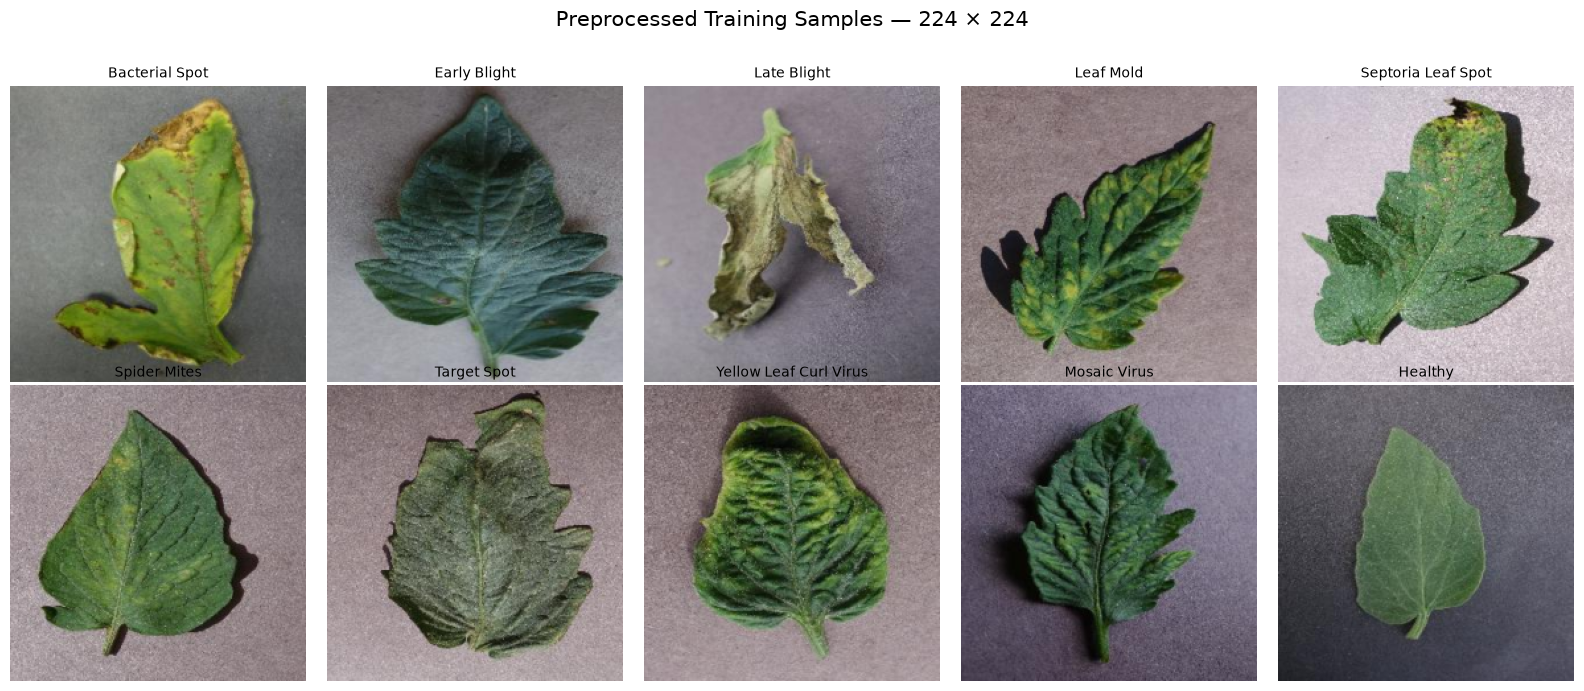

PART 10 — VISUAL PREPROCESSING CHECK
Classes Visualized   : 10
Samples per Class    : 1
Source Split         : train only
Displayed Resolution : 224 × 224

Figure Saved: D:\Tomato_Disease_Research\results\preprocessing\preprocessing_preview.png

PASS — Training-only preprocessing preview generated.


In [ ]:
# ============================================================
# PART 10 — PREPROCESSING VISUAL VERIFICATION
# ============================================================


# ------------------------------------------------------------
# TRAINING DATA ONLY
# ------------------------------------------------------------

PART10_TRAIN_DF = (
    PART10_DATASET_DF[
        PART10_DATASET_DF[
            "split"
        ]
        == "train"
    ]
    .copy()
)


# ------------------------------------------------------------
# DISPLAY LABELS
# ------------------------------------------------------------

PART10_CLASS_DISPLAY_NAMES = {

    "Tomato_Bacterial_spot":
        "Bacterial Spot",

    "Tomato_Early_blight":
        "Early Blight",

    "Tomato_Late_blight":
        "Late Blight",

    "Tomato_Leaf_Mold":
        "Leaf Mold",

    "Tomato_Septoria_leaf_spot":
        "Septoria Leaf Spot",

    "Tomato_Spider_mites_Two_spotted_spider_mite":
        "Spider Mites",

    "Tomato__Target_Spot":
        "Target Spot",

    "Tomato__Tomato_YellowLeaf__Curl_Virus":
        "Yellow Leaf Curl Virus",

    "Tomato__Tomato_mosaic_virus":
        "Mosaic Virus",

    "Tomato_healthy":
        "Healthy"
}


# ------------------------------------------------------------
# ONE SAMPLE PER CLASS
# ------------------------------------------------------------

PART10_PREVIEW_RECORDS = []


for class_index, class_name in enumerate(

    sorted(
        PART10_TRAIN_DF[
            "class"
        ].unique()
    )
):

    class_df = (
        PART10_TRAIN_DF[
            PART10_TRAIN_DF[
                "class"
            ]
            == class_name
        ]
    )


    sample_row = (
        class_df
        .sample(
            n=1,
            random_state=(
                SEED
                + class_index
            )
        )
        .iloc[0]
    )


    PART10_PREVIEW_RECORDS.append(
        {
            "class":
                class_name,

            "image_path":
                sample_row[
                    "image_path"
                ]
        }
    )


# ------------------------------------------------------------
# DENORMALIZATION CONSTANTS
# ------------------------------------------------------------

MEAN_TENSOR = torch.tensor(
    IMAGENET_MEAN
).view(
    3,
    1,
    1
)


STD_TENSOR = torch.tensor(
    IMAGENET_STD
).view(
    3,
    1,
    1
)


# ============================================================
# PLOT PREPROCESSED TRAINING SAMPLES
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(
        16,
        7
    )
)


axes = (
    axes.flatten()
)


for (
    axis,
    record
) in zip(
    axes,
    PART10_PREVIEW_RECORDS
):

    with Image.open(
        record[
            "image_path"
        ]
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        normalized_tensor = (
            BASE_PREPROCESS_TRANSFORM(
                image_rgb
            )
        )


    # --------------------------------------------------------
    # INVERSE NORMALIZE FOR DISPLAY ONLY
    # --------------------------------------------------------

    display_tensor = (
        normalized_tensor
        * STD_TENSOR
        + MEAN_TENSOR
    )


    display_tensor = (
        display_tensor
        .clamp(
            0,
            1
        )
    )


    display_image = (
        display_tensor
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )


    display_name = (
        PART10_CLASS_DISPLAY_NAMES.get(
            record[
                "class"
            ],
            record[
                "class"
            ]
        )
    )


    axis.imshow(
        display_image
    )


    axis.set_title(
        display_name,
        fontsize=10
    )


    axis.axis(
        "off"
    )


fig.suptitle(
    "Preprocessed Training Samples — 224 × 224",
    fontsize=15
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)


plt.savefig(
    PREPROCESSING_PREVIEW_PNG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# FIGURE VERIFICATION
# ------------------------------------------------------------

if not PREPROCESSING_PREVIEW_PNG.exists():

    raise RuntimeError(
        "Preprocessing preview figure "
        "was not saved."
    )


print("=" * 70)
print("PART 10 — VISUAL PREPROCESSING CHECK")
print("=" * 70)

print(
    "Classes Visualized   :",
    len(
        PART10_PREVIEW_RECORDS
    )
)

print(
    "Samples per Class    : 1"
)

print(
    "Source Split         : train only"
)

print(
    "Displayed Resolution :",
    "224 × 224"
)

print()

print(
    "Figure Saved:",
    PREPROCESSING_PREVIEW_PNG
)

print()

print(
    "PASS — Training-only preprocessing "
    "preview generated."
)

In [ ]:
# ============================================================
# PART 10 — SAVE CONFIGURATION + FINAL SUMMARY
# ============================================================


# ============================================================
# PREPROCESSING CONFIGURATION
# ============================================================

PREPROCESSING_CONFIG = {

    "input_source_resolution": [
        256,
        256
    ],

    "model_input_resolution": [
        PREPROCESS_IMAGE_SIZE,
        PREPROCESS_IMAGE_SIZE
    ],

    "color_mode": "RGB",

    "resize_interpolation": (
        "bilinear"
    ),

    "antialias": True,

    "tensor_scaling": (
        "uint8_[0,255]_to_float32_[0,1]"
    ),

    "normalization": (
        "ImageNet"
    ),

    "imagenet_mean": list(
        IMAGENET_MEAN
    ),

    "imagenet_std": list(
        IMAGENET_STD
    ),

    "augmentation_in_part10": False,

    "validation_transform_random": False,

    "test_transform_random": False,

    "common_preprocessing_protocol": True
}


# ------------------------------------------------------------
# SAVE CONFIG
# ------------------------------------------------------------

with open(
    PREPROCESSING_CONFIG_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        PREPROCESSING_CONFIG,
        file,
        indent=4
    )


# ============================================================
# VALIDATION REPORT
# ============================================================

PREPROCESSING_VALIDATION_REPORT = {

    "images_validated":
        int(
            EXPECTED_CLEAN_IMAGES
        ),

    "expected_tensor_shape":
        list(
            EXPECTED_TENSOR_SHAPE
        ),

    "observed_tensor_shapes":
        [
            list(
                shape
            )
            for shape
            in sorted(
                OBSERVED_SHAPES
            )
        ],

    "observed_tensor_dtypes":
        sorted(
            OBSERVED_DTYPES
        ),

    "invalid_shape_count":
        int(
            INVALID_SHAPE_COUNT
        ),

    "invalid_dtype_count":
        int(
            INVALID_DTYPE_COUNT
        ),

    "nonfinite_tensor_count":
        int(
            NONFINITE_TENSOR_COUNT
        ),

    "observed_normalized_min":
        float(
            OBSERVED_NORMALIZED_MIN
        ),

    "observed_normalized_max":
        float(
            OBSERVED_NORMALIZED_MAX
        ),

    "theoretical_normalized_min":
        float(
            THEORETICAL_NORMALIZED_MIN
        ),

    "theoretical_normalized_max":
        float(
            THEORETICAL_NORMALIZED_MAX
        ),

    "determinism_sample_size":
        int(
            DETERMINISM_SAMPLE_SIZE
        ),

    "determinism_failures":
        int(
            DETERMINISM_FAILURE_COUNT
        ),

    "split_counts": {
        key: int(
            value
        )
        for key, value
        in PROCESSED_SPLIT_COUNTS.items()
    }
}


# ------------------------------------------------------------
# SAVE VALIDATION REPORT
# ------------------------------------------------------------

with open(
    PREPROCESSING_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        PREPROCESSING_VALIDATION_REPORT,
        file,
        indent=4
    )


# ============================================================
# SAVED FILE VERIFICATION
# ============================================================

PART10_REQUIRED_OUTPUTS = [
    PREPROCESSING_CONFIG_JSON,
    PREPROCESSING_VALIDATION_JSON,
    PREPROCESSING_PREVIEW_PNG
]


PART10_MISSING_OUTPUTS = [
    path

    for path
    in PART10_REQUIRED_OUTPUTS

    if not path.exists()
]


if PART10_MISSING_OUTPUTS:

    raise RuntimeError(
        "Missing PART 10 outputs:\n"
        +
        "\n".join(
            str(path)
            for path
            in PART10_MISSING_OUTPUTS
        )
    )


# ------------------------------------------------------------
# RELOAD JSON FILES
# ------------------------------------------------------------

with open(
    PREPROCESSING_CONFIG_JSON,
    "r",
    encoding="utf-8"
) as file:

    RELOADED_PREPROCESS_CONFIG = (
        json.load(
            file
        )
    )


with open(
    PREPROCESSING_VALIDATION_JSON,
    "r",
    encoding="utf-8"
) as file:

    RELOADED_PREPROCESS_VALIDATION = (
        json.load(
            file
        )
    )


if (
    RELOADED_PREPROCESS_VALIDATION[
        "images_validated"
    ]
    != EXPECTED_CLEAN_IMAGES
):

    raise RuntimeError(
        "Saved preprocessing validation "
        "failed reload verification."
    )


# ============================================================
# FINAL REPORT
# ============================================================

print("=" * 70)
print("PART 10 — FINAL IMAGE PREPROCESSING SUMMARY")
print("=" * 70)

print(
    "Images Validated        :",
    f"{EXPECTED_CLEAN_IMAGES:,}"
)

print(
    "Source Resolution       :",
    "256 × 256"
)

print(
    "Model Input Resolution  :",
    "224 × 224"
)

print(
    "Color Mode              : RGB"
)

print(
    "Tensor Dtype            : float32"
)

print(
    "Normalization           : ImageNet"
)

print(
    "Augmentation            : None"
)

print()

print(
    "Invalid Tensor Shapes   :",
    INVALID_SHAPE_COUNT
)

print(
    "Invalid Tensor Dtypes   :",
    INVALID_DTYPE_COUNT
)

print(
    "NaN / Inf Tensors       :",
    NONFINITE_TENSOR_COUNT
)

print(
    "Determinism Failures    :",
    DETERMINISM_FAILURE_COUNT
)

print()

print(
    "Observed Norm. Range    :",
    f"{OBSERVED_NORMALIZED_MIN:.4f}",
    "to",
    f"{OBSERVED_NORMALIZED_MAX:.4f}"
)

print()

print(
    "Configuration JSON:",
    PREPROCESSING_CONFIG_JSON
)

print(
    "Validation JSON   :",
    PREPROCESSING_VALIDATION_JSON
)

print(
    "Preview Figure    :",
    PREPROCESSING_PREVIEW_PNG
)

print()

print(
    "PASS — Common 224 × 224 preprocessing protocol verified."
)

print(
    "PASS — ImageNet normalization verified."
)

print(
    "PASS — No invalid or non-finite tensors detected."
)

print(
    "PASS — Validation/test preprocessing is deterministic."
)

print(
    "PASS — No augmentation applied in PART 10."
)

print(
    "PASS — Saved preprocessing artifacts reloaded successfully."
)

print()

print(
    "✓ PART 10 — IMAGE PREPROCESSING COMPLETED"
)

print("=" * 70)

PART 10 — FINAL IMAGE PREPROCESSING SUMMARY
Images Validated        : 15,997
Source Resolution       : 256 × 256
Model Input Resolution  : 224 × 224
Color Mode              : RGB
Tensor Dtype            : float32
Normalization           : ImageNet
Augmentation            : None

Invalid Tensor Shapes   : 0
Invalid Tensor Dtypes   : 0
NaN / Inf Tensors       : 0
Determinism Failures    : 0

Observed Norm. Range    : -2.1179 to 2.6400

Configuration JSON: D:\Tomato_Disease_Research\results\preprocessing\preprocessing_config.json
Validation JSON   : D:\Tomato_Disease_Research\results\preprocessing\preprocessing_validation.json
Preview Figure    : D:\Tomato_Disease_Research\results\preprocessing\preprocessing_preview.png

PASS — Common 224 × 224 preprocessing protocol verified.
PASS — ImageNet normalization verified.
PASS — No invalid or non-finite tensors detected.
PASS — Validation/test preprocessing is deterministic.
PASS — No augmentation applied in PART 10.
PASS — Saved preprocessing 

# PART 11 — Robust Training Data Augmentation

This part defines a conservative and biologically plausible data augmentation
pipeline for the training partition.

Augmentation is applied only to training images. Validation and test images use
the deterministic preprocessing protocol established in PART 10.

The objective is to improve model robustness to realistic image variations while
preserving disease-relevant visual symptoms.

### Training Augmentations

- Random resized crop to 224 × 224
- Horizontal flipping
- Controlled vertical flipping
- Small-angle rotation
- Moderate brightness, contrast, and saturation variation
- Very small hue variation
- Low-probability Gaussian blur
- Tensor conversion
- ImageNet normalization

### Important Experimental Rule

Validation and test images are never randomly augmented.

This prevents evaluation-time randomness and ensures fair comparison between all
six benchmark architectures.

### Research Validation

The augmentation pipeline is verified for:

- Training-only application
- Tensor shape and dtype consistency
- NaN / Inf detection
- Normalized range validity
- Stochastic behavior during training
- Reproducibility under a fixed random seed
- Deterministic validation/test preprocessing
- Visual preservation of disease-relevant leaf information

In [ ]:
# ============================================================
# PART 11 — ROBUST DATA AUGMENTATION CONFIGURATION
# ============================================================

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

AUGMENT_IMAGE_SIZE = 224

EXPECTED_TRAIN_IMAGES = 11199
EXPECTED_VALIDATION_IMAGES = 2399
EXPECTED_TEST_IMAGES = 2399

EXPECTED_NUM_CLASSES = 10


IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)


# ------------------------------------------------------------
# AUGMENTATION PARAMETERS
# ------------------------------------------------------------

RANDOM_CROP_SCALE = (
    0.85,
    1.00
)

RANDOM_CROP_RATIO = (
    0.95,
    1.05
)

HORIZONTAL_FLIP_PROBABILITY = 0.50

VERTICAL_FLIP_PROBABILITY = 0.30

ROTATION_DEGREES = 20

COLOR_JITTER_PROBABILITY = 0.60

BRIGHTNESS_JITTER = 0.15

CONTRAST_JITTER = 0.15

SATURATION_JITTER = 0.10

HUE_JITTER = 0.02

GAUSSIAN_BLUR_PROBABILITY = 0.15

GAUSSIAN_BLUR_KERNEL_SIZE = 3

GAUSSIAN_BLUR_SIGMA = (
    0.1,
    1.0
)


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

AUGMENTATION_RESULTS_DIR = (
    RESULTS_DIR
    / "augmentation"
)

AUGMENTATION_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# OUTPUT FILES
# ------------------------------------------------------------

AUGMENTATION_CONFIG_JSON = (
    AUGMENTATION_RESULTS_DIR
    / "augmentation_config.json"
)

AUGMENTATION_VALIDATION_JSON = (
    AUGMENTATION_RESULTS_DIR
    / "augmentation_validation.json"
)

AUGMENTATION_PREVIEW_PNG = (
    AUGMENTATION_RESULTS_DIR
    / "training_augmentation_preview.png"
)


# ============================================================
# LOAD SAVED SPLITS
# ============================================================

PART11_TRAIN_CSV = (
    SPLITS_DIR
    / "train_split.csv"
)

PART11_VALIDATION_CSV = (
    SPLITS_DIR
    / "validation_split.csv"
)

PART11_TEST_CSV = (
    SPLITS_DIR
    / "test_split.csv"
)


for split_file in [
    PART11_TRAIN_CSV,
    PART11_VALIDATION_CSV,
    PART11_TEST_CSV
]:

    if not split_file.exists():

        raise RuntimeError(
            f"Required split file not found: "
            f"{split_file}"
        )


PART11_TRAIN_DF = pd.read_csv(
    PART11_TRAIN_CSV,
    dtype=str,
    keep_default_na=False
)


PART11_VALIDATION_DF = pd.read_csv(
    PART11_VALIDATION_CSV,
    dtype=str,
    keep_default_na=False
)


PART11_TEST_DF = pd.read_csv(
    PART11_TEST_CSV,
    dtype=str,
    keep_default_na=False
)


# ------------------------------------------------------------
# SPLIT COUNT VALIDATION
# ------------------------------------------------------------

if len(
    PART11_TRAIN_DF
) != EXPECTED_TRAIN_IMAGES:

    raise RuntimeError(
        "Training split size mismatch."
    )


if len(
    PART11_VALIDATION_DF
) != EXPECTED_VALIDATION_IMAGES:

    raise RuntimeError(
        "Validation split size mismatch."
    )


if len(
    PART11_TEST_DF
) != EXPECTED_TEST_IMAGES:

    raise RuntimeError(
        "Test split size mismatch."
    )


if (
    PART11_TRAIN_DF[
        "class"
    ].nunique()
    != EXPECTED_NUM_CLASSES
):

    raise RuntimeError(
        "Training split does not contain "
        "all 10 classes."
    )


# ============================================================
# TRAINING AUGMENTATION TRANSFORM
# ============================================================

TRAIN_AUGMENTED_TRANSFORM = (
    transforms.Compose(
        [
            # ------------------------------------------------
            # RANDOM CROP + RESIZE
            # ------------------------------------------------

            transforms.RandomResizedCrop(
                size=(
                    AUGMENT_IMAGE_SIZE,
                    AUGMENT_IMAGE_SIZE
                ),

                scale=RANDOM_CROP_SCALE,

                ratio=RANDOM_CROP_RATIO,

                interpolation=(
                    InterpolationMode.BILINEAR
                ),

                antialias=True
            ),


            # ------------------------------------------------
            # GEOMETRIC AUGMENTATION
            # ------------------------------------------------

            transforms.RandomHorizontalFlip(
                p=(
                    HORIZONTAL_FLIP_PROBABILITY
                )
            ),


            transforms.RandomVerticalFlip(
                p=(
                    VERTICAL_FLIP_PROBABILITY
                )
            ),


            transforms.RandomRotation(
                degrees=ROTATION_DEGREES,

                interpolation=(
                    InterpolationMode.BILINEAR
                ),

                fill=(
                    128,
                    128,
                    128
                )
            ),


            # ------------------------------------------------
            # PHOTOMETRIC AUGMENTATION
            # ------------------------------------------------

            transforms.RandomApply(
                [
                    transforms.ColorJitter(
                        brightness=(
                            BRIGHTNESS_JITTER
                        ),

                        contrast=(
                            CONTRAST_JITTER
                        ),

                        saturation=(
                            SATURATION_JITTER
                        ),

                        hue=(
                            HUE_JITTER
                        )
                    )
                ],

                p=(
                    COLOR_JITTER_PROBABILITY
                )
            ),


            # ------------------------------------------------
            # LOW-PROBABILITY BLUR
            # ------------------------------------------------

            transforms.RandomApply(
                [
                    transforms.GaussianBlur(
                        kernel_size=(
                            GAUSSIAN_BLUR_KERNEL_SIZE
                        ),

                        sigma=(
                            GAUSSIAN_BLUR_SIGMA
                        )
                    )
                ],

                p=(
                    GAUSSIAN_BLUR_PROBABILITY
                )
            ),


            # ------------------------------------------------
            # TENSOR + IMAGENET NORMALIZATION
            # ------------------------------------------------

            transforms.ToTensor(),


            transforms.Normalize(
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD
            )
        ]
    )
)


# ============================================================
# DETERMINISTIC VALIDATION / TEST TRANSFORM
# ============================================================

EVALUATION_TRANSFORM = (
    transforms.Compose(
        [
            transforms.Resize(
                (
                    AUGMENT_IMAGE_SIZE,
                    AUGMENT_IMAGE_SIZE
                ),

                interpolation=(
                    InterpolationMode.BILINEAR
                ),

                antialias=True
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD
            )
        ]
    )
)


# ------------------------------------------------------------
# DOWNSTREAM NAMES
# ------------------------------------------------------------

TRAIN_TRANSFORM = (
    TRAIN_AUGMENTED_TRANSFORM
)

VALIDATION_TRANSFORM = (
    EVALUATION_TRANSFORM
)

TEST_TRANSFORM = (
    EVALUATION_TRANSFORM
)


# ------------------------------------------------------------
# VERIFY RANDOM TRANSFORMS ARE TRAIN-ONLY
# ------------------------------------------------------------

train_transform_description = repr(
    TRAIN_TRANSFORM
)

validation_transform_description = repr(
    VALIDATION_TRANSFORM
)

test_transform_description = repr(
    TEST_TRANSFORM
)


if "Random" not in (
    train_transform_description
):

    raise RuntimeError(
        "Training transform does not contain "
        "random augmentation."
    )


if "Random" in (
    validation_transform_description
):

    raise RuntimeError(
        "Random augmentation detected "
        "in validation transform."
    )


if "Random" in (
    test_transform_description
):

    raise RuntimeError(
        "Random augmentation detected "
        "in test transform."
    )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("=" * 70)
print("PART 11 — AUGMENTATION CONFIGURATION")
print("=" * 70)

print(
    "Training Images        :",
    f"{len(PART11_TRAIN_DF):,}"
)

print(
    "Validation Images      :",
    f"{len(PART11_VALIDATION_DF):,}"
)

print(
    "Test Images            :",
    f"{len(PART11_TEST_DF):,}"
)

print()

print(
    "Output Resolution      :",
    "224 × 224"
)

print(
    "Crop Scale             :",
    RANDOM_CROP_SCALE
)

print(
    "Horizontal Flip        :",
    HORIZONTAL_FLIP_PROBABILITY
)

print(
    "Vertical Flip          :",
    VERTICAL_FLIP_PROBABILITY
)

print(
    "Rotation               :",
    f"±{ROTATION_DEGREES}°"
)

print(
    "Color Jitter Probability:",
    COLOR_JITTER_PROBABILITY
)

print(
    "Gaussian Blur Probability:",
    GAUSSIAN_BLUR_PROBABILITY
)

print()

print(
    "Training Randomness    : Enabled"
)

print(
    "Validation Randomness  : Disabled"
)

print(
    "Test Randomness        : Disabled"
)

print()

print(
    "PASS — Training-only augmentation "
    "pipeline defined."
)

PART 11 — AUGMENTATION CONFIGURATION
Training Images        : 11,199
Validation Images      : 2,399
Test Images            : 2,399

Output Resolution      : 224 × 224
Crop Scale             : (0.85, 1.0)
Horizontal Flip        : 0.5
Vertical Flip          : 0.3
Rotation               : ±20°
Color Jitter Probability: 0.6
Gaussian Blur Probability: 0.15

Training Randomness    : Enabled
Validation Randomness  : Disabled
Test Randomness        : Disabled

PASS — Training-only augmentation pipeline defined.


In [ ]:
# ============================================================
# PART 11 — FULL AUGMENTATION VALIDATION
# ============================================================


# ------------------------------------------------------------
# EXPECTED OUTPUT
# ------------------------------------------------------------

EXPECTED_AUGMENTED_SHAPE = (
    3,
    AUGMENT_IMAGE_SIZE,
    AUGMENT_IMAGE_SIZE
)

EXPECTED_AUGMENTED_DTYPE = (
    torch.float32
)


# ------------------------------------------------------------
# THEORETICAL NORMALIZED RANGE
# ------------------------------------------------------------

AUGMENT_THEORETICAL_MIN = min(
    (
        0.0 - mean
    ) / std

    for mean, std
    in zip(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
)


AUGMENT_THEORETICAL_MAX = max(
    (
        1.0 - mean
    ) / std

    for mean, std
    in zip(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
)


# ------------------------------------------------------------
# TRACKERS
# ------------------------------------------------------------

AUGMENT_INVALID_SHAPE_COUNT = 0

AUGMENT_INVALID_DTYPE_COUNT = 0

AUGMENT_NONFINITE_COUNT = 0

AUGMENT_OBSERVED_MIN = float(
    "inf"
)

AUGMENT_OBSERVED_MAX = float(
    "-inf"
)

AUGMENT_OBSERVED_SHAPES = set()

AUGMENT_OBSERVED_DTYPES = set()


# ------------------------------------------------------------
# SEED HELPER
# ------------------------------------------------------------

def set_augmentation_seed(
    seed_value
):

    random.seed(
        seed_value
    )

    np.random.seed(
        seed_value
    )

    torch.manual_seed(
        seed_value
    )


# ------------------------------------------------------------
# START FROM KNOWN RNG STATE
# ------------------------------------------------------------

set_augmentation_seed(
    SEED
)


# ============================================================
# FULL TRAINING SCAN
# ============================================================

print("=" * 70)
print("PART 11 — FULL TRAINING AUGMENTATION VALIDATION")
print("=" * 70)

print(
    f"Validating {EXPECTED_TRAIN_IMAGES:,} "
    "training images..."
)

print()


for index, image_path_value in enumerate(

    PART11_TRAIN_DF[
        "image_path"
    ],

    start=1
):

    image_path = Path(
        image_path_value
    )


    if not image_path.is_file():

        raise RuntimeError(
            f"Training image not found: "
            f"{image_path}"
        )


    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    with Image.open(
        image_path
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        augmented_tensor = (
            TRAIN_TRANSFORM(
                image_rgb
            )
        )


    # --------------------------------------------------------
    # SHAPE
    # --------------------------------------------------------

    tensor_shape = tuple(
        augmented_tensor.shape
    )


    AUGMENT_OBSERVED_SHAPES.add(
        tensor_shape
    )


    if (
        tensor_shape
        != EXPECTED_AUGMENTED_SHAPE
    ):

        AUGMENT_INVALID_SHAPE_COUNT += 1


    # --------------------------------------------------------
    # DTYPE
    # --------------------------------------------------------

    AUGMENT_OBSERVED_DTYPES.add(
        str(
            augmented_tensor.dtype
        )
    )


    if (
        augmented_tensor.dtype
        != EXPECTED_AUGMENTED_DTYPE
    ):

        AUGMENT_INVALID_DTYPE_COUNT += 1


    # --------------------------------------------------------
    # NaN / INF
    # --------------------------------------------------------

    if not torch.isfinite(
        augmented_tensor
    ).all():

        AUGMENT_NONFINITE_COUNT += 1


    # --------------------------------------------------------
    # RANGE
    # --------------------------------------------------------

    tensor_min = float(
        augmented_tensor
        .min()
        .item()
    )

    tensor_max = float(
        augmented_tensor
        .max()
        .item()
    )


    AUGMENT_OBSERVED_MIN = min(
        AUGMENT_OBSERVED_MIN,
        tensor_min
    )

    AUGMENT_OBSERVED_MAX = max(
        AUGMENT_OBSERVED_MAX,
        tensor_max
    )


    # --------------------------------------------------------
    # PROGRESS
    # --------------------------------------------------------

    if (
        index % 2000 == 0
        or
        index == EXPECTED_TRAIN_IMAGES
    ):

        print(
            f"Validated "
            f"{index:,}/"
            f"{EXPECTED_TRAIN_IMAGES:,}"
        )


# ============================================================
# RESEARCH VALIDATION
# ============================================================

if (
    AUGMENT_INVALID_SHAPE_COUNT
    != 0
):

    raise RuntimeError(
        f"{AUGMENT_INVALID_SHAPE_COUNT} "
        "augmented tensors have invalid shapes."
    )


if (
    AUGMENT_INVALID_DTYPE_COUNT
    != 0
):

    raise RuntimeError(
        f"{AUGMENT_INVALID_DTYPE_COUNT} "
        "augmented tensors have invalid dtypes."
    )


if (
    AUGMENT_NONFINITE_COUNT
    != 0
):

    raise RuntimeError(
        f"{AUGMENT_NONFINITE_COUNT} "
        "augmented tensors contain NaN or Inf."
    )


if (
    AUGMENT_OBSERVED_MIN
    <
    AUGMENT_THEORETICAL_MIN
    - 1e-5
):

    raise RuntimeError(
        "Augmented normalized minimum "
        "outside valid range."
    )


if (
    AUGMENT_OBSERVED_MAX
    >
    AUGMENT_THEORETICAL_MAX
    + 1e-5
):

    raise RuntimeError(
        "Augmented normalized maximum "
        "outside valid range."
    )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print()

print("=" * 70)
print("PART 11 — AUGMENTATION TENSOR VALIDATION")
print("=" * 70)

print(
    "Training Images Validated:",
    f"{EXPECTED_TRAIN_IMAGES:,}"
)

print()

print(
    "Observed Shapes          :",
    AUGMENT_OBSERVED_SHAPES
)

print(
    "Observed Dtypes          :",
    AUGMENT_OBSERVED_DTYPES
)

print()

print(
    "Invalid Shapes           :",
    AUGMENT_INVALID_SHAPE_COUNT
)

print(
    "Invalid Dtypes           :",
    AUGMENT_INVALID_DTYPE_COUNT
)

print(
    "NaN / Inf Tensors        :",
    AUGMENT_NONFINITE_COUNT
)

print()

print(
    "Observed Norm. Minimum   :",
    f"{AUGMENT_OBSERVED_MIN:.4f}"
)

print(
    "Observed Norm. Maximum   :",
    f"{AUGMENT_OBSERVED_MAX:.4f}"
)

print()

print(
    "PASS — Augmented tensor shapes verified."
)

print(
    "PASS — Augmented tensor dtypes verified."
)

print(
    "PASS — No NaN/Inf values detected."
)

print(
    "PASS — Augmented normalized range verified."
)

PART 11 — FULL TRAINING AUGMENTATION VALIDATION
Validating 11,199 training images...

Validated 2,000/11,199
Validated 4,000/11,199
Validated 6,000/11,199
Validated 8,000/11,199
Validated 10,000/11,199
Validated 11,199/11,199

PART 11 — AUGMENTATION TENSOR VALIDATION
Training Images Validated: 11,199

Observed Shapes          : {(3, 224, 224)}
Observed Dtypes          : {'torch.float32'}

Invalid Shapes           : 0
Invalid Dtypes           : 0
NaN / Inf Tensors        : 0

Observed Norm. Minimum   : -2.1179
Observed Norm. Maximum   : 2.6400

PASS — Augmented tensor shapes verified.
PASS — Augmented tensor dtypes verified.
PASS — No NaN/Inf values detected.
PASS — Augmented normalized range verified.


In [ ]:
# ============================================================
# PART 11 — RANDOMNESS / REPRODUCIBILITY VALIDATION
# ============================================================


# ------------------------------------------------------------
# VALIDATION SAMPLE
# ------------------------------------------------------------

AUGMENTATION_TEST_SAMPLE_SIZE = min(
    30,
    len(
        PART11_TRAIN_DF
    )
)


PART11_RANDOMNESS_SAMPLE_DF = (
    PART11_TRAIN_DF
    .sample(
        n=(
            AUGMENTATION_TEST_SAMPLE_SIZE
        ),
        random_state=SEED
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 1. STOCHASTICITY CHECK
# ============================================================

STOCHASTIC_DIFFERENCE_COUNT = 0


set_augmentation_seed(
    SEED + 1000
)


for image_path_value in (
    PART11_RANDOMNESS_SAMPLE_DF[
        "image_path"
    ]
):

    with Image.open(
        image_path_value
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        output_a = (
            TRAIN_TRANSFORM(
                image_rgb
            )
        )


        output_b = (
            TRAIN_TRANSFORM(
                image_rgb
            )
        )


    if not torch.equal(
        output_a,
        output_b
    ):

        STOCHASTIC_DIFFERENCE_COUNT += 1


if (
    STOCHASTIC_DIFFERENCE_COUNT
    == 0
):

    raise RuntimeError(
        "Training augmentation did not demonstrate "
        "stochastic behavior."
    )


# ============================================================
# 2. FIXED-SEED REPRODUCIBILITY
# ============================================================

FIXED_SEED_REPRO_FAILURES = 0


for sample_index, image_path_value in enumerate(

    PART11_RANDOMNESS_SAMPLE_DF[
        "image_path"
    ]
):

    sample_seed = (
        SEED
        + 5000
        + sample_index
    )


    with Image.open(
        image_path_value
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        set_augmentation_seed(
            sample_seed
        )


        output_a = (
            TRAIN_TRANSFORM(
                image_rgb
            )
        )


        set_augmentation_seed(
            sample_seed
        )


        output_b = (
            TRAIN_TRANSFORM(
                image_rgb
            )
        )


    if not torch.equal(
        output_a,
        output_b
    ):

        FIXED_SEED_REPRO_FAILURES += 1


if (
    FIXED_SEED_REPRO_FAILURES
    != 0
):

    raise RuntimeError(
        "Fixed-seed augmentation "
        "is not reproducible."
    )


# ============================================================
# 3. VALIDATION DETERMINISM
# ============================================================

EVALUATION_SAMPLE_SIZE = 20


VALIDATION_DETERMINISM_DF = (
    PART11_VALIDATION_DF
    .sample(
        n=(
            min(
                EVALUATION_SAMPLE_SIZE,
                len(
                    PART11_VALIDATION_DF
                )
            )
        ),
        random_state=SEED
    )
)


VALIDATION_DETERMINISM_FAILURES = 0


for image_path_value in (
    VALIDATION_DETERMINISM_DF[
        "image_path"
    ]
):

    with Image.open(
        image_path_value
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        output_a = (
            VALIDATION_TRANSFORM(
                image_rgb
            )
        )


        output_b = (
            VALIDATION_TRANSFORM(
                image_rgb
            )
        )


    if not torch.equal(
        output_a,
        output_b
    ):

        VALIDATION_DETERMINISM_FAILURES += 1


if (
    VALIDATION_DETERMINISM_FAILURES
    != 0
):

    raise RuntimeError(
        "Validation preprocessing "
        "is not deterministic."
    )


# ============================================================
# 4. TEST DETERMINISM
# ============================================================

TEST_DETERMINISM_DF = (
    PART11_TEST_DF
    .sample(
        n=(
            min(
                EVALUATION_SAMPLE_SIZE,
                len(
                    PART11_TEST_DF
                )
            )
        ),
        random_state=SEED
    )
)


TEST_DETERMINISM_FAILURES = 0


for image_path_value in (
    TEST_DETERMINISM_DF[
        "image_path"
    ]
):

    with Image.open(
        image_path_value
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        output_a = (
            TEST_TRANSFORM(
                image_rgb
            )
        )


        output_b = (
            TEST_TRANSFORM(
                image_rgb
            )
        )


    if not torch.equal(
        output_a,
        output_b
    ):

        TEST_DETERMINISM_FAILURES += 1


if (
    TEST_DETERMINISM_FAILURES
    != 0
):

    raise RuntimeError(
        "Test preprocessing "
        "is not deterministic."
    )


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("PART 11 — RANDOMNESS / REPRODUCIBILITY CHECK")
print("=" * 70)

print(
    "Training Samples Tested       :",
    AUGMENTATION_TEST_SAMPLE_SIZE
)

print(
    "Stochastic Output Differences :",
    STOCHASTIC_DIFFERENCE_COUNT
)

print()

print(
    "Fixed-Seed Repro Failures     :",
    FIXED_SEED_REPRO_FAILURES
)

print()

print(
    "Validation Determinism Failures:",
    VALIDATION_DETERMINISM_FAILURES
)

print(
    "Test Determinism Failures      :",
    TEST_DETERMINISM_FAILURES
)

print()

print(
    "PASS — Training augmentation is stochastic."
)

print(
    "PASS — Fixed-seed augmentation is reproducible."
)

print(
    "PASS — Validation preprocessing remains deterministic."
)

print(
    "PASS — Test preprocessing remains deterministic."
)

PART 11 — RANDOMNESS / REPRODUCIBILITY CHECK
Training Samples Tested       : 30
Stochastic Output Differences : 30

Fixed-Seed Repro Failures     : 0

Validation Determinism Failures: 0
Test Determinism Failures      : 0

PASS — Training augmentation is stochastic.
PASS — Fixed-seed augmentation is reproducible.
PASS — Validation preprocessing remains deterministic.
PASS — Test preprocessing remains deterministic.


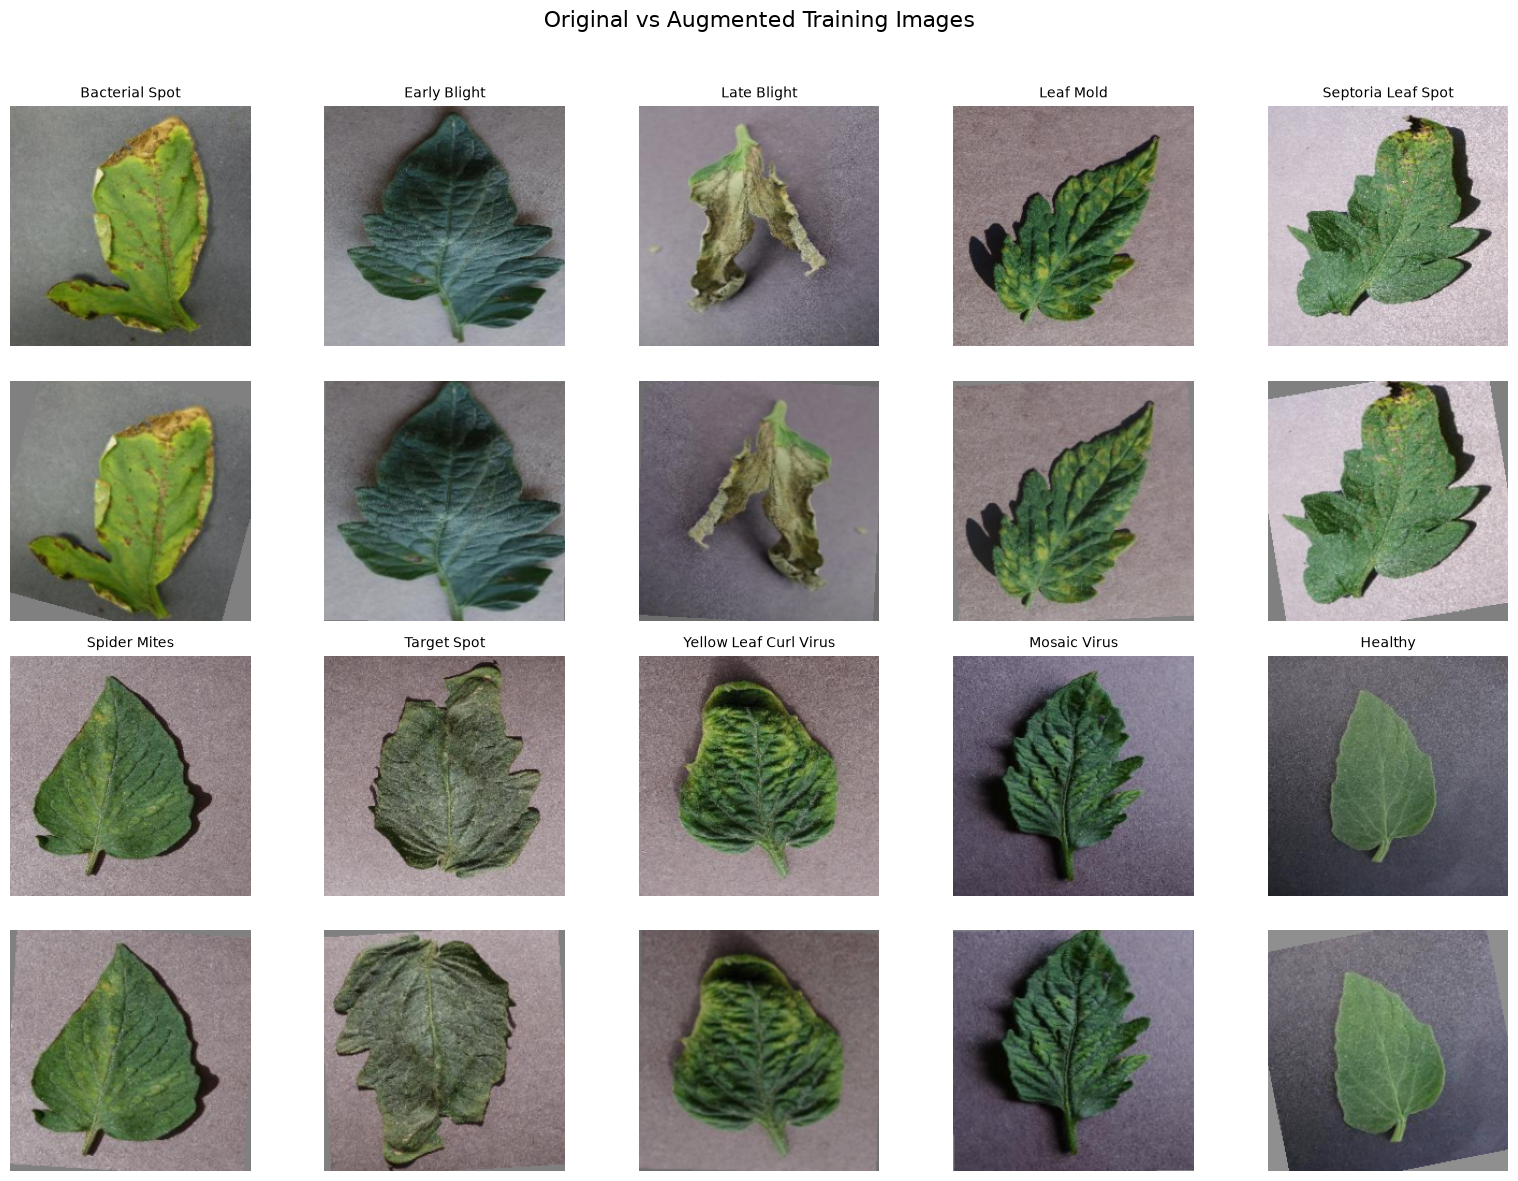

PART 11 — AUGMENTATION VISUAL REVIEW
Classes Visualized : 10
Samples per Class  : 1
Source Split       : train only

Figure Saved: D:\Tomato_Disease_Research\results\augmentation\training_augmentation_preview.png

PASS — Training-only augmentation preview generated.


In [ ]:
# ============================================================
# PART 11 — AUGMENTATION VISUAL REVIEW
# ============================================================


# ------------------------------------------------------------
# CLASS DISPLAY NAMES
# ------------------------------------------------------------

PART11_CLASS_DISPLAY_NAMES = {

    "Tomato_Bacterial_spot":
        "Bacterial Spot",

    "Tomato_Early_blight":
        "Early Blight",

    "Tomato_Late_blight":
        "Late Blight",

    "Tomato_Leaf_Mold":
        "Leaf Mold",

    "Tomato_Septoria_leaf_spot":
        "Septoria Leaf Spot",

    "Tomato_Spider_mites_Two_spotted_spider_mite":
        "Spider Mites",

    "Tomato__Target_Spot":
        "Target Spot",

    "Tomato__Tomato_YellowLeaf__Curl_Virus":
        "Yellow Leaf Curl Virus",

    "Tomato__Tomato_mosaic_virus":
        "Mosaic Virus",

    "Tomato_healthy":
        "Healthy"
}


# ------------------------------------------------------------
# SELECT ONE TRAINING IMAGE PER CLASS
# ------------------------------------------------------------

PART11_PREVIEW_RECORDS = []


PART11_CLASS_NAMES = sorted(
    PART11_TRAIN_DF[
        "class"
    ].unique()
)


for class_index, class_name in enumerate(
    PART11_CLASS_NAMES
):

    class_df = (
        PART11_TRAIN_DF[
            PART11_TRAIN_DF[
                "class"
            ]
            == class_name
        ]
    )


    sample_row = (
        class_df
        .sample(
            n=1,
            random_state=(
                SEED
                + class_index
            )
        )
        .iloc[0]
    )


    PART11_PREVIEW_RECORDS.append(
        {
            "class":
                class_name,

            "image_path":
                sample_row[
                    "image_path"
                ]
        }
    )


# ------------------------------------------------------------
# DENORMALIZATION
# ------------------------------------------------------------

PART11_MEAN_TENSOR = torch.tensor(
    IMAGENET_MEAN,
    dtype=torch.float32
).view(
    3,
    1,
    1
)


PART11_STD_TENSOR = torch.tensor(
    IMAGENET_STD,
    dtype=torch.float32
).view(
    3,
    1,
    1
)


def denormalize_for_display(
    tensor
):

    tensor = (
        tensor
        * PART11_STD_TENSOR
        + PART11_MEAN_TENSOR
    )


    tensor = (
        tensor
        .clamp(
            0,
            1
        )
    )


    return (
        tensor
        .permute(
            1,
            2,
            0
        )
        .cpu()
        .numpy()
    )


# ============================================================
# 4 × 5 PREVIEW
# ============================================================

fig, axes = plt.subplots(
    4,
    5,
    figsize=(
        16,
        12
    )
)


# ------------------------------------------------------------
# FIRST FIVE CLASSES
# ------------------------------------------------------------

for column_index in range(
    5
):

    record = (
        PART11_PREVIEW_RECORDS[
            column_index
        ]
    )


    class_name = (
        record[
            "class"
        ]
    )


    with Image.open(
        record[
            "image_path"
        ]
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        original_tensor = (
            EVALUATION_TRANSFORM(
                image_rgb
            )
        )


        set_augmentation_seed(
            SEED
            + 100
            + column_index
        )


        augmented_tensor = (
            TRAIN_TRANSFORM(
                image_rgb
            )
        )


    readable_name = (
        PART11_CLASS_DISPLAY_NAMES.get(
            class_name,
            class_name
        )
    )


    axes[
        0,
        column_index
    ].imshow(
        denormalize_for_display(
            original_tensor
        )
    )


    axes[
        0,
        column_index
    ].set_title(
        readable_name,
        fontsize=10
    )


    axes[
        0,
        column_index
    ].set_ylabel(
        "Original",
        fontsize=10
    )


    axes[
        0,
        column_index
    ].axis(
        "off"
    )


    axes[
        1,
        column_index
    ].imshow(
        denormalize_for_display(
            augmented_tensor
        )
    )


    axes[
        1,
        column_index
    ].set_ylabel(
        "Augmented",
        fontsize=10
    )


    axes[
        1,
        column_index
    ].axis(
        "off"
    )


# ------------------------------------------------------------
# SECOND FIVE CLASSES
# ------------------------------------------------------------

for column_index in range(
    5
):

    record_index = (
        column_index
        + 5
    )


    record = (
        PART11_PREVIEW_RECORDS[
            record_index
        ]
    )


    class_name = (
        record[
            "class"
        ]
    )


    with Image.open(
        record[
            "image_path"
        ]
    ) as image:

        image_rgb = (
            image.convert(
                "RGB"
            )
        )


        original_tensor = (
            EVALUATION_TRANSFORM(
                image_rgb
            )
        )


        set_augmentation_seed(
            SEED
            + 200
            + column_index
        )


        augmented_tensor = (
            TRAIN_TRANSFORM(
                image_rgb
            )
        )


    readable_name = (
        PART11_CLASS_DISPLAY_NAMES.get(
            class_name,
            class_name
        )
    )


    axes[
        2,
        column_index
    ].imshow(
        denormalize_for_display(
            original_tensor
        )
    )


    axes[
        2,
        column_index
    ].set_title(
        readable_name,
        fontsize=10
    )


    axes[
        2,
        column_index
    ].set_ylabel(
        "Original",
        fontsize=10
    )


    axes[
        2,
        column_index
    ].axis(
        "off"
    )


    axes[
        3,
        column_index
    ].imshow(
        denormalize_for_display(
            augmented_tensor
        )
    )


    axes[
        3,
        column_index
    ].set_ylabel(
        "Augmented",
        fontsize=10
    )


    axes[
        3,
        column_index
    ].axis(
        "off"
    )


# ------------------------------------------------------------
# FIGURE TITLE
# ------------------------------------------------------------

fig.suptitle(
    "Original vs Augmented Training Images",
    fontsize=16
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

plt.savefig(
    AUGMENTATION_PREVIEW_PNG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------------------
# FILE VERIFICATION
# ------------------------------------------------------------

if not (
    AUGMENTATION_PREVIEW_PNG.exists()
):

    raise RuntimeError(
        "Augmentation preview figure "
        "was not saved."
    )


print("=" * 70)
print("PART 11 — AUGMENTATION VISUAL REVIEW")
print("=" * 70)

print(
    "Classes Visualized :",
    len(
        PART11_PREVIEW_RECORDS
    )
)

print(
    "Samples per Class  : 1"
)

print(
    "Source Split       : train only"
)

print()

print(
    "Figure Saved:",
    AUGMENTATION_PREVIEW_PNG
)

print()

print(
    "PASS — Training-only augmentation "
    "preview generated."
)

In [ ]:
# ============================================================
# PART 11 — SAVE CONFIGURATION + FINAL VALIDATION
# ============================================================


# ============================================================
# CONFIGURATION REPORT
# ============================================================

AUGMENTATION_CONFIG = {

    "training_only": True,

    "output_resolution": [
        AUGMENT_IMAGE_SIZE,
        AUGMENT_IMAGE_SIZE
    ],

    "random_resized_crop": {

        "scale": list(
            RANDOM_CROP_SCALE
        ),

        "ratio": list(
            RANDOM_CROP_RATIO
        ),

        "interpolation":
            "bilinear",

        "antialias":
            True
    },

    "horizontal_flip_probability":
        float(
            HORIZONTAL_FLIP_PROBABILITY
        ),

    "vertical_flip_probability":
        float(
            VERTICAL_FLIP_PROBABILITY
        ),

    "rotation_degrees":
        float(
            ROTATION_DEGREES
        ),

    "rotation_fill_rgb": [
        128,
        128,
        128
    ],

    "color_jitter": {

        "probability":
            float(
                COLOR_JITTER_PROBABILITY
            ),

        "brightness":
            float(
                BRIGHTNESS_JITTER
            ),

        "contrast":
            float(
                CONTRAST_JITTER
            ),

        "saturation":
            float(
                SATURATION_JITTER
            ),

        "hue":
            float(
                HUE_JITTER
            )
    },

    "gaussian_blur": {

        "probability":
            float(
                GAUSSIAN_BLUR_PROBABILITY
            ),

        "kernel_size":
            int(
                GAUSSIAN_BLUR_KERNEL_SIZE
            ),

        "sigma":
            list(
                GAUSSIAN_BLUR_SIGMA
            )
    },

    "normalization": {

        "name":
            "ImageNet",

        "mean":
            list(
                IMAGENET_MEAN
            ),

        "std":
            list(
                IMAGENET_STD
            )
    },

    "validation_random_augmentation":
        False,

    "test_random_augmentation":
        False
}


# ------------------------------------------------------------
# SAVE CONFIG
# ------------------------------------------------------------

with open(
    AUGMENTATION_CONFIG_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        AUGMENTATION_CONFIG,
        file,
        indent=4
    )


# ============================================================
# VALIDATION REPORT
# ============================================================

AUGMENTATION_VALIDATION_REPORT = {

    "training_images_validated":
        int(
            EXPECTED_TRAIN_IMAGES
        ),

    "validation_images":
        int(
            EXPECTED_VALIDATION_IMAGES
        ),

    "test_images":
        int(
            EXPECTED_TEST_IMAGES
        ),

    "expected_tensor_shape":
        list(
            EXPECTED_AUGMENTED_SHAPE
        ),

    "observed_tensor_shapes":
        [
            list(
                shape
            )
            for shape
            in sorted(
                AUGMENT_OBSERVED_SHAPES
            )
        ],

    "observed_dtypes":
        sorted(
            AUGMENT_OBSERVED_DTYPES
        ),

    "invalid_shape_count":
        int(
            AUGMENT_INVALID_SHAPE_COUNT
        ),

    "invalid_dtype_count":
        int(
            AUGMENT_INVALID_DTYPE_COUNT
        ),

    "nonfinite_tensor_count":
        int(
            AUGMENT_NONFINITE_COUNT
        ),

    "observed_normalized_min":
        float(
            AUGMENT_OBSERVED_MIN
        ),

    "observed_normalized_max":
        float(
            AUGMENT_OBSERVED_MAX
        ),

    "stochasticity_sample_size":
        int(
            AUGMENTATION_TEST_SAMPLE_SIZE
        ),

    "stochastic_output_differences":
        int(
            STOCHASTIC_DIFFERENCE_COUNT
        ),

    "fixed_seed_reproducibility_failures":
        int(
            FIXED_SEED_REPRO_FAILURES
        ),

    "validation_determinism_failures":
        int(
            VALIDATION_DETERMINISM_FAILURES
        ),

    "test_determinism_failures":
        int(
            TEST_DETERMINISM_FAILURES
        )
}


# ------------------------------------------------------------
# SAVE VALIDATION
# ------------------------------------------------------------

with open(
    AUGMENTATION_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        AUGMENTATION_VALIDATION_REPORT,
        file,
        indent=4
    )


# ============================================================
# SAVED ARTIFACT VALIDATION
# ============================================================

PART11_REQUIRED_OUTPUTS = [

    AUGMENTATION_CONFIG_JSON,

    AUGMENTATION_VALIDATION_JSON,

    AUGMENTATION_PREVIEW_PNG
]


PART11_MISSING_OUTPUTS = [

    path

    for path
    in PART11_REQUIRED_OUTPUTS

    if not path.exists()
]


if PART11_MISSING_OUTPUTS:

    raise RuntimeError(
        "Missing PART 11 artifacts:\n"
        +
        "\n".join(
            str(path)
            for path
            in PART11_MISSING_OUTPUTS
        )
    )


# ------------------------------------------------------------
# RELOAD VALIDATION JSON
# ------------------------------------------------------------

with open(
    AUGMENTATION_VALIDATION_JSON,
    "r",
    encoding="utf-8"
) as file:

    RELOADED_AUGMENTATION_VALIDATION = (
        json.load(
            file
        )
    )


if (
    RELOADED_AUGMENTATION_VALIDATION[
        "training_images_validated"
    ]
    != EXPECTED_TRAIN_IMAGES
):

    raise RuntimeError(
        "Saved augmentation validation "
        "failed reload verification."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 70)
print("PART 11 — FINAL ROBUST DATA AUGMENTATION SUMMARY")
print("=" * 70)

print(
    "Training Images Validated :",
    f"{EXPECTED_TRAIN_IMAGES:,}"
)

print(
    "Validation Images         :",
    f"{EXPECTED_VALIDATION_IMAGES:,}"
)

print(
    "Test Images               :",
    f"{EXPECTED_TEST_IMAGES:,}"
)

print()

print(
    "Output Resolution         :",
    "224 × 224"
)

print(
    "Training Augmentation     : Enabled"
)

print(
    "Validation Augmentation   : Disabled"
)

print(
    "Test Augmentation         : Disabled"
)

print()

print(
    "Invalid Tensor Shapes     :",
    AUGMENT_INVALID_SHAPE_COUNT
)

print(
    "Invalid Tensor Dtypes     :",
    AUGMENT_INVALID_DTYPE_COUNT
)

print(
    "NaN / Inf Tensors         :",
    AUGMENT_NONFINITE_COUNT
)

print()

print(
    "Stochastic Samples        :",
    AUGMENTATION_TEST_SAMPLE_SIZE
)

print(
    "Different Random Outputs  :",
    STOCHASTIC_DIFFERENCE_COUNT
)

print(
    "Fixed-Seed Repro Failures :",
    FIXED_SEED_REPRO_FAILURES
)

print()

print(
    "Validation Determ. Failures:",
    VALIDATION_DETERMINISM_FAILURES
)

print(
    "Test Determinism Failures  :",
    TEST_DETERMINISM_FAILURES
)

print()

print(
    "Configuration JSON:",
    AUGMENTATION_CONFIG_JSON
)

print(
    "Validation JSON   :",
    AUGMENTATION_VALIDATION_JSON
)

print(
    "Preview Figure    :",
    AUGMENTATION_PREVIEW_PNG
)

print()

print(
    "PASS — Training-only augmentation protocol verified."
)

print(
    "PASS — Augmented tensor integrity verified."
)

print(
    "PASS — Training augmentation stochasticity verified."
)

print(
    "PASS — Fixed-seed augmentation reproducibility verified."
)

print(
    "PASS — Validation/test transforms remain deterministic."
)

print(
    "PASS — Saved augmentation artifacts reloaded successfully."
)

print()

print(
    "✓ PART 11 — ROBUST DATA AUGMENTATION COMPLETED"
)

print("=" * 70)

PART 11 — FINAL ROBUST DATA AUGMENTATION SUMMARY
Training Images Validated : 11,199
Validation Images         : 2,399
Test Images               : 2,399

Output Resolution         : 224 × 224
Training Augmentation     : Enabled
Validation Augmentation   : Disabled
Test Augmentation         : Disabled

Invalid Tensor Shapes     : 0
Invalid Tensor Dtypes     : 0
NaN / Inf Tensors         : 0

Stochastic Samples        : 30
Different Random Outputs  : 30
Fixed-Seed Repro Failures : 0

Validation Determ. Failures: 0
Test Determinism Failures  : 0

Configuration JSON: D:\Tomato_Disease_Research\results\augmentation\augmentation_config.json
Validation JSON   : D:\Tomato_Disease_Research\results\augmentation\augmentation_validation.json
Preview Figure    : D:\Tomato_Disease_Research\results\augmentation\training_augmentation_preview.png

PASS — Training-only augmentation protocol verified.
PASS — Augmented tensor integrity verified.
PASS — Training augmentation stochasticity verified.
PASS — F

In [ ]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is required for model training."
    )

DEVICE = torch.device("cuda")

print("GPU:", torch.cuda.get_device_name(0))
print(
    "VRAM:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
)

GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.00 GB


# PART 12 — PyTorch Dataset and DataLoader Construction

This part converts the verified train, validation, and test manifests into
PyTorch Dataset and DataLoader objects for model training and evaluation.

### Dataset Protocol

- Training images use the augmentation pipeline defined in PART 11
- Validation images use deterministic preprocessing
- Test images use deterministic preprocessing
- Class labels are converted to a fixed integer mapping from 0 to 9
- The same class-to-index mapping is used across all three partitions

### DataLoader Protocol

- Training loader is shuffled
- Validation and test loaders are not shuffled
- Batch size is initially set to 32
- CUDA-compatible pinned memory is enabled
- Non-blocking GPU transfer is supported
- All images remain represented exactly once per epoch
- No `drop_last` is used

### Research Validation

The pipeline is verified for:

- Dataset size consistency
- Class mapping consistency
- Image tensor shape
- Label range
- Tensor dtype
- Batch dimensions
- Training augmentation assignment
- Validation/test deterministic preprocessing assignment
- Full class coverage
- DataLoader coverage
- CUDA transfer compatibility

In [ ]:
# ============================================================
# PART 12 — DATASET / DATALOADER CONFIGURATION
# ============================================================

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader
from PIL import Image


# ------------------------------------------------------------
# EXPECTED DATASET COUNTS
# ------------------------------------------------------------

EXPECTED_TRAIN_IMAGES = 11199
EXPECTED_VALIDATION_IMAGES = 2399
EXPECTED_TEST_IMAGES = 2399

EXPECTED_TOTAL_IMAGES = 15997
EXPECTED_NUM_CLASSES = 10


# ------------------------------------------------------------
# DATALOADER CONFIGURATION
# ------------------------------------------------------------

BATCH_SIZE = 32

# Windows + Jupyter-safe configuration.
# Later, during training benchmarking, this can be increased
# if stable on the current system.
NUM_WORKERS = 0

PIN_MEMORY = bool(
    torch.cuda.is_available()
)

DROP_LAST = False

PERSISTENT_WORKERS = bool(
    NUM_WORKERS > 0
)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

DATALOADER_RESULTS_DIR = (
    RESULTS_DIR
    / "dataloader"
)

DATALOADER_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CLASS_MAPPING_JSON = (
    DATALOADER_RESULTS_DIR
    / "class_mapping.json"
)

DATALOADER_CONFIG_JSON = (
    DATALOADER_RESULTS_DIR
    / "dataloader_config.json"
)

DATALOADER_VALIDATION_JSON = (
    DATALOADER_RESULTS_DIR
    / "dataloader_validation.json"
)


# ============================================================
# REQUIRED TRANSFORM CHECK
# ============================================================

required_transform_names = [
    "TRAIN_TRANSFORM",
    "VALIDATION_TRANSFORM",
    "TEST_TRANSFORM"
]


missing_transforms = [
    transform_name

    for transform_name
    in required_transform_names

    if transform_name
    not in globals()
]


if missing_transforms:

    raise RuntimeError(
        "Required transforms are missing: "
        f"{missing_transforms}. "
        "Run PART 11 first."
    )


# ============================================================
# LOAD SPLIT FILES
# ============================================================

PART12_TRAIN_CSV = (
    SPLITS_DIR
    / "train_split.csv"
)

PART12_VALIDATION_CSV = (
    SPLITS_DIR
    / "validation_split.csv"
)

PART12_TEST_CSV = (
    SPLITS_DIR
    / "test_split.csv"
)


for path in [
    PART12_TRAIN_CSV,
    PART12_VALIDATION_CSV,
    PART12_TEST_CSV
]:

    if not path.exists():

        raise RuntimeError(
            f"Required split file missing: "
            f"{path}"
        )


PART12_TRAIN_DF = pd.read_csv(
    PART12_TRAIN_CSV,
    dtype=str,
    keep_default_na=False
)

PART12_VALIDATION_DF = pd.read_csv(
    PART12_VALIDATION_CSV,
    dtype=str,
    keep_default_na=False
)

PART12_TEST_DF = pd.read_csv(
    PART12_TEST_CSV,
    dtype=str,
    keep_default_na=False
)


# ------------------------------------------------------------
# SPLIT COUNT VALIDATION
# ------------------------------------------------------------

if len(
    PART12_TRAIN_DF
) != EXPECTED_TRAIN_IMAGES:

    raise RuntimeError(
        "Training split count mismatch."
    )


if len(
    PART12_VALIDATION_DF
) != EXPECTED_VALIDATION_IMAGES:

    raise RuntimeError(
        "Validation split count mismatch."
    )


if len(
    PART12_TEST_DF
) != EXPECTED_TEST_IMAGES:

    raise RuntimeError(
        "Test split count mismatch."
    )


if (
    len(PART12_TRAIN_DF)
    +
    len(PART12_VALIDATION_DF)
    +
    len(PART12_TEST_DF)
    != EXPECTED_TOTAL_IMAGES
):

    raise RuntimeError(
        "Total split image count mismatch."
    )


# ============================================================
# FIXED CLASS ORDER
# ============================================================

TRAIN_CLASSES = set(
    PART12_TRAIN_DF[
        "class"
    ].unique()
)

VALIDATION_CLASSES = set(
    PART12_VALIDATION_DF[
        "class"
    ].unique()
)

TEST_CLASSES = set(
    PART12_TEST_DF[
        "class"
    ].unique()
)


if not (
    TRAIN_CLASSES
    ==
    VALIDATION_CLASSES
    ==
    TEST_CLASSES
):

    raise RuntimeError(
        "Class sets are inconsistent "
        "across splits."
    )


CLASS_NAMES = sorted(
    TRAIN_CLASSES
)


if len(
    CLASS_NAMES
) != EXPECTED_NUM_CLASSES:

    raise RuntimeError(
        f"Expected 10 classes, "
        f"found {len(CLASS_NAMES)}."
    )


# ------------------------------------------------------------
# CLASS → INDEX
# ------------------------------------------------------------

CLASS_TO_INDEX = {
    class_name: index

    for index, class_name
    in enumerate(
        CLASS_NAMES
    )
}


# ------------------------------------------------------------
# INDEX → CLASS
# ------------------------------------------------------------

INDEX_TO_CLASS = {
    index: class_name

    for class_name, index
    in CLASS_TO_INDEX.items()
}


# ------------------------------------------------------------
# SAVE MAPPING
# ------------------------------------------------------------

CLASS_MAPPING_REPORT = {
    "num_classes":
        EXPECTED_NUM_CLASSES,

    "class_to_index":
        CLASS_TO_INDEX,

    "index_to_class": {
        str(index):
            class_name

        for index, class_name
        in INDEX_TO_CLASS.items()
    }
}


with open(
    CLASS_MAPPING_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        CLASS_MAPPING_REPORT,
        file,
        indent=4
    )


# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("=" * 70)
print("PART 12 — DATASET / DATALOADER CONFIGURATION")
print("=" * 70)

print(
    "Device             :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU                :",
        torch.cuda.get_device_name(0)
    )


print(
    "Batch Size         :",
    BATCH_SIZE
)

print(
    "Num Workers        :",
    NUM_WORKERS
)

print(
    "Pin Memory         :",
    PIN_MEMORY
)

print(
    "Persistent Workers :",
    PERSISTENT_WORKERS
)

print()

print(
    "Training Images    :",
    f"{len(PART12_TRAIN_DF):,}"
)

print(
    "Validation Images  :",
    f"{len(PART12_VALIDATION_DF):,}"
)

print(
    "Test Images        :",
    f"{len(PART12_TEST_DF):,}"
)

print()

print(
    "Classes            :",
    len(
        CLASS_NAMES
    )
)

print()


for class_name, class_index in (
    CLASS_TO_INDEX.items()
):

    print(
        f"{class_index:2d} -> "
        f"{class_name}"
    )


print()

print(
    "PASS — Fixed class mapping created."
)

print(
    "PASS — Split counts verified."
)

PART 12 — DATASET / DATALOADER CONFIGURATION
Device             : cuda
GPU                : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Batch Size         : 32
Num Workers        : 0
Pin Memory         : True
Persistent Workers : False

Training Images    : 11,199
Validation Images  : 2,399
Test Images        : 2,399

Classes            : 10

 0 -> Tomato_Bacterial_spot
 1 -> Tomato_Early_blight
 2 -> Tomato_Late_blight
 3 -> Tomato_Leaf_Mold
 4 -> Tomato_Septoria_leaf_spot
 5 -> Tomato_Spider_mites_Two_spotted_spider_mite
 6 -> Tomato__Target_Spot
 7 -> Tomato__Tomato_YellowLeaf__Curl_Virus
 8 -> Tomato__Tomato_mosaic_virus
 9 -> Tomato_healthy

PASS — Fixed class mapping created.
PASS — Split counts verified.


In [ ]:
# ============================================================
# PART 12 — CUSTOM PYTORCH DATASET
# ============================================================


class TomatoDiseaseDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_index
    ):

        self.dataframe = (
            dataframe
            .copy()
            .reset_index(
                drop=True
            )
        )

        self.transform = (
            transform
        )

        self.class_to_index = (
            class_to_index
        )


        # ----------------------------------------------------
        # REQUIRED COLUMNS
        # ----------------------------------------------------

        required_columns = {
            "image_id",
            "image_path",
            "class"
        }


        missing_columns = (
            required_columns
            - set(
                self.dataframe.columns
            )
        )


        if missing_columns:

            raise RuntimeError(
                "Dataset dataframe is missing "
                f"columns: {sorted(missing_columns)}"
            )


        # ----------------------------------------------------
        # LABEL VALIDATION
        # ----------------------------------------------------

        unknown_classes = (
            set(
                self.dataframe[
                    "class"
                ].unique()
            )
            -
            set(
                self.class_to_index.keys()
            )
        )


        if unknown_classes:

            raise RuntimeError(
                "Unknown classes detected: "
                f"{sorted(unknown_classes)}"
            )


    def __len__(
        self
    ):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = (
            self.dataframe
            .iloc[
                index
            ]
        )


        image_path = Path(
            row[
                "image_path"
            ]
        )


        class_name = (
            row[
                "class"
            ]
        )


        if not image_path.is_file():

            raise FileNotFoundError(
                f"Image not found: "
                f"{image_path}"
            )


        # ----------------------------------------------------
        # LOAD IMAGE
        # ----------------------------------------------------

        with Image.open(
            image_path
        ) as image:

            image = (
                image.convert(
                    "RGB"
                )
            )


            if (
                self.transform
                is not None
            ):

                image = (
                    self.transform(
                        image
                    )
                )


        # ----------------------------------------------------
        # LABEL
        # ----------------------------------------------------

        label = int(
            self.class_to_index[
                class_name
            ]
        )


        return (
            image,
            label
        )


# ============================================================
# CREATE DATASET OBJECTS
# ============================================================

TRAIN_DATASET = (
    TomatoDiseaseDataset(
        dataframe=(
            PART12_TRAIN_DF
        ),

        transform=(
            TRAIN_TRANSFORM
        ),

        class_to_index=(
            CLASS_TO_INDEX
        )
    )
)


VALIDATION_DATASET = (
    TomatoDiseaseDataset(
        dataframe=(
            PART12_VALIDATION_DF
        ),

        transform=(
            VALIDATION_TRANSFORM
        ),

        class_to_index=(
            CLASS_TO_INDEX
        )
    )
)


TEST_DATASET = (
    TomatoDiseaseDataset(
        dataframe=(
            PART12_TEST_DF
        ),

        transform=(
            TEST_TRANSFORM
        ),

        class_to_index=(
            CLASS_TO_INDEX
        )
    )
)


# ------------------------------------------------------------
# DATASET SIZE VALIDATION
# ------------------------------------------------------------

if len(
    TRAIN_DATASET
) != EXPECTED_TRAIN_IMAGES:

    raise RuntimeError(
        "TRAIN_DATASET size mismatch."
    )


if len(
    VALIDATION_DATASET
) != EXPECTED_VALIDATION_IMAGES:

    raise RuntimeError(
        "VALIDATION_DATASET size mismatch."
    )


if len(
    TEST_DATASET
) != EXPECTED_TEST_IMAGES:

    raise RuntimeError(
        "TEST_DATASET size mismatch."
    )


# ============================================================
# SINGLE-SAMPLE VALIDATION
# ============================================================

train_sample_image, train_sample_label = (
    TRAIN_DATASET[
        0
    ]
)


validation_sample_image, validation_sample_label = (
    VALIDATION_DATASET[
        0
    ]
)


test_sample_image, test_sample_label = (
    TEST_DATASET[
        0
    ]
)


EXPECTED_SAMPLE_SHAPE = (
    3,
    224,
    224
)


for (
    split_name,
    sample_image,
    sample_label
) in [

    (
        "train",
        train_sample_image,
        train_sample_label
    ),

    (
        "validation",
        validation_sample_image,
        validation_sample_label
    ),

    (
        "test",
        test_sample_image,
        test_sample_label
    )

]:

    if not isinstance(
        sample_image,
        torch.Tensor
    ):

        raise RuntimeError(
            f"{split_name} sample "
            "is not a tensor."
        )


    if tuple(
        sample_image.shape
    ) != EXPECTED_SAMPLE_SHAPE:

        raise RuntimeError(
            f"{split_name} tensor "
            f"shape mismatch: "
            f"{tuple(sample_image.shape)}"
        )


    if (
        sample_image.dtype
        != torch.float32
    ):

        raise RuntimeError(
            f"{split_name} tensor "
            "dtype mismatch."
        )


    if not torch.isfinite(
        sample_image
    ).all():

        raise RuntimeError(
            f"{split_name} sample "
            "contains NaN or Inf."
        )


    if not (
        0
        <= sample_label
        < EXPECTED_NUM_CLASSES
    ):

        raise RuntimeError(
            f"{split_name} label "
            "outside valid range."
        )


print("=" * 70)
print("PART 12 — PYTORCH DATASET VALIDATION")
print("=" * 70)

print(
    "Train Dataset      :",
    f"{len(TRAIN_DATASET):,}"
)

print(
    "Validation Dataset :",
    f"{len(VALIDATION_DATASET):,}"
)

print(
    "Test Dataset       :",
    f"{len(TEST_DATASET):,}"
)

print()

print(
    "Sample Shape       :",
    tuple(
        train_sample_image.shape
    )
)

print(
    "Sample Dtype       :",
    train_sample_image.dtype
)

print(
    "Label Range        :",
    f"0–{EXPECTED_NUM_CLASSES - 1}"
)

print()

print(
    "PASS — Dataset objects constructed."
)

print(
    "PASS — Sample tensor integrity verified."
)

PART 12 — PYTORCH DATASET VALIDATION
Train Dataset      : 11,199
Validation Dataset : 2,399
Test Dataset       : 2,399

Sample Shape       : (3, 224, 224)
Sample Dtype       : torch.float32
Label Range        : 0–9

PASS — Dataset objects constructed.
PASS — Sample tensor integrity verified.


In [ ]:
# ============================================================
# PART 12 — DATALOADER CONSTRUCTION
# ============================================================


# ------------------------------------------------------------
# REPRODUCIBLE WORKER INITIALIZATION
# ------------------------------------------------------------

def seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )


    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


# ------------------------------------------------------------
# TRAIN GENERATOR
# ------------------------------------------------------------

TRAIN_LOADER_GENERATOR = (
    torch.Generator()
)

TRAIN_LOADER_GENERATOR.manual_seed(
    SEED
)


# ============================================================
# COMMON LOADER ARGUMENTS
# ============================================================

COMMON_LOADER_ARGS = {

    "batch_size":
        BATCH_SIZE,

    "num_workers":
        NUM_WORKERS,

    "pin_memory":
        PIN_MEMORY,

    "drop_last":
        DROP_LAST
}


# ------------------------------------------------------------
# ONLY VALID WHEN num_workers > 0
# ------------------------------------------------------------

if NUM_WORKERS > 0:

    COMMON_LOADER_ARGS[
        "persistent_workers"
    ] = True


    COMMON_LOADER_ARGS[
        "prefetch_factor"
    ] = 2


# ============================================================
# TRAIN LOADER
# ============================================================

TRAIN_LOADER = DataLoader(

    TRAIN_DATASET,

    shuffle=True,

    worker_init_fn=(
        seed_worker
    ),

    generator=(
        TRAIN_LOADER_GENERATOR
    ),

    **COMMON_LOADER_ARGS
)


# ============================================================
# VALIDATION LOADER
# ============================================================

VALIDATION_LOADER = DataLoader(

    VALIDATION_DATASET,

    shuffle=False,

    worker_init_fn=(
        seed_worker
    ),

    **COMMON_LOADER_ARGS
)


# ============================================================
# TEST LOADER
# ============================================================

TEST_LOADER = DataLoader(

    TEST_DATASET,

    shuffle=False,

    worker_init_fn=(
        seed_worker
    ),

    **COMMON_LOADER_ARGS
)


# ------------------------------------------------------------
# EXPECTED NUMBER OF BATCHES
# ------------------------------------------------------------

EXPECTED_TRAIN_BATCHES = (
    int(
        np.ceil(
            EXPECTED_TRAIN_IMAGES
            /
            BATCH_SIZE
        )
    )
)


EXPECTED_VALIDATION_BATCHES = (
    int(
        np.ceil(
            EXPECTED_VALIDATION_IMAGES
            /
            BATCH_SIZE
        )
    )
)


EXPECTED_TEST_BATCHES = (
    int(
        np.ceil(
            EXPECTED_TEST_IMAGES
            /
            BATCH_SIZE
        )
    )
)


if len(
    TRAIN_LOADER
) != EXPECTED_TRAIN_BATCHES:

    raise RuntimeError(
        "Training DataLoader batch count mismatch."
    )


if len(
    VALIDATION_LOADER
) != EXPECTED_VALIDATION_BATCHES:

    raise RuntimeError(
        "Validation DataLoader batch count mismatch."
    )


if len(
    TEST_LOADER
) != EXPECTED_TEST_BATCHES:

    raise RuntimeError(
        "Test DataLoader batch count mismatch."
    )


print("=" * 70)
print("PART 12 — DATALOADER CONSTRUCTION")
print("=" * 70)

print(
    "Batch Size          :",
    BATCH_SIZE
)

print(
    "Train Batches       :",
    len(
        TRAIN_LOADER
    )
)

print(
    "Validation Batches  :",
    len(
        VALIDATION_LOADER
    )
)

print(
    "Test Batches        :",
    len(
        TEST_LOADER
    )
)

print()

print(
    "Train Shuffle       : Enabled"
)

print(
    "Validation Shuffle  : Disabled"
)

print(
    "Test Shuffle        : Disabled"
)

print()

print(
    "Pin Memory          :",
    PIN_MEMORY
)

print(
    "Num Workers         :",
    NUM_WORKERS
)

print(
    "Drop Last           :",
    DROP_LAST
)

print()

print(
    "PASS — DataLoaders constructed."
)

PART 12 — DATALOADER CONSTRUCTION
Batch Size          : 32
Train Batches       : 350
Validation Batches  : 75
Test Batches        : 75

Train Shuffle       : Enabled
Validation Shuffle  : Disabled
Test Shuffle        : Disabled

Pin Memory          : True
Num Workers         : 0
Drop Last           : False

PASS — DataLoaders constructed.


In [ ]:
# ============================================================
# PART 12 — BATCH + CUDA TRANSFER VALIDATION
# ============================================================


# ============================================================
# GET ONE BATCH FROM EACH LOADER
# ============================================================

TRAIN_BATCH_IMAGES, TRAIN_BATCH_LABELS = next(
    iter(
        TRAIN_LOADER
    )
)


VALIDATION_BATCH_IMAGES, VALIDATION_BATCH_LABELS = next(
    iter(
        VALIDATION_LOADER
    )
)


TEST_BATCH_IMAGES, TEST_BATCH_LABELS = next(
    iter(
        TEST_LOADER
    )
)


# ------------------------------------------------------------
# BATCH VALIDATION FUNCTION
# ------------------------------------------------------------

def validate_batch(
    split_name,
    images,
    labels
):

    if images.ndim != 4:

        raise RuntimeError(
            f"{split_name}: expected "
            "4D image batch."
        )


    if tuple(
        images.shape[1:]
    ) != (
        3,
        224,
        224
    ):

        raise RuntimeError(
            f"{split_name}: invalid "
            f"batch image shape "
            f"{tuple(images.shape)}."
        )


    if (
        images.dtype
        != torch.float32
    ):

        raise RuntimeError(
            f"{split_name}: image dtype "
            "is not float32."
        )


    if (
        labels.dtype
        != torch.int64
    ):

        raise RuntimeError(
            f"{split_name}: label dtype "
            "is not int64."
        )


    if images.shape[0] != labels.shape[0]:

        raise RuntimeError(
            f"{split_name}: batch image "
            "and label counts differ."
        )


    if not torch.isfinite(
        images
    ).all():

        raise RuntimeError(
            f"{split_name}: NaN/Inf "
            "detected."
        )


    label_min = int(
        labels.min().item()
    )

    label_max = int(
        labels.max().item()
    )


    if (
        label_min < 0
        or
        label_max
        >= EXPECTED_NUM_CLASSES
    ):

        raise RuntimeError(
            f"{split_name}: labels "
            "outside valid range."
        )


# ------------------------------------------------------------
# VALIDATE
# ------------------------------------------------------------

validate_batch(
    "train",
    TRAIN_BATCH_IMAGES,
    TRAIN_BATCH_LABELS
)


validate_batch(
    "validation",
    VALIDATION_BATCH_IMAGES,
    VALIDATION_BATCH_LABELS
)


validate_batch(
    "test",
    TEST_BATCH_IMAGES,
    TEST_BATCH_LABELS
)


# ============================================================
# CUDA TRANSFER SMOKE TEST
# ============================================================

CUDA_TRANSFER_VERIFIED = False


if torch.cuda.is_available():

    torch.cuda.empty_cache()


    CUDA_TRAIN_IMAGES = (
        TRAIN_BATCH_IMAGES.to(
            DEVICE,
            non_blocking=True
        )
    )


    CUDA_TRAIN_LABELS = (
        TRAIN_BATCH_LABELS.to(
            DEVICE,
            non_blocking=True
        )
    )


    if not (
        CUDA_TRAIN_IMAGES.is_cuda
        and
        CUDA_TRAIN_LABELS.is_cuda
    ):

        raise RuntimeError(
            "CUDA transfer failed."
        )


    CUDA_TRANSFER_VERIFIED = True


    CUDA_ALLOCATED_MB = (
        torch.cuda.memory_allocated(
            0
        )
        /
        1024**2
    )


    print("=" * 70)
    print("PART 12 — CUDA TRANSFER TEST")
    print("=" * 70)

    print(
        "GPU:",
        torch.cuda.get_device_name(
            0
        )
    )

    print(
        "Input Batch Device:",
        CUDA_TRAIN_IMAGES.device
    )

    print(
        "Label Device      :",
        CUDA_TRAIN_LABELS.device
    )

    print(
        "Batch Shape       :",
        tuple(
            CUDA_TRAIN_IMAGES.shape
        )
    )

    print(
        "GPU Memory Used   :",
        f"{CUDA_ALLOCATED_MB:.2f} MB"
    )

    print()

    print(
        "PASS — Non-blocking CUDA transfer verified."
    )


    # --------------------------------------------------------
    # RELEASE SMOKE-TEST BATCH
    # --------------------------------------------------------

    del CUDA_TRAIN_IMAGES
    del CUDA_TRAIN_LABELS

    torch.cuda.empty_cache()


else:

    print(
        "WARNING — CUDA unavailable; "
        "GPU transfer test skipped."
    )


# ============================================================
# BATCH SUMMARY
# ============================================================

print()

print("=" * 70)
print("PART 12 — BATCH VALIDATION SUMMARY")
print("=" * 70)

print(
    "Train Batch Shape      :",
    tuple(
        TRAIN_BATCH_IMAGES.shape
    )
)

print(
    "Validation Batch Shape :",
    tuple(
        VALIDATION_BATCH_IMAGES.shape
    )
)

print(
    "Test Batch Shape       :",
    tuple(
        TEST_BATCH_IMAGES.shape
    )
)

print()

print(
    "Image Dtype            :",
    TRAIN_BATCH_IMAGES.dtype
)

print(
    "Label Dtype            :",
    TRAIN_BATCH_LABELS.dtype
)

print()

print(
    "CUDA Transfer Verified :",
    CUDA_TRANSFER_VERIFIED
)

print()

print(
    "PASS — Train batch verified."
)

print(
    "PASS — Validation batch verified."
)

print(
    "PASS — Test batch verified."
)

PART 12 — CUDA TRANSFER TEST
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Input Batch Device: cuda:0
Label Device      : cuda:0
Batch Shape       : (32, 3, 224, 224)
GPU Memory Used   : 18.38 MB

PASS — Non-blocking CUDA transfer verified.

PART 12 — BATCH VALIDATION SUMMARY
Train Batch Shape      : (32, 3, 224, 224)
Validation Batch Shape : (32, 3, 224, 224)
Test Batch Shape       : (32, 3, 224, 224)

Image Dtype            : torch.float32
Label Dtype            : torch.int64

CUDA Transfer Verified : True

PASS — Train batch verified.
PASS — Validation batch verified.
PASS — Test batch verified.


In [ ]:
# ============================================================
# PART 12 — FINAL DATASET / DATALOADER VALIDATION
# ============================================================


# ============================================================
# LABEL DISTRIBUTION FROM MANIFESTS
# ============================================================

def create_label_distribution(
    dataframe,
    class_to_index
):

    distribution_df = (
        dataframe[
            "class"
        ]
        .value_counts()
        .rename_axis(
            "class"
        )
        .reset_index(
            name="image_count"
        )
    )


    distribution_df[
        "class_index"
    ] = (
        distribution_df[
            "class"
        ]
        .map(
            class_to_index
        )
    )


    distribution_df = (
        distribution_df
        .sort_values(
            "class_index"
        )
        .reset_index(
            drop=True
        )
    )


    return distribution_df


TRAIN_LABEL_DISTRIBUTION_DF = (
    create_label_distribution(
        PART12_TRAIN_DF,
        CLASS_TO_INDEX
    )
)


VALIDATION_LABEL_DISTRIBUTION_DF = (
    create_label_distribution(
        PART12_VALIDATION_DF,
        CLASS_TO_INDEX
    )
)


TEST_LABEL_DISTRIBUTION_DF = (
    create_label_distribution(
        PART12_TEST_DF,
        CLASS_TO_INDEX
    )
)


# ------------------------------------------------------------
# CLASS COVERAGE VALIDATION
# ------------------------------------------------------------

for (
    split_name,
    distribution_df
) in [

    (
        "train",
        TRAIN_LABEL_DISTRIBUTION_DF
    ),

    (
        "validation",
        VALIDATION_LABEL_DISTRIBUTION_DF
    ),

    (
        "test",
        TEST_LABEL_DISTRIBUTION_DF
    )

]:

    if len(
        distribution_df
    ) != EXPECTED_NUM_CLASSES:

        raise RuntimeError(
            f"{split_name} does not contain "
            "all 10 classes."
        )


    expected_indices = set(
        range(
            EXPECTED_NUM_CLASSES
        )
    )


    actual_indices = set(
        distribution_df[
            "class_index"
        ].astype(
            int
        )
    )


    if (
        actual_indices
        != expected_indices
    ):

        raise RuntimeError(
            f"{split_name} class-index "
            "coverage mismatch."
        )


# ============================================================
# CONFIGURATION REPORT
# ============================================================

DATALOADER_CONFIG_REPORT = {

    "device":
        str(
            DEVICE
        ),

    "cuda_available":
        bool(
            torch.cuda.is_available()
        ),

    "gpu_name":
        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),

    "batch_size":
        int(
            BATCH_SIZE
        ),

    "num_workers":
        int(
            NUM_WORKERS
        ),

    "pin_memory":
        bool(
            PIN_MEMORY
        ),

    "persistent_workers":
        bool(
            PERSISTENT_WORKERS
        ),

    "drop_last":
        bool(
            DROP_LAST
        ),

    "train_shuffle":
        True,

    "validation_shuffle":
        False,

    "test_shuffle":
        False,

    "train_batches":
        int(
            len(
                TRAIN_LOADER
            )
        ),

    "validation_batches":
        int(
            len(
                VALIDATION_LOADER
            )
        ),

    "test_batches":
        int(
            len(
                TEST_LOADER
            )
        )
}


with open(
    DATALOADER_CONFIG_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        DATALOADER_CONFIG_REPORT,
        file,
        indent=4
    )


# ============================================================
# VALIDATION REPORT
# ============================================================

DATALOADER_VALIDATION_REPORT = {

    "train_dataset_size":
        int(
            len(
                TRAIN_DATASET
            )
        ),

    "validation_dataset_size":
        int(
            len(
                VALIDATION_DATASET
            )
        ),

    "test_dataset_size":
        int(
            len(
                TEST_DATASET
            )
        ),

    "number_of_classes":
        int(
            len(
                CLASS_NAMES
            )
        ),

    "batch_size":
        int(
            BATCH_SIZE
        ),

    "train_batch_shape":
        list(
            TRAIN_BATCH_IMAGES.shape
        ),

    "validation_batch_shape":
        list(
            VALIDATION_BATCH_IMAGES.shape
        ),

    "test_batch_shape":
        list(
            TEST_BATCH_IMAGES.shape
        ),

    "image_dtype":
        str(
            TRAIN_BATCH_IMAGES.dtype
        ),

    "label_dtype":
        str(
            TRAIN_BATCH_LABELS.dtype
        ),

    "cuda_transfer_verified":
        bool(
            CUDA_TRANSFER_VERIFIED
        ),

    "train_all_classes_present":
        bool(
            len(
                TRAIN_LABEL_DISTRIBUTION_DF
            )
            == EXPECTED_NUM_CLASSES
        ),

    "validation_all_classes_present":
        bool(
            len(
                VALIDATION_LABEL_DISTRIBUTION_DF
            )
            == EXPECTED_NUM_CLASSES
        ),

    "test_all_classes_present":
        bool(
            len(
                TEST_LABEL_DISTRIBUTION_DF
            )
            == EXPECTED_NUM_CLASSES
        )
}


with open(
    DATALOADER_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        DATALOADER_VALIDATION_REPORT,
        file,
        indent=4
    )


# ============================================================
# SAVED ARTIFACT VERIFICATION
# ============================================================

PART12_REQUIRED_OUTPUTS = [
    CLASS_MAPPING_JSON,
    DATALOADER_CONFIG_JSON,
    DATALOADER_VALIDATION_JSON
]


missing_part12_outputs = [
    path

    for path
    in PART12_REQUIRED_OUTPUTS

    if not path.exists()
]


if missing_part12_outputs:

    raise RuntimeError(
        "Missing PART 12 artifacts:\n"
        +
        "\n".join(
            str(path)
            for path
            in missing_part12_outputs
        )
    )


# ============================================================
# RELOAD VALIDATION REPORT
# ============================================================

with open(
    DATALOADER_VALIDATION_JSON,
    "r",
    encoding="utf-8"
) as file:

    RELOADED_DATALOADER_VALIDATION = (
        json.load(
            file
        )
    )


if (
    RELOADED_DATALOADER_VALIDATION[
        "train_dataset_size"
    ]
    != EXPECTED_TRAIN_IMAGES
):

    raise RuntimeError(
        "Saved DataLoader validation "
        "failed reload verification."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 70)
print("PART 12 — FINAL PYTORCH DATASET / DATALOADER SUMMARY")
print("=" * 70)

print(
    "Device                    :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU                       :",
        torch.cuda.get_device_name(
            0
        )
    )


print()

print(
    "Training Dataset          :",
    f"{len(TRAIN_DATASET):,}"
)

print(
    "Validation Dataset        :",
    f"{len(VALIDATION_DATASET):,}"
)

print(
    "Test Dataset              :",
    f"{len(TEST_DATASET):,}"
)

print()

print(
    "Classes                   :",
    len(
        CLASS_NAMES
    )
)

print(
    "Batch Size                :",
    BATCH_SIZE
)

print(
    "Train Batches             :",
    len(
        TRAIN_LOADER
    )
)

print(
    "Validation Batches        :",
    len(
        VALIDATION_LOADER
    )
)

print(
    "Test Batches              :",
    len(
        TEST_LOADER
    )
)

print()

print(
    "Batch Tensor Shape        :",
    tuple(
        TRAIN_BATCH_IMAGES.shape
    )
)

print(
    "Image Tensor Dtype        :",
    TRAIN_BATCH_IMAGES.dtype
)

print(
    "Label Tensor Dtype        :",
    TRAIN_BATCH_LABELS.dtype
)

print()

print(
    "Pin Memory                :",
    PIN_MEMORY
)

print(
    "CUDA Transfer Verified    :",
    CUDA_TRANSFER_VERIFIED
)

print()

print(
    "PASS — Fixed class mapping verified."
)

print(
    "PASS — PyTorch Dataset objects verified."
)

print(
    "PASS — DataLoader batch integrity verified."
)

print(
    "PASS — All 10 classes preserved in all loaders."
)

print(
    "PASS — Training augmentation connected correctly."
)

print(
    "PASS — Validation/test deterministic transforms connected."
)

if torch.cuda.is_available():

    print(
        "PASS — CUDA non-blocking batch transfer verified."
    )


print(
    "PASS — DataLoader artifacts saved and reloaded."
)

print()

print(
    "✓ PART 12 — PYTORCH DATASET + DATALOADER COMPLETED"
)

print("=" * 70)

PART 12 — FINAL PYTORCH DATASET / DATALOADER SUMMARY
Device                    : cuda
GPU                       : NVIDIA GeForce RTX 3050 6GB Laptop GPU

Training Dataset          : 11,199
Validation Dataset        : 2,399
Test Dataset              : 2,399

Classes                   : 10
Batch Size                : 32
Train Batches             : 350
Validation Batches        : 75
Test Batches              : 75

Batch Tensor Shape        : (32, 3, 224, 224)
Image Tensor Dtype        : torch.float32
Label Tensor Dtype        : torch.int64

Pin Memory                : True
CUDA Transfer Verified    : True

PASS — Fixed class mapping verified.
PASS — PyTorch Dataset objects verified.
PASS — DataLoader batch integrity verified.
PASS — All 10 classes preserved in all loaders.
PASS — Training augmentation connected correctly.
PASS — Validation/test deterministic transforms connected.
PASS — CUDA non-blocking batch transfer verified.
PASS — DataLoader artifacts saved and reloaded.

✓ PART 12 —

# PART 13 — Class Imbalance Handling

The PlantVillage tomato training partition contains unequal numbers of images
across the ten disease classes.

To reduce bias toward majority classes, class-balanced weights are calculated
using only the training partition.

### Weighting Formula

For class \(c\):

\[
w_c = \frac{N}{K \times n_c}
\]

where:

- \(N\) = total number of training images
- \(K\) = number of classes
- \(n_c\) = number of training images belonging to class \(c\)
- \(w_c\) = loss weight assigned to class \(c\)

This formulation gives larger weights to minority classes and smaller weights
to majority classes while maintaining an average sample weight of approximately
1.0 across the training dataset.

### Experimental Protocol

- Class frequencies are computed from the training split only
- Validation and test distributions are not used for weight estimation
- Class weights follow the fixed class-to-index mapping from PART 12
- Weighted Cross Entropy is prepared for the main training experiments
- Standard unweighted Cross Entropy is also preserved for later ablation
- WeightedRandomSampler is not combined with weighted loss to avoid excessive
  minority-class compensation

### Research Validation

The class-imbalance pipeline verifies:

- Training-image count
- Complete ten-class coverage
- Fixed class-index alignment
- Positive and finite class weights
- Inverse relationship between class frequency and weight
- Balanced-weight mathematical consistency
- CUDA-compatible class-weight tensor
- Saved configuration and validation artifacts

In [ ]:
# ============================================================
# PART 13 — CLASS IMBALANCE CONFIGURATION
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# EXPECTED CONFIGURATION
# ------------------------------------------------------------

EXPECTED_TRAIN_IMAGES = 11199
EXPECTED_NUM_CLASSES = 10


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# INPUT FILES
# ------------------------------------------------------------

PART13_TRAIN_CSV = (
    SPLITS_DIR
    / "train_split.csv"
)

PART13_CLASS_MAPPING_JSON = (
    RESULTS_DIR
    / "dataloader"
    / "class_mapping.json"
)


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

CLASS_IMBALANCE_RESULTS_DIR = (
    RESULTS_DIR
    / "class_imbalance"
)

CLASS_IMBALANCE_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# OUTPUT FILES
# ------------------------------------------------------------

CLASS_WEIGHT_SUMMARY_CSV = (
    CLASS_IMBALANCE_RESULTS_DIR
    / "class_weight_summary.csv"
)

CLASS_WEIGHT_CONFIG_JSON = (
    CLASS_IMBALANCE_RESULTS_DIR
    / "class_weight_config.json"
)

CLASS_IMBALANCE_VALIDATION_JSON = (
    CLASS_IMBALANCE_RESULTS_DIR
    / "class_imbalance_validation.json"
)

CLASS_DISTRIBUTION_PLOT_PNG = (
    CLASS_IMBALANCE_RESULTS_DIR
    / "training_class_distribution.png"
)

CLASS_WEIGHT_PLOT_PNG = (
    CLASS_IMBALANCE_RESULTS_DIR
    / "training_class_weights.png"
)


# ============================================================
# INPUT VALIDATION
# ============================================================

if not PART13_TRAIN_CSV.exists():

    raise RuntimeError(
        "Training split file not found. "
        "Run PART 8 first."
    )


if not PART13_CLASS_MAPPING_JSON.exists():

    raise RuntimeError(
        "Class mapping file not found. "
        "Run PART 12 first."
    )


# ============================================================
# LOAD TRAINING SPLIT ONLY
# ============================================================

PART13_TRAIN_DF = pd.read_csv(
    PART13_TRAIN_CSV,
    dtype=str,
    keep_default_na=False
)


# ------------------------------------------------------------
# REQUIRED COLUMNS
# ------------------------------------------------------------

PART13_REQUIRED_COLUMNS = {
    "image_id",
    "image_path",
    "class",
    "split"
}


missing_columns = (
    PART13_REQUIRED_COLUMNS
    - set(
        PART13_TRAIN_DF.columns
    )
)


if missing_columns:

    raise RuntimeError(
        "Training split is missing columns: "
        f"{sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# VERIFY TRAINING-ONLY SOURCE
# ------------------------------------------------------------

if set(
    PART13_TRAIN_DF[
        "split"
    ].unique()
) != {"train"}:

    raise RuntimeError(
        "Non-training samples detected "
        "during class-weight computation."
    )


if len(
    PART13_TRAIN_DF
) != EXPECTED_TRAIN_IMAGES:

    raise RuntimeError(
        f"Expected {EXPECTED_TRAIN_IMAGES:,} "
        f"training images, "
        f"found {len(PART13_TRAIN_DF):,}."
    )


# ============================================================
# LOAD FIXED CLASS MAPPING FROM PART 12
# ============================================================

with open(
    PART13_CLASS_MAPPING_JSON,
    "r",
    encoding="utf-8"
) as file:

    PART13_MAPPING_REPORT = json.load(
        file
    )


CLASS_TO_INDEX_PART13 = {
    class_name: int(
        class_index
    )

    for class_name, class_index
    in PART13_MAPPING_REPORT[
        "class_to_index"
    ].items()
}


INDEX_TO_CLASS_PART13 = {
    int(class_index):
        class_name

    for class_index, class_name
    in PART13_MAPPING_REPORT[
        "index_to_class"
    ].items()
}


# ------------------------------------------------------------
# CLASS MAPPING VALIDATION
# ------------------------------------------------------------

if len(
    CLASS_TO_INDEX_PART13
) != EXPECTED_NUM_CLASSES:

    raise RuntimeError(
        "Class mapping does not contain "
        "10 classes."
    )


EXPECTED_CLASS_INDICES = set(
    range(
        EXPECTED_NUM_CLASSES
    )
)


ACTUAL_CLASS_INDICES = set(
    CLASS_TO_INDEX_PART13.values()
)


if (
    ACTUAL_CLASS_INDICES
    != EXPECTED_CLASS_INDICES
):

    raise RuntimeError(
        "Class mapping indices must be "
        "exactly 0 through 9."
    )


TRAINING_CLASSES_PART13 = set(
    PART13_TRAIN_DF[
        "class"
    ].unique()
)


if (
    TRAINING_CLASSES_PART13
    != set(
        CLASS_TO_INDEX_PART13.keys()
    )
):

    raise RuntimeError(
        "Training classes do not match "
        "the fixed PART 12 class mapping."
    )


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("PART 13 — CLASS IMBALANCE INPUT VALIDATION")
print("=" * 70)

print(
    "Weight Source       : Training split only"
)

print(
    "Training Images     :",
    f"{len(PART13_TRAIN_DF):,}"
)

print(
    "Classes             :",
    len(
        CLASS_TO_INDEX_PART13
    )
)

print(
    "Device              :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU                 :",
        torch.cuda.get_device_name(0)
    )


print()

print(
    "Validation Used     : No"
)

print(
    "Test Used           : No"
)

print()

print(
    "PASS — Training-only data source verified."
)

print(
    "PASS — Fixed PART 12 class mapping verified."
)

PART 13 — CLASS IMBALANCE INPUT VALIDATION
Weight Source       : Training split only
Training Images     : 11,199
Classes             : 10
Device              : cuda
GPU                 : NVIDIA GeForce RTX 3050 6GB Laptop GPU

Validation Used     : No
Test Used           : No

PASS — Training-only data source verified.
PASS — Fixed PART 12 class mapping verified.


In [ ]:
# ============================================================
# PART 13 — CLASS FREQUENCIES + BALANCED WEIGHTS
# ============================================================


# ============================================================
# TRAINING CLASS COUNTS
# ============================================================

PART13_CLASS_COUNTS = (
    PART13_TRAIN_DF[
        "class"
    ]
    .value_counts()
)


# ------------------------------------------------------------
# BUILD TABLE IN FIXED CLASS-INDEX ORDER
# ------------------------------------------------------------

CLASS_WEIGHT_RECORDS = []


for class_index in range(
    EXPECTED_NUM_CLASSES
):

    class_name = (
        INDEX_TO_CLASS_PART13[
            class_index
        ]
    )


    class_count = int(
        PART13_CLASS_COUNTS[
            class_name
        ]
    )


    class_percentage = (
        class_count
        /
        EXPECTED_TRAIN_IMAGES
        * 100
    )


    # --------------------------------------------------------
    # STANDARD BALANCED CLASS-WEIGHT FORMULA
    # --------------------------------------------------------

    class_weight = (
        EXPECTED_TRAIN_IMAGES
        /
        (
            EXPECTED_NUM_CLASSES
            * class_count
        )
    )


    CLASS_WEIGHT_RECORDS.append(
        {
            "class_index":
                int(
                    class_index
                ),

            "class":
                class_name,

            "training_images":
                int(
                    class_count
                ),

            "training_percentage":
                float(
                    class_percentage
                ),

            "class_weight":
                float(
                    class_weight
                )
        }
    )


CLASS_WEIGHT_DF = pd.DataFrame(
    CLASS_WEIGHT_RECORDS
)


# ============================================================
# DATASET-LEVEL IMBALANCE STATISTICS
# ============================================================

MAJORITY_CLASS_ROW = (
    CLASS_WEIGHT_DF
    .sort_values(
        "training_images",
        ascending=False
    )
    .iloc[0]
)


MINORITY_CLASS_ROW = (
    CLASS_WEIGHT_DF
    .sort_values(
        "training_images",
        ascending=True
    )
    .iloc[0]
)


MAJORITY_CLASS_NAME = (
    MAJORITY_CLASS_ROW[
        "class"
    ]
)


MINORITY_CLASS_NAME = (
    MINORITY_CLASS_ROW[
        "class"
    ]
)


MAJORITY_CLASS_COUNT = int(
    MAJORITY_CLASS_ROW[
        "training_images"
    ]
)


MINORITY_CLASS_COUNT = int(
    MINORITY_CLASS_ROW[
        "training_images"
    ]
)


TRAINING_IMBALANCE_RATIO = (
    MAJORITY_CLASS_COUNT
    /
    MINORITY_CLASS_COUNT
)


# ============================================================
# VALIDATION — COUNTS
# ============================================================

if int(
    CLASS_WEIGHT_DF[
        "training_images"
    ].sum()
) != EXPECTED_TRAIN_IMAGES:

    raise RuntimeError(
        "Training class counts do not sum "
        "to the expected training size."
    )


if len(
    CLASS_WEIGHT_DF
) != EXPECTED_NUM_CLASSES:

    raise RuntimeError(
        "Class-weight table does not contain "
        "10 classes."
    )


if (
    CLASS_WEIGHT_DF[
        "training_images"
    ]
    .le(0)
    .any()
):

    raise RuntimeError(
        "One or more classes contain "
        "zero training images."
    )


# ============================================================
# VALIDATION — WEIGHTS
# ============================================================

CLASS_WEIGHT_VALUES = (
    CLASS_WEIGHT_DF[
        "class_weight"
    ]
    .to_numpy(
        dtype=np.float64
    )
)


if not np.isfinite(
    CLASS_WEIGHT_VALUES
).all():

    raise RuntimeError(
        "Non-finite class weight detected."
    )


if not (
    CLASS_WEIGHT_VALUES
    > 0
).all():

    raise RuntimeError(
        "All class weights must be positive."
    )


# ------------------------------------------------------------
# WEIGHTED-SAMPLE MEAN SHOULD EQUAL 1
# ------------------------------------------------------------

WEIGHTED_SAMPLE_MEAN = float(
    np.sum(
        CLASS_WEIGHT_DF[
            "training_images"
        ].to_numpy(
            dtype=np.float64
        )
        *
        CLASS_WEIGHT_VALUES
    )
    /
    EXPECTED_TRAIN_IMAGES
)


if not np.isclose(
    WEIGHTED_SAMPLE_MEAN,
    1.0,
    atol=1e-10
):

    raise RuntimeError(
        "Balanced class weights failed "
        "the weighted-mean consistency check."
    )


# ------------------------------------------------------------
# n_c × w_c SHOULD BE CONSTANT
# ------------------------------------------------------------

CLASS_WEIGHT_DF[
    "weighted_class_contribution"
] = (
    CLASS_WEIGHT_DF[
        "training_images"
    ]
    *
    CLASS_WEIGHT_DF[
        "class_weight"
    ]
)


EXPECTED_CLASS_CONTRIBUTION = (
    EXPECTED_TRAIN_IMAGES
    /
    EXPECTED_NUM_CLASSES
)


MAX_CONTRIBUTION_DEVIATION = float(
    np.max(
        np.abs(
            CLASS_WEIGHT_DF[
                "weighted_class_contribution"
            ]
            .to_numpy(
                dtype=np.float64
            )
            -
            EXPECTED_CLASS_CONTRIBUTION
        )
    )
)


if not np.allclose(
    CLASS_WEIGHT_DF[
        "weighted_class_contribution"
    ],
    EXPECTED_CLASS_CONTRIBUTION,
    rtol=1e-10,
    atol=1e-10
):

    raise RuntimeError(
        "Balanced class-weight formula "
        "failed consistency validation."
    )


# ------------------------------------------------------------
# INVERSE FREQUENCY CHECK
# ------------------------------------------------------------

SORTED_BY_COUNT = (
    CLASS_WEIGHT_DF
    .sort_values(
        "training_images"
    )
    .reset_index(
        drop=True
    )
)


if not (
    SORTED_BY_COUNT[
        "class_weight"
    ]
    .is_monotonic_decreasing
):

    raise RuntimeError(
        "Class weights are not inversely "
        "related to class frequency."
    )


# ============================================================
# SAVE CLASS-WEIGHT TABLE
# ============================================================

CLASS_WEIGHT_DF.to_csv(
    CLASS_WEIGHT_SUMMARY_CSV,
    index=False
)


# ============================================================
# DISPLAY TABLE
# ============================================================

print("=" * 70)
print("PART 13 — TRAINING CLASS WEIGHT SUMMARY")
print("=" * 70)

display(
    CLASS_WEIGHT_DF[
        [
            "class_index",
            "class",
            "training_images",
            "training_percentage",
            "class_weight"
        ]
    ].round(
        {
            "training_percentage": 4,
            "class_weight": 6
        }
    )
)

print()

print(
    "Majority Class      :",
    MAJORITY_CLASS_NAME
)

print(
    "Majority Count      :",
    f"{MAJORITY_CLASS_COUNT:,}"
)

print()

print(
    "Minority Class      :",
    MINORITY_CLASS_NAME
)

print(
    "Minority Count      :",
    f"{MINORITY_CLASS_COUNT:,}"
)

print()

print(
    "Training Imbalance Ratio:",
    f"{TRAINING_IMBALANCE_RATIO:.2f}:1"
)

print()

print(
    "Weighted Sample Mean:",
    f"{WEIGHTED_SAMPLE_MEAN:.6f}"
)

print(
    "Expected Mean       : 1.000000"
)

print()

print(
    "PASS — Training class frequencies calculated."
)

print(
    "PASS — Balanced class weights calculated."
)

print(
    "PASS — Positive/finite weights verified."
)

print(
    "PASS — Inverse-frequency relationship verified."
)

print(
    "PASS — Weight normalization consistency verified."
)

PART 13 — TRAINING CLASS WEIGHT SUMMARY


,class_index,class,training_images,training_percentage,class_weight
0,0,Tomato_Bacterial_spot,1489,13.2958,0.752116
1,1,Tomato_Early_blight,700,6.2506,1.599857
2,2,Tomato_Late_blight,1331,11.8850,0.841397
3,3,Tomato_Leaf_Mold,666,5.9470,1.681532
4,4,Tomato_Septoria_leaf_spot,1240,11.0724,0.903145
5,5,Tomato_Spider_mites_Two_spotted_spider_mite,1174,10.4831,0.953918
6,6,Tomato__Target_Spot,983,8.7776,1.139268
7,7,Tomato__Tomato_YellowLeaf__Curl_Virus,2246,20.0554,0.498620
8,8,Tomato__Tomato_mosaic_virus,261,2.3306,4.290805
9,9,Tomato_healthy,1109,9.9027,1.009829



Majority Class      : Tomato__Tomato_YellowLeaf__Curl_Virus
Majority Count      : 2,246

Minority Class      : Tomato__Tomato_mosaic_virus
Minority Count      : 261

Training Imbalance Ratio: 8.61:1

Weighted Sample Mean: 1.000000
Expected Mean       : 1.000000

PASS — Training class frequencies calculated.
PASS — Balanced class weights calculated.
PASS — Positive/finite weights verified.
PASS — Inverse-frequency relationship verified.
PASS — Weight normalization consistency verified.


In [ ]:
# ============================================================
# PART 13 — PYTORCH CLASS-WEIGHT TENSOR
# ============================================================

import torch.nn as nn


# ============================================================
# BUILD WEIGHT TENSOR IN EXACT CLASS-INDEX ORDER
# ============================================================

CLASS_WEIGHTS_CPU = torch.tensor(
    CLASS_WEIGHT_DF
    .sort_values(
        "class_index"
    )[
        "class_weight"
    ]
    .to_numpy(
        dtype=np.float32
    ),
    dtype=torch.float32
)


# ------------------------------------------------------------
# VALIDATE TENSOR
# ------------------------------------------------------------

if tuple(
    CLASS_WEIGHTS_CPU.shape
) != (
    EXPECTED_NUM_CLASSES,
):

    raise RuntimeError(
        "Class-weight tensor must contain "
        "exactly 10 elements."
    )


if not torch.isfinite(
    CLASS_WEIGHTS_CPU
).all():

    raise RuntimeError(
        "Class-weight tensor contains "
        "NaN or Inf."
    )


if not torch.all(
    CLASS_WEIGHTS_CPU
    > 0
):

    raise RuntimeError(
        "Class-weight tensor contains "
        "non-positive values."
    )


# ============================================================
# GPU-READY WEIGHT TENSOR
# ============================================================

CLASS_WEIGHTS = (
    CLASS_WEIGHTS_CPU
    .to(
        DEVICE
    )
)


# ------------------------------------------------------------
# DEVICE CHECK
# ------------------------------------------------------------

if (
    DEVICE.type == "cuda"
    and
    not CLASS_WEIGHTS.is_cuda
):

    raise RuntimeError(
        "Class weights were not transferred "
        "to CUDA."
    )


# ============================================================
# LOSS FUNCTIONS
# ============================================================

# Main weighted loss option
WEIGHTED_CROSS_ENTROPY = (
    nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS
    )
)


# Baseline / future ablation
UNWEIGHTED_CROSS_ENTROPY = (
    nn.CrossEntropyLoss()
)


# ------------------------------------------------------------
# IMPORTANT TRAINING ALIASES
# ------------------------------------------------------------

CLASS_WEIGHTING_ENABLED = True

PRIMARY_CRITERION = (
    WEIGHTED_CROSS_ENTROPY
    if CLASS_WEIGHTING_ENABLED
    else UNWEIGHTED_CROSS_ENTROPY
)


# ============================================================
# LOSS SMOKE CHECK
# ============================================================

# Artificial logits only verify that the criterion can execute.
# They are NOT model results.

SMOKE_BATCH_SIZE = 10


SMOKE_LOGITS = torch.zeros(
    (
        SMOKE_BATCH_SIZE,
        EXPECTED_NUM_CLASSES
    ),
    dtype=torch.float32,
    device=DEVICE,
    requires_grad=True
)


SMOKE_LABELS = torch.arange(
    EXPECTED_NUM_CLASSES,
    dtype=torch.long,
    device=DEVICE
)


SMOKE_WEIGHTED_LOSS = (
    WEIGHTED_CROSS_ENTROPY(
        SMOKE_LOGITS,
        SMOKE_LABELS
    )
)


SMOKE_UNWEIGHTED_LOSS = (
    UNWEIGHTED_CROSS_ENTROPY(
        SMOKE_LOGITS,
        SMOKE_LABELS
    )
)


if not torch.isfinite(
    SMOKE_WEIGHTED_LOSS
):

    raise RuntimeError(
        "Weighted Cross Entropy produced "
        "a non-finite smoke-test loss."
    )


if not torch.isfinite(
    SMOKE_UNWEIGHTED_LOSS
):

    raise RuntimeError(
        "Unweighted Cross Entropy produced "
        "a non-finite smoke-test loss."
    )


# ------------------------------------------------------------
# CLEAN TEMPORARY GPU TENSORS
# ------------------------------------------------------------

del SMOKE_LOGITS
del SMOKE_LABELS

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# OUTPUT
# ============================================================

print("=" * 70)
print("PART 13 — PYTORCH LOSS CONFIGURATION")
print("=" * 70)

print(
    "Weight Tensor Shape :",
    tuple(
        CLASS_WEIGHTS.shape
    )
)

print(
    "Weight Tensor Dtype :",
    CLASS_WEIGHTS.dtype
)

print(
    "Weight Tensor Device:",
    CLASS_WEIGHTS.device
)

print()

print(
    "Weighted CE         : Available"
)

print(
    "Unweighted CE       : Available"
)

print(
    "Primary Criterion   :",
    (
        "Weighted Cross Entropy"
        if CLASS_WEIGHTING_ENABLED
        else "Unweighted Cross Entropy"
    )
)

print()

print(
    "Weighted Sampler    : Disabled"
)

print()

print(
    "PASS — Class weights aligned with class indices."
)

print(
    "PASS — GPU-ready class-weight tensor created."
)

print(
    "PASS — Weighted Cross Entropy execution verified."
)

print(
    "PASS — Unweighted baseline loss preserved."
)

PART 13 — PYTORCH LOSS CONFIGURATION
Weight Tensor Shape : (10,)
Weight Tensor Dtype : torch.float32
Weight Tensor Device: cuda:0

Weighted CE         : Available
Unweighted CE       : Available
Primary Criterion   : Weighted Cross Entropy

Weighted Sampler    : Disabled

PASS — Class weights aligned with class indices.
PASS — GPU-ready class-weight tensor created.
PASS — Weighted Cross Entropy execution verified.
PASS — Unweighted baseline loss preserved.


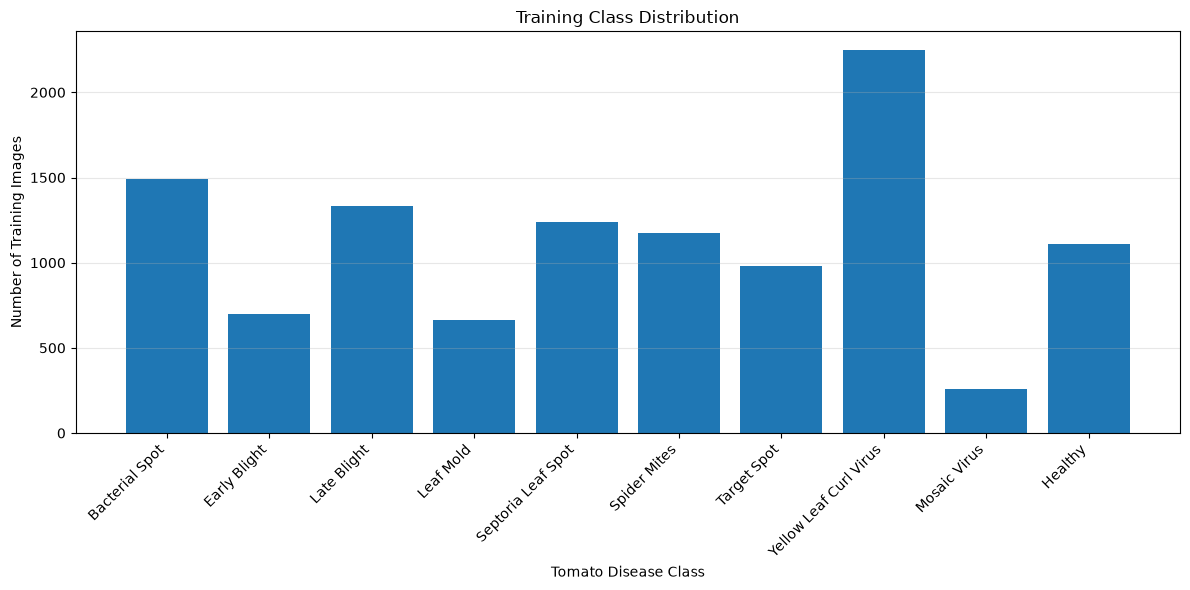

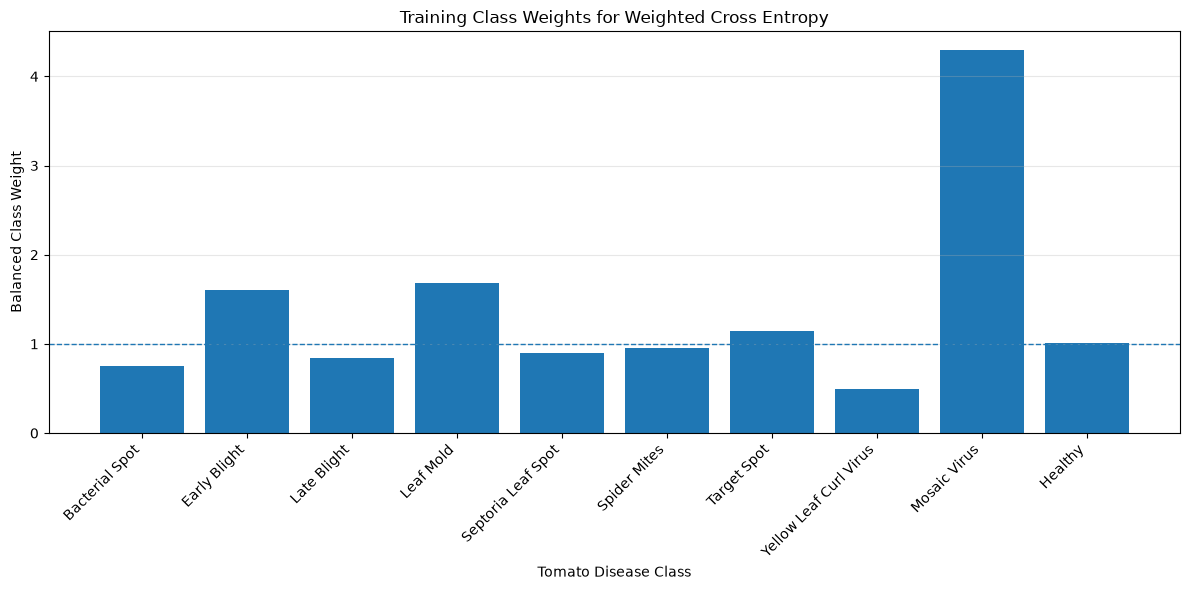

PART 13 — FINAL CLASS IMBALANCE HANDLING SUMMARY
Weight Source              : Training split only
Training Images            : 11,199
Classes                    : 10

Majority Class             : Tomato__Tomato_YellowLeaf__Curl_Virus
Majority Images            : 2,246

Minority Class             : Tomato__Tomato_mosaic_virus
Minority Images            : 261

Training Imbalance Ratio   : 8.61:1

Weight Formula             : N / (K × n_c)
Weighted Sample Mean       : 1.000000
Expected Weighted Mean     : 1.000000

Class Weight Tensor Shape  : (10,)
Class Weight Tensor Dtype  : torch.float32
Class Weight Tensor Device : cuda:0

Weighted Cross Entropy     : Ready
Unweighted Baseline        : Ready
WeightedRandomSampler      : Disabled

Class Weight CSV: D:\Tomato_Disease_Research\results\class_imbalance\class_weight_summary.csv
Configuration JSON: D:\Tomato_Disease_Research\results\class_imbalance\class_weight_config.json
Validation JSON: D:\Tomato_Disease_Research\results\class_imbalance\

In [ ]:
# ============================================================
# PART 13 — VISUALIZATION + FINAL VALIDATION
# ============================================================


# ============================================================
# READABLE CLASS NAMES
# ============================================================

PART13_CLASS_DISPLAY_NAMES = {

    "Tomato_Bacterial_spot":
        "Bacterial Spot",

    "Tomato_Early_blight":
        "Early Blight",

    "Tomato_Late_blight":
        "Late Blight",

    "Tomato_Leaf_Mold":
        "Leaf Mold",

    "Tomato_Septoria_leaf_spot":
        "Septoria Leaf Spot",

    "Tomato_Spider_mites_Two_spotted_spider_mite":
        "Spider Mites",

    "Tomato__Target_Spot":
        "Target Spot",

    "Tomato__Tomato_YellowLeaf__Curl_Virus":
        "Yellow Leaf Curl Virus",

    "Tomato__Tomato_mosaic_virus":
        "Mosaic Virus",

    "Tomato_healthy":
        "Healthy"
}


PLOT_CLASS_NAMES = [
    PART13_CLASS_DISPLAY_NAMES.get(
        class_name,
        class_name
    )

    for class_name
    in CLASS_WEIGHT_DF[
        "class"
    ]
]


# ============================================================
# TRAINING CLASS DISTRIBUTION PLOT
# ============================================================

plt.figure(
    figsize=(
        12,
        6
    )
)


plt.bar(
    PLOT_CLASS_NAMES,
    CLASS_WEIGHT_DF[
        "training_images"
    ]
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Number of Training Images"
)


plt.xlabel(
    "Tomato Disease Class"
)


plt.title(
    "Training Class Distribution"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    CLASS_DISTRIBUTION_PLOT_PNG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# CLASS WEIGHT PLOT
# ============================================================

plt.figure(
    figsize=(
        12,
        6
    )
)


plt.bar(
    PLOT_CLASS_NAMES,
    CLASS_WEIGHT_DF[
        "class_weight"
    ]
)


plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Balanced Class Weight"
)


plt.xlabel(
    "Tomato Disease Class"
)


plt.title(
    "Training Class Weights for Weighted Cross Entropy"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    CLASS_WEIGHT_PLOT_PNG,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# SAVE CONFIGURATION
# ============================================================

CLASS_WEIGHT_CONFIG = {

    "source_split":
        "train",

    "training_images":
        int(
            EXPECTED_TRAIN_IMAGES
        ),

    "number_of_classes":
        int(
            EXPECTED_NUM_CLASSES
        ),

    "formula":
        "N / (K * n_c)",

    "weighted_cross_entropy":
        True,

    "unweighted_cross_entropy_available":
        True,

    "weighted_random_sampler":
        False,

    "sampler_reason":
        (
            "WeightedRandomSampler is not combined "
            "with weighted loss to avoid excessive "
            "minority-class compensation."
        ),

    "class_weighting_enabled":
        bool(
            CLASS_WEIGHTING_ENABLED
        ),

    "weight_tensor_dtype":
        str(
            CLASS_WEIGHTS.dtype
        ),

    "weight_tensor_device":
        str(
            CLASS_WEIGHTS.device
        ),

    "class_weights": {

        row["class"]:
            float(
                row["class_weight"]
            )

        for row
        in CLASS_WEIGHT_DF[
            [
                "class",
                "class_weight"
            ]
        ].to_dict(
            "records"
        )
    }
}


with open(
    CLASS_WEIGHT_CONFIG_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        CLASS_WEIGHT_CONFIG,
        file,
        indent=4
    )


# ============================================================
# FINAL VALIDATION REPORT
# ============================================================

CLASS_IMBALANCE_VALIDATION_REPORT = {

    "training_only_source_verified":
        True,

    "training_images":
        int(
            EXPECTED_TRAIN_IMAGES
        ),

    "classes":
        int(
            EXPECTED_NUM_CLASSES
        ),

    "majority_class":
        str(
            MAJORITY_CLASS_NAME
        ),

    "majority_class_count":
        int(
            MAJORITY_CLASS_COUNT
        ),

    "minority_class":
        str(
            MINORITY_CLASS_NAME
        ),

    "minority_class_count":
        int(
            MINORITY_CLASS_COUNT
        ),

    "training_imbalance_ratio":
        float(
            TRAINING_IMBALANCE_RATIO
        ),

    "all_weights_positive":
        bool(
            np.all(
                CLASS_WEIGHT_VALUES
                > 0
            )
        ),

    "all_weights_finite":
        bool(
            np.isfinite(
                CLASS_WEIGHT_VALUES
            ).all()
        ),

    "weighted_sample_mean":
        float(
            WEIGHTED_SAMPLE_MEAN
        ),

    "expected_weighted_sample_mean":
        1.0,

    "maximum_balanced_contribution_deviation":
        float(
            MAX_CONTRIBUTION_DEVIATION
        ),

    "class_weight_tensor_shape":
        list(
            CLASS_WEIGHTS.shape
        ),

    "class_weight_tensor_dtype":
        str(
            CLASS_WEIGHTS.dtype
        ),

    "class_weight_tensor_device":
        str(
            CLASS_WEIGHTS.device
        ),

    "weighted_cross_entropy_ready":
        True,

    "unweighted_cross_entropy_ready":
        True,

    "weighted_random_sampler_used":
        False
}


with open(
    CLASS_IMBALANCE_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        CLASS_IMBALANCE_VALIDATION_REPORT,
        file,
        indent=4
    )


# ============================================================
# OUTPUT FILE VERIFICATION
# ============================================================

PART13_REQUIRED_OUTPUTS = [

    CLASS_WEIGHT_SUMMARY_CSV,

    CLASS_WEIGHT_CONFIG_JSON,

    CLASS_IMBALANCE_VALIDATION_JSON,

    CLASS_DISTRIBUTION_PLOT_PNG,

    CLASS_WEIGHT_PLOT_PNG
]


PART13_MISSING_OUTPUTS = [

    output_path

    for output_path
    in PART13_REQUIRED_OUTPUTS

    if not output_path.exists()
]


if PART13_MISSING_OUTPUTS:

    raise RuntimeError(
        "Missing PART 13 output artifacts:\n"
        +
        "\n".join(
            str(path)
            for path
            in PART13_MISSING_OUTPUTS
        )
    )


# ============================================================
# RELOAD VALIDATION FILE
# ============================================================

with open(
    CLASS_IMBALANCE_VALIDATION_JSON,
    "r",
    encoding="utf-8"
) as file:

    RELOADED_CLASS_IMBALANCE_VALIDATION = (
        json.load(
            file
        )
    )


if (
    RELOADED_CLASS_IMBALANCE_VALIDATION[
        "training_images"
    ]
    != EXPECTED_TRAIN_IMAGES
):

    raise RuntimeError(
        "Saved class-imbalance validation "
        "failed reload verification."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 70)
print("PART 13 — FINAL CLASS IMBALANCE HANDLING SUMMARY")
print("=" * 70)

print(
    "Weight Source              : Training split only"
)

print(
    "Training Images            :",
    f"{EXPECTED_TRAIN_IMAGES:,}"
)

print(
    "Classes                    :",
    EXPECTED_NUM_CLASSES
)

print()

print(
    "Majority Class             :",
    MAJORITY_CLASS_NAME
)

print(
    "Majority Images            :",
    f"{MAJORITY_CLASS_COUNT:,}"
)

print()

print(
    "Minority Class             :",
    MINORITY_CLASS_NAME
)

print(
    "Minority Images            :",
    f"{MINORITY_CLASS_COUNT:,}"
)

print()

print(
    "Training Imbalance Ratio   :",
    f"{TRAINING_IMBALANCE_RATIO:.2f}:1"
)

print()

print(
    "Weight Formula             : N / (K × n_c)"
)

print(
    "Weighted Sample Mean       :",
    f"{WEIGHTED_SAMPLE_MEAN:.6f}"
)

print(
    "Expected Weighted Mean     : 1.000000"
)

print()

print(
    "Class Weight Tensor Shape  :",
    tuple(
        CLASS_WEIGHTS.shape
    )
)

print(
    "Class Weight Tensor Dtype  :",
    CLASS_WEIGHTS.dtype
)

print(
    "Class Weight Tensor Device :",
    CLASS_WEIGHTS.device
)

print()

print(
    "Weighted Cross Entropy     : Ready"
)

print(
    "Unweighted Baseline        : Ready"
)

print(
    "WeightedRandomSampler      : Disabled"
)

print()

print(
    "Class Weight CSV:",
    CLASS_WEIGHT_SUMMARY_CSV
)

print(
    "Configuration JSON:",
    CLASS_WEIGHT_CONFIG_JSON
)

print(
    "Validation JSON:",
    CLASS_IMBALANCE_VALIDATION_JSON
)

print()

print(
    "PASS — Training-only class frequencies verified."
)

print(
    "PASS — Fixed class-index alignment verified."
)

print(
    "PASS — Balanced class-weight calculation verified."
)

print(
    "PASS — All class weights are positive and finite."
)

print(
    "PASS — Weighted-sample mean equals 1."
)

print(
    "PASS — CUDA-ready class-weight tensor verified."
)

print(
    "PASS — Weighted Cross Entropy is ready."
)

print(
    "PASS — Unweighted loss preserved for future ablation."
)

print(
    "PASS — Saved artifacts reloaded successfully."
)

print()

print(
    "✓ PART 13 — CLASS IMBALANCE HANDLING COMPLETED"
)

print("=" * 70)

# PART 14 — Six ImageNet-Pretrained Model Setup

This part initializes the six convolutional neural network architectures used
for the tomato disease classification benchmark.

All models are initialized with ImageNet-pretrained weights and adapted from
their original 1,000-class ImageNet output layer to the 10 tomato disease
classes defined in the fixed class mapping.

## Benchmark Architectures

1. ResNet50
2. MobileNetV3-Large
3. EfficientNet-B0
4. ConvNeXt-Tiny
5. VGG16
6. Inception v3

### Input Resolution Protocol

Five architectures use the common 224 × 224 preprocessing pipeline:

- ResNet50
- MobileNetV3-Large
- EfficientNet-B0
- ConvNeXt-Tiny
- VGG16

Inception v3 uses its architecture-specific 299 × 299 input protocol.

Separate 299 × 299 training, validation, and test DataLoaders are therefore
constructed for Inception without modifying the previously validated 224 × 224
pipeline.

### Inception Auxiliary Classifier

The ImageNet pretrained Inception v3 weights are loaded first. The auxiliary
classifier is then disabled so that all six benchmark models expose a single
10-class classification output.

### Research Validation

Each architecture is independently verified for:

- ImageNet pretrained initialization
- Correct 10-class output layer
- Expected benchmark parameter count
- Fully trainable parameters
- Correct input resolution
- CUDA forward-pass compatibility
- Finite output logits
- Output shape `(batch_size, 10)`
- Sequential GPU-memory cleanup

Models are instantiated one at a time during verification to avoid keeping all
six large networks simultaneously in GPU memory.

In [ ]:
# ============================================================
# PART 14 — PRETRAINED MODEL SETUP CONFIGURATION
# ============================================================

import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from torchvision import models, transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader


# ============================================================
# GENERAL CONFIGURATION
# ============================================================

NUM_CLASSES = 10

STANDARD_INPUT_SIZE = 224
INCEPTION_INPUT_SIZE = 299
INCEPTION_RESIZE_SIZE = 342

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


if DEVICE.type != "cuda":

    raise RuntimeError(
        "PART 14 model validation requires CUDA. "
        "CUDA GPU was not detected."
    )


# ============================================================
# REQUIRED PREVIOUS PART OBJECTS
# ============================================================

PART14_REQUIRED_GLOBALS = [
    "SEED",
    "CLASS_TO_INDEX",
    "TomatoDiseaseDataset",
    "PART12_TRAIN_DF",
    "PART12_VALIDATION_DF",
    "PART12_TEST_DF",
    "TRAIN_TRANSFORM",
    "VALIDATION_TRANSFORM",
    "TEST_TRANSFORM"
]


missing_globals = [
    variable_name

    for variable_name
    in PART14_REQUIRED_GLOBALS

    if variable_name
    not in globals()
]


if missing_globals:

    raise RuntimeError(
        "Required previous-part objects are missing:\n"
        + "\n".join(
            missing_globals
        )
        + "\nRun PARTS 11–13 before PART 14."
    )


# ============================================================
# MODEL NAMES
# ============================================================

MODEL_NAMES = [
    "ResNet50",
    "MobileNet",
    "EfficientNet-B0",
    "ConvNeXt-Tiny",
    "VGG16",
    "InceptionNet"
]


# ============================================================
# MODEL INPUT SIZE
# ============================================================

MODEL_INPUT_SIZES = {

    "ResNet50":
        STANDARD_INPUT_SIZE,

    "MobileNet":
        STANDARD_INPUT_SIZE,

    "EfficientNet-B0":
        STANDARD_INPUT_SIZE,

    "ConvNeXt-Tiny":
        STANDARD_INPUT_SIZE,

    "VGG16":
        STANDARD_INPUT_SIZE,

    "InceptionNet":
        INCEPTION_INPUT_SIZE
}


# ============================================================
# EXPECTED PARAMETER COUNTS
# ============================================================
#
# These values correspond to the benchmark architectures
# after replacing the ImageNet 1000-class classifier with
# the 10-class tomato classifier.
# ============================================================

EXPECTED_MODEL_PARAMETERS = {

    "ResNet50":
        23_528_522,

    "MobileNet":
        4_214_842,

    "EfficientNet-B0":
        4_020_358,

    "ConvNeXt-Tiny":
        27_827_818,

    "VGG16":
        134_301_514,

    "InceptionNet":
        21_806_058
}


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

MODEL_SETUP_RESULTS_DIR = (
    RESULTS_DIR
    / "model_setup"
)

MODEL_SETUP_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_SETUP_SUMMARY_CSV = (
    MODEL_SETUP_RESULTS_DIR
    / "model_setup_summary.csv"
)


MODEL_SETUP_VALIDATION_JSON = (
    MODEL_SETUP_RESULTS_DIR
    / "model_setup_validation.json"
)


# ============================================================
# GPU INFORMATION
# ============================================================

GPU_NAME = torch.cuda.get_device_name(
    0
)


GPU_TOTAL_MEMORY_GB = (
    torch.cuda.get_device_properties(
        0
    ).total_memory
    /
    1024**3
)


print("=" * 70)
print("PART 14 — PRETRAINED MODEL CONFIGURATION")
print("=" * 70)

print(
    "PyTorch Version     :",
    torch.__version__
)

print(
    "TorchVision Version :",
    torchvision.__version__
)

print()

print(
    "Device              :",
    DEVICE
)

print(
    "GPU                 :",
    GPU_NAME
)

print(
    "GPU VRAM            :",
    f"{GPU_TOTAL_MEMORY_GB:.2f} GB"
)

print()

print(
    "Number of Classes   :",
    NUM_CLASSES
)

print(
    "Standard Input      :",
    "224 × 224"
)

print(
    "Inception Input     :",
    "299 × 299"
)

print()

print(
    "Models              :",
    len(
        MODEL_NAMES
    )
)

for model_name in MODEL_NAMES:

    print(
        f"  - {model_name}"
    )

print()

print(
    "PASS — PART 14 configuration initialized."
)

PART 14 — PRETRAINED MODEL CONFIGURATION
PyTorch Version     : 2.12.1+cu126
TorchVision Version : 0.27.1+cu126

Device              : cuda
GPU                 : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU VRAM            : 6.00 GB

Number of Classes   : 10
Standard Input      : 224 × 224
Inception Input     : 299 × 299

Models              : 6
  - ResNet50
  - MobileNet
  - EfficientNet-B0
  - ConvNeXt-Tiny
  - VGG16
  - InceptionNet

PASS — PART 14 configuration initialized.


In [ ]:
# ============================================================
# PART 14 — INCEPTION-SPECIFIC 299 × 299 DATA PIPELINE
# ============================================================


# ============================================================
# NORMALIZATION
# ============================================================

INCEPTION_IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)

INCEPTION_IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)


# ============================================================
# BASELINE / DETERMINISTIC INCEPTION TRANSFORM
# ============================================================
#
# Resize to 342 and center crop to 299 follows the
# ImageNet-pretrained Inception evaluation geometry.
# ============================================================

INCEPTION_EVALUATION_TRANSFORM = (
    transforms.Compose(
        [
            transforms.Resize(
                INCEPTION_RESIZE_SIZE,
                interpolation=(
                    InterpolationMode.BILINEAR
                ),
                antialias=True
            ),

            transforms.CenterCrop(
                INCEPTION_INPUT_SIZE
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=INCEPTION_IMAGENET_MEAN,
                std=INCEPTION_IMAGENET_STD
            )
        ]
    )
)


# ============================================================
# IMPROVED TRAINING TRANSFORM — 299 × 299
# ============================================================

INCEPTION_TRAIN_TRANSFORM = (
    transforms.Compose(
        [
            transforms.RandomResizedCrop(
                size=(
                    INCEPTION_INPUT_SIZE,
                    INCEPTION_INPUT_SIZE
                ),

                scale=(
                    0.85,
                    1.00
                ),

                ratio=(
                    0.95,
                    1.05
                ),

                interpolation=(
                    InterpolationMode.BILINEAR
                ),

                antialias=True
            ),

            transforms.RandomHorizontalFlip(
                p=0.50
            ),

            transforms.RandomVerticalFlip(
                p=0.30
            ),

            transforms.RandomRotation(
                degrees=20,

                interpolation=(
                    InterpolationMode.BILINEAR
                ),

                fill=(
                    128,
                    128,
                    128
                )
            ),

            transforms.RandomApply(
                [
                    transforms.ColorJitter(
                        brightness=0.15,
                        contrast=0.15,
                        saturation=0.10,
                        hue=0.02
                    )
                ],
                p=0.60
            ),

            transforms.RandomApply(
                [
                    transforms.GaussianBlur(
                        kernel_size=3,
                        sigma=(
                            0.1,
                            1.0
                        )
                    )
                ],
                p=0.15
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=INCEPTION_IMAGENET_MEAN,
                std=INCEPTION_IMAGENET_STD
            )
        ]
    )
)


# ============================================================
# BASELINE TRAIN TRANSFORM
# ============================================================

INCEPTION_BASELINE_TRAIN_TRANSFORM = (
    INCEPTION_EVALUATION_TRANSFORM
)


INCEPTION_VALIDATION_TRANSFORM = (
    INCEPTION_EVALUATION_TRANSFORM
)


INCEPTION_TEST_TRANSFORM = (
    INCEPTION_EVALUATION_TRANSFORM
)


# ============================================================
# VERIFY RANDOMNESS IS TRAIN ONLY
# ============================================================

if "Random" not in repr(
    INCEPTION_TRAIN_TRANSFORM
):

    raise RuntimeError(
        "Inception improved training transform "
        "does not contain augmentation."
    )


if "Random" in repr(
    INCEPTION_VALIDATION_TRANSFORM
):

    raise RuntimeError(
        "Random transform detected in "
        "Inception validation preprocessing."
    )


if "Random" in repr(
    INCEPTION_TEST_TRANSFORM
):

    raise RuntimeError(
        "Random transform detected in "
        "Inception test preprocessing."
    )


# ============================================================
# DATASETS
# ============================================================

INCEPTION_BASELINE_TRAIN_DATASET = (
    TomatoDiseaseDataset(
        dataframe=(
            PART12_TRAIN_DF
        ),

        transform=(
            INCEPTION_BASELINE_TRAIN_TRANSFORM
        ),

        class_to_index=(
            CLASS_TO_INDEX
        )
    )
)


INCEPTION_TRAIN_DATASET = (
    TomatoDiseaseDataset(
        dataframe=(
            PART12_TRAIN_DF
        ),

        transform=(
            INCEPTION_TRAIN_TRANSFORM
        ),

        class_to_index=(
            CLASS_TO_INDEX
        )
    )
)


INCEPTION_VALIDATION_DATASET = (
    TomatoDiseaseDataset(
        dataframe=(
            PART12_VALIDATION_DF
        ),

        transform=(
            INCEPTION_VALIDATION_TRANSFORM
        ),

        class_to_index=(
            CLASS_TO_INDEX
        )
    )
)


INCEPTION_TEST_DATASET = (
    TomatoDiseaseDataset(
        dataframe=(
            PART12_TEST_DF
        ),

        transform=(
            INCEPTION_TEST_TRANSFORM
        ),

        class_to_index=(
            CLASS_TO_INDEX
        )
    )
)


# ============================================================
# INCEPTION LOADER SETTINGS
# ============================================================

INCEPTION_LOADER_BATCH_SIZE = 16

INCEPTION_NUM_WORKERS = 0

INCEPTION_PIN_MEMORY = True


# ------------------------------------------------------------
# SEPARATE SEEDED GENERATORS
# ------------------------------------------------------------

INCEPTION_BASELINE_GENERATOR = (
    torch.Generator()
)

INCEPTION_BASELINE_GENERATOR.manual_seed(
    SEED
)


INCEPTION_IMPROVED_GENERATOR = (
    torch.Generator()
)

INCEPTION_IMPROVED_GENERATOR.manual_seed(
    SEED
)


# ============================================================
# BASELINE TRAIN LOADER
# ============================================================

INCEPTION_BASELINE_TRAIN_LOADER = (
    DataLoader(
        INCEPTION_BASELINE_TRAIN_DATASET,

        batch_size=(
            INCEPTION_LOADER_BATCH_SIZE
        ),

        shuffle=True,

        num_workers=(
            INCEPTION_NUM_WORKERS
        ),

        pin_memory=(
            INCEPTION_PIN_MEMORY
        ),

        drop_last=False,

        generator=(
            INCEPTION_BASELINE_GENERATOR
        )
    )
)


# ============================================================
# IMPROVED TRAIN LOADER
# ============================================================

INCEPTION_TRAIN_LOADER = (
    DataLoader(
        INCEPTION_TRAIN_DATASET,

        batch_size=(
            INCEPTION_LOADER_BATCH_SIZE
        ),

        shuffle=True,

        num_workers=(
            INCEPTION_NUM_WORKERS
        ),

        pin_memory=(
            INCEPTION_PIN_MEMORY
        ),

        drop_last=False,

        generator=(
            INCEPTION_IMPROVED_GENERATOR
        )
    )
)


# ============================================================
# VALIDATION LOADER
# ============================================================

INCEPTION_VALIDATION_LOADER = (
    DataLoader(
        INCEPTION_VALIDATION_DATASET,

        batch_size=(
            INCEPTION_LOADER_BATCH_SIZE
        ),

        shuffle=False,

        num_workers=(
            INCEPTION_NUM_WORKERS
        ),

        pin_memory=(
            INCEPTION_PIN_MEMORY
        ),

        drop_last=False
    )
)


# ============================================================
# TEST LOADER
# ============================================================

INCEPTION_TEST_LOADER = (
    DataLoader(
        INCEPTION_TEST_DATASET,

        batch_size=(
            INCEPTION_LOADER_BATCH_SIZE
        ),

        shuffle=False,

        num_workers=(
            INCEPTION_NUM_WORKERS
        ),

        pin_memory=(
            INCEPTION_PIN_MEMORY
        ),

        drop_last=False
    )
)


# ============================================================
# BATCH VALIDATION
# ============================================================

inception_images, inception_labels = next(
    iter(
        INCEPTION_VALIDATION_LOADER
    )
)


EXPECTED_INCEPTION_BATCH_SHAPE = (
    INCEPTION_LOADER_BATCH_SIZE,
    3,
    INCEPTION_INPUT_SIZE,
    INCEPTION_INPUT_SIZE
)


if tuple(
    inception_images.shape
) != EXPECTED_INCEPTION_BATCH_SHAPE:

    raise RuntimeError(
        "Unexpected Inception batch shape: "
        f"{tuple(inception_images.shape)}"
    )


if inception_images.dtype != torch.float32:

    raise RuntimeError(
        "Inception input tensor must "
        "use torch.float32."
    )


if inception_labels.dtype != torch.int64:

    raise RuntimeError(
        "Inception labels must use torch.int64."
    )


if not torch.isfinite(
    inception_images
).all():

    raise RuntimeError(
        "Inception batch contains "
        "NaN or Inf."
    )


# ============================================================
# CUDA TRANSFER
# ============================================================

inception_cuda_batch = (
    inception_images.to(
        DEVICE,
        non_blocking=True
    )
)


if not inception_cuda_batch.is_cuda:

    raise RuntimeError(
        "Inception CUDA transfer failed."
    )


del inception_cuda_batch

torch.cuda.empty_cache()


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("PART 14 — INCEPTION 299 × 299 DATA PIPELINE")
print("=" * 70)

print(
    "Training Images       :",
    f"{len(INCEPTION_TRAIN_DATASET):,}"
)

print(
    "Validation Images     :",
    f"{len(INCEPTION_VALIDATION_DATASET):,}"
)

print(
    "Test Images           :",
    f"{len(INCEPTION_TEST_DATASET):,}"
)

print()

print(
    "Inception Input       :",
    "299 × 299"
)

print(
    "Evaluation Resize     :",
    "342 → CenterCrop 299"
)

print()

print(
    "Baseline Train Aug.   : Disabled"
)

print(
    "Improved Train Aug.   : Enabled"
)

print(
    "Validation Aug.       : Disabled"
)

print(
    "Test Aug.             : Disabled"
)

print()

print(
    "Loader Batch Size     :",
    INCEPTION_LOADER_BATCH_SIZE
)

print(
    "Validation Batch Shape:",
    tuple(
        inception_images.shape
    )
)

print()

print(
    "PASS — Independent Inception 299 × 299 "
    "pipeline constructed."
)

print(
    "PASS — Existing 224 × 224 pipeline remains unchanged."
)

PART 14 — INCEPTION 299 × 299 DATA PIPELINE
Training Images       : 11,199
Validation Images     : 2,399
Test Images           : 2,399

Inception Input       : 299 × 299
Evaluation Resize     : 342 → CenterCrop 299

Baseline Train Aug.   : Disabled
Improved Train Aug.   : Enabled
Validation Aug.       : Disabled
Test Aug.             : Disabled

Loader Batch Size     : 16
Validation Batch Shape: (16, 3, 299, 299)

PASS — Independent Inception 299 × 299 pipeline constructed.
PASS — Existing 224 × 224 pipeline remains unchanged.


In [ ]:
# ============================================================
# PART 14 — SIX PRETRAINED MODEL FACTORY
# ============================================================


# ============================================================
# WEIGHT ENUMS
# ============================================================

MODEL_PRETRAINED_WEIGHTS = {

    "ResNet50":
        models.ResNet50_Weights.DEFAULT,

    "MobileNet":
        models.MobileNet_V3_Large_Weights.DEFAULT,

    "EfficientNet-B0":
        models.EfficientNet_B0_Weights.DEFAULT,

    "ConvNeXt-Tiny":
        models.ConvNeXt_Tiny_Weights.DEFAULT,

    "VGG16":
        models.VGG16_Weights.DEFAULT,

    "InceptionNet":
        models.Inception_V3_Weights.DEFAULT
}


# ============================================================
# EXACT TORCHVISION ARCHITECTURE NAMES
# ============================================================

MODEL_ARCHITECTURE_NAMES = {

    "ResNet50":
        "torchvision.models.resnet50",

    "MobileNet":
        "torchvision.models.mobilenet_v3_large",

    "EfficientNet-B0":
        "torchvision.models.efficientnet_b0",

    "ConvNeXt-Tiny":
        "torchvision.models.convnext_tiny",

    "VGG16":
        "torchvision.models.vgg16",

    "InceptionNet":
        "torchvision.models.inception_v3"
}


# ============================================================
# WEIGHT-NAME HELPER
# ============================================================

def get_weight_name(
    weights
):

    return (
        f"{weights.__class__.__name__}."
        f"{weights.name}"
    )


# ============================================================
# MODEL FACTORY
# ============================================================

def create_pretrained_model(
    model_name,
    num_classes=NUM_CLASSES
):

    if model_name not in MODEL_NAMES:

        raise ValueError(
            f"Unsupported model: "
            f"{model_name}"
        )


    # ========================================================
    # RESNET50
    # ========================================================

    if model_name == "ResNet50":

        weights = (
            models.ResNet50_Weights.DEFAULT
        )


        model = models.resnet50(
            weights=weights
        )


        classifier_input_features = (
            model.fc.in_features
        )


        model.fc = nn.Linear(
            classifier_input_features,
            num_classes
        )


    # ========================================================
    # MOBILENET V3 LARGE
    # ========================================================

    elif model_name == "MobileNet":

        weights = (
            models.MobileNet_V3_Large_Weights.DEFAULT
        )


        model = models.mobilenet_v3_large(
            weights=weights
        )


        classifier_input_features = (
            model.classifier[-1].in_features
        )


        model.classifier[-1] = nn.Linear(
            classifier_input_features,
            num_classes
        )


    # ========================================================
    # EFFICIENTNET-B0
    # ========================================================

    elif model_name == "EfficientNet-B0":

        weights = (
            models.EfficientNet_B0_Weights.DEFAULT
        )


        model = models.efficientnet_b0(
            weights=weights
        )


        classifier_input_features = (
            model.classifier[-1].in_features
        )


        model.classifier[-1] = nn.Linear(
            classifier_input_features,
            num_classes
        )


    # ========================================================
    # CONVNEXT-TINY
    # ========================================================

    elif model_name == "ConvNeXt-Tiny":

        weights = (
            models.ConvNeXt_Tiny_Weights.DEFAULT
        )


        model = models.convnext_tiny(
            weights=weights
        )


        classifier_input_features = (
            model.classifier[-1].in_features
        )


        model.classifier[-1] = nn.Linear(
            classifier_input_features,
            num_classes
        )


    # ========================================================
    # VGG16
    # ========================================================

    elif model_name == "VGG16":

        weights = (
            models.VGG16_Weights.DEFAULT
        )


        model = models.vgg16(
            weights=weights
        )


        classifier_input_features = (
            model.classifier[-1].in_features
        )


        model.classifier[-1] = nn.Linear(
            classifier_input_features,
            num_classes
        )


    # ========================================================
    # INCEPTION V3
    # ========================================================

    elif model_name == "InceptionNet":

        weights = (
            models.Inception_V3_Weights.DEFAULT
        )


        # ----------------------------------------------------
        # Load complete pretrained ImageNet model first.
        # Pretrained builder initially includes AuxLogits.
        # ----------------------------------------------------

        model = models.inception_v3(
            weights=weights
        )


        # ----------------------------------------------------
        # Disable auxiliary classifier AFTER pretrained
        # state_dict has been loaded.
        # ----------------------------------------------------

        model.aux_logits = False

        model.AuxLogits = None


        # ----------------------------------------------------
        # Replace main 1000-class classifier
        # ----------------------------------------------------

        classifier_input_features = (
            model.fc.in_features
        )


        model.fc = nn.Linear(
            classifier_input_features,
            num_classes
        )


    # ========================================================
    # ENSURE FULL FINE-TUNING
    # ========================================================

    for parameter in (
        model.parameters()
    ):

        parameter.requires_grad = True


    return model

In [ ]:
# ============================================================
# PART 14 — ARCHITECTURE / PARAMETER VALIDATION
# ============================================================


# ============================================================
# COUNT PARAMETERS
# ============================================================

def count_model_parameters(
    model
):

    total_parameters = sum(
        parameter.numel()

        for parameter
        in model.parameters()
    )


    trainable_parameters = sum(
        parameter.numel()

        for parameter
        in model.parameters()

        if parameter.requires_grad
    )


    return (
        total_parameters,
        trainable_parameters
    )


# ============================================================
# MODEL SETUP RECORDS
# ============================================================

MODEL_SETUP_RECORDS = []


print("=" * 70)
print("PART 14 — PRETRAINED ARCHITECTURE VALIDATION")
print("=" * 70)


for model_name in MODEL_NAMES:

    print()

    print("-" * 70)

    print(
        "Creating:",
        model_name
    )


    # --------------------------------------------------------
    # CREATE FRESH IMAGE-NET PRETRAINED MODEL
    # --------------------------------------------------------

    model = create_pretrained_model(
        model_name
    )


    # --------------------------------------------------------
    # PARAMETER COUNTS
    # --------------------------------------------------------

    (
        total_parameters,
        trainable_parameters
    ) = count_model_parameters(
        model
    )


    expected_parameters = (
        EXPECTED_MODEL_PARAMETERS[
            model_name
        ]
    )


    # --------------------------------------------------------
    # PARAMETER COUNT MUST MATCH ARCHITECTURE LOCK
    # --------------------------------------------------------

    if (
        total_parameters
        != expected_parameters
    ):

        raise RuntimeError(
            f"{model_name} parameter mismatch.\n"
            f"Expected : {expected_parameters:,}\n"
            f"Observed : {total_parameters:,}"
        )


    if (
        trainable_parameters
        != total_parameters
    ):

        raise RuntimeError(
            f"{model_name} is not fully trainable."
        )


    # --------------------------------------------------------
    # INCEPTION AUXILIARY HEAD VALIDATION
    # --------------------------------------------------------

    if model_name == "InceptionNet":

        if model.aux_logits is not False:

            raise RuntimeError(
                "Inception auxiliary classifier "
                "was not disabled."
            )


        if model.AuxLogits is not None:

            raise RuntimeError(
                "Inception AuxLogits module "
                "still exists."
            )


    # --------------------------------------------------------
    # RECORD
    # --------------------------------------------------------

    MODEL_SETUP_RECORDS.append(
        {
            "model":
                model_name,

            "torchvision_architecture":
                MODEL_ARCHITECTURE_NAMES[
                    model_name
                ],

            "pretrained_weights":
                get_weight_name(
                    MODEL_PRETRAINED_WEIGHTS[
                        model_name
                    ]
                ),

            "input_size":
                int(
                    MODEL_INPUT_SIZES[
                        model_name
                    ]
                ),

            "output_classes":
                int(
                    NUM_CLASSES
                ),

            "total_parameters":
                int(
                    total_parameters
                ),

            "trainable_parameters":
                int(
                    trainable_parameters
                )
        }
    )


    print(
        "Pretrained Weights:",
        get_weight_name(
            MODEL_PRETRAINED_WEIGHTS[
                model_name
            ]
        )
    )

    print(
        "Input Resolution  :",
        f"{MODEL_INPUT_SIZES[model_name]}"
        " × "
        f"{MODEL_INPUT_SIZES[model_name]}"
    )

    print(
        "Total Parameters  :",
        f"{total_parameters:,}"
    )

    print(
        "Trainable Params   :",
        f"{trainable_parameters:,}"
    )

    print(
        "Output Classes     :",
        NUM_CLASSES
    )


    if model_name == "InceptionNet":

        print(
            "Aux Classifier    : Disabled"
        )


    print(
        "PASS — Architecture parameter count verified."
    )


    # --------------------------------------------------------
    # RELEASE MODEL
    # --------------------------------------------------------

    del model

    gc.collect()

    torch.cuda.empty_cache()


# ============================================================
# DATAFRAME
# ============================================================

MODEL_SETUP_DF = pd.DataFrame(
    MODEL_SETUP_RECORDS
)


print()

print("=" * 70)
print("MODEL PARAMETER SUMMARY")
print("=" * 70)

display(
    MODEL_SETUP_DF
    [
        [
            "model",
            "input_size",
            "output_classes",
            "total_parameters",
            "trainable_parameters"
        ]
    ]
)

PART 14 — PRETRAINED ARCHITECTURE VALIDATION

----------------------------------------------------------------------
Creating: ResNet50
Pretrained Weights: ResNet50_Weights.IMAGENET1K_V2
Input Resolution  : 224 × 224
Total Parameters  : 23,528,522
Trainable Params   : 23,528,522
Output Classes     : 10
PASS — Architecture parameter count verified.

----------------------------------------------------------------------
Creating: MobileNet
Pretrained Weights: MobileNet_V3_Large_Weights.IMAGENET1K_V2
Input Resolution  : 224 × 224
Total Parameters  : 4,214,842
Trainable Params   : 4,214,842
Output Classes     : 10
PASS — Architecture parameter count verified.

----------------------------------------------------------------------
Creating: EfficientNet-B0
Pretrained Weights: EfficientNet_B0_Weights.IMAGENET1K_V1
Input Resolution  : 224 × 224
Total Parameters  : 4,020,358
Trainable Params   : 4,020,358
Output Classes     : 10
PASS — Architecture parameter count verified.

------------------

,model,input_size,output_classes,total_parameters,trainable_parameters
0,ResNet50,224,10,23528522,23528522
1,MobileNet,224,10,4214842,4214842
2,EfficientNet-B0,224,10,4020358,4020358
3,ConvNeXt-Tiny,224,10,27827818,27827818
4,VGG16,224,10,134301514,134301514
5,InceptionNet,299,10,21806058,21806058


In [ ]:
# ============================================================
# PART 14 — SEQUENTIAL CUDA FORWARD-PASS VALIDATION
# ============================================================


# ============================================================
# GPU RESULT RECORDS
# ============================================================

GPU_SMOKE_RECORDS = []


print("=" * 70)
print("PART 14 — CUDA MODEL FORWARD-PASS VALIDATION")
print("=" * 70)

print(
    "GPU:",
    torch.cuda.get_device_name(
        0
    )
)

print()


for model_name in MODEL_NAMES:

    print("-" * 70)

    print(
        "Testing:",
        model_name
    )


    # --------------------------------------------------------
    # CLEAN GPU BEFORE MODEL
    # --------------------------------------------------------

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats(
        0
    )


    # --------------------------------------------------------
    # FRESH PRETRAINED MODEL
    # --------------------------------------------------------

    model = create_pretrained_model(
        model_name
    )


    model = model.to(
        DEVICE
    )


    model.eval()


    # --------------------------------------------------------
    # MODEL-SPECIFIC INPUT SIZE
    # --------------------------------------------------------

    input_size = (
        MODEL_INPUT_SIZES[
            model_name
        ]
    )


    dummy_input = torch.randn(
        (
            1,
            3,
            input_size,
            input_size
        ),

        dtype=torch.float32,

        device=DEVICE
    )


    # --------------------------------------------------------
    # FORWARD PASS
    # --------------------------------------------------------

    with torch.inference_mode():

        output = model(
            dummy_input
        )


    # --------------------------------------------------------
    # OUTPUT TYPE
    # --------------------------------------------------------

    if not isinstance(
        output,
        torch.Tensor
    ):

        raise RuntimeError(
            f"{model_name} did not return "
            "a single tensor output."
        )


    # --------------------------------------------------------
    # OUTPUT SHAPE
    # --------------------------------------------------------

    expected_output_shape = (
        1,
        NUM_CLASSES
    )


    if tuple(
        output.shape
    ) != expected_output_shape:

        raise RuntimeError(
            f"{model_name} output shape mismatch.\n"
            f"Expected: {expected_output_shape}\n"
            f"Observed: {tuple(output.shape)}"
        )


    # --------------------------------------------------------
    # FINITE LOGITS
    # --------------------------------------------------------

    if not torch.isfinite(
        output
    ).all():

        raise RuntimeError(
            f"{model_name} produced "
            "NaN or Inf logits."
        )


    # --------------------------------------------------------
    # SYNCHRONIZE BEFORE MEMORY MEASUREMENT
    # --------------------------------------------------------

    torch.cuda.synchronize()


    peak_memory_mb = (
        torch.cuda.max_memory_allocated(
            0
        )
        /
        1024**2
    )


    current_memory_mb = (
        torch.cuda.memory_allocated(
            0
        )
        /
        1024**2
    )


    # --------------------------------------------------------
    # RECORD
    # --------------------------------------------------------

    GPU_SMOKE_RECORDS.append(
        {
            "model":
                model_name,

            "input_size":
                input_size,

            "output_shape":
                str(
                    tuple(
                        output.shape
                    )
                ),

            "finite_output":
                True,

            "peak_cuda_memory_mb":
                float(
                    peak_memory_mb
                )
        }
    )


    print(
        "Input Shape      :",
        tuple(
            dummy_input.shape
        )
    )

    print(
        "Output Shape     :",
        tuple(
            output.shape
        )
    )

    print(
        "Output Finite    : True"
    )

    print(
        "Peak CUDA Memory :",
        f"{peak_memory_mb:.2f} MB"
    )

    print(
        "Current CUDA Mem :",
        f"{current_memory_mb:.2f} MB"
    )

    print()

    print(
        "PASS — CUDA forward pass verified."
    )


    # --------------------------------------------------------
    # RELEASE GPU MEMORY
    # --------------------------------------------------------

    del output
    del dummy_input
    del model

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


    remaining_memory_mb = (
        torch.cuda.memory_allocated(
            0
        )
        /
        1024**2
    )


    print(
        "GPU Memory After Cleanup:",
        f"{remaining_memory_mb:.2f} MB"
    )

    print()


# ============================================================
# GPU SMOKE DATAFRAME
# ============================================================

GPU_SMOKE_DF = pd.DataFrame(
    GPU_SMOKE_RECORDS
)


# ------------------------------------------------------------
# MERGE WITH MODEL SUMMARY
# ------------------------------------------------------------

MODEL_SETUP_DF = (
    MODEL_SETUP_DF
    .merge(
        GPU_SMOKE_DF,
        on=[
            "model",
            "input_size"
        ],
        how="left"
    )
)


# ------------------------------------------------------------
# VERIFY ALL SIX MODELS
# ------------------------------------------------------------

if len(
    MODEL_SETUP_DF
) != 6:

    raise RuntimeError(
        "Expected six verified models."
    )


if not (
    MODEL_SETUP_DF[
        "finite_output"
    ]
    .eq(
        True
    )
    .all()
):

    raise RuntimeError(
        "One or more models failed "
        "finite-output validation."
    )


print("=" * 70)
print("PART 14 — CUDA SMOKE TEST SUMMARY")
print("=" * 70)

display(
    MODEL_SETUP_DF[
        [
            "model",
            "input_size",
            "output_shape",
            "peak_cuda_memory_mb"
        ]
    ].round(
        {
            "peak_cuda_memory_mb": 2
        }
    )
)

PART 14 — CUDA MODEL FORWARD-PASS VALIDATION
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

----------------------------------------------------------------------
Testing: ResNet50
Input Shape      : (1, 3, 224, 224)
Output Shape     : (1, 10)
Output Finite    : True
Peak CUDA Memory : 101.32 MB
Current CUDA Mem : 98.69 MB

PASS — CUDA forward pass verified.
GPU Memory After Cleanup: 8.13 MB

----------------------------------------------------------------------
Testing: MobileNet
Input Shape      : (1, 3, 224, 224)
Output Shape     : (1, 10)
Output Finite    : True
Peak CUDA Memory : 32.91 MB
Current CUDA Mem : 24.95 MB

PASS — CUDA forward pass verified.
GPU Memory After Cleanup: 8.13 MB

----------------------------------------------------------------------
Testing: EfficientNet-B0
Input Shape      : (1, 3, 224, 224)
Output Shape     : (1, 10)
Output Finite    : True
Peak CUDA Memory : 34.23 MB
Current CUDA Mem : 24.28 MB

PASS — CUDA forward pass verified.
GPU Memory After Cleanup: 8

,model,input_size,output_shape,peak_cuda_memory_mb
0,ResNet50,224,"(1, 10)",101.32
1,MobileNet,224,"(1, 10)",32.91
2,EfficientNet-B0,224,"(1, 10)",34.23
3,ConvNeXt-Tiny,224,"(1, 10)",128.68
4,VGG16,224,"(1, 10)",546.54
5,InceptionNet,299,"(1, 10)",108.17


In [ ]:
# ============================================================
# PART 14 — SAVE MODEL SETUP + FINAL VALIDATION
# ============================================================


# ============================================================
# SAVE MODEL SUMMARY
# ============================================================

MODEL_SETUP_DF.to_csv(
    MODEL_SETUP_SUMMARY_CSV,
    index=False
)


# ============================================================
# VALIDATION REPORT
# ============================================================

PART14_VALIDATION_REPORT = {

    "number_of_models":
        int(
            len(
                MODEL_NAMES
            )
        ),

    "number_of_classes":
        int(
            NUM_CLASSES
        ),

    "device":
        str(
            DEVICE
        ),

    "gpu":
        GPU_NAME,

    "gpu_vram_gb":
        float(
            GPU_TOTAL_MEMORY_GB
        ),

    "standard_input_size":
        int(
            STANDARD_INPUT_SIZE
        ),

    "inception_input_size":
        int(
            INCEPTION_INPUT_SIZE
        ),

    "inception_resize_size":
        int(
            INCEPTION_RESIZE_SIZE
        ),

    "inception_aux_classifier":
        False,

    "inception_baseline_loader_batch_size":
        int(
            INCEPTION_LOADER_BATCH_SIZE
        ),

    "models": {}
}


for record in (
    MODEL_SETUP_DF
    .to_dict(
        "records"
    )
):

    model_name = (
        record[
            "model"
        ]
    )


    PART14_VALIDATION_REPORT[
        "models"
    ][
        model_name
    ] = {

        "architecture":
            record[
                "torchvision_architecture"
            ],

        "pretrained_weights":
            record[
                "pretrained_weights"
            ],

        "input_size":
            int(
                record[
                    "input_size"
                ]
            ),

        "output_classes":
            int(
                record[
                    "output_classes"
                ]
            ),

        "total_parameters":
            int(
                record[
                    "total_parameters"
                ]
            ),

        "trainable_parameters":
            int(
                record[
                    "trainable_parameters"
                ]
            ),

        "expected_parameters":
            int(
                EXPECTED_MODEL_PARAMETERS[
                    model_name
                ]
            ),

        "cuda_forward_verified":
            bool(
                record[
                    "finite_output"
                ]
            ),

        "peak_cuda_memory_mb":
            float(
                record[
                    "peak_cuda_memory_mb"
                ]
            )
    }


# ============================================================
# SAVE JSON
# ============================================================

with open(
    MODEL_SETUP_VALIDATION_JSON,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        PART14_VALIDATION_REPORT,
        file,
        indent=4
    )


# ============================================================
# OUTPUT VERIFICATION
# ============================================================

PART14_REQUIRED_OUTPUTS = [
    MODEL_SETUP_SUMMARY_CSV,
    MODEL_SETUP_VALIDATION_JSON
]


missing_part14_outputs = [
    path

    for path
    in PART14_REQUIRED_OUTPUTS

    if not path.exists()
]


if missing_part14_outputs:

    raise RuntimeError(
        "Missing PART 14 artifacts:\n"
        +
        "\n".join(
            str(path)

            for path
            in missing_part14_outputs
        )
    )


# ============================================================
# RELOAD VALIDATION
# ============================================================

with open(
    MODEL_SETUP_VALIDATION_JSON,
    "r",
    encoding="utf-8"
) as file:

    RELOADED_PART14_VALIDATION = (
        json.load(
            file
        )
    )


if (
    RELOADED_PART14_VALIDATION[
        "number_of_models"
    ]
    != 6
):

    raise RuntimeError(
        "Saved PART 14 report failed "
        "model-count verification."
    )


# ============================================================
# FINAL ARCHITECTURE CHECK
# ============================================================

for (
    model_name,
    expected_count
) in EXPECTED_MODEL_PARAMETERS.items():

    observed_count = int(
        MODEL_SETUP_DF.loc[
            MODEL_SETUP_DF[
                "model"
            ]
            == model_name,

            "total_parameters"
        ].iloc[0]
    )


    if (
        observed_count
        != expected_count
    ):

        raise RuntimeError(
            f"Final architecture validation "
            f"failed for {model_name}."
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 70)
print("PART 14 — FINAL SIX PRETRAINED MODEL SETUP SUMMARY")
print("=" * 70)

print(
    "Device                 :",
    DEVICE
)

print(
    "GPU                    :",
    GPU_NAME
)

print(
    "GPU VRAM               :",
    f"{GPU_TOTAL_MEMORY_GB:.2f} GB"
)

print()

print(
    "Models                 :",
    len(
        MODEL_NAMES
    )
)

print(
    "Output Classes         :",
    NUM_CLASSES
)

print()

print(
    "Standard Models Input  :",
    "224 × 224"
)

print(
    "InceptionNet Input     :",
    "299 × 299"
)

print(
    "Inception Aux Classifier:",
    "Disabled"
)

print()

print("-" * 70)

for model_name in MODEL_NAMES:

    model_row = (
        MODEL_SETUP_DF[
            MODEL_SETUP_DF[
                "model"
            ]
            == model_name
        ]
        .iloc[0]
    )


    print(
        f"{model_name:<18}"
        f"| Params: "
        f"{int(model_row['total_parameters']):>12,}"
        f" | Input: "
        f"{int(model_row['input_size'])}×"
        f"{int(model_row['input_size'])}"
        f" | Output: 10"
    )


print("-" * 70)

print()

print(
    "PASS — Six ImageNet-pretrained architectures verified."
)

print(
    "PASS — All classifiers output exactly 10 classes."
)

print(
    "PASS — Benchmark parameter counts match."
)

print(
    "PASS — All model parameters are trainable."
)

print(
    "PASS — Five models use 224 × 224 input."
)

print(
    "PASS — InceptionNet uses independent 299 × 299 input."
)

print(
    "PASS — Inception auxiliary classifier is disabled."
)

print(
    "PASS — All six models completed CUDA forward-pass validation."
)

print(
    "PASS — Models were sequentially removed from GPU after testing."
)

print(
    "PASS — PART 14 artifacts saved and reloaded."
)

print()

print(
    "Summary CSV:",
    MODEL_SETUP_SUMMARY_CSV
)

print(
    "Validation JSON:",
    MODEL_SETUP_VALIDATION_JSON
)

print()

print(
    "✓ PART 14 — SIX PRETRAINED MODEL SETUP COMPLETED"
)

print("=" * 70)

PART 14 — FINAL SIX PRETRAINED MODEL SETUP SUMMARY
Device                 : cuda
GPU                    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU VRAM               : 6.00 GB

Models                 : 6
Output Classes         : 10

Standard Models Input  : 224 × 224
InceptionNet Input     : 299 × 299
Inception Aux Classifier: Disabled

----------------------------------------------------------------------
ResNet50          | Params:   23,528,522 | Input: 224×224 | Output: 10
MobileNet         | Params:    4,214,842 | Input: 224×224 | Output: 10
EfficientNet-B0   | Params:    4,020,358 | Input: 224×224 | Output: 10
ConvNeXt-Tiny     | Params:   27,827,818 | Input: 224×224 | Output: 10
VGG16             | Params:  134,301,514 | Input: 224×224 | Output: 10
InceptionNet      | Params:   21,806,058 | Input: 299×299 | Output: 10
----------------------------------------------------------------------

PASS — Six ImageNet-pretrained architectures verified.
PASS — All classifiers output exact

# PART 15 — Training Configuration and GPU Memory Validation

This part defines the common training protocol used for all six
ImageNet-pretrained architectures.

Two experimental training modes are prepared:

### Baseline Training

- ImageNet-pretrained initialization
- Deterministic training preprocessing
- No random data augmentation
- Standard unweighted Cross-Entropy loss

### Improved Training

- ImageNet-pretrained initialization
- Training-only robust augmentation
- Class-balanced Weighted Cross-Entropy loss

All other optimization settings are kept identical between the two modes.

## Common Training Protocol

- Optimizer: AdamW
- Initial learning rate: 1e-4
- Weight decay: 1e-4
- Maximum epochs: 30
- Early stopping patience: 7
- Scheduler: ReduceLROnPlateau
- Scheduler monitor: validation loss
- Gradient clipping: 1.0
- Mixed precision: CUDA AMP
- Effective batch size target: 32
- Best checkpoint criterion: lowest validation loss
- Test set excluded from model selection

## GPU Memory Strategy

The available GPU is an NVIDIA GeForce RTX 3050 Laptop GPU with 6 GB VRAM.

Each architecture is independently tested using a real training-style CUDA
operation consisting of:

1. Fresh pretrained model initialization
2. CUDA transfer
3. Mixed-precision forward pass
4. Cross-Entropy calculation
5. Backpropagation
6. Gradient unscaling
7. Gradient clipping
8. AdamW optimizer step

If the planned micro-batch is unsafe or produces CUDA out-of-memory,
the batch size is reduced while gradient accumulation is increased so that
the effective batch size remains 32.

Models are tested sequentially and removed from GPU memory after each test.

In [ ]:
# ============================================================
# PART 15.1 — CLEAN TRAINING CONFIGURATION
# ============================================================

import gc
import json
import math
import random
import itertools
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from IPython.display import display


# ============================================================
# REQUIRED OBJECTS FROM PREVIOUS PARTS
# ============================================================

P15_REQUIRED_GLOBALS = [

    # General configuration
    "SEED",
    "RESULTS_DIR",
    "CHECKPOINTS_DIR",

    # PART 12
    "CLASS_TO_INDEX",
    "TomatoDiseaseDataset",
    "PART12_TRAIN_DF",
    "PART12_VALIDATION_DF",

    # PART 11 / PART 10
    "TRAIN_TRANSFORM",
    "VALIDATION_TRANSFORM",

    # PART 13
    "CLASS_WEIGHTS_CPU",

    # PART 14
    "MODEL_NAMES",
    "MODEL_INPUT_SIZES",
    "create_pretrained_model",

    # PART 14 Inception pipeline
    "INCEPTION_BASELINE_TRAIN_TRANSFORM",
    "INCEPTION_TRAIN_TRANSFORM",
    "INCEPTION_VALIDATION_TRANSFORM"
]


P15_MISSING_GLOBALS = [

    name

    for name
    in P15_REQUIRED_GLOBALS

    if name not in globals()
]


if P15_MISSING_GLOBALS:

    raise RuntimeError(

        "PART 15 cannot start because these "
        "previous-part objects are missing:\n\n"

        +
        "\n".join(
            P15_MISSING_GLOBALS
        )

        +

        "\n\nRun the required previous cells "
        "before PART 15."
    )


# ============================================================
# CUDA REQUIREMENT
# ============================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is required for PART 15."
    )


P15_DEVICE = torch.device(
    "cuda"
)


P15_GPU_NAME = (
    torch.cuda.get_device_name(0)
)


P15_GPU_TOTAL_BYTES = (
    torch.cuda.get_device_properties(
        0
    ).total_memory
)


P15_GPU_TOTAL_GB = (
    P15_GPU_TOTAL_BYTES
    /
    1024**3
)


# ============================================================
# DATASET VALIDATION
# ============================================================

P15_EXPECTED_TRAIN_IMAGES = 11199

P15_EXPECTED_VAL_IMAGES = 2399

P15_NUM_CLASSES = 10


if len(
    PART12_TRAIN_DF
) != P15_EXPECTED_TRAIN_IMAGES:

    raise RuntimeError(
        "Unexpected training-set size."
    )


if len(
    PART12_VALIDATION_DF
) != P15_EXPECTED_VAL_IMAGES:

    raise RuntimeError(
        "Unexpected validation-set size."
    )


if len(
    CLASS_TO_INDEX
) != P15_NUM_CLASSES:

    raise RuntimeError(
        "Expected exactly 10 classes."
    )


if tuple(
    CLASS_WEIGHTS_CPU.shape
) != (
    P15_NUM_CLASSES,
):

    raise RuntimeError(
        "CLASS_WEIGHTS_CPU must contain 10 weights."
    )


if not torch.isfinite(
    CLASS_WEIGHTS_CPU
).all():

    raise RuntimeError(
        "Class weights contain NaN or Inf."
    )


# ============================================================
# TRAINING MODES
# ============================================================

P15_TRAINING_MODES = [

    "baseline",

    "improved"
]


# ============================================================
# TRAINING HYPERPARAMETERS
# ============================================================

P15_MAX_EPOCHS = 30

P15_EARLY_STOPPING_PATIENCE = 7


P15_INITIAL_LR = 1e-4

P15_WEIGHT_DECAY = 1e-4


P15_GRADIENT_CLIP_NORM = 1.0


# ============================================================
# SCHEDULER
# ============================================================

P15_SCHEDULER_FACTOR = 0.5

P15_SCHEDULER_PATIENCE = 2

P15_MIN_LR = 1e-6


# ============================================================
# AMP
# ============================================================

P15_AMP_ENABLED = True

P15_AMP_DTYPE = torch.float16


# Standard initial GradScaler value.
P15_AMP_INITIAL_SCALE = 65536.0


# If a transient overflow occurs, GradScaler receives
# several opportunities to lower its scale.

P15_AMP_MAX_RECOVERY_STEPS = 8


# ============================================================
# EFFECTIVE BATCH PROTOCOL
# ============================================================

P15_EFFECTIVE_BATCH_SIZE = 32

P15_MIN_MICRO_BATCH_SIZE = 2


# Initial candidate for each architecture.
# Automatic fallback will occur if VRAM is unsafe.

P15_INITIAL_MICRO_BATCH = {

    "ResNet50":
        32,

    "MobileNet":
        32,

    "EfficientNet-B0":
        32,

    "ConvNeXt-Tiny":
        16,

    "VGG16":
        16,

    "InceptionNet":
        16
}


# ============================================================
# GPU SAFETY
# ============================================================

# Keep approximately 18% VRAM headroom.

P15_GPU_SAFETY_FRACTION = 0.82


# ============================================================
# DATALOADER
# ============================================================

P15_NUM_WORKERS = 0

P15_PIN_MEMORY = True

P15_DROP_LAST = False


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

P15_RESULTS_DIR = (
    RESULTS_DIR
    / "training_configuration"
)


P15_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


P15_BASELINE_CHECKPOINT_DIR = (
    CHECKPOINTS_DIR
    / "baseline"
)


P15_IMPROVED_CHECKPOINT_DIR = (
    CHECKPOINTS_DIR
    / "improved"
)


P15_BASELINE_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


P15_IMPROVED_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# OUTPUT FILES
# ============================================================

P15_GPU_PROBE_CSV = (
    P15_RESULTS_DIR
    / "gpu_training_probe.csv"
)


P15_PROFILE_CSV = (
    P15_RESULTS_DIR
    / "model_training_profiles.csv"
)


P15_LOADER_VALIDATION_CSV = (
    P15_RESULTS_DIR
    / "dataloader_validation.csv"
)


P15_CONFIG_JSON = (
    P15_RESULTS_DIR
    / "training_configuration.json"
)


P15_VALIDATION_JSON = (
    P15_RESULTS_DIR
    / "training_configuration_validation.json"
)


# ============================================================
# REPRODUCIBILITY HELPER
# ============================================================

def p15_reset_seed(
    seed=SEED
):

    seed = int(
        seed
    )


    random.seed(
        seed
    )


    np.random.seed(
        seed
    )


    torch.manual_seed(
        seed
    )


    torch.cuda.manual_seed_all(
        seed
    )


# ============================================================
# INITIAL CLEANUP
# ============================================================

p15_reset_seed()

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("PART 15.1 — CLEAN CONFIGURATION")
print("=" * 70)

print(
    "GPU                     :",
    P15_GPU_NAME
)

print(
    "GPU VRAM                :",
    f"{P15_GPU_TOTAL_GB:.2f} GB"
)

print()

print(
    "Training Images         :",
    f"{len(PART12_TRAIN_DF):,}"
)

print(
    "Validation Images       :",
    f"{len(PART12_VALIDATION_DF):,}"
)

print(
    "Classes                 :",
    P15_NUM_CLASSES
)

print()

print(
    "Maximum Epochs          :",
    P15_MAX_EPOCHS
)

print(
    "Early Stop Patience     :",
    P15_EARLY_STOPPING_PATIENCE
)

print(
    "Effective Batch Target  :",
    P15_EFFECTIVE_BATCH_SIZE
)

print()

print(
    "Test Partition Accessed : No"
)

print()

print(
    "PASS — PART 15 dependencies verified."
)

print(
    "PASS — CUDA environment verified."
)

print(
    "PASS — Training/validation counts verified."
)

print(
    "PASS — Test partition remains untouched."
)

PART 15.1 — CLEAN CONFIGURATION
GPU                     : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU VRAM                : 6.00 GB

Training Images         : 11,199
Validation Images       : 2,399
Classes                 : 10

Maximum Epochs          : 30
Early Stop Patience     : 7
Effective Batch Target  : 32

Test Partition Accessed : No

PASS — PART 15 dependencies verified.
PASS — CUDA environment verified.
PASS — Training/validation counts verified.
PASS — Test partition remains untouched.


In [ ]:
# ============================================================
# PART 15.2 — EXPERIMENT DATALOADER FACTORY
# ============================================================


# ============================================================
# WORKER SEED
# ============================================================

def p15_seed_worker(
    worker_id
):

    worker_seed = (
        torch.initial_seed()
        %
        2**32
    )


    np.random.seed(
        worker_seed
    )


    random.seed(
        worker_seed
    )


# ============================================================
# RANDOM-TRANSFORM CHECK
# ============================================================

def p15_contains_random_transform(
    transform
):

    return (
        "Random"
        in
        repr(
            transform
        )
    )


# ============================================================
# TRANSFORM SELECTION
# ============================================================

def p15_get_transforms(
    model_name,
    training_mode
):

    if model_name not in MODEL_NAMES:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


    if training_mode not in P15_TRAINING_MODES:

        raise ValueError(
            f"Unknown training mode: "
            f"{training_mode}"
        )


    # ========================================================
    # INCEPTION — 299 × 299
    # ========================================================

    if model_name == "InceptionNet":

        if training_mode == "baseline":

            train_transform = (
                INCEPTION_BASELINE_TRAIN_TRANSFORM
            )


        else:

            train_transform = (
                INCEPTION_TRAIN_TRANSFORM
            )


        validation_transform = (
            INCEPTION_VALIDATION_TRANSFORM
        )


    # ========================================================
    # OTHER FIVE MODELS — 224 × 224
    # ========================================================

    else:

        if training_mode == "baseline":

            train_transform = (
                VALIDATION_TRANSFORM
            )


        else:

            train_transform = (
                TRAIN_TRANSFORM
            )


        validation_transform = (
            VALIDATION_TRANSFORM
        )


    return (
        train_transform,
        validation_transform
    )


# ============================================================
# BUILD TRAIN + VALIDATION LOADERS
# ============================================================

def p15_build_dataloaders(
    model_name,
    training_mode,
    micro_batch_size
):

    micro_batch_size = int(
        micro_batch_size
    )


    if micro_batch_size <= 0:

        raise ValueError(
            "micro_batch_size must be positive."
        )


    (
        train_transform,
        validation_transform
    ) = p15_get_transforms(

        model_name,
        training_mode
    )


    # ========================================================
    # DATASETS
    # ========================================================

    train_dataset = (
        TomatoDiseaseDataset(

            dataframe=(
                PART12_TRAIN_DF
            ),

            transform=(
                train_transform
            ),

            class_to_index=(
                CLASS_TO_INDEX
            )
        )
    )


    validation_dataset = (
        TomatoDiseaseDataset(

            dataframe=(
                PART12_VALIDATION_DF
            ),

            transform=(
                validation_transform
            ),

            class_to_index=(
                CLASS_TO_INDEX
            )
        )
    )


    # ========================================================
    # REPRODUCIBLE TRAIN SHUFFLING
    # ========================================================

    train_generator = (
        torch.Generator()
    )


    train_generator.manual_seed(
        int(
            SEED
        )
    )


    # ========================================================
    # LOADER OPTIONS
    # ========================================================

    common_options = {

        "batch_size":
            micro_batch_size,

        "num_workers":
            P15_NUM_WORKERS,

        "pin_memory":
            P15_PIN_MEMORY,

        "drop_last":
            P15_DROP_LAST
    }


    if P15_NUM_WORKERS > 0:

        common_options[
            "persistent_workers"
        ] = True


        common_options[
            "prefetch_factor"
        ] = 2


    # ========================================================
    # TRAIN LOADER
    # ========================================================

    train_loader = DataLoader(

        train_dataset,

        shuffle=True,

        generator=(
            train_generator
        ),

        worker_init_fn=(
            p15_seed_worker
        ),

        **common_options
    )


    # ========================================================
    # VALIDATION LOADER
    # ========================================================

    validation_loader = DataLoader(

        validation_dataset,

        shuffle=False,

        worker_init_fn=(
            p15_seed_worker
        ),

        **common_options
    )


    return {

        "train":
            train_loader,

        "validation":
            validation_loader
    }


# ============================================================
# COMPATIBILITY ALIAS
# ============================================================
#
# This makes the function available under the name that was
# used in the previous PART 15 draft as well.
# ============================================================

build_experiment_dataloaders = (
    p15_build_dataloaders
)


# ============================================================
# FACTORY EXISTENCE VALIDATION
# ============================================================

if not callable(
    p15_build_dataloaders
):

    raise RuntimeError(
        "DataLoader factory was not created."
    )


if not callable(
    build_experiment_dataloaders
):

    raise RuntimeError(
        "Compatibility DataLoader alias failed."
    )


# ============================================================
# TRANSFORM PROTOCOL VALIDATION
# ============================================================

for model_name in MODEL_NAMES:

    (
        baseline_train_transform,
        baseline_val_transform
    ) = p15_get_transforms(

        model_name,
        "baseline"
    )


    (
        improved_train_transform,
        improved_val_transform
    ) = p15_get_transforms(

        model_name,
        "improved"
    )


    if p15_contains_random_transform(
        baseline_train_transform
    ):

        raise RuntimeError(
            f"{model_name}: random augmentation "
            "found in baseline transform."
        )


    if not p15_contains_random_transform(
        improved_train_transform
    ):

        raise RuntimeError(
            f"{model_name}: improved transform "
            "does not contain augmentation."
        )


    if p15_contains_random_transform(
        baseline_val_transform
    ):

        raise RuntimeError(
            f"{model_name}: random validation "
            "transform detected."
        )


    if p15_contains_random_transform(
        improved_val_transform
    ):

        raise RuntimeError(
            f"{model_name}: random validation "
            "transform detected."
        )


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("PART 15.2 — DATALOADER FACTORY")
print("=" * 70)

print(
    "Standard Models        : 224 × 224"
)

print(
    "InceptionNet           : 299 × 299"
)

print()

print(
    "Baseline Train         : Deterministic"
)

print(
    "Improved Train         : Augmented"
)

print(
    "Validation             : Deterministic"
)

print()

print(
    "Test Loader Created    : No"
)

print(
    "Test Images Accessed   : No"
)

print()

print(
    "build_experiment_dataloaders:",
    "AVAILABLE"
)

print()

print(
    "PASS — DataLoader factory defined before use."
)

print(
    "PASS — Baseline transforms verified."
)

print(
    "PASS — Improved transforms verified."
)

print(
    "PASS — Validation transforms verified."
)

PART 15.2 — DATALOADER FACTORY
Standard Models        : 224 × 224
InceptionNet           : 299 × 299

Baseline Train         : Deterministic
Improved Train         : Augmented
Validation             : Deterministic

Test Loader Created    : No
Test Images Accessed   : No

build_experiment_dataloaders: AVAILABLE

PASS — DataLoader factory defined before use.
PASS — Baseline transforms verified.
PASS — Improved transforms verified.
PASS — Validation transforms verified.


In [ ]:
# ============================================================
# PART 15.3 — TRAINING COMPONENT FACTORIES
# ============================================================


# ============================================================
# TRAINING LOSS
# ============================================================

def p15_create_training_criterion(
    training_mode,
    device=P15_DEVICE
):

    if training_mode == "baseline":

        criterion = (
            nn.CrossEntropyLoss()
        )


    elif training_mode == "improved":

        weights = (

            CLASS_WEIGHTS_CPU
            .detach()
            .clone()
            .to(
                device=device,
                dtype=torch.float32
            )
        )


        criterion = (
            nn.CrossEntropyLoss(
                weight=weights
            )
        )


    else:

        raise ValueError(
            f"Invalid training mode: "
            f"{training_mode}"
        )


    return criterion.to(
        device
    )


# ============================================================
# COMMON VALIDATION LOSS
# ============================================================

def p15_create_validation_criterion(
    device=P15_DEVICE
):

    return (
        nn.CrossEntropyLoss()
        .to(
            device
        )
    )


# ============================================================
# OPTIMIZER
# ============================================================

def p15_create_optimizer(
    model
):

    kwargs = {

        "lr":
            P15_INITIAL_LR,

        "weight_decay":
            P15_WEIGHT_DECAY
    }


    # Prefer fused CUDA AdamW.

    try:

        optimizer = (
            torch.optim.AdamW(

                model.parameters(),

                fused=True,

                **kwargs
            )
        )


    except (
        TypeError,
        RuntimeError
    ):

        optimizer = (
            torch.optim.AdamW(

                model.parameters(),

                **kwargs
            )
        )


    return optimizer


# ============================================================
# SCHEDULER
# ============================================================

def p15_create_scheduler(
    optimizer
):

    return (
        torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="min",

            factor=(
                P15_SCHEDULER_FACTOR
            ),

            patience=(
                P15_SCHEDULER_PATIENCE
            ),

            min_lr=(
                P15_MIN_LR
            )
        )
    )


# ============================================================
# GRADSCALER
# ============================================================

def p15_create_scaler():

    return (
        torch.amp.GradScaler(

            "cuda",

            init_scale=(
                P15_AMP_INITIAL_SCALE
            ),

            growth_factor=2.0,

            backoff_factor=0.5,

            growth_interval=2000,

            enabled=(
                P15_AMP_ENABLED
            )
        )
    )


# ============================================================
# AUTOCAST
# ============================================================

def p15_autocast():

    return (
        torch.amp.autocast(

            device_type="cuda",

            dtype=(
                P15_AMP_DTYPE
            ),

            enabled=(
                P15_AMP_ENABLED
            )
        )
    )


# ============================================================
# COMPONENT VERIFICATION
# ============================================================

temporary_model = (
    nn.Linear(
        8,
        P15_NUM_CLASSES
    )
    .to(
        P15_DEVICE
    )
)


temporary_optimizer = (
    p15_create_optimizer(
        temporary_model
    )
)


temporary_scheduler = (
    p15_create_scheduler(
        temporary_optimizer
    )
)


temporary_scaler = (
    p15_create_scaler()
)


temporary_baseline_loss = (
    p15_create_training_criterion(
        "baseline"
    )
)


temporary_improved_loss = (
    p15_create_training_criterion(
        "improved"
    )
)


temporary_validation_loss = (
    p15_create_validation_criterion()
)


if not isinstance(
    temporary_optimizer,
    torch.optim.AdamW
):

    raise RuntimeError(
        "AdamW creation failed."
    )


if not isinstance(
    temporary_scheduler,
    torch.optim.lr_scheduler.ReduceLROnPlateau
):

    raise RuntimeError(
        "ReduceLROnPlateau creation failed."
    )


P15_FUSED_ADAMW = bool(
    temporary_optimizer.defaults.get(
        "fused",
        False
    )
)


print("=" * 70)
print("PART 15.3 — TRAINING COMPONENTS")
print("=" * 70)

print(
    "Optimizer                : AdamW"
)

print(
    "Fused AdamW              :",
    P15_FUSED_ADAMW
)

print()

print(
    "Initial LR               :",
    P15_INITIAL_LR
)

print(
    "Weight Decay             :",
    P15_WEIGHT_DECAY
)

print()

print(
    "Scheduler                : ReduceLROnPlateau"
)

print(
    "Scheduler Monitor        : Validation Loss"
)

print()

print(
    "Baseline Train Loss      : Unweighted CE"
)

print(
    "Improved Train Loss      : Weighted CE"
)

print(
    "Common Validation Loss   : Unweighted CE"
)

print()

print(
    "AMP                      :",
    temporary_scaler.is_enabled()
)

print(
    "Initial AMP Scale        :",
    temporary_scaler.get_scale()
)

print()

print(
    "PASS — Training loss factories verified."
)

print(
    "PASS — Common validation loss verified."
)

print(
    "PASS — AdamW verified."
)

print(
    "PASS — ReduceLROnPlateau verified."
)

print(
    "PASS — CUDA AMP GradScaler verified."
)


# ============================================================
# CLEAN TEMPORARY OBJECTS
# ============================================================

del temporary_model
del temporary_optimizer
del temporary_scheduler
del temporary_scaler

del temporary_baseline_loss
del temporary_improved_loss
del temporary_validation_loss

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()

PART 15.3 — TRAINING COMPONENTS
Optimizer                : AdamW
Fused AdamW              : True

Initial LR               : 0.0001
Weight Decay             : 0.0001

Scheduler                : ReduceLROnPlateau
Scheduler Monitor        : Validation Loss

Baseline Train Loss      : Unweighted CE
Improved Train Loss      : Weighted CE
Common Validation Loss   : Unweighted CE

AMP                      : True
Initial AMP Scale        : 65536.0

PASS — Training loss factories verified.
PASS — Common validation loss verified.
PASS — AdamW verified.
PASS — ReduceLROnPlateau verified.
PASS — CUDA AMP GradScaler verified.


In [ ]:
# ============================================================
# PART 15.4 — ROBUST CUDA AMP TRAINING PROBE
# ============================================================


# ============================================================
# BATCH CANDIDATES
# ============================================================

def p15_get_batch_candidates(
    starting_batch
):

    starting_batch = int(
        starting_batch
    )


    candidates = []

    current = starting_batch


    while current >= P15_MIN_MICRO_BATCH_SIZE:

        if (
            P15_EFFECTIVE_BATCH_SIZE
            %
            current
            ==
            0
        ):

            candidates.append(
                current
            )


        current //= 2


    return candidates


# ============================================================
# GRADIENT FINITE CHECK
# ============================================================

def p15_check_gradients(
    model
):

    first_bad_parameter = None

    bad_parameter_count = 0


    for (
        parameter_name,
        parameter
    ) in model.named_parameters():

        if parameter.grad is None:

            continue


        gradient_is_finite = bool(

            torch.isfinite(
                parameter.grad
            )
            .all()
            .item()
        )


        if not gradient_is_finite:

            bad_parameter_count += 1


            if first_bad_parameter is None:

                first_bad_parameter = (
                    parameter_name
                )


    return {

        "all_finite":
            (
                bad_parameter_count
                ==
                0
            ),

        "bad_parameter_count":
            int(
                bad_parameter_count
            ),

        "first_bad_parameter":
            first_bad_parameter
    }


# ============================================================
# ONE MODEL / ONE MICRO-BATCH PROBE
# ============================================================

def p15_run_training_probe(
    model_name,
    micro_batch_size
):

    micro_batch_size = int(
        micro_batch_size
    )


    accumulation_steps = int(

        P15_EFFECTIVE_BATCH_SIZE
        /
        micro_batch_size
    )


    result = {

        "model":
            model_name,

        "micro_batch_size":
            micro_batch_size,

        "gradient_accumulation_steps":
            accumulation_steps,

        "effective_batch_size":
            int(
                micro_batch_size
                *
                accumulation_steps
            ),

        "success":
            False,

        "oom":
            False,

        "numerical_failure":
            False
    }


    model = None

    optimizer = None

    criterion = None

    scaler = None

    loaders = None

    images = None

    labels = None

    cpu_images = None

    cpu_labels = None


    try:

        # ====================================================
        # CLEAN / SEED
        # ====================================================

        p15_reset_seed()


        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()

        torch.cuda.reset_peak_memory_stats(
            0
        )


        # ====================================================
        # REAL AUGMENTED TRAINING BATCH
        # ====================================================

        loaders = (
            p15_build_dataloaders(

                model_name=(
                    model_name
                ),

                training_mode="improved",

                micro_batch_size=(
                    micro_batch_size
                )
            )
        )


        (
            cpu_images,
            cpu_labels
        ) = next(

            iter(
                loaders[
                    "train"
                ]
            )
        )


        images = cpu_images.to(

            P15_DEVICE,

            non_blocking=True
        )


        labels = cpu_labels.to(

            P15_DEVICE,

            non_blocking=True
        )


        # ====================================================
        # INPUT VALIDATION
        # ====================================================

        expected_input_size = int(

            MODEL_INPUT_SIZES[
                model_name
            ]
        )


        if tuple(
            images.shape
        ) != (

            micro_batch_size,
            3,
            expected_input_size,
            expected_input_size

        ):

            raise RuntimeError(

                f"{model_name}: unexpected "
                f"training batch shape "
                f"{tuple(images.shape)}."
            )


        if not torch.isfinite(
            images
        ).all():

            raise RuntimeError(

                f"{model_name}: real training "
                "batch contains NaN/Inf."
            )


        # ====================================================
        # MODEL
        # ====================================================

        model = (
            create_pretrained_model(
                model_name
            )
            .to(
                P15_DEVICE
            )
        )


        model.train()


        # ====================================================
        # COMPONENTS
        # ====================================================

        optimizer = (
            p15_create_optimizer(
                model
            )
        )


        criterion = (
            p15_create_training_criterion(

                "improved",

                P15_DEVICE
            )
        )


        scaler = (
            p15_create_scaler()
        )


        # ====================================================
        # AMP RECOVERY LOOP
        # ====================================================

        recovery_history = []

        successful_update = False

        final_gradient_norm = None


        for recovery_step in range(

            1,

            P15_AMP_MAX_RECOVERY_STEPS
            + 1

        ):

            optimizer.zero_grad(
                set_to_none=True
            )


            scale_before = float(
                scaler.get_scale()
            )


            # =================================================
            # FORWARD
            # =================================================

            with p15_autocast():

                logits = model(
                    images
                )


                raw_loss = criterion(

                    logits,
                    labels
                )


                accumulation_adjusted_loss = (

                    raw_loss
                    /
                    accumulation_steps
                )


            # -------------------------------------------------
            # Forward must itself be finite.
            # Lowering loss scale cannot fix forward overflow.
            # -------------------------------------------------

            logits_finite = bool(

                torch.isfinite(
                    logits
                )
                .all()
                .item()
            )


            loss_finite = bool(

                torch.isfinite(
                    raw_loss
                )
                .item()
            )


            if not logits_finite:

                result[
                    "numerical_failure"
                ] = True


                result[
                    "failure_stage"
                ] = "forward_logits"


                result[
                    "error"
                ] = (
                    "Non-finite logits detected "
                    "during AMP forward pass."
                )


                break


            if not loss_finite:

                result[
                    "numerical_failure"
                ] = True


                result[
                    "failure_stage"
                ] = "forward_loss"


                result[
                    "error"
                ] = (
                    "Non-finite loss detected "
                    "before backward."
                )


                break


            # =================================================
            # SCALED BACKWARD
            # =================================================

            scaler.scale(

                accumulation_adjusted_loss

            ).backward()


            # =================================================
            # UNSCALE
            # =================================================

            scaler.unscale_(
                optimizer
            )


            # =================================================
            # GRADIENT INSPECTION
            # =================================================

            gradient_check = (
                p15_check_gradients(
                    model
                )
            )


            # =================================================
            # FINITE GRADIENTS
            # =================================================

            if gradient_check[
                "all_finite"
            ]:

                gradient_norm = (

                    torch.nn.utils.clip_grad_norm_(

                        model.parameters(),

                        max_norm=(
                            P15_GRADIENT_CLIP_NORM
                        ),

                        error_if_nonfinite=False
                    )
                )


                if not torch.isfinite(
                    gradient_norm
                ):

                    result[
                        "numerical_failure"
                    ] = True


                    result[
                        "failure_stage"
                    ] = "gradient_norm"


                    result[
                        "error"
                    ] = (
                        "Gradient tensors were finite "
                        "but global gradient norm was "
                        "non-finite."
                    )


                    break


                # ---------------------------------------------
                # REAL OPTIMIZER UPDATE
                # ---------------------------------------------

                scaler.step(
                    optimizer
                )


                scaler.update()


                scale_after = float(
                    scaler.get_scale()
                )


                successful_update = True


                final_gradient_norm = float(
                    gradient_norm.item()
                )


                recovery_history.append(
                    {

                        "recovery_step":
                            recovery_step,

                        "gradients_finite":
                            True,

                        "bad_parameter_count":
                            0,

                        "first_bad_parameter":
                            None,

                        "scale_before":
                            scale_before,

                        "scale_after":
                            scale_after
                    }
                )


                break


            # =================================================
            # NON-FINITE GRADIENTS
            # =================================================

            else:

                # ---------------------------------------------
                # Do NOT manually fail here.
                #
                # GradScaler has already recorded Inf/NaN
                # during unscale_().
                #
                # scaler.step() will skip the optimizer update.
                # scaler.update() will lower the loss scale.
                # ---------------------------------------------

                scaler.step(
                    optimizer
                )


                scaler.update()


                scale_after = float(
                    scaler.get_scale()
                )


                recovery_history.append(
                    {

                        "recovery_step":
                            recovery_step,

                        "gradients_finite":
                            False,

                        "bad_parameter_count":
                            gradient_check[
                                "bad_parameter_count"
                            ],

                        "first_bad_parameter":
                            gradient_check[
                                "first_bad_parameter"
                            ],

                        "scale_before":
                            scale_before,

                        "scale_after":
                            scale_after
                    }
                )


                # ---------------------------------------------
                # If GradScaler did not reduce scale,
                # this is not normal AMP recovery behavior.
                # ---------------------------------------------

                if (
                    scale_after
                    >=
                    scale_before
                ):

                    result[
                        "numerical_failure"
                    ] = True


                    result[
                        "failure_stage"
                    ] = "amp_recovery"


                    result[
                        "error"
                    ] = (
                        "Non-finite gradients detected "
                        "but GradScaler did not reduce "
                        "its scale."
                    )


                    break


        # ====================================================
        # RECOVERY EXHAUSTED
        # ====================================================

        if (
            not successful_update
            and
            not result[
                "numerical_failure"
            ]
        ):

            result[
                "numerical_failure"
            ] = True


            result[
                "failure_stage"
            ] = "amp_recovery_exhausted"


            result[
                "error"
            ] = (

                "GradScaler could not recover "
                f"within "
                f"{P15_AMP_MAX_RECOVERY_STEPS} "
                "attempts."
            )


        # ====================================================
        # SUCCESS
        # ====================================================

        if successful_update:

            torch.cuda.synchronize()


            peak_allocated_bytes = (

                torch.cuda.max_memory_allocated(
                    0
                )
            )


            peak_reserved_bytes = (

                torch.cuda.max_memory_reserved(
                    0
                )
            )


            peak_allocated_mb = (

                peak_allocated_bytes
                /
                1024**2
            )


            peak_reserved_mb = (

                peak_reserved_bytes
                /
                1024**2
            )


            peak_reserved_fraction = (

                peak_reserved_bytes
                /
                P15_GPU_TOTAL_BYTES
            )


            initial_amp_scale = float(

                recovery_history[
                    0
                ][
                    "scale_before"
                ]
            )


            final_amp_scale = float(

                recovery_history[
                    -1
                ][
                    "scale_after"
                ]
            )


            overflow_count = int(

                sum(

                    not item[
                        "gradients_finite"
                    ]

                    for item
                    in recovery_history
                )
            )


            result.update(
                {

                    "success":
                        True,

                    "oom":
                        False,

                    "numerical_failure":
                        False,

                    "input_size":
                        expected_input_size,

                    "raw_loss":
                        float(
                            raw_loss.detach().item()
                        ),

                    "gradient_norm_before_clip":
                        float(
                            final_gradient_norm
                        ),

                    "amp_recovery_attempts":
                        int(
                            len(
                                recovery_history
                            )
                        ),

                    "amp_overflow_count":
                        overflow_count,

                    "initial_amp_scale":
                        initial_amp_scale,

                    "final_amp_scale":
                        final_amp_scale,

                    "peak_allocated_mb":
                        float(
                            peak_allocated_mb
                        ),

                    "peak_reserved_mb":
                        float(
                            peak_reserved_mb
                        ),

                    "peak_reserved_fraction":
                        float(
                            peak_reserved_fraction
                        ),

                    "within_safety_limit":
                        bool(

                            peak_reserved_fraction
                            <=
                            P15_GPU_SAFETY_FRACTION
                        ),

                    "optimizer_fused":
                        bool(

                            optimizer.defaults.get(
                                "fused",
                                False
                            )
                        ),

                    "recovery_history":
                        recovery_history
                }
            )


    # ========================================================
    # CUDA OOM
    # ========================================================

    except torch.OutOfMemoryError as error:

        result.update(
            {

                "success":
                    False,

                "oom":
                    True,

                "numerical_failure":
                    False,

                "within_safety_limit":
                    False,

                "failure_stage":
                    "cuda_oom",

                "error":
                    str(
                        error
                    )[:500]
            }
        )


    # ========================================================
    # OTHER RUNTIME ERROR
    # ========================================================

    except RuntimeError as error:

        if (
            "out of memory"
            in
            str(
                error
            ).lower()
        ):

            result.update(
                {

                    "success":
                        False,

                    "oom":
                        True,

                    "numerical_failure":
                        False,

                    "within_safety_limit":
                        False,

                    "failure_stage":
                        "cuda_oom",

                    "error":
                        str(
                            error
                        )[:500]
                }
            )


        else:

            raise


    # ========================================================
    # CLEANUP
    # ========================================================

    finally:

        model = None

        optimizer = None

        criterion = None

        scaler = None

        loaders = None

        images = None

        labels = None

        cpu_images = None

        cpu_labels = None


        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


        result[
            "post_cleanup_allocated_mb"
        ] = float(

            torch.cuda.memory_allocated(
                0
            )
            /
            1024**2
        )


    return result


print("=" * 70)
print("PART 15.4 — ROBUST GPU PROBE DEFINED")
print("=" * 70)

print(
    "AMP Initial Scale       :",
    P15_AMP_INITIAL_SCALE
)

print(
    "AMP Recovery Attempts   :",
    P15_AMP_MAX_RECOVERY_STEPS
)

print(
    "GPU Safety Limit        :",
    f"{P15_GPU_SAFETY_FRACTION * 100:.0f}%"
)

print()

print(
    "PASS — Robust AMP probe function defined."
)

print(
    "PASS — Transient AMP overflow recovery enabled."
)

print(
    "PASS — Genuine numerical failures remain detectable."
)

PART 15.4 — ROBUST GPU PROBE DEFINED
AMP Initial Scale       : 65536.0
AMP Recovery Attempts   : 8
GPU Safety Limit        : 82%

PASS — Robust AMP probe function defined.
PASS — Transient AMP overflow recovery enabled.
PASS — Genuine numerical failures remain detectable.


In [ ]:
# ============================================================
# PART 15.5 — SIX-MODEL GPU PROFILE SELECTION
# ============================================================


P15_GPU_PROBE_RECORDS = []

P15_MODEL_PROFILE_RECORDS = []


print("=" * 70)
print("PART 15.5 — GPU AMP TRAINING MEMORY VALIDATION")
print("=" * 70)

print(
    "GPU:",
    P15_GPU_NAME
)

print(
    "VRAM:",
    f"{P15_GPU_TOTAL_GB:.2f} GB"
)

print(
    "Safety Limit:",
    f"{P15_GPU_SAFETY_FRACTION * 100:.0f}%"
)

print()


for model_name in MODEL_NAMES:

    print("=" * 70)

    print(
        "MODEL:",
        model_name
    )

    print("=" * 70)


    starting_batch = (

        P15_INITIAL_MICRO_BATCH[
            model_name
        ]
    )


    candidate_batches = (

        p15_get_batch_candidates(
            starting_batch
        )
    )


    selected_result = None


    # ========================================================
    # TRY BATCH CANDIDATES
    # ========================================================

    for candidate_batch in candidate_batches:

        accumulation_steps = int(

            P15_EFFECTIVE_BATCH_SIZE
            /
            candidate_batch
        )


        print()

        print(
            "Testing Micro Batch :",
            candidate_batch
        )

        print(
            "Accumulation        :",
            accumulation_steps
        )

        print(
            "Effective Batch     :",
            P15_EFFECTIVE_BATCH_SIZE
        )


        probe = (
            p15_run_training_probe(

                model_name=(
                    model_name
                ),

                micro_batch_size=(
                    candidate_batch
                )
            )
        )


        # ----------------------------------------------------
        # Store JSON-safe version without nested history
        # ----------------------------------------------------

        csv_record = {

            key:
                value

            for key, value
            in probe.items()

            if key
            !=
            "recovery_history"
        }


        P15_GPU_PROBE_RECORDS.append(
            csv_record
        )


        # ====================================================
        # OOM
        # ====================================================

        if probe[
            "oom"
        ]:

            print(
                "Result              : CUDA OOM"
            )

            print(
                "Trying smaller batch..."
            )

            continue


        # ====================================================
        # NUMERICAL FAILURE
        # ====================================================

        if probe[
            "numerical_failure"
        ]:

            print(
                "Result              : NUMERICAL FAILURE"
            )

            print(
                "Failure Stage       :",
                probe.get(
                    "failure_stage"
                )
            )

            print(
                "Reason              :",
                probe.get(
                    "error"
                )
            )


            raise RuntimeError(

                f"{model_name} produced a genuine "
                "numerical training-probe failure.\n"

                f"Stage: "
                f"{probe.get('failure_stage')}\n"

                f"Reason: "
                f"{probe.get('error')}"
            )


        # ====================================================
        # SUCCESS DETAILS
        # ====================================================

        print(
            "Training Step        : SUCCESS"
        )

        print(
            "Raw Loss             :",
            f"{probe['raw_loss']:.6f}"
        )

        print()

        print(
            "AMP Overflow Count   :",
            probe[
                "amp_overflow_count"
            ]
        )

        print(
            "AMP Recovery Attempts:",
            probe[
                "amp_recovery_attempts"
            ]
        )

        print(
            "Initial AMP Scale    :",
            probe[
                "initial_amp_scale"
            ]
        )

        print(
            "Final AMP Scale      :",
            probe[
                "final_amp_scale"
            ]
        )

        print()

        print(
            "Peak Allocated       :",
            f"{probe['peak_allocated_mb']:.2f} MB"
        )

        print(
            "Peak Reserved        :",
            f"{probe['peak_reserved_mb']:.2f} MB"
        )

        print(
            "VRAM Fraction        :",
            f"{probe['peak_reserved_fraction'] * 100:.2f}%"
        )


        # ====================================================
        # MEMORY SAFE
        # ====================================================

        if probe[
            "within_safety_limit"
        ]:

            print(
                "Memory Status        : SAFE"
            )


            selected_result = (
                probe
            )


            break


        else:

            print(
                "Memory Status        : ABOVE SAFETY LIMIT"
            )

            print(
                "Trying smaller batch..."
            )


    # ========================================================
    # REQUIRE SAFE PROFILE
    # ========================================================

    if selected_result is None:

        raise RuntimeError(

            f"No safe micro-batch size "
            f"was found for {model_name}."
        )


    # ========================================================
    # STORE FINAL PROFILE
    # ========================================================

    P15_MODEL_PROFILE_RECORDS.append(
        {

            "model":
                model_name,

            "input_size":
                int(
                    MODEL_INPUT_SIZES[
                        model_name
                    ]
                ),

            "micro_batch_size":
                int(
                    selected_result[
                        "micro_batch_size"
                    ]
                ),

            "gradient_accumulation_steps":
                int(
                    selected_result[
                        "gradient_accumulation_steps"
                    ]
                ),

            "effective_batch_size":
                int(
                    selected_result[
                        "effective_batch_size"
                    ]
                ),

            "amp_overflow_count":
                int(
                    selected_result[
                        "amp_overflow_count"
                    ]
                ),

            "final_amp_scale":
                float(
                    selected_result[
                        "final_amp_scale"
                    ]
                ),

            "peak_allocated_mb":
                float(
                    selected_result[
                        "peak_allocated_mb"
                    ]
                ),

            "peak_reserved_mb":
                float(
                    selected_result[
                        "peak_reserved_mb"
                    ]
                ),

            "peak_reserved_fraction":
                float(
                    selected_result[
                        "peak_reserved_fraction"
                    ]
                ),

            "optimizer_fused":
                bool(
                    selected_result[
                        "optimizer_fused"
                    ]
                )
        }
    )


    print()

    print(
        "SELECTED MICRO BATCH :",
        selected_result[
            "micro_batch_size"
        ]
    )

    print(
        "SELECTED ACCUMULATION:",
        selected_result[
            "gradient_accumulation_steps"
        ]
    )

    print(
        "EFFECTIVE BATCH      :",
        selected_result[
            "effective_batch_size"
        ]
    )

    print()


# ============================================================
# DATAFRAMES
# ============================================================

P15_GPU_PROBE_DF = (
    pd.DataFrame(
        P15_GPU_PROBE_RECORDS
    )
)


P15_MODEL_PROFILES_DF = (
    pd.DataFrame(
        P15_MODEL_PROFILE_RECORDS
    )
)


# ============================================================
# VALIDATE PROFILE COUNT
# ============================================================

if len(
    P15_MODEL_PROFILES_DF
) != 6:

    raise RuntimeError(
        "Expected six selected model profiles."
    )


# ============================================================
# EFFECTIVE BATCH VALIDATION
# ============================================================

if not (

    P15_MODEL_PROFILES_DF[
        "effective_batch_size"
    ]
    ==
    P15_EFFECTIVE_BATCH_SIZE

).all():

    raise RuntimeError(
        "Effective batch size is inconsistent."
    )


# ============================================================
# SAFETY VALIDATION
# ============================================================

if not (

    P15_MODEL_PROFILES_DF[
        "peak_reserved_fraction"
    ]
    <=
    P15_GPU_SAFETY_FRACTION

).all():

    raise RuntimeError(
        "Unsafe GPU profile selected."
    )


# ============================================================
# FINAL DICTIONARY FOR PART 16
# ============================================================

P15_MODEL_PROFILES = {}


for record in (
    P15_MODEL_PROFILES_DF
    .to_dict(
        "records"
    )
):

    P15_MODEL_PROFILES[
        record[
            "model"
        ]
    ] = {

        "input_size":
            int(
                record[
                    "input_size"
                ]
            ),

        "micro_batch_size":
            int(
                record[
                    "micro_batch_size"
                ]
            ),

        "gradient_accumulation_steps":
            int(
                record[
                    "gradient_accumulation_steps"
                ]
            ),

        "effective_batch_size":
            int(
                record[
                    "effective_batch_size"
                ]
            )
    }


# Compatibility alias for PART 16.

MODEL_TRAINING_PROFILES = (
    P15_MODEL_PROFILES
)


print("=" * 70)
print("PART 15 — SELECTED GPU TRAINING PROFILES")
print("=" * 70)


display(

    P15_MODEL_PROFILES_DF[
        [
            "model",
            "input_size",
            "micro_batch_size",
            "gradient_accumulation_steps",
            "effective_batch_size",
            "amp_overflow_count",
            "final_amp_scale",
            "peak_reserved_mb",
            "peak_reserved_fraction"
        ]
    ].round(
        {
            "peak_reserved_mb":
                2,

            "peak_reserved_fraction":
                4
        }
    )
)


print()

print(
    "PASS — Six GPU training probes completed."
)

print(
    "PASS — Safe micro-batch selected for every model."
)

print(
    "PASS — Effective batch size = 32 for every model."
)

PART 15.5 — GPU AMP TRAINING MEMORY VALIDATION
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.00 GB
Safety Limit: 82%

MODEL: ResNet50

Testing Micro Batch : 32
Accumulation        : 1
Effective Batch     : 32
Training Step        : SUCCESS
Raw Loss             : 2.298114

AMP Overflow Count   : 0
AMP Recovery Attempts: 1
Initial AMP Scale    : 65536.0
Final AMP Scale      : 65536.0

Peak Allocated       : 1535.15 MB
Peak Reserved        : 1900.00 MB
VRAM Fraction        : 30.93%
Memory Status        : SAFE

SELECTED MICRO BATCH : 32
SELECTED ACCUMULATION: 1
EFFECTIVE BATCH      : 32

MODEL: MobileNet

Testing Micro Batch : 32
Accumulation        : 1
Effective Batch     : 32
Training Step        : SUCCESS
Raw Loss             : 2.287884

AMP Overflow Count   : 0
AMP Recovery Attempts: 1
Initial AMP Scale    : 65536.0
Final AMP Scale      : 65536.0

Peak Allocated       : 761.92 MB
Peak Reserved        : 936.00 MB
VRAM Fraction        : 15.24%
Memory Status        : SAFE

SELECTED 

,model,input_size,micro_batch_size,gradient_accumulation_steps,effective_batch_size,amp_overflow_count,final_amp_scale,peak_reserved_mb,peak_reserved_fraction
0,ResNet50,224,32,1,32,0,65536.0,1900.0,0.3093
1,MobileNet,224,32,1,32,0,65536.0,936.0,0.1524
2,EfficientNet-B0,224,32,1,32,0,65536.0,1606.0,0.2614
3,ConvNeXt-Tiny,224,16,2,32,0,65536.0,1272.0,0.2070
4,VGG16,224,16,2,32,0,65536.0,2954.0,0.4808
5,InceptionNet,299,16,2,32,0,65536.0,1224.0,0.1992



PASS — Six GPU training probes completed.
PASS — Safe micro-batch selected for every model.
PASS — Effective batch size = 32 for every model.


In [ ]:
# ============================================================
# PART 15.6 — LOADER VALIDATION + FINAL SAVE
# ============================================================


P15_LOADER_RECORDS = []


print("=" * 70)
print("PART 15.6 — DATALOADER PROFILE VALIDATION")
print("=" * 70)


for model_name in MODEL_NAMES:

    profile = (
        P15_MODEL_PROFILES[
            model_name
        ]
    )


    micro_batch_size = int(

        profile[
            "micro_batch_size"
        ]
    )


    expected_input_size = int(

        profile[
            "input_size"
        ]
    )


    # ========================================================
    # BUILD BASELINE + IMPROVED
    # ========================================================

    p15_reset_seed()


    baseline_loaders = (
        p15_build_dataloaders(

            model_name,
            "baseline",
            micro_batch_size
        )
    )


    p15_reset_seed()


    improved_loaders = (
        p15_build_dataloaders(

            model_name,
            "improved",
            micro_batch_size
        )
    )


    # ========================================================
    # VERIFY SAME SEEDED SAMPLER ORDER
    # ========================================================

    baseline_indices = list(

        itertools.islice(

            iter(
                baseline_loaders[
                    "train"
                ].sampler
            ),

            32
        )
    )


    improved_indices = list(

        itertools.islice(

            iter(
                improved_loaders[
                    "train"
                ].sampler
            ),

            32
        )
    )


    same_seeded_order = (

        baseline_indices
        ==
        improved_indices
    )


    if not same_seeded_order:

        raise RuntimeError(

            f"{model_name}: baseline/improved "
            "seeded sample order differs."
        )


    # ========================================================
    # GET REAL BATCHES
    # ========================================================

    (
        baseline_images,
        baseline_labels
    ) = next(

        iter(
            baseline_loaders[
                "train"
            ]
        )
    )


    (
        improved_images,
        improved_labels
    ) = next(

        iter(
            improved_loaders[
                "train"
            ]
        )
    )


    (
        validation_images,
        validation_labels
    ) = next(

        iter(
            improved_loaders[
                "validation"
            ]
        )
    )


    # ========================================================
    # SHAPE / TYPE VALIDATION
    # ========================================================

    expected_sample_shape = (

        3,
        expected_input_size,
        expected_input_size
    )


    for (
        split_name,
        images,
        labels
    ) in [

        (
            "baseline_train",
            baseline_images,
            baseline_labels
        ),

        (
            "improved_train",
            improved_images,
            improved_labels
        ),

        (
            "validation",
            validation_images,
            validation_labels
        )

    ]:

        if tuple(
            images.shape[
                1:
            ]
        ) != expected_sample_shape:

            raise RuntimeError(

                f"{model_name}/{split_name}: "
                f"unexpected image shape "
                f"{tuple(images.shape)}"
            )


        if images.dtype != torch.float32:

            raise RuntimeError(

                f"{model_name}/{split_name}: "
                "image dtype must be float32."
            )


        if labels.dtype != torch.int64:

            raise RuntimeError(

                f"{model_name}/{split_name}: "
                "label dtype must be int64."
            )


        if not torch.isfinite(
            images
        ).all():

            raise RuntimeError(

                f"{model_name}/{split_name}: "
                "non-finite image tensor."
            )


    # ========================================================
    # TRANSFORM VALIDATION
    # ========================================================

    baseline_random = (
        p15_contains_random_transform(

            baseline_loaders[
                "train"
            ].dataset.transform
        )
    )


    improved_random = (
        p15_contains_random_transform(

            improved_loaders[
                "train"
            ].dataset.transform
        )
    )


    validation_random = (
        p15_contains_random_transform(

            improved_loaders[
                "validation"
            ].dataset.transform
        )
    )


    if baseline_random:

        raise RuntimeError(

            f"{model_name}: baseline "
            "augmentation must be disabled."
        )


    if not improved_random:

        raise RuntimeError(

            f"{model_name}: improved "
            "augmentation must be enabled."
        )


    if validation_random:

        raise RuntimeError(

            f"{model_name}: validation "
            "augmentation must be disabled."
        )


    # ========================================================
    # DATASET COUNTS
    # ========================================================

    if len(
        improved_loaders[
            "train"
        ].dataset
    ) != P15_EXPECTED_TRAIN_IMAGES:

        raise RuntimeError(
            f"{model_name}: train count mismatch."
        )


    if len(
        improved_loaders[
            "validation"
        ].dataset
    ) != P15_EXPECTED_VAL_IMAGES:

        raise RuntimeError(
            f"{model_name}: validation count mismatch."
        )


    # ========================================================
    # BATCH COUNTS
    # ========================================================

    train_batches = int(

        math.ceil(

            P15_EXPECTED_TRAIN_IMAGES
            /
            micro_batch_size
        )
    )


    validation_batches = int(

        math.ceil(

            P15_EXPECTED_VAL_IMAGES
            /
            micro_batch_size
        )
    )


    P15_LOADER_RECORDS.append(
        {

            "model":
                model_name,

            "input_size":
                expected_input_size,

            "micro_batch_size":
                micro_batch_size,

            "train_images":
                P15_EXPECTED_TRAIN_IMAGES,

            "validation_images":
                P15_EXPECTED_VAL_IMAGES,

            "train_batches":
                train_batches,

            "validation_batches":
                validation_batches,

            "baseline_random_augmentation":
                False,

            "improved_random_augmentation":
                True,

            "validation_random_augmentation":
                False,

            "same_seeded_sampler_order":
                True,

            "test_partition_accessed":
                False
        }
    )


    print(

        f"{model_name:<18}"

        f"| Batch: "
        f"{micro_batch_size:<2}"

        f" | Input: "
        f"{expected_input_size}×"
        f"{expected_input_size}"

        f" | Train Batches: "
        f"{train_batches}"

        f" | Val Batches: "
        f"{validation_batches}"
    )


    # ========================================================
    # CLEAN
    # ========================================================

    del baseline_loaders
    del improved_loaders

    del baseline_images
    del baseline_labels

    del improved_images
    del improved_labels

    del validation_images
    del validation_labels

    gc.collect()


# ============================================================
# LOADER TABLE
# ============================================================

P15_LOADER_DF = (
    pd.DataFrame(
        P15_LOADER_RECORDS
    )
)


# ============================================================
# SAVE CSV FILES
# ============================================================

P15_GPU_PROBE_DF.to_csv(

    P15_GPU_PROBE_CSV,

    index=False
)


P15_MODEL_PROFILES_DF.to_csv(

    P15_PROFILE_CSV,

    index=False
)


P15_LOADER_DF.to_csv(

    P15_LOADER_VALIDATION_CSV,

    index=False
)


# ============================================================
# CONFIGURATION JSON
# ============================================================

P15_CONFIGURATION = {

    "models":
        list(
            MODEL_NAMES
        ),

    "training_modes": {

        "baseline": {

            "imagenet_pretrained":
                True,

            "augmentation":
                False,

            "training_loss":
                "Unweighted CrossEntropyLoss"
        },

        "improved": {

            "imagenet_pretrained":
                True,

            "augmentation":
                True,

            "training_loss":
                "Weighted CrossEntropyLoss"
        }
    },

    "validation_loss": {

        "criterion":
            "Unweighted CrossEntropyLoss",

        "same_for_all_models":
            True,

        "same_for_all_training_modes":
            True
    },

    "optimizer": {

        "name":
            "AdamW",

        "initial_lr":
            float(
                P15_INITIAL_LR
            ),

        "weight_decay":
            float(
                P15_WEIGHT_DECAY
            ),

        "fused":
            bool(
                P15_FUSED_ADAMW
            )
    },

    "scheduler": {

        "name":
            "ReduceLROnPlateau",

        "monitor":
            "validation_loss",

        "mode":
            "min",

        "factor":
            float(
                P15_SCHEDULER_FACTOR
            ),

        "patience":
            int(
                P15_SCHEDULER_PATIENCE
            ),

        "min_lr":
            float(
                P15_MIN_LR
            )
    },

    "training": {

        "maximum_epochs":
            int(
                P15_MAX_EPOCHS
            ),

        "early_stopping_patience":
            int(
                P15_EARLY_STOPPING_PATIENCE
            ),

        "gradient_clip_norm":
            float(
                P15_GRADIENT_CLIP_NORM
            ),

        "effective_batch_size":
            int(
                P15_EFFECTIVE_BATCH_SIZE
            )
    },

    "amp": {

        "enabled":
            bool(
                P15_AMP_ENABLED
            ),

        "dtype":
            str(
                P15_AMP_DTYPE
            ),

        "initial_scale":
            float(
                P15_AMP_INITIAL_SCALE
            ),

        "maximum_recovery_steps":
            int(
                P15_AMP_MAX_RECOVERY_STEPS
            )
    },

    "model_selection": {

        "primary_metric":
            "validation_loss",

        "criterion":
            "lowest_validation_loss",

        "test_set_used":
            False
    },

    "gpu": {

        "name":
            P15_GPU_NAME,

        "vram_gb":
            float(
                P15_GPU_TOTAL_GB
            ),

        "safety_fraction":
            float(
                P15_GPU_SAFETY_FRACTION
            )
    },

    "model_profiles":
        P15_MODEL_PROFILES
}


with open(

    P15_CONFIG_JSON,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        P15_CONFIGURATION,

        file,

        indent=4
    )


# ============================================================
# VALIDATION JSON
# ============================================================

P15_VALIDATION = {

    "number_of_models":
        int(
            len(
                P15_MODEL_PROFILES_DF
            )
        ),

    "planned_training_modes":
        2,

    "planned_total_training_runs":
        12,

    "cuda_available":
        True,

    "all_gpu_profiles_safe":
        bool(

            (

                P15_MODEL_PROFILES_DF[
                    "peak_reserved_fraction"
                ]

                <=

                P15_GPU_SAFETY_FRACTION

            ).all()
        ),

    "effective_batch_32_for_all_models":
        bool(

            (

                P15_MODEL_PROFILES_DF[
                    "effective_batch_size"
                ]

                ==

                P15_EFFECTIVE_BATCH_SIZE

            ).all()
        ),

    "baseline_augmentation_disabled":
        bool(

            (

                P15_LOADER_DF[
                    "baseline_random_augmentation"
                ]

                ==
                False

            ).all()
        ),

    "improved_augmentation_enabled":
        bool(

            (

                P15_LOADER_DF[
                    "improved_random_augmentation"
                ]

                ==
                True

            ).all()
        ),

    "validation_augmentation_disabled":
        bool(

            (

                P15_LOADER_DF[
                    "validation_random_augmentation"
                ]

                ==
                False

            ).all()
        ),

    "same_seeded_sampler_order":
        bool(

            P15_LOADER_DF[
                "same_seeded_sampler_order"
            ].all()
        ),

    "test_partition_accessed":
        False,

    "common_unweighted_validation_loss":
        True,

    "max_epochs":
        int(
            P15_MAX_EPOCHS
        ),

    "early_stopping_patience":
        int(
            P15_EARLY_STOPPING_PATIENCE
        )
}


# ============================================================
# CRITICAL VALIDATION
# ============================================================

critical_checks = {

    "Six models":
        (
            P15_VALIDATION[
                "number_of_models"
            ]
            ==
            6
        ),

    "All GPU profiles safe":
        P15_VALIDATION[
            "all_gpu_profiles_safe"
        ],

    "Effective batch = 32":
        P15_VALIDATION[
            "effective_batch_32_for_all_models"
        ],

    "Baseline augmentation disabled":
        P15_VALIDATION[
            "baseline_augmentation_disabled"
        ],

    "Improved augmentation enabled":
        P15_VALIDATION[
            "improved_augmentation_enabled"
        ],

    "Validation deterministic":
        P15_VALIDATION[
            "validation_augmentation_disabled"
        ],

    "Same seeded sampler":
        P15_VALIDATION[
            "same_seeded_sampler_order"
        ],

    "Common validation loss":
        P15_VALIDATION[
            "common_unweighted_validation_loss"
        ],

    "Test untouched":
        (
            not
            P15_VALIDATION[
                "test_partition_accessed"
            ]
        )
}


failed_checks = [

    check_name

    for (
        check_name,
        passed
    ) in critical_checks.items()

    if not passed
]


if failed_checks:

    raise RuntimeError(

        "PART 15 validation failed:\n"

        +
        "\n".join(
            failed_checks
        )
    )


# ============================================================
# SAVE VALIDATION JSON
# ============================================================

with open(

    P15_VALIDATION_JSON,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        P15_VALIDATION,

        file,

        indent=4
    )


# ============================================================
# RELOAD ARTIFACTS
# ============================================================

P15_REQUIRED_FILES = [

    P15_GPU_PROBE_CSV,

    P15_PROFILE_CSV,

    P15_LOADER_VALIDATION_CSV,

    P15_CONFIG_JSON,

    P15_VALIDATION_JSON
]


missing_files = [

    path

    for path
    in P15_REQUIRED_FILES

    if not path.exists()
]


if missing_files:

    raise RuntimeError(

        "Missing PART 15 output files:\n"

        +
        "\n".join(
            str(path)
            for path
            in missing_files
        )
    )


with open(

    P15_VALIDATION_JSON,

    "r",

    encoding="utf-8"

) as file:

    P15_RELOADED_VALIDATION = (
        json.load(
            file
        )
    )


if (
    P15_RELOADED_VALIDATION[
        "number_of_models"
    ]
    !=
    6
):

    raise RuntimeError(
        "Saved validation reload failed."
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print()

print("=" * 70)
print("PART 15 — FINAL TRAINING CONFIGURATION SUMMARY")
print("=" * 70)

print(
    "GPU                       :",
    P15_GPU_NAME
)

print(
    "GPU VRAM                  :",
    f"{P15_GPU_TOTAL_GB:.2f} GB"
)

print()

print(
    "Optimizer                 : AdamW"
)

print(
    "Fused AdamW               :",
    P15_FUSED_ADAMW
)

print(
    "Initial Learning Rate     :",
    P15_INITIAL_LR
)

print(
    "Weight Decay              :",
    P15_WEIGHT_DECAY
)

print()

print(
    "Maximum Epochs            :",
    P15_MAX_EPOCHS
)

print(
    "Early Stopping Patience   :",
    P15_EARLY_STOPPING_PATIENCE
)

print()

print(
    "Scheduler                 : ReduceLROnPlateau"
)

print(
    "Scheduler Patience        :",
    P15_SCHEDULER_PATIENCE
)

print(
    "Scheduler Factor          :",
    P15_SCHEDULER_FACTOR
)

print(
    "Minimum Learning Rate     :",
    P15_MIN_LR
)

print()

print(
    "AMP Mixed Precision       :",
    P15_AMP_ENABLED
)

print(
    "Gradient Clipping         :",
    P15_GRADIENT_CLIP_NORM
)

print()

print(
    "Baseline Training Loss    : Unweighted CE"
)

print(
    "Improved Training Loss    : Weighted CE"
)

print(
    "Validation Loss           : Unweighted CE for ALL runs"
)

print()

print(
    "Effective Batch Target    :",
    P15_EFFECTIVE_BATCH_SIZE
)

print(
    "Test Partition Accessed   : No"
)

print(
    "Planned Training Runs     : 12"
)

print()

print("-" * 70)


for model_name in MODEL_NAMES:

    profile = (
        P15_MODEL_PROFILES[
            model_name
        ]
    )


    print(

        f"{model_name:<18}"

        f"| Micro: "
        f"{profile['micro_batch_size']:<2}"

        f" | Accum: "
        f"{profile['gradient_accumulation_steps']:<2}"

        f" | Effective: "
        f"{profile['effective_batch_size']:<2}"

        f" | Input: "
        f"{profile['input_size']}×"
        f"{profile['input_size']}"
    )


print("-" * 70)

print()

print(
    "PASS — Six CUDA training profiles verified."
)

print(
    "PASS — AMP overflow recovery logic verified during probing."
)

print(
    "PASS — Effective batch size is 32 for all models."
)

print(
    "PASS — Baseline uses deterministic training input."
)

print(
    "PASS — Improved mode uses robust augmentation."
)

print(
    "PASS — Improved training uses weighted Cross Entropy."
)

print(
    "PASS — Common unweighted validation loss locked."
)

print(
    "PASS — Validation partition remains deterministic."
)

print(
    "PASS — Test partition was not accessed."
)

print(
    "PASS — Configuration artifacts saved and reloaded."
)

print()

print(
    "GPU Probe CSV:"
)

print(
    P15_GPU_PROBE_CSV
)

print()

print(
    "Model Profiles CSV:"
)

print(
    P15_PROFILE_CSV
)

print()

print(
    "Configuration JSON:"
)

print(
    P15_CONFIG_JSON
)

print()

print(
    "Validation JSON:"
)

print(
    P15_VALIDATION_JSON
)

print()

print(
    "✓ PART 15 — TRAINING CONFIGURATION COMPLETED"
)

print("=" * 70)

PART 15.6 — DATALOADER PROFILE VALIDATION
ResNet50          | Batch: 32 | Input: 224×224 | Train Batches: 350 | Val Batches: 75
MobileNet         | Batch: 32 | Input: 224×224 | Train Batches: 350 | Val Batches: 75
EfficientNet-B0   | Batch: 32 | Input: 224×224 | Train Batches: 350 | Val Batches: 75
ConvNeXt-Tiny     | Batch: 16 | Input: 224×224 | Train Batches: 700 | Val Batches: 150
VGG16             | Batch: 16 | Input: 224×224 | Train Batches: 700 | Val Batches: 150
InceptionNet      | Batch: 16 | Input: 299×299 | Train Batches: 700 | Val Batches: 150

PART 15 — FINAL TRAINING CONFIGURATION SUMMARY
GPU                       : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU VRAM                  : 6.00 GB

Optimizer                 : AdamW
Fused AdamW               : True
Initial Learning Rate     : 0.0001
Weight Decay              : 0.0001

Maximum Epochs            : 30
Early Stopping Patience   : 7

Scheduler                 : ReduceLROnPlateau
Scheduler Patience        : 2
Scheduler F

# PART 16A — Baseline Transfer-Learning Training

This part performs the baseline transfer-learning experiments for the six
ImageNet-pretrained tomato disease classifiers.

The baseline experiment intentionally excludes the proposed training
enhancements so that it provides a clean reference point for later comparison.

## Baseline Protocol

- ImageNet-pretrained initialization
- Full-network fine-tuning
- Deterministic training preprocessing
- No random training augmentation
- Unweighted Cross-Entropy training loss
- Unweighted Cross-Entropy validation loss
- AdamW optimization
- CUDA mixed-precision training
- Gradient clipping
- ReduceLROnPlateau learning-rate scheduling
- Early stopping using validation loss
- Best-checkpoint selection using the lowest validation loss

The validation partition is used for training control and checkpoint
selection.

The internal test partition remains locked and is not accessed during
baseline model training.

## Execution Strategy

Models are trained individually rather than simultaneously.

The first baseline experiment is:

**ResNet50 Baseline**

After successful completion and validation of this run, the same reusable
training engine will be used for the remaining architectures.

In [ ]:
# ============================================================
# PART 16A.1 — BASELINE TRAINING CONFIGURATION
# ============================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from IPython.display import display


# ============================================================
# REQUIRED PREVIOUS OBJECTS
# ============================================================

P16_REQUIRED_GLOBALS = [

    # General
    "SEED",
    "RESULTS_DIR",
    "CHECKPOINTS_DIR",

    # Models
    "MODEL_NAMES",
    "MODEL_INPUT_SIZES",
    "create_pretrained_model",

    # Class mapping
    "CLASS_TO_INDEX",

    # PART 15
    "P15_DEVICE",
    "P15_MODEL_PROFILES",

    "P15_MAX_EPOCHS",
    "P15_EARLY_STOPPING_PATIENCE",

    "P15_INITIAL_LR",
    "P15_WEIGHT_DECAY",

    "P15_GRADIENT_CLIP_NORM",

    "P15_AMP_ENABLED",

    "p15_reset_seed",
    "p15_build_dataloaders",

    "p15_create_training_criterion",
    "p15_create_validation_criterion",

    "p15_create_optimizer",
    "p15_create_scheduler",

    "p15_create_scaler",
    "p15_autocast"
]


P16_MISSING_GLOBALS = [

    name

    for name
    in P16_REQUIRED_GLOBALS

    if name not in globals()
]


if P16_MISSING_GLOBALS:

    raise RuntimeError(

        "PART 16A cannot start because "
        "required objects are missing:\n\n"

        +
        "\n".join(
            P16_MISSING_GLOBALS
        )

        +

        "\n\nRun PART 15 completely before PART 16A."
    )


# ============================================================
# CUDA REQUIREMENT
# ============================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is required for PART 16A."
    )


P16_DEVICE = P15_DEVICE


# ============================================================
# BASELINE EXPERIMENT
# ============================================================

P16_TRAINING_MODE = "baseline"


# ============================================================
# FIRST MODEL ONLY
# ============================================================

P16_CURRENT_MODEL = "ResNet50"


if P16_CURRENT_MODEL not in MODEL_NAMES:

    raise RuntimeError(
        "ResNet50 is missing from MODEL_NAMES."
    )


# ============================================================
# TRAINING CONTROL
# ============================================================

P16_MAX_EPOCHS = (
    P15_MAX_EPOCHS
)


P16_EARLY_STOPPING_PATIENCE = (
    P15_EARLY_STOPPING_PATIENCE
)


# Any strict numerical reduction in validation loss
# is considered an improvement.

P16_MIN_DELTA = 0.0


# Print intra-epoch progress periodically.

P16_PROGRESS_EVERY_BATCHES = 100


# ============================================================
# MODEL PROFILE
# ============================================================

P16_CURRENT_PROFILE = (

    P15_MODEL_PROFILES[
        P16_CURRENT_MODEL
    ]
)


P16_MICRO_BATCH_SIZE = int(

    P16_CURRENT_PROFILE[
        "micro_batch_size"
    ]
)


P16_ACCUMULATION_STEPS = int(

    P16_CURRENT_PROFILE[
        "gradient_accumulation_steps"
    ]
)


P16_EFFECTIVE_BATCH_SIZE = int(

    P16_CURRENT_PROFILE[
        "effective_batch_size"
    ]
)


P16_INPUT_SIZE = int(

    P16_CURRENT_PROFILE[
        "input_size"
    ]
)


# ============================================================
# PROFILE VALIDATION
# ============================================================

if P16_EFFECTIVE_BATCH_SIZE != 32:

    raise RuntimeError(
        "Expected effective batch size = 32."
    )


if P16_CURRENT_MODEL == "ResNet50":

    if P16_MICRO_BATCH_SIZE != 32:

        raise RuntimeError(
            "Locked ResNet50 micro-batch "
            "should be 32."
        )


    if P16_ACCUMULATION_STEPS != 1:

        raise RuntimeError(
            "Locked ResNet50 accumulation "
            "should be 1."
        )


    if P16_INPUT_SIZE != 224:

        raise RuntimeError(
            "ResNet50 input size must be 224."
        )


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

P16_BASELINE_RESULTS_DIR = (

    RESULTS_DIR
    / "training"
    / "baseline"
)


P16_BASELINE_RESULTS_DIR.mkdir(

    parents=True,
    exist_ok=True
)


P16_BASELINE_CHECKPOINT_DIR = (

    CHECKPOINTS_DIR
    / "baseline"
)


P16_BASELINE_CHECKPOINT_DIR.mkdir(

    parents=True,
    exist_ok=True
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 72)

print(
    "PART 16A.1 — BASELINE TRAINING CONFIGURATION"
)

print("=" * 72)


print(
    "Training Mode          :",
    P16_TRAINING_MODE
)

print(
    "Current Model          :",
    P16_CURRENT_MODEL
)

print()

print(
    "Input Resolution       :",
    f"{P16_INPUT_SIZE} × {P16_INPUT_SIZE}"
)

print(
    "Micro Batch Size       :",
    P16_MICRO_BATCH_SIZE
)

print(
    "Gradient Accumulation  :",
    P16_ACCUMULATION_STEPS
)

print(
    "Effective Batch Size   :",
    P16_EFFECTIVE_BATCH_SIZE
)

print()

print(
    "Maximum Epochs         :",
    P16_MAX_EPOCHS
)

print(
    "Early Stop Patience    :",
    P16_EARLY_STOPPING_PATIENCE
)

print()

print(
    "Train Augmentation     : Disabled"
)

print(
    "Training Loss          : Unweighted CE"
)

print(
    "Validation Loss        : Unweighted CE"
)

print()

print(
    "Test Partition Accessed:",
    "No"
)

print()

print(
    "PASS — ResNet50 baseline profile loaded."
)

print(
    "PASS — PART 16A configuration ready."
)

PART 16A.1 — BASELINE TRAINING CONFIGURATION
Training Mode          : baseline
Current Model          : ResNet50

Input Resolution       : 224 × 224
Micro Batch Size       : 32
Gradient Accumulation  : 1
Effective Batch Size   : 32

Maximum Epochs         : 30
Early Stop Patience    : 7

Train Augmentation     : Disabled
Training Loss          : Unweighted CE
Validation Loss        : Unweighted CE

Test Partition Accessed: No

PASS — ResNet50 baseline profile loaded.
PASS — PART 16A configuration ready.


In [ ]:
# ============================================================
# PART 16A.2 — VALIDATION + UTILITY FUNCTIONS
# ============================================================


# ============================================================
# MODEL NAME → SAFE FILE NAME
# ============================================================

def p16_model_slug(
    model_name
):

    return (

        model_name
        .replace(
            "-",
            "_"
        )
        .replace(
            " ",
            "_"
        )
    )


# ============================================================
# CURRENT LEARNING RATE
# ============================================================

def p16_get_learning_rate(
    optimizer
):

    return float(

        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


# ============================================================
# VALIDATION ENGINE
# ============================================================

@torch.inference_mode()
def p16_validate_model(

    model,
    validation_loader,
    validation_criterion,
    device=P16_DEVICE

):

    model.eval()


    running_loss = 0.0

    correct_predictions = 0

    total_samples = 0


    for (
        images,
        labels
    ) in validation_loader:


        images = images.to(

            device,

            non_blocking=True
        )


        labels = labels.to(

            device,

            non_blocking=True
        )


        # ====================================================
        # MIXED-PRECISION VALIDATION
        # ====================================================

        with p15_autocast():

            logits = model(
                images
            )


            loss = validation_criterion(

                logits,
                labels
            )


        # ====================================================
        # NUMERICAL CHECK
        # ====================================================

        if not bool(

            torch.isfinite(
                loss
            )
            .item()
        ):

            raise RuntimeError(

                "Non-finite validation loss detected."
            )


        batch_size = int(

            labels.size(
                0
            )
        )


        running_loss += (

            float(
                loss.item()
            )
            *
            batch_size
        )


        predictions = (

            torch.argmax(

                logits,

                dim=1
            )
        )


        correct_predictions += int(

            (
                predictions
                ==
                labels
            )
            .sum()
            .item()
        )


        total_samples += (
            batch_size
        )


    # ========================================================
    # FINAL METRICS
    # ========================================================

    validation_loss = (

        running_loss
        /
        total_samples
    )


    validation_accuracy = (

        correct_predictions
        /
        total_samples
        *
        100.0
    )


    return {

        "loss":
            float(
                validation_loss
            ),

        "accuracy":
            float(
                validation_accuracy
            ),

        "correct":
            int(
                correct_predictions
            ),

        "samples":
            int(
                total_samples
            )
    }


# ============================================================
# JSON SAVE HELPER
# ============================================================

def p16_save_json(

    data,
    path

):

    with open(

        path,

        "w",

        encoding="utf-8"

    ) as file:

        json.dump(

            data,

            file,

            indent=4
        )


# ============================================================
# CHECKPOINT LOADER
# ============================================================

def p16_load_checkpoint(
    checkpoint_path
):

    return torch.load(

        checkpoint_path,

        map_location=(
            P16_DEVICE
        ),

        weights_only=False
    )


# ============================================================
# FUNCTION AVAILABILITY CHECK
# ============================================================

P16_REQUIRED_FUNCTIONS = [

    p16_model_slug,

    p16_get_learning_rate,

    p16_validate_model,

    p16_save_json,

    p16_load_checkpoint
]


if not all(

    callable(
        function
    )

    for function
    in P16_REQUIRED_FUNCTIONS

):

    raise RuntimeError(
        "PART 16A utility function validation failed."
    )


print("=" * 72)

print(
    "PART 16A.2 — TRAINING UTILITIES"
)

print("=" * 72)


print(
    "Validation Criterion : Common Unweighted CE"
)

print(
    "Validation AMP       : Enabled"
)

print(
    "Checkpoint Reload    : Enabled"
)

print()

print(
    "PASS — Validation engine defined."
)

print(
    "PASS — Checkpoint utilities defined."
)

PART 16A.2 — TRAINING UTILITIES
Validation Criterion : Common Unweighted CE
Validation AMP       : Enabled
Checkpoint Reload    : Enabled

PASS — Validation engine defined.
PASS — Checkpoint utilities defined.


In [ ]:
# ============================================================
# PART 16A.3 — REUSABLE BASELINE TRAINING ENGINE
# ============================================================


def p16_train_one_model(

    model_name,
    training_mode="baseline"

):

    # ========================================================
    # EXPERIMENT VALIDATION
    # ========================================================

    if model_name not in MODEL_NAMES:

        raise ValueError(

            f"Unknown model: {model_name}"
        )


    if training_mode != "baseline":

        raise ValueError(

            "PART 16A is reserved for "
            "baseline training only."
        )


    profile = (

        P15_MODEL_PROFILES[
            model_name
        ]
    )


    micro_batch_size = int(

        profile[
            "micro_batch_size"
        ]
    )


    accumulation_steps = int(

        profile[
            "gradient_accumulation_steps"
        ]
    )


    effective_batch_size = int(

        profile[
            "effective_batch_size"
        ]
    )


    input_size = int(

        profile[
            "input_size"
        ]
    )


    # ========================================================
    # FILE PATHS
    # ========================================================

    model_slug = (
        p16_model_slug(
            model_name
        )
    )


    run_dir = (

        P16_BASELINE_RESULTS_DIR
        /
        model_slug
    )


    run_dir.mkdir(

        parents=True,
        exist_ok=True
    )


    checkpoint_path = (

        P16_BASELINE_CHECKPOINT_DIR
        /
        f"{model_slug}_best.pth"
    )


    history_csv_path = (

        run_dir
        /
        "training_history.csv"
    )


    history_json_path = (

        run_dir
        /
        "training_history.json"
    )


    summary_json_path = (

        run_dir
        /
        "training_summary.json"
    )


    # ========================================================
    # REPRODUCIBILITY
    # ========================================================

    p15_reset_seed()


    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


    # ========================================================
    # DATA
    # ========================================================

    loaders = (

        p15_build_dataloaders(

            model_name=(
                model_name
            ),

            training_mode=(
                training_mode
            ),

            micro_batch_size=(
                micro_batch_size
            )
        )
    )


    train_loader = (

        loaders[
            "train"
        ]
    )


    validation_loader = (

        loaders[
            "validation"
        ]
    )


    # ========================================================
    # VERIFY NO TEST LOADER
    # ========================================================

    if set(
        loaders.keys()
    ) != {

        "train",
        "validation"

    }:

        raise RuntimeError(

            "PART 16A loader contains an "
            "unexpected split."
        )


    # ========================================================
    # MODEL
    # ========================================================

    p15_reset_seed()


    model = (

        create_pretrained_model(
            model_name
        )
        .to(
            P16_DEVICE
        )
    )


    # ========================================================
    # PARAMETER COUNT
    # ========================================================

    total_parameters = int(

        sum(

            parameter.numel()

            for parameter
            in model.parameters()
        )
    )


    trainable_parameters = int(

        sum(

            parameter.numel()

            for parameter
            in model.parameters()

            if parameter.requires_grad
        )
    )


    if (
        total_parameters
        !=
        trainable_parameters
    ):

        raise RuntimeError(

            f"{model_name} is not configured "
            "for full fine-tuning."
        )


    # Optional architecture lock from PART 14.

    if (
        "EXPECTED_MODEL_PARAMETERS"
        in globals()
    ):

        expected_parameters = int(

            EXPECTED_MODEL_PARAMETERS[
                model_name
            ]
        )


        if (
            total_parameters
            !=
            expected_parameters
        ):

            raise RuntimeError(

                f"{model_name}: parameter-count "
                "validation failed."
            )


    # ========================================================
    # TRAINING COMPONENTS
    # ========================================================

    training_criterion = (

        p15_create_training_criterion(

            training_mode,

            P16_DEVICE
        )
    )


    validation_criterion = (

        p15_create_validation_criterion(

            P16_DEVICE
        )
    )


    optimizer = (

        p15_create_optimizer(
            model
        )
    )


    scheduler = (

        p15_create_scheduler(
            optimizer
        )
    )


    scaler = (

        p15_create_scaler()
    )


    # ========================================================
    # TRAINING STATE
    # ========================================================

    history = []


    best_validation_loss = float(
        "inf"
    )


    best_validation_accuracy = 0.0


    best_epoch = 0


    epochs_without_improvement = 0


    stopped_early = False


    training_start_time = (
        time.perf_counter()
    )


    # ========================================================
    # START REPORT
    # ========================================================

    print()

    print("=" * 80)

    print(
        f"BASELINE TRAINING — {model_name}"
    )

    print("=" * 80)


    print(
        "Device              :",
        P16_DEVICE
    )

    print(
        "Input Resolution    :",
        f"{input_size} × {input_size}"
    )

    print(
        "Training Images     :",
        f"{len(train_loader.dataset):,}"
    )

    print(
        "Validation Images   :",
        f"{len(validation_loader.dataset):,}"
    )

    print()

    print(
        "Micro Batch         :",
        micro_batch_size
    )

    print(
        "Accumulation Steps  :",
        accumulation_steps
    )

    print(
        "Effective Batch     :",
        effective_batch_size
    )

    print()

    print(
        "Parameters          :",
        f"{total_parameters:,}"
    )

    print(
        "Trainable Parameters:",
        f"{trainable_parameters:,}"
    )

    print()

    print(
        "Optimizer           : AdamW"
    )

    print(
        "Initial LR          :",
        P15_INITIAL_LR
    )

    print(
        "Training Loss       : Unweighted CE"
    )

    print(
        "Validation Loss     : Unweighted CE"
    )

    print(
        "AMP                 :",
        P15_AMP_ENABLED
    )

    print()

    print(
        "Maximum Epochs      :",
        P16_MAX_EPOCHS
    )

    print(
        "Early Stop Patience :",
        P16_EARLY_STOPPING_PATIENCE
    )

    print()

    print(
        "Checkpoint          :",
        checkpoint_path
    )

    print("=" * 80)


    try:

        # ====================================================
        # EPOCH LOOP
        # ====================================================

        for epoch in range(

            1,
            P16_MAX_EPOCHS + 1

        ):

            epoch_start_time = (
                time.perf_counter()
            )


            torch.cuda.reset_peak_memory_stats(
                0
            )


            # =================================================
            # TRAIN MODE
            # =================================================

            model.train()


            optimizer.zero_grad(
                set_to_none=True
            )


            running_train_loss = 0.0

            train_correct = 0

            train_samples = 0


            optimizer_updates = 0

            amp_skipped_updates = 0


            current_lr = (
                p16_get_learning_rate(
                    optimizer
                )
            )


            number_of_batches = (
                len(
                    train_loader
                )
            )


            # =================================================
            # TRAIN BATCH LOOP
            # =================================================

            for (
                batch_index,
                batch
            ) in enumerate(

                train_loader,

                start=1
            ):

                (
                    images,
                    labels
                ) = batch


                images = images.to(

                    P16_DEVICE,

                    non_blocking=True
                )


                labels = labels.to(

                    P16_DEVICE,

                    non_blocking=True
                )


                batch_size = int(

                    labels.size(
                        0
                    )
                )


                # =============================================
                # FIRST BATCH INPUT-SIZE VERIFICATION
                # =============================================

                if (
                    epoch == 1
                    and
                    batch_index == 1
                ):

                    expected_shape = (

                        3,
                        input_size,
                        input_size
                    )


                    if tuple(
                        images.shape[
                            1:
                        ]
                    ) != expected_shape:

                        raise RuntimeError(

                            f"{model_name}: unexpected "
                            f"training input shape "
                            f"{tuple(images.shape)}"
                        )


                # =============================================
                # FORWARD
                # =============================================

                with p15_autocast():

                    logits = model(
                        images
                    )


                    raw_loss = (
                        training_criterion(

                            logits,
                            labels
                        )
                    )


                    backward_loss = (

                        raw_loss
                        /
                        accumulation_steps
                    )


                # =============================================
                # NUMERICAL LOSS CHECK
                # =============================================

                if not bool(

                    torch.isfinite(
                        raw_loss
                    )
                    .item()
                ):

                    raise RuntimeError(

                        f"{model_name}: non-finite "
                        f"training loss at "
                        f"epoch {epoch}, "
                        f"batch {batch_index}."
                    )


                # =============================================
                # BACKWARD
                # =============================================

                scaler.scale(

                    backward_loss

                ).backward()


                # =============================================
                # METRICS
                # =============================================

                running_train_loss += (

                    float(
                        raw_loss.detach().item()
                    )
                    *
                    batch_size
                )


                predictions = torch.argmax(

                    logits.detach(),

                    dim=1
                )


                train_correct += int(

                    (
                        predictions
                        ==
                        labels
                    )
                    .sum()
                    .item()
                )


                train_samples += (
                    batch_size
                )


                # =============================================
                # OPTIMIZER BOUNDARY
                # =============================================

                should_update = (

                    (
                        batch_index
                        %
                        accumulation_steps
                        ==
                        0
                    )

                    or

                    (
                        batch_index
                        ==
                        number_of_batches
                    )
                )


                if should_update:

                    # -----------------------------------------
                    # UNSCALE
                    # -----------------------------------------

                    scaler.unscale_(
                        optimizer
                    )


                    # -----------------------------------------
                    # CLIP GRADIENTS
                    # -----------------------------------------

                    gradient_norm = (

                        torch.nn.utils.clip_grad_norm_(

                            model.parameters(),

                            max_norm=(
                                P15_GRADIENT_CLIP_NORM
                            ),

                            error_if_nonfinite=False
                        )
                    )


                    # -----------------------------------------
                    # AMP SCALE BEFORE STEP
                    # -----------------------------------------

                    scale_before = float(

                        scaler.get_scale()
                    )


                    # -----------------------------------------
                    # OPTIMIZER STEP
                    #
                    # GradScaler automatically skips this
                    # update if Inf/NaN gradients are found.
                    # -----------------------------------------

                    scaler.step(
                        optimizer
                    )


                    scaler.update()


                    scale_after = float(

                        scaler.get_scale()
                    )


                    amp_overflow = (

                        scale_after
                        <
                        scale_before
                    )


                    # -----------------------------------------
                    # NUMERICAL CONSISTENCY
                    # -----------------------------------------

                    gradient_norm_finite = bool(

                        torch.isfinite(
                            gradient_norm
                        )
                        .item()
                    )


                    if (
                        not gradient_norm_finite
                        and
                        not amp_overflow
                    ):

                        raise RuntimeError(

                            f"{model_name}: non-finite "
                            "gradient norm was not "
                            "handled by GradScaler."
                        )


                    if amp_overflow:

                        amp_skipped_updates += 1


                    else:

                        optimizer_updates += 1


                    optimizer.zero_grad(
                        set_to_none=True
                    )


                # =============================================
                # LIGHTWEIGHT PROGRESS REPORT
                # =============================================

                if (

                    batch_index
                    %
                    P16_PROGRESS_EVERY_BATCHES
                    ==
                    0

                    or

                    batch_index
                    ==
                    number_of_batches

                ):

                    partial_loss = (

                        running_train_loss
                        /
                        train_samples
                    )


                    partial_accuracy = (

                        train_correct
                        /
                        train_samples
                        *
                        100.0
                    )


                    print(

                        f"Epoch {epoch:02d} "
                        f"| Batch "
                        f"{batch_index:03d}/"
                        f"{number_of_batches:03d} "
                        f"| Train Loss "
                        f"{partial_loss:.4f} "
                        f"| Train Acc "
                        f"{partial_accuracy:.2f}%",

                        end="\r"
                    )


            # =================================================
            # REQUIRE REAL OPTIMIZER UPDATE
            # =================================================

            if optimizer_updates == 0:

                raise RuntimeError(

                    f"{model_name}: all optimizer "
                    f"updates were skipped by AMP "
                    f"during epoch {epoch}."
                )


            # =================================================
            # TRAIN METRICS
            # =================================================

            train_loss = (

                running_train_loss
                /
                train_samples
            )


            train_accuracy = (

                train_correct
                /
                train_samples
                *
                100.0
            )


            # =================================================
            # VALIDATION
            # =================================================

            validation_metrics = (

                p16_validate_model(

                    model,
                    validation_loader,
                    validation_criterion,
                    P16_DEVICE
                )
            )


            validation_loss = float(

                validation_metrics[
                    "loss"
                ]
            )


            validation_accuracy = float(

                validation_metrics[
                    "accuracy"
                ]
            )


            # =================================================
            # BEST CHECKPOINT DECISION
            # =================================================

            improved = (

                validation_loss
                <
                (
                    best_validation_loss
                    -
                    P16_MIN_DELTA
                )
            )


            if improved:

                best_validation_loss = (
                    validation_loss
                )


                best_validation_accuracy = (
                    validation_accuracy
                )


                best_epoch = (
                    epoch
                )


                epochs_without_improvement = 0


                # =============================================
                # SAVE BEST MODEL ONLY
                # =============================================

                checkpoint = {

                    "model_name":
                        model_name,

                    "training_mode":
                        training_mode,

                    "epoch":
                        int(
                            epoch
                        ),

                    "best_validation_loss":
                        float(
                            validation_loss
                        ),

                    "best_validation_accuracy":
                        float(
                            validation_accuracy
                        ),

                    "model_state_dict":
                        model.state_dict(),

                    "class_to_index":
                        dict(
                            CLASS_TO_INDEX
                        ),

                    "input_size":
                        int(
                            input_size
                        ),

                    "micro_batch_size":
                        int(
                            micro_batch_size
                        ),

                    "gradient_accumulation_steps":
                        int(
                            accumulation_steps
                        ),

                    "effective_batch_size":
                        int(
                            effective_batch_size
                        ),

                    "maximum_epochs":
                        int(
                            P16_MAX_EPOCHS
                        ),

                    "early_stopping_patience":
                        int(
                            P16_EARLY_STOPPING_PATIENCE
                        ),

                    "initial_learning_rate":
                        float(
                            P15_INITIAL_LR
                        ),

                    "weight_decay":
                        float(
                            P15_WEIGHT_DECAY
                        )
                }


                torch.save(

                    checkpoint,

                    checkpoint_path
                )


            else:

                epochs_without_improvement += 1


            # =================================================
            # SCHEDULER
            # =================================================

            scheduler.step(
                validation_loss
            )


            next_lr = (

                p16_get_learning_rate(
                    optimizer
                )
            )


            # =================================================
            # EPOCH TIMING
            # =================================================

            torch.cuda.synchronize()


            epoch_time_seconds = (

                time.perf_counter()
                -
                epoch_start_time
            )


            peak_cuda_memory_mb = (

                torch.cuda.max_memory_reserved(
                    0
                )
                /
                1024**2
            )


            # =================================================
            # HISTORY
            # =================================================

            epoch_record = {

                "epoch":
                    int(
                        epoch
                    ),

                "train_loss":
                    float(
                        train_loss
                    ),

                "train_accuracy":
                    float(
                        train_accuracy
                    ),

                "validation_loss":
                    float(
                        validation_loss
                    ),

                "validation_accuracy":
                    float(
                        validation_accuracy
                    ),

                "learning_rate":
                    float(
                        current_lr
                    ),

                "next_learning_rate":
                    float(
                        next_lr
                    ),

                "optimizer_updates":
                    int(
                        optimizer_updates
                    ),

                "amp_skipped_updates":
                    int(
                        amp_skipped_updates
                    ),

                "amp_scale":
                    float(
                        scaler.get_scale()
                    ),

                "peak_cuda_memory_mb":
                    float(
                        peak_cuda_memory_mb
                    ),

                "epoch_time_seconds":
                    float(
                        epoch_time_seconds
                    ),

                "best_checkpoint":
                    bool(
                        improved
                    )
            }


            history.append(
                epoch_record
            )


            # =================================================
            # SAVE HISTORY AFTER EVERY EPOCH
            # =================================================

            history_df = (

                pd.DataFrame(
                    history
                )
            )


            history_df.to_csv(

                history_csv_path,

                index=False
            )


            p16_save_json(

                history,

                history_json_path
            )


            # =================================================
            # EPOCH OUTPUT
            # =================================================

            checkpoint_marker = (

                " ✓ BEST"

                if improved

                else ""
            )


            print(
                " " * 140,
                end="\r"
            )


            print(

                f"Epoch "
                f"[{epoch:02d}/{P16_MAX_EPOCHS}] "
                f"| Train Loss: "
                f"{train_loss:.4f} "
                f"| Train Acc: "
                f"{train_accuracy:.2f}% "
                f"| Val Loss: "
                f"{validation_loss:.4f} "
                f"| Val Acc: "
                f"{validation_accuracy:.2f}% "
                f"| LR: "
                f"{current_lr:.2e} "
                f"| Time: "
                f"{epoch_time_seconds:.1f}s"
                f"{checkpoint_marker}"
            )


            if amp_skipped_updates > 0:

                print(

                    f"  AMP recovery: "
                    f"{amp_skipped_updates} "
                    f"optimizer update(s) skipped; "
                    f"current scale = "
                    f"{scaler.get_scale():.0f}"
                )


            # =================================================
            # EARLY STOPPING
            # =================================================

            if (

                epochs_without_improvement
                >=
                P16_EARLY_STOPPING_PATIENCE

            ):

                stopped_early = True


                print()

                print(

                    "Early stopping triggered "
                    f"after {epoch} epochs."
                )


                print(

                    "Best checkpoint remains "
                    f"Epoch {best_epoch}."
                )


                break


        # ====================================================
        # TOTAL TRAINING TIME
        # ====================================================

        torch.cuda.synchronize()


        total_training_seconds = (

            time.perf_counter()
            -
            training_start_time
        )


        epochs_completed = int(

            len(
                history
            )
        )


        average_epoch_seconds = (

            total_training_seconds
            /
            epochs_completed
        )


        # ====================================================
        # CHECKPOINT EXISTS
        # ====================================================

        if not checkpoint_path.exists():

            raise RuntimeError(

                f"{model_name}: best checkpoint "
                "was not saved."
            )


        if checkpoint_path.stat().st_size <= 0:

            raise RuntimeError(

                f"{model_name}: checkpoint file "
                "is empty."
            )


        checkpoint_size_mb = (

            checkpoint_path.stat().st_size
            /
            1024**2
        )


        # ====================================================
        # RELEASE TRAINING MODEL BEFORE RELOAD TEST
        # ====================================================

        del model
        del optimizer
        del scheduler
        del scaler

        del training_criterion

        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


        # ====================================================
        # RELOAD BEST CHECKPOINT INTO A FRESH MODEL
        # ====================================================

        best_checkpoint = (

            p16_load_checkpoint(
                checkpoint_path
            )
        )


        if (
            best_checkpoint[
                "model_name"
            ]
            !=
            model_name
        ):

            raise RuntimeError(

                "Checkpoint model-name "
                "validation failed."
            )


        validation_model = (

            create_pretrained_model(
                model_name
            )
        )


        validation_model.load_state_dict(

            best_checkpoint[
                "model_state_dict"
            ],

            strict=True
        )


        validation_model = (

            validation_model.to(
                P16_DEVICE
            )
        )


        # ====================================================
        # RE-EVALUATE SAVED BEST CHECKPOINT
        # ====================================================

        reloaded_validation = (

            p16_validate_model(

                validation_model,

                validation_loader,

                validation_criterion,

                P16_DEVICE
            )
        )


        reloaded_val_loss = float(

            reloaded_validation[
                "loss"
            ]
        )


        reloaded_val_accuracy = float(

            reloaded_validation[
                "accuracy"
            ]
        )


        # ====================================================
        # CHECKPOINT METRIC CONSISTENCY
        # ====================================================

        checkpoint_loss_match = bool(

            np.isclose(

                reloaded_val_loss,

                best_validation_loss,

                rtol=1e-4,

                atol=1e-5
            )
        )


        checkpoint_accuracy_match = bool(

            np.isclose(

                reloaded_val_accuracy,

                best_validation_accuracy,

                rtol=0.0,

                atol=1e-10
            )
        )


        if not checkpoint_loss_match:

            raise RuntimeError(

                "Reloaded checkpoint validation "
                "loss does not match the saved "
                "best validation loss."
            )


        if not checkpoint_accuracy_match:

            raise RuntimeError(

                "Reloaded checkpoint validation "
                "accuracy does not match the "
                "saved best validation accuracy."
            )


        # ====================================================
        # FINAL SUMMARY
        # ====================================================

        summary = {

            "model":
                model_name,

            "training_mode":
                training_mode,

            "imagenet_pretrained":
                True,

            "full_fine_tuning":
                True,

            "training_augmentation":
                False,

            "training_loss":
                "Unweighted CrossEntropyLoss",

            "validation_loss":
                "Unweighted CrossEntropyLoss",

            "input_size":
                int(
                    input_size
                ),

            "total_parameters":
                int(
                    total_parameters
                ),

            "trainable_parameters":
                int(
                    trainable_parameters
                ),

            "micro_batch_size":
                int(
                    micro_batch_size
                ),

            "gradient_accumulation_steps":
                int(
                    accumulation_steps
                ),

            "effective_batch_size":
                int(
                    effective_batch_size
                ),

            "maximum_epochs":
                int(
                    P16_MAX_EPOCHS
                ),

            "epochs_completed":
                int(
                    epochs_completed
                ),

            "stopped_early":
                bool(
                    stopped_early
                ),

            "best_epoch":
                int(
                    best_epoch
                ),

            "best_validation_loss":
                float(
                    best_validation_loss
                ),

            "best_validation_accuracy":
                float(
                    best_validation_accuracy
                ),

            "reloaded_validation_loss":
                float(
                    reloaded_val_loss
                ),

            "reloaded_validation_accuracy":
                float(
                    reloaded_val_accuracy
                ),

            "checkpoint_loss_match":
                bool(
                    checkpoint_loss_match
                ),

            "checkpoint_accuracy_match":
                bool(
                    checkpoint_accuracy_match
                ),

            "initial_learning_rate":
                float(
                    P15_INITIAL_LR
                ),

            "final_learning_rate":
                float(
                    history[
                        -1
                    ][
                        "next_learning_rate"
                    ]
                ),

            "total_training_seconds":
                float(
                    total_training_seconds
                ),

            "total_training_minutes":
                float(
                    total_training_seconds
                    /
                    60.0
                ),

            "average_epoch_seconds":
                float(
                    average_epoch_seconds
                ),

            "checkpoint_size_mb":
                float(
                    checkpoint_size_mb
                ),

            "checkpoint_path":
                str(
                    checkpoint_path
                ),

            "history_csv":
                str(
                    history_csv_path
                ),

            "history_json":
                str(
                    history_json_path
                ),

            "test_partition_accessed":
                False
        }


        p16_save_json(

            summary,

            summary_json_path
        )


        # ====================================================
        # RELOAD SUMMARY JSON
        # ====================================================

        with open(

            summary_json_path,

            "r",

            encoding="utf-8"

        ) as file:

            reloaded_summary = (

                json.load(
                    file
                )
            )


        if (
            reloaded_summary[
                "model"
            ]
            !=
            model_name
        ):

            raise RuntimeError(

                "Training summary reload "
                "validation failed."
            )


        # ====================================================
        # CLEAN VALIDATION MODEL
        # ====================================================

        del validation_model

        del validation_criterion

        del best_checkpoint

        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


        # ====================================================
        # FINAL MODEL REPORT
        # ====================================================

        print()

        print("=" * 80)

        print(
            f"BASELINE TRAINING COMPLETE — {model_name}"
        )

        print("=" * 80)


        print(
            "Epochs Completed       :",
            epochs_completed
        )

        print(
            "Stopped Early          :",
            stopped_early
        )

        print()

        print(
            "Best Epoch             :",
            best_epoch
        )

        print(
            "Best Validation Loss   :",
            f"{best_validation_loss:.6f}"
        )

        print(
            "Best Validation Acc    :",
            f"{best_validation_accuracy:.2f}%"
        )

        print()

        print(
            "Reloaded Val Loss      :",
            f"{reloaded_val_loss:.6f}"
        )

        print(
            "Reloaded Val Acc       :",
            f"{reloaded_val_accuracy:.2f}%"
        )

        print()

        print(
            "Checkpoint Loss Match  :",
            checkpoint_loss_match
        )

        print(
            "Checkpoint Acc Match   :",
            checkpoint_accuracy_match
        )

        print()

        print(
            "Training Time          :",
            f"{total_training_seconds / 60:.2f} min"
        )

        print(
            "Average / Epoch        :",
            f"{average_epoch_seconds:.2f} s"
        )

        print(
            "Checkpoint Size        :",
            f"{checkpoint_size_mb:.2f} MB"
        )

        print()

        print(
            "Checkpoint:"
        )

        print(
            checkpoint_path
        )

        print()

        print(
            "History:"
        )

        print(
            history_csv_path
        )

        print()

        print(
            "Test Partition Accessed:",
            "No"
        )

        print()

        print(
            "PASS — Best checkpoint exists."
        )

        print(
            "PASS — Best checkpoint reloaded."
        )

        print(
            "PASS — Reloaded validation metrics match."
        )

        print(
            "PASS — History artifacts saved."
        )

        print(
            "PASS — Test partition remained untouched."
        )

        print("=" * 80)


        return summary


    finally:

        # ====================================================
        # GUARANTEED CUDA CLEANUP
        # ====================================================

        for variable_name in [

            "model",
            "optimizer",
            "scheduler",
            "scaler",
            "training_criterion",
            "validation_criterion"

        ]:

            if variable_name in locals():

                locals()[
                    variable_name
                ] = None


        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


print("=" * 72)

print(
    "PART 16A.3 — TRAINING ENGINE"
)

print("=" * 72)


print(
    "Training Engine        : AVAILABLE"
)

print(
    "Checkpoint Selection   : Lowest Validation Loss"
)

print(
    "Checkpoint Reload Test : Enabled"
)

print(
    "History Auto-Save      : Every Epoch"
)

print(
    "Test Loader            : Not Created"
)

print()

print(
    "PASS — Reusable baseline training engine defined."
)

PART 16A.3 — TRAINING ENGINE
Training Engine        : AVAILABLE
Checkpoint Selection   : Lowest Validation Loss
Checkpoint Reload Test : Enabled
History Auto-Save      : Every Epoch
Test Loader            : Not Created

PASS — Reusable baseline training engine defined.


In [ ]:
# ============================================================
# PART 16A.4 — TRAIN RESNET50 BASELINE
# ============================================================


# ============================================================
# CONFIRM MODEL
# ============================================================

BASELINE_MODEL_TO_TRAIN = (
    "ResNet50"
)


print("=" * 80)

print(
    "STARTING ACTUAL BASELINE TRAINING"
)

print("=" * 80)


print(
    "Model               :",
    BASELINE_MODEL_TO_TRAIN
)

print(
    "Training Mode       : baseline"
)

print(
    "ImageNet Pretrained : Yes"
)

print(
    "Augmentation        : No"
)

print(
    "Training Loss       : Unweighted Cross Entropy"
)

print(
    "Validation Loss     : Unweighted Cross Entropy"
)

print(
    "Maximum Epochs      :",
    P16_MAX_EPOCHS
)

print(
    "Early Stop Patience :",
    P16_EARLY_STOPPING_PATIENCE
)

print()

print(
    "Test Set            : LOCKED / NOT ACCESSED"
)

print("=" * 80)


# ============================================================
# RUN
# ============================================================

RESNET50_BASELINE_SUMMARY = (

    p16_train_one_model(

        model_name=(
            BASELINE_MODEL_TO_TRAIN
        ),

        training_mode="baseline"
    )
)

STARTING ACTUAL BASELINE TRAINING
Model               : ResNet50
Training Mode       : baseline
ImageNet Pretrained : Yes
Augmentation        : No
Training Loss       : Unweighted Cross Entropy
Validation Loss     : Unweighted Cross Entropy
Maximum Epochs      : 30
Early Stop Patience : 7

Test Set            : LOCKED / NOT ACCESSED

BASELINE TRAINING — ResNet50
Device              : cuda
Input Resolution    : 224 × 224
Training Images     : 11,199
Validation Images   : 2,399

Micro Batch         : 32
Accumulation Steps  : 1
Effective Batch     : 32

Parameters          : 23,528,522
Trainable Parameters: 23,528,522

Optimizer           : AdamW
Initial LR          : 0.0001
Training Loss       : Unweighted CE
Validation Loss     : Unweighted CE
AMP                 : True

Maximum Epochs      : 30
Early Stop Patience : 7

Checkpoint          : D:\Tomato_Disease_Research\checkpoints\baseline\ResNet50_best.pth
Epoch [01/30] | Train Loss: 0.4374 | Train Acc: 87.26% | Val Loss: 0.0439 | Val A

In [ ]:
# ============================================================
# PART 16A.5 — RESNET50 BASELINE RESULT INSPECTION
# ============================================================

print("=" * 72)

print(
    "RESNET50 BASELINE — LOCKED RESULT"
)

print("=" * 72)


for key in [

    "epochs_completed",
    "stopped_early",
    "best_epoch",
    "best_validation_loss",
    "best_validation_accuracy",
    "final_learning_rate",
    "total_training_minutes",
    "average_epoch_seconds",
    "checkpoint_size_mb",
    "checkpoint_loss_match",
    "checkpoint_accuracy_match",
    "test_partition_accessed"

]:

    print(
        f"{key:<28}:",
        RESNET50_BASELINE_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    RESNET50_BASELINE_SUMMARY[
        "checkpoint_path"
    ]
)

print()

print(
    "✓ ResNet50 baseline result ready for comparison."
)

RESNET50 BASELINE — LOCKED RESULT
epochs_completed            : 18
stopped_early               : True
best_epoch                  : 11
best_validation_loss        : 0.009320408764259082
best_validation_accuracy    : 99.79157982492706
final_learning_rate         : 1.25e-05
total_training_minutes      : 30.51020482999999
average_epoch_seconds       : 101.70068276666663
checkpoint_size_mb          : 90.06009197235107
checkpoint_loss_match       : True
checkpoint_accuracy_match   : True
test_partition_accessed     : False

Checkpoint:
D:\Tomato_Disease_Research\checkpoints\baseline\ResNet50_best.pth

✓ ResNet50 baseline result ready for comparison.


In [ ]:
# ============================================================
# PART 16A.6 — TRAIN MOBILENET BASELINE
# ============================================================


# ============================================================
# REQUIRED ENGINE CHECK
# ============================================================

required_objects = [
    "p16_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16A objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16A.1 → 16A.3 first."
    )


# ============================================================
# MODEL
# ============================================================

BASELINE_MODEL_TO_TRAIN = "MobileNet"


# ============================================================
# LOCKED PROFILE CHECK
# ============================================================

mobilenet_profile = (
    P15_MODEL_PROFILES[
        BASELINE_MODEL_TO_TRAIN
    ]
)


if int(
    mobilenet_profile[
        "micro_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "MobileNet locked micro-batch should be 32."
    )


if int(
    mobilenet_profile[
        "gradient_accumulation_steps"
    ]
) != 1:

    raise RuntimeError(
        "MobileNet locked accumulation should be 1."
    )


if int(
    mobilenet_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "MobileNet effective batch must be 32."
    )


if int(
    mobilenet_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "MobileNet input size must be 224."
    )


# ============================================================
# START SUMMARY
# ============================================================

print("=" * 80)
print("STARTING ACTUAL BASELINE TRAINING")
print("=" * 80)

print(
    "Model               :",
    BASELINE_MODEL_TO_TRAIN
)

print(
    "Architecture        : MobileNetV3-Large"
)

print(
    "Training Mode       : baseline"
)

print(
    "ImageNet Pretrained : Yes"
)

print(
    "Input Resolution    : 224 × 224"
)

print(
    "Micro Batch         :",
    mobilenet_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation        :",
    mobilenet_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch     :",
    mobilenet_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Augmentation        : No"
)

print(
    "Training Loss       : Unweighted Cross Entropy"
)

print(
    "Validation Loss     : Unweighted Cross Entropy"
)

print(
    "Maximum Epochs      :",
    P16_MAX_EPOCHS
)

print(
    "Early Stop Patience :",
    P16_EARLY_STOPPING_PATIENCE
)

print()

print(
    "Test Set            : LOCKED / NOT ACCESSED"
)

print("=" * 80)


# ============================================================
# ACTUAL TRAINING
# ============================================================

MOBILENET_BASELINE_SUMMARY = (
    p16_train_one_model(
        model_name="MobileNet",
        training_mode="baseline"
    )
)

STARTING ACTUAL BASELINE TRAINING
Model               : MobileNet
Architecture        : MobileNetV3-Large
Training Mode       : baseline
ImageNet Pretrained : Yes
Input Resolution    : 224 × 224
Micro Batch         : 32
Accumulation        : 1
Effective Batch     : 32

Augmentation        : No
Training Loss       : Unweighted Cross Entropy
Validation Loss     : Unweighted Cross Entropy
Maximum Epochs      : 30
Early Stop Patience : 7

Test Set            : LOCKED / NOT ACCESSED

BASELINE TRAINING — MobileNet
Device              : cuda
Input Resolution    : 224 × 224
Training Images     : 11,199
Validation Images   : 2,399

Micro Batch         : 32
Accumulation Steps  : 1
Effective Batch     : 32

Parameters          : 4,214,842
Trainable Parameters: 4,214,842

Optimizer           : AdamW
Initial LR          : 0.0001
Training Loss       : Unweighted CE
Validation Loss     : Unweighted CE
AMP                 : True

Maximum Epochs      : 30
Early Stop Patience : 7

Checkpoint          : 

In [ ]:
# ============================================================
# PART 16A.7 — MOBILENET BASELINE RESULT INSPECTION
# ============================================================


if (
    "MOBILENET_BASELINE_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "MobileNet baseline summary is unavailable. "
        "Run PART 16A.6 first."
    )


print("=" * 72)
print("MOBILENET BASELINE — LOCKED RESULT")
print("=" * 72)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<28}:",
        MOBILENET_BASELINE_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    MOBILENET_BASELINE_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    MOBILENET_BASELINE_SUMMARY[
        "history_csv"
    ]
)


print()

print(
    "✓ MobileNet baseline result ready for comparison."
)

MOBILENET BASELINE — LOCKED RESULT
epochs_completed            : 20
stopped_early               : True
best_epoch                  : 13
best_validation_loss        : 0.0214303898880909
best_validation_accuracy    : 99.66652771988328
final_learning_rate         : 1.25e-05
total_training_minutes      : 22.02584622166663
average_epoch_seconds       : 66.07753866499988
checkpoint_size_mb          : 16.277222633361816
checkpoint_loss_match       : True
checkpoint_accuracy_match   : True
test_partition_accessed     : False

Checkpoint:
D:\Tomato_Disease_Research\checkpoints\baseline\MobileNet_best.pth

History CSV:
D:\Tomato_Disease_Research\results\training\baseline\MobileNet\training_history.csv

✓ MobileNet baseline result ready for comparison.


In [ ]:
# ============================================================
# PART 16A.8 — TRAIN EFFICIENTNET-B0 BASELINE
# ============================================================


# ============================================================
# REQUIRED ENGINE CHECK
# ============================================================

required_objects = [
    "p16_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16_MAX_EPOCHS",
    "P16_EARLY_STOPPING_PATIENCE"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16A objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16A.1 → 16A.3 first."
    )


# ============================================================
# MODEL
# ============================================================

BASELINE_MODEL_TO_TRAIN = "EfficientNet-B0"


# ============================================================
# LOCKED PROFILE
# ============================================================

efficientnet_profile = (
    P15_MODEL_PROFILES[
        BASELINE_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

if int(
    efficientnet_profile[
        "micro_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "EfficientNet-B0 locked micro-batch should be 32."
    )


if int(
    efficientnet_profile[
        "gradient_accumulation_steps"
    ]
) != 1:

    raise RuntimeError(
        "EfficientNet-B0 locked accumulation should be 1."
    )


if int(
    efficientnet_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "EfficientNet-B0 effective batch must be 32."
    )


if int(
    efficientnet_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "EfficientNet-B0 input size must be 224."
    )


# ============================================================
# START SUMMARY
# ============================================================

print("=" * 80)
print("STARTING ACTUAL BASELINE TRAINING")
print("=" * 80)

print(
    "Model               :",
    BASELINE_MODEL_TO_TRAIN
)

print(
    "Architecture        : EfficientNet-B0"
)

print(
    "Training Mode       : baseline"
)

print(
    "ImageNet Pretrained : Yes"
)

print(
    "Input Resolution    : 224 × 224"
)

print(
    "Micro Batch         :",
    efficientnet_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation        :",
    efficientnet_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch     :",
    efficientnet_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Augmentation        : No"
)

print(
    "Training Loss       : Unweighted Cross Entropy"
)

print(
    "Validation Loss     : Unweighted Cross Entropy"
)

print(
    "Maximum Epochs      :",
    P16_MAX_EPOCHS
)

print(
    "Early Stop Patience :",
    P16_EARLY_STOPPING_PATIENCE
)

print()

print(
    "Test Set            : LOCKED / NOT ACCESSED"
)

print("=" * 80)


# ============================================================
# ACTUAL TRAINING
# ============================================================

EFFICIENTNET_B0_BASELINE_SUMMARY = (
    p16_train_one_model(
        model_name="EfficientNet-B0",
        training_mode="baseline"
    )
)

STARTING ACTUAL BASELINE TRAINING
Model               : EfficientNet-B0
Architecture        : EfficientNet-B0
Training Mode       : baseline
ImageNet Pretrained : Yes
Input Resolution    : 224 × 224
Micro Batch         : 32
Accumulation        : 1
Effective Batch     : 32

Augmentation        : No
Training Loss       : Unweighted Cross Entropy
Validation Loss     : Unweighted Cross Entropy
Maximum Epochs      : 30
Early Stop Patience : 7

Test Set            : LOCKED / NOT ACCESSED

BASELINE TRAINING — EfficientNet-B0
Device              : cuda
Input Resolution    : 224 × 224
Training Images     : 11,199
Validation Images   : 2,399

Micro Batch         : 32
Accumulation Steps  : 1
Effective Batch     : 32

Parameters          : 4,020,358
Trainable Parameters: 4,020,358

Optimizer           : AdamW
Initial LR          : 0.0001
Training Loss       : Unweighted CE
Validation Loss     : Unweighted CE
AMP                 : True

Maximum Epochs      : 30
Early Stop Patience : 7

Checkpoint  

KeyboardInterrupt: 

In [ ]:
# ============================================================
# PART 16A.9 — EFFICIENTNET-B0 BASELINE RESULT INSPECTION
# ============================================================


if (
    "EFFICIENTNET_B0_BASELINE_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "EfficientNet-B0 baseline summary is unavailable. "
        "Run PART 16A.8 first."
    )


print("=" * 72)
print("EFFICIENTNET-B0 BASELINE — LOCKED RESULT")
print("=" * 72)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<28}:",
        EFFICIENTNET_B0_BASELINE_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    EFFICIENTNET_B0_BASELINE_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    EFFICIENTNET_B0_BASELINE_SUMMARY[
        "history_csv"
    ]
)


print()

print(
    "✓ EfficientNet-B0 baseline result ready for comparison."
)

In [ ]:
# ============================================================
# PART 16A.10 — TRAIN CONVNEXT-TINY BASELINE
# ============================================================


# ============================================================
# REQUIRED ENGINE CHECK
# ============================================================

required_objects = [
    "p16_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16_MAX_EPOCHS",
    "P16_EARLY_STOPPING_PATIENCE"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16A objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16A.1 → 16A.3 first."
    )


# ============================================================
# MODEL
# ============================================================

BASELINE_MODEL_TO_TRAIN = "ConvNeXt-Tiny"


# ============================================================
# LOCKED PROFILE
# ============================================================

convnext_profile = (
    P15_MODEL_PROFILES[
        BASELINE_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

if int(
    convnext_profile[
        "micro_batch_size"
    ]
) != 16:

    raise RuntimeError(
        "ConvNeXt-Tiny locked micro-batch should be 16."
    )


if int(
    convnext_profile[
        "gradient_accumulation_steps"
    ]
) != 2:

    raise RuntimeError(
        "ConvNeXt-Tiny locked accumulation should be 2."
    )


if int(
    convnext_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "ConvNeXt-Tiny effective batch must be 32."
    )


if int(
    convnext_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "ConvNeXt-Tiny input size must be 224."
    )


# ============================================================
# START SUMMARY
# ============================================================

print("=" * 80)
print("STARTING ACTUAL BASELINE TRAINING")
print("=" * 80)

print(
    "Model               :",
    BASELINE_MODEL_TO_TRAIN
)

print(
    "Architecture        : ConvNeXt-Tiny"
)

print(
    "Training Mode       : baseline"
)

print(
    "ImageNet Pretrained : Yes"
)

print(
    "Input Resolution    : 224 × 224"
)

print(
    "Micro Batch         :",
    convnext_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation        :",
    convnext_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch     :",
    convnext_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Augmentation        : No"
)

print(
    "Training Loss       : Unweighted Cross Entropy"
)

print(
    "Validation Loss     : Unweighted Cross Entropy"
)

print(
    "Maximum Epochs      :",
    P16_MAX_EPOCHS
)

print(
    "Early Stop Patience :",
    P16_EARLY_STOPPING_PATIENCE
)

print()

print(
    "Test Set            : LOCKED / NOT ACCESSED"
)

print("=" * 80)


# ============================================================
# ACTUAL TRAINING
# ============================================================

CONVNEXT_TINY_BASELINE_SUMMARY = (
    p16_train_one_model(
        model_name="ConvNeXt-Tiny",
        training_mode="baseline"
    )
)

In [ ]:
# ============================================================
# PART 16A.11 — CONVNEXT-TINY BASELINE RESULT INSPECTION
# ============================================================


if (
    "CONVNEXT_TINY_BASELINE_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "ConvNeXt-Tiny baseline summary is unavailable. "
        "Run PART 16A.10 first."
    )


print("=" * 72)
print("CONVNEXT-TINY BASELINE — LOCKED RESULT")
print("=" * 72)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<28}:",
        CONVNEXT_TINY_BASELINE_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    CONVNEXT_TINY_BASELINE_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    CONVNEXT_TINY_BASELINE_SUMMARY[
        "history_csv"
    ]
)


print()

print(
    "✓ ConvNeXt-Tiny baseline result ready for comparison."
)

In [ ]:
# ============================================================
# PART 16A.12 — TRAIN VGG16 BASELINE
# ============================================================


# ============================================================
# REQUIRED ENGINE CHECK
# ============================================================

required_objects = [
    "p16_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16_MAX_EPOCHS",
    "P16_EARLY_STOPPING_PATIENCE"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16A objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16A.1 → 16A.3 first."
    )


# ============================================================
# MODEL
# ============================================================

BASELINE_MODEL_TO_TRAIN = "VGG16"


# ============================================================
# LOCKED PROFILE
# ============================================================

vgg16_profile = (
    P15_MODEL_PROFILES[
        BASELINE_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

if int(
    vgg16_profile[
        "micro_batch_size"
    ]
) != 16:

    raise RuntimeError(
        "VGG16 locked micro-batch should be 16."
    )


if int(
    vgg16_profile[
        "gradient_accumulation_steps"
    ]
) != 2:

    raise RuntimeError(
        "VGG16 locked accumulation should be 2."
    )


if int(
    vgg16_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "VGG16 effective batch must be 32."
    )


if int(
    vgg16_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "VGG16 input size must be 224."
    )


# ============================================================
# GPU CLEANUP BEFORE HEAVY MODEL
# ============================================================

import gc
import torch

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


starting_allocated_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


print("=" * 80)
print("STARTING ACTUAL BASELINE TRAINING")
print("=" * 80)

print(
    "Model               :",
    BASELINE_MODEL_TO_TRAIN
)

print(
    "Architecture        : VGG16"
)

print(
    "Training Mode       : baseline"
)

print(
    "ImageNet Pretrained : Yes"
)

print(
    "Input Resolution    : 224 × 224"
)

print(
    "Micro Batch         :",
    vgg16_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation        :",
    vgg16_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch     :",
    vgg16_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Augmentation        : No"
)

print(
    "Training Loss       : Unweighted Cross Entropy"
)

print(
    "Validation Loss     : Unweighted Cross Entropy"
)

print(
    "Maximum Epochs      :",
    P16_MAX_EPOCHS
)

print(
    "Early Stop Patience :",
    P16_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training:",
    f"{starting_allocated_mb:.2f} MB allocated"
)

print(
    "Test Set            : LOCKED / NOT ACCESSED"
)

print("=" * 80)


# ============================================================
# ACTUAL TRAINING
# ============================================================

VGG16_BASELINE_SUMMARY = (
    p16_train_one_model(
        model_name="VGG16",
        training_mode="baseline"
    )
)

In [ ]:
# ============================================================
# PART 16A.13 — VGG16 BASELINE RESULT INSPECTION
# ============================================================


if (
    "VGG16_BASELINE_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "VGG16 baseline summary is unavailable. "
        "Run PART 16A.12 first."
    )


print("=" * 72)
print("VGG16 BASELINE — LOCKED RESULT")
print("=" * 72)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<28}:",
        VGG16_BASELINE_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    VGG16_BASELINE_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    VGG16_BASELINE_SUMMARY[
        "history_csv"
    ]
)


# ============================================================
# GPU CLEANUP VERIFICATION
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup:",
    f"{remaining_cuda_mb:.2f} MB"
)


print()

print(
    "✓ VGG16 baseline result ready for comparison."
)

In [ ]:
# ============================================================
# PART 16A.14 — TRAIN INCEPTIONNET BASELINE
# ============================================================

import gc
import torch


# ============================================================
# REQUIRED OBJECT CHECK
# ============================================================

required_objects = [
    "p16_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "create_pretrained_model",
    "P16_MAX_EPOCHS",
    "P16_EARLY_STOPPING_PATIENCE"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16A objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16A.1 → 16A.3 first."
    )


# ============================================================
# MODEL
# ============================================================

BASELINE_MODEL_TO_TRAIN = "InceptionNet"


if BASELINE_MODEL_TO_TRAIN not in MODEL_NAMES:

    raise RuntimeError(
        "InceptionNet is missing from MODEL_NAMES."
    )


# ============================================================
# LOCKED PROFILE
# ============================================================

inception_profile = (
    P15_MODEL_PROFILES[
        BASELINE_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

if int(
    inception_profile[
        "micro_batch_size"
    ]
) != 16:

    raise RuntimeError(
        "InceptionNet locked micro-batch should be 16."
    )


if int(
    inception_profile[
        "gradient_accumulation_steps"
    ]
) != 2:

    raise RuntimeError(
        "InceptionNet locked accumulation should be 2."
    )


if int(
    inception_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "InceptionNet effective batch must be 32."
    )


if int(
    inception_profile[
        "input_size"
    ]
) != 299:

    raise RuntimeError(
        "InceptionNet input size must be 299."
    )


# ============================================================
# INCEPTION ARCHITECTURE PREFLIGHT
# ============================================================

print("=" * 80)
print("INCEPTIONNET ARCHITECTURE PREFLIGHT")
print("=" * 80)


preflight_model = (
    create_pretrained_model(
        "InceptionNet"
    )
)


# Auxiliary classifier must remain disabled.
aux_logits_flag = getattr(
    preflight_model,
    "aux_logits",
    None
)


aux_classifier = getattr(
    preflight_model,
    "AuxLogits",
    None
)


if aux_logits_flag is not False:

    raise RuntimeError(
        "InceptionNet aux_logits must be False."
    )


if aux_classifier is not None:

    raise RuntimeError(
        "InceptionNet AuxLogits must be None."
    )


# ============================================================
# CLASSIFIER OUTPUT VERIFICATION
# ============================================================

if not hasattr(
    preflight_model,
    "fc"
):

    raise RuntimeError(
        "InceptionNet final classifier 'fc' was not found."
    )


if int(
    preflight_model.fc.out_features
) != 10:

    raise RuntimeError(
        "InceptionNet must output exactly 10 classes."
    )


print(
    "Architecture         : Inception v3"
)

print(
    "Input Resolution     : 299 × 299"
)

print(
    "Auxiliary Classifier : Disabled"
)

print(
    "Output Classes       :",
    preflight_model.fc.out_features
)

print()

print(
    "PASS — InceptionNet architecture verified."
)


del preflight_model

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


# ============================================================
# GPU CLEANUP BEFORE TRAINING
# ============================================================

starting_allocated_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


# ============================================================
# START SUMMARY
# ============================================================

print()
print("=" * 80)
print("STARTING ACTUAL BASELINE TRAINING")
print("=" * 80)

print(
    "Model               :",
    BASELINE_MODEL_TO_TRAIN
)

print(
    "Architecture        : Inception v3"
)

print(
    "Training Mode       : baseline"
)

print(
    "ImageNet Pretrained : Yes"
)

print(
    "Input Resolution    : 299 × 299"
)

print(
    "Micro Batch         :",
    inception_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation        :",
    inception_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch     :",
    inception_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Auxiliary Classifier: Disabled"
)

print(
    "Augmentation        : No"
)

print(
    "Training Loss       : Unweighted Cross Entropy"
)

print(
    "Validation Loss     : Unweighted Cross Entropy"
)

print(
    "Maximum Epochs      :",
    P16_MAX_EPOCHS
)

print(
    "Early Stop Patience :",
    P16_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training:",
    f"{starting_allocated_mb:.2f} MB allocated"
)

print(
    "Test Set            : LOCKED / NOT ACCESSED"
)

print("=" * 80)


# ============================================================
# ACTUAL TRAINING
# ============================================================

INCEPTIONNET_BASELINE_SUMMARY = (
    p16_train_one_model(
        model_name="InceptionNet",
        training_mode="baseline"
    )
)

In [ ]:
# ============================================================
# PART 16A.15 — INCEPTIONNET BASELINE RESULT INSPECTION
# ============================================================

import gc
import torch


if (
    "INCEPTIONNET_BASELINE_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "InceptionNet baseline summary is unavailable. "
        "Run PART 16A.14 first."
    )


print("=" * 72)
print("INCEPTIONNET BASELINE — LOCKED RESULT")
print("=" * 72)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<28}:",
        INCEPTIONNET_BASELINE_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    INCEPTIONNET_BASELINE_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    INCEPTIONNET_BASELINE_SUMMARY[
        "history_csv"
    ]
)


# ============================================================
# FINAL GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup:",
    f"{remaining_cuda_mb:.2f} MB"
)


# ============================================================
# BASIC LOCKED RESULT VALIDATION
# ============================================================

if not (
    INCEPTIONNET_BASELINE_SUMMARY[
        "checkpoint_loss_match"
    ]
):

    raise RuntimeError(
        "Checkpoint validation-loss match failed."
    )


if not (
    INCEPTIONNET_BASELINE_SUMMARY[
        "checkpoint_accuracy_match"
    ]
):

    raise RuntimeError(
        "Checkpoint validation-accuracy match failed."
    )


if (
    INCEPTIONNET_BASELINE_SUMMARY[
        "test_partition_accessed"
    ]
):

    raise RuntimeError(
        "Test partition must remain untouched."
    )


print()

print(
    "PASS — InceptionNet best checkpoint validated."
)

print(
    "PASS — Reloaded validation metrics matched."
)

print(
    "PASS — Test partition remained untouched."
)

print()

print(
    "✓ InceptionNet baseline result ready for comparison."
)

# PART 16A.16 — Baseline Results Lock and Verification

This step performs an independent disk-level verification of all six
completed baseline experiments.

For each model, the saved training summary and best checkpoint are reloaded
from disk and checked for consistency.

The following properties are verified:

- exactly six expected baseline models are present
- each model has a valid training summary
- each best checkpoint exists and is non-empty
- checkpoint metadata matches its training summary
- training mode is baseline
- baseline augmentation is disabled
- training and validation losses are unweighted Cross-Entropy
- full-network fine-tuning was used
- saved best epoch and validation metrics are valid
- checkpoint reload validation flags are true
- effective batch size follows the locked PART 15 configuration
- the internal test partition was never accessed

No test images, test DataLoader, or test predictions are used in this step.

The verified baseline results are ranked by the lowest validation loss and
saved as the official baseline reference for later comparison with the
improved training protocol.

In [ ]:
# ============================================================
# PART 16A.16 — BASELINE RESULTS LOCK & DISK VERIFICATION
# ============================================================

import gc
import json
import math
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import torch

from IPython.display import display


# ============================================================
# REQUIRED PREVIOUS OBJECTS
# ============================================================

P16A16_REQUIRED_GLOBALS = [

    "RESULTS_DIR",
    "CHECKPOINTS_DIR",

    "P15_MODEL_PROFILES",
    "P15_INITIAL_LR",
    "P15_WEIGHT_DECAY",

    "P16_MAX_EPOCHS",
    "P16_EARLY_STOPPING_PATIENCE"
]


P16A16_MISSING_GLOBALS = [

    name

    for name
    in P16A16_REQUIRED_GLOBALS

    if name not in globals()
]


if P16A16_MISSING_GLOBALS:

    raise RuntimeError(

        "PART 16A.16 cannot start because "
        "required objects are missing:\n\n"

        +
        "\n".join(
            P16A16_MISSING_GLOBALS
        )

        +

        "\n\nRun the required previous PART 15 / "
        "PART 16A cells first."
    )


# ============================================================
# OFFICIAL BASELINE MODEL SET
# ============================================================

P16A16_EXPECTED_MODELS = [

    "ResNet50",

    "MobileNet",

    "EfficientNet-B0",

    "ConvNeXt-Tiny",

    "VGG16",

    "InceptionNet"
]


if len(
    P16A16_EXPECTED_MODELS
) != 6:

    raise RuntimeError(
        "Expected exactly six baseline models."
    )


# ============================================================
# MODEL SLUG
# ============================================================

def p16a16_model_slug(
    model_name
):

    return (
        model_name
        .replace(
            "-",
            "_"
        )
        .replace(
            " ",
            "_"
        )
    )


# ============================================================
# PATHS
# ============================================================

P16A16_BASELINE_DIR = (

    RESULTS_DIR
    / "training"
    / "baseline"
)


P16A16_CHECKPOINT_DIR = (

    CHECKPOINTS_DIR
    / "baseline"
)


P16A16_SUMMARY_CSV = (

    P16A16_BASELINE_DIR
    / "baseline_model_summary.csv"
)


P16A16_SUMMARY_JSON = (

    P16A16_BASELINE_DIR
    / "baseline_model_summary.json"
)


P16A16_VALIDATION_JSON = (

    P16A16_BASELINE_DIR
    / "baseline_validation.json"
)


P16A16_BASELINE_DIR.mkdir(

    parents=True,
    exist_ok=True
)


# ============================================================
# SAFE CHECKPOINT LOADER
# ============================================================

def p16a16_load_checkpoint_cpu(
    checkpoint_path
):

    try:

        return torch.load(

            checkpoint_path,

            map_location="cpu",

            weights_only=False
        )


    except TypeError:

        return torch.load(

            checkpoint_path,

            map_location="cpu"
        )


# ============================================================
# RECORD STORAGE
# ============================================================

P16A16_RECORDS = []

P16A16_MODEL_CHECKS = {}


print("=" * 82)
print("PART 16A.16 — BASELINE RESULTS DISK VERIFICATION")
print("=" * 82)

print(
    "Expected Models       :",
    len(
        P16A16_EXPECTED_MODELS
    )
)

print(
    "Test Partition Access : No"
)

print()


# ============================================================
# VERIFY EACH MODEL
# ============================================================

for model_name in P16A16_EXPECTED_MODELS:

    print("-" * 82)

    print(
        "VERIFYING:",
        model_name
    )

    print("-" * 82)


    model_slug = (
        p16a16_model_slug(
            model_name
        )
    )


    run_dir = (

        P16A16_BASELINE_DIR
        /
        model_slug
    )


    summary_path = (

        run_dir
        /
        "training_summary.json"
    )


    expected_checkpoint_path = (

        P16A16_CHECKPOINT_DIR
        /
        f"{model_slug}_best.pth"
    )


    # ========================================================
    # FILE EXISTENCE
    # ========================================================

    if not summary_path.exists():

        raise FileNotFoundError(

            f"{model_name}: training summary "
            f"not found:\n{summary_path}"
        )


    if not expected_checkpoint_path.exists():

        raise FileNotFoundError(

            f"{model_name}: checkpoint "
            f"not found:\n"
            f"{expected_checkpoint_path}"
        )


    if (
        expected_checkpoint_path.stat().st_size
        <=
        0
    ):

        raise RuntimeError(

            f"{model_name}: checkpoint file "
            "is empty."
        )


    # ========================================================
    # FRESH SUMMARY LOAD
    # ========================================================

    with open(

        summary_path,

        "r",

        encoding="utf-8"

    ) as file:

        summary = json.load(
            file
        )


    # ========================================================
    # REQUIRED SUMMARY KEYS
    # ========================================================

    required_summary_keys = [

        "model",

        "training_mode",

        "imagenet_pretrained",

        "full_fine_tuning",

        "training_augmentation",

        "training_loss",

        "validation_loss",

        "input_size",

        "total_parameters",

        "trainable_parameters",

        "micro_batch_size",

        "gradient_accumulation_steps",

        "effective_batch_size",

        "maximum_epochs",

        "epochs_completed",

        "stopped_early",

        "best_epoch",

        "best_validation_loss",

        "best_validation_accuracy",

        "reloaded_validation_loss",

        "reloaded_validation_accuracy",

        "checkpoint_loss_match",

        "checkpoint_accuracy_match",

        "initial_learning_rate",

        "final_learning_rate",

        "total_training_minutes",

        "average_epoch_seconds",

        "checkpoint_size_mb",

        "checkpoint_path",

        "test_partition_accessed"
    ]


    missing_summary_keys = [

        key

        for key
        in required_summary_keys

        if key not in summary
    ]


    if missing_summary_keys:

        raise RuntimeError(

            f"{model_name}: training summary "
            "is missing keys:\n"

            +
            "\n".join(
                missing_summary_keys
            )
        )


    # ========================================================
    # SUMMARY-LEVEL CHECKS
    # ========================================================

    model_checks = {}


    model_checks[
        "correct_model_name"
    ] = (

        summary[
            "model"
        ]
        ==
        model_name
    )


    model_checks[
        "baseline_mode"
    ] = (

        summary[
            "training_mode"
        ]
        ==
        "baseline"
    )


    model_checks[
        "imagenet_pretrained"
    ] = bool(

        summary[
            "imagenet_pretrained"
        ]
    )


    model_checks[
        "full_fine_tuning"
    ] = bool(

        summary[
            "full_fine_tuning"
        ]
    )


    model_checks[
        "augmentation_disabled"
    ] = (

        summary[
            "training_augmentation"
        ]
        is False
    )


    model_checks[
        "unweighted_training_loss"
    ] = (

        summary[
            "training_loss"
        ]
        ==
        "Unweighted CrossEntropyLoss"
    )


    model_checks[
        "unweighted_validation_loss"
    ] = (

        summary[
            "validation_loss"
        ]
        ==
        "Unweighted CrossEntropyLoss"
    )


    model_checks[
        "all_parameters_trainable"
    ] = (

        int(
            summary[
                "total_parameters"
            ]
        )
        ==
        int(
            summary[
                "trainable_parameters"
            ]
        )
    )


    # ========================================================
    # PART 15 PROFILE CONSISTENCY
    # ========================================================

    locked_profile = (

        P15_MODEL_PROFILES[
            model_name
        ]
    )


    model_checks[
        "input_size_matches_part15"
    ] = (

        int(
            summary[
                "input_size"
            ]
        )
        ==
        int(
            locked_profile[
                "input_size"
            ]
        )
    )


    model_checks[
        "micro_batch_matches_part15"
    ] = (

        int(
            summary[
                "micro_batch_size"
            ]
        )
        ==
        int(
            locked_profile[
                "micro_batch_size"
            ]
        )
    )


    model_checks[
        "accumulation_matches_part15"
    ] = (

        int(
            summary[
                "gradient_accumulation_steps"
            ]
        )
        ==
        int(
            locked_profile[
                "gradient_accumulation_steps"
            ]
        )
    )


    model_checks[
        "effective_batch_matches_part15"
    ] = (

        int(
            summary[
                "effective_batch_size"
            ]
        )
        ==
        int(
            locked_profile[
                "effective_batch_size"
            ]
        )
    )


    # ========================================================
    # TRAINING CONTROL CONSISTENCY
    # ========================================================

    model_checks[
        "maximum_epochs_match"
    ] = (

        int(
            summary[
                "maximum_epochs"
            ]
        )
        ==
        int(
            P16_MAX_EPOCHS
        )
    )


    model_checks[
        "initial_lr_match"
    ] = math.isclose(

        float(
            summary[
                "initial_learning_rate"
            ]
        ),

        float(
            P15_INITIAL_LR
        ),

        rel_tol=0.0,

        abs_tol=1e-15
    )


    # ========================================================
    # METRIC VALIDITY
    # ========================================================

    best_val_loss = float(

        summary[
            "best_validation_loss"
        ]
    )


    best_val_accuracy = float(

        summary[
            "best_validation_accuracy"
        ]
    )


    reloaded_val_loss = float(

        summary[
            "reloaded_validation_loss"
        ]
    )


    reloaded_val_accuracy = float(

        summary[
            "reloaded_validation_accuracy"
        ]
    )


    epochs_completed = int(

        summary[
            "epochs_completed"
        ]
    )


    best_epoch = int(

        summary[
            "best_epoch"
        ]
    )


    model_checks[
        "best_loss_valid"
    ] = (

        math.isfinite(
            best_val_loss
        )

        and

        best_val_loss
        >=
        0.0
    )


    model_checks[
        "best_accuracy_valid"
    ] = (

        math.isfinite(
            best_val_accuracy
        )

        and

        0.0
        <=
        best_val_accuracy
        <=
        100.0
    )


    model_checks[
        "epoch_count_valid"
    ] = (

        1
        <=
        epochs_completed
        <=
        P16_MAX_EPOCHS
    )


    model_checks[
        "best_epoch_valid"
    ] = (

        1
        <=
        best_epoch
        <=
        epochs_completed
    )


    model_checks[
        "checkpoint_loss_match_flag"
    ] = bool(

        summary[
            "checkpoint_loss_match"
        ]
    )


    model_checks[
        "checkpoint_accuracy_match_flag"
    ] = bool(

        summary[
            "checkpoint_accuracy_match"
        ]
    )


    model_checks[
        "reloaded_loss_matches"
    ] = math.isclose(

        best_val_loss,

        reloaded_val_loss,

        rel_tol=1e-4,

        abs_tol=1e-5
    )


    model_checks[
        "reloaded_accuracy_matches"
    ] = math.isclose(

        best_val_accuracy,

        reloaded_val_accuracy,

        rel_tol=0.0,

        abs_tol=1e-10
    )


    # ========================================================
    # TEST LOCK CHECK
    # ========================================================

    model_checks[
        "test_partition_untouched"
    ] = (

        summary[
            "test_partition_accessed"
        ]
        is False
    )


    # ========================================================
    # CHECKPOINT PATH CONSISTENCY
    # ========================================================

    summary_checkpoint_path = Path(

        summary[
            "checkpoint_path"
        ]
    )


    model_checks[
        "checkpoint_path_exists"
    ] = (
        summary_checkpoint_path.exists()
    )


    model_checks[
        "checkpoint_filename_matches"
    ] = (

        summary_checkpoint_path.name
        ==
        expected_checkpoint_path.name
    )


    # ========================================================
    # FRESH CHECKPOINT METADATA LOAD
    # ========================================================

    checkpoint = (

        p16a16_load_checkpoint_cpu(

            expected_checkpoint_path
        )
    )


    required_checkpoint_keys = [

        "model_name",

        "training_mode",

        "epoch",

        "best_validation_loss",

        "best_validation_accuracy",

        "model_state_dict",

        "class_to_index",

        "input_size",

        "micro_batch_size",

        "gradient_accumulation_steps",

        "effective_batch_size"
    ]


    missing_checkpoint_keys = [

        key

        for key
        in required_checkpoint_keys

        if key not in checkpoint
    ]


    if missing_checkpoint_keys:

        raise RuntimeError(

            f"{model_name}: checkpoint "
            "is missing keys:\n"

            +
            "\n".join(
                missing_checkpoint_keys
            )
        )


    model_checks[
        "checkpoint_model_matches"
    ] = (

        checkpoint[
            "model_name"
        ]
        ==
        model_name
    )


    model_checks[
        "checkpoint_mode_baseline"
    ] = (

        checkpoint[
            "training_mode"
        ]
        ==
        "baseline"
    )


    model_checks[
        "checkpoint_best_epoch_matches"
    ] = (

        int(
            checkpoint[
                "epoch"
            ]
        )
        ==
        best_epoch
    )


    model_checks[
        "checkpoint_best_loss_matches"
    ] = math.isclose(

        float(
            checkpoint[
                "best_validation_loss"
            ]
        ),

        best_val_loss,

        rel_tol=1e-10,

        abs_tol=1e-12
    )


    model_checks[
        "checkpoint_best_accuracy_matches"
    ] = math.isclose(

        float(
            checkpoint[
                "best_validation_accuracy"
            ]
        ),

        best_val_accuracy,

        rel_tol=0.0,

        abs_tol=1e-10
    )


    model_checks[
        "checkpoint_input_matches"
    ] = (

        int(
            checkpoint[
                "input_size"
            ]
        )
        ==
        int(
            locked_profile[
                "input_size"
            ]
        )
    )


    model_checks[
        "checkpoint_micro_batch_matches"
    ] = (

        int(
            checkpoint[
                "micro_batch_size"
            ]
        )
        ==
        int(
            locked_profile[
                "micro_batch_size"
            ]
        )
    )


    model_checks[
        "checkpoint_accumulation_matches"
    ] = (

        int(
            checkpoint[
                "gradient_accumulation_steps"
            ]
        )
        ==
        int(
            locked_profile[
                "gradient_accumulation_steps"
            ]
        )
    )


    model_checks[
        "checkpoint_effective_batch_matches"
    ] = (

        int(
            checkpoint[
                "effective_batch_size"
            ]
        )
        ==
        32
    )


    model_checks[
        "checkpoint_state_dict_nonempty"
    ] = (

        isinstance(
            checkpoint[
                "model_state_dict"
            ],
            dict
        )

        and

        len(
            checkpoint[
                "model_state_dict"
            ]
        )
        >
        0
    )


    model_checks[
        "checkpoint_class_mapping_10"
    ] = (

        isinstance(
            checkpoint[
                "class_to_index"
            ],
            dict
        )

        and

        len(
            checkpoint[
                "class_to_index"
            ]
        )
        ==
        10
    )


    # ========================================================
    # REQUIRE ALL MODEL CHECKS
    # ========================================================

    failed_model_checks = [

        check_name

        for (
            check_name,
            passed
        ) in model_checks.items()

        if not passed
    ]


    if failed_model_checks:

        raise RuntimeError(

            f"{model_name}: baseline verification "
            "failed:\n\n"

            +
            "\n".join(
                failed_model_checks
            )
        )


    P16A16_MODEL_CHECKS[
        model_name
    ] = model_checks


    # ========================================================
    # CHECKPOINT SIZE — FRESH DISK VALUE
    # ========================================================

    checkpoint_size_mb = (

        expected_checkpoint_path
        .stat()
        .st_size

        /
        1024**2
    )


    # ========================================================
    # SUMMARY RECORD
    # ========================================================

    P16A16_RECORDS.append(
        {

            "model":
                model_name,

            "input_size":
                int(
                    summary[
                        "input_size"
                    ]
                ),

            "total_parameters":
                int(
                    summary[
                        "total_parameters"
                    ]
                ),

            "micro_batch_size":
                int(
                    summary[
                        "micro_batch_size"
                    ]
                ),

            "gradient_accumulation_steps":
                int(
                    summary[
                        "gradient_accumulation_steps"
                    ]
                ),

            "effective_batch_size":
                int(
                    summary[
                        "effective_batch_size"
                    ]
                ),

            "epochs_completed":
                epochs_completed,

            "stopped_early":
                bool(
                    summary[
                        "stopped_early"
                    ]
                ),

            "best_epoch":
                best_epoch,

            "best_validation_loss":
                best_val_loss,

            "best_validation_accuracy":
                best_val_accuracy,

            "final_learning_rate":
                float(
                    summary[
                        "final_learning_rate"
                    ]
                ),

            "total_training_minutes":
                float(
                    summary[
                        "total_training_minutes"
                    ]
                ),

            "average_epoch_seconds":
                float(
                    summary[
                        "average_epoch_seconds"
                    ]
                ),

            "checkpoint_size_mb":
                float(
                    checkpoint_size_mb
                ),

            "checkpoint_path":
                str(
                    expected_checkpoint_path
                ),

            "summary_path":
                str(
                    summary_path
                ),

            "checkpoint_verified":
                True,

            "test_partition_accessed":
                False
        }
    )


    print(
        "Summary              : PASS"
    )

    print(
        "Checkpoint           : PASS"
    )

    print(
        "Best Epoch           :",
        best_epoch
    )

    print(
        "Best Val Loss        :",
        f"{best_val_loss:.6f}"
    )

    print(
        "Best Val Accuracy    :",
        f"{best_val_accuracy:.2f}%"
    )

    print(
        "Test Access          : No"
    )

    print()


    # ========================================================
    # RELEASE LARGE CHECKPOINT FROM CPU MEMORY
    # ========================================================

    del checkpoint
    del summary

    gc.collect()


# ============================================================
# CREATE MASTER DATAFRAME
# ============================================================

P16A_BASELINE_SUMMARY_DF = (

    pd.DataFrame(
        P16A16_RECORDS
    )
)


# ============================================================
# EXACT MODEL SET CHECK
# ============================================================

actual_models = set(

    P16A_BASELINE_SUMMARY_DF[
        "model"
    ]
    .tolist()
)


expected_models = set(
    P16A16_EXPECTED_MODELS
)


P16A16_EXACT_MODEL_SET = (

    actual_models
    ==
    expected_models
)


P16A16_UNIQUE_MODELS = (

    P16A_BASELINE_SUMMARY_DF[
        "model"
    ]
    .nunique()

    ==
    6
)


if not P16A16_EXACT_MODEL_SET:

    raise RuntimeError(
        "Baseline model set does not match "
        "the expected six models."
    )


if not P16A16_UNIQUE_MODELS:

    raise RuntimeError(
        "Duplicate baseline model records detected."
    )


# ============================================================
# RANK BY LOCKED MODEL-SELECTION CRITERION
# ============================================================

P16A_BASELINE_SUMMARY_DF = (

    P16A_BASELINE_SUMMARY_DF
    .sort_values(

        by=[
            "best_validation_loss",
            "best_validation_accuracy"
        ],

        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


P16A_BASELINE_SUMMARY_DF.insert(

    0,

    "validation_rank",

    range(
        1,
        len(
            P16A_BASELINE_SUMMARY_DF
        )
        + 1
    )
)


# ============================================================
# GLOBAL CROSS-MODEL CHECKS
# ============================================================

P16A16_ALL_CHECKPOINTS_VERIFIED = bool(

    P16A_BASELINE_SUMMARY_DF[
        "checkpoint_verified"
    ].all()
)


P16A16_ALL_TEST_UNTOUCHED = bool(

    (

        P16A_BASELINE_SUMMARY_DF[
            "test_partition_accessed"
        ]

        ==
        False

    ).all()
)


P16A16_ALL_EFFECTIVE_BATCH_32 = bool(

    (

        P16A_BASELINE_SUMMARY_DF[
            "effective_batch_size"
        ]

        ==
        32

    ).all()
)


P16A16_ALL_BEST_LOSS_FINITE = bool(

    P16A_BASELINE_SUMMARY_DF[
        "best_validation_loss"
    ]
    .map(
        math.isfinite
    )
    .all()
)


P16A16_ALL_BEST_ACC_VALID = bool(

    (

        P16A_BASELINE_SUMMARY_DF[
            "best_validation_accuracy"
        ]
        .between(
            0.0,
            100.0
        )

    ).all()
)


# ============================================================
# SAVE CSV
# ============================================================

P16A_BASELINE_SUMMARY_DF.to_csv(

    P16A16_SUMMARY_CSV,

    index=False
)


# ============================================================
# SAVE SUMMARY JSON
# ============================================================

P16A16_SUMMARY_PAYLOAD = {

    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "experiment":
        "baseline",

    "model_selection_metric":
        "validation_loss",

    "model_selection_rule":
        "lowest_validation_loss",

    "number_of_models":
        6,

    "test_partition_used":
        False,

    "models":
        P16A_BASELINE_SUMMARY_DF
        .to_dict(
            orient="records"
        )
}


with open(

    P16A16_SUMMARY_JSON,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        P16A16_SUMMARY_PAYLOAD,

        file,

        indent=4
    )


# ============================================================
# FINAL VALIDATION PAYLOAD
# ============================================================

P16A16_VALIDATION = {

    "expected_model_count":
        6,

    "verified_model_count":
        int(
            len(
                P16A_BASELINE_SUMMARY_DF
            )
        ),

    "exact_expected_model_set":
        bool(
            P16A16_EXACT_MODEL_SET
        ),

    "all_models_unique":
        bool(
            P16A16_UNIQUE_MODELS
        ),

    "all_checkpoints_verified":
        bool(
            P16A16_ALL_CHECKPOINTS_VERIFIED
        ),

    "all_effective_batch_size_32":
        bool(
            P16A16_ALL_EFFECTIVE_BATCH_32
        ),

    "all_best_validation_losses_finite":
        bool(
            P16A16_ALL_BEST_LOSS_FINITE
        ),

    "all_validation_accuracies_valid":
        bool(
            P16A16_ALL_BEST_ACC_VALID
        ),

    "all_test_partitions_untouched":
        bool(
            P16A16_ALL_TEST_UNTOUCHED
        ),

    "baseline_augmentation_enabled":
        False,

    "baseline_training_loss":
        "Unweighted CrossEntropyLoss",

    "common_validation_loss":
        "Unweighted CrossEntropyLoss",

    "selection_metric":
        "validation_loss",

    "selection_rule":
        "lowest_validation_loss"
}


# ============================================================
# FINAL CRITICAL CHECKS
# ============================================================

P16A16_CRITICAL_CHECKS = {

    "Six models verified":
        (
            P16A16_VALIDATION[
                "verified_model_count"
            ]
            ==
            6
        ),

    "Exact model set":
        P16A16_VALIDATION[
            "exact_expected_model_set"
        ],

    "Models unique":
        P16A16_VALIDATION[
            "all_models_unique"
        ],

    "Checkpoints verified":
        P16A16_VALIDATION[
            "all_checkpoints_verified"
        ],

    "Effective batch locked":
        P16A16_VALIDATION[
            "all_effective_batch_size_32"
        ],

    "Validation losses valid":
        P16A16_VALIDATION[
            "all_best_validation_losses_finite"
        ],

    "Validation accuracies valid":
        P16A16_VALIDATION[
            "all_validation_accuracies_valid"
        ],

    "Test partition untouched":
        P16A16_VALIDATION[
            "all_test_partitions_untouched"
        ]
}


P16A16_FAILED_CHECKS = [

    name

    for (
        name,
        passed
    ) in P16A16_CRITICAL_CHECKS.items()

    if not passed
]


if P16A16_FAILED_CHECKS:

    raise RuntimeError(

        "Baseline lock validation failed:\n\n"

        +
        "\n".join(
            P16A16_FAILED_CHECKS
        )
    )


# ============================================================
# BASELINE LOCK FLAG
# ============================================================

P16A16_VALIDATION[
    "baseline_lock_ready"
] = True


with open(

    P16A16_VALIDATION_JSON,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        P16A16_VALIDATION,

        file,

        indent=4
    )


# ============================================================
# FRESH ARTIFACT RELOAD
# ============================================================

reloaded_summary_df = (

    pd.read_csv(
        P16A16_SUMMARY_CSV
    )
)


with open(

    P16A16_SUMMARY_JSON,

    "r",

    encoding="utf-8"

) as file:

    reloaded_summary_json = (

        json.load(
            file
        )
    )


with open(

    P16A16_VALIDATION_JSON,

    "r",

    encoding="utf-8"

) as file:

    reloaded_validation_json = (

        json.load(
            file
        )
    )


# ============================================================
# RELOAD VERIFICATION
# ============================================================

if len(
    reloaded_summary_df
) != 6:

    raise RuntimeError(
        "Reloaded baseline CSV does not "
        "contain six models."
    )


if (
    reloaded_summary_json[
        "number_of_models"
    ]
    !=
    6
):

    raise RuntimeError(
        "Reloaded baseline JSON model count failed."
    )


if not reloaded_validation_json[
    "baseline_lock_ready"
]:

    raise RuntimeError(
        "Reloaded baseline validation lock failed."
    )


if reloaded_summary_json[
    "test_partition_used"
]:

    raise RuntimeError(
        "Baseline summary incorrectly reports "
        "test-set usage."
    )


# ============================================================
# IN-MEMORY LOCK FOR NEXT PART
# ============================================================

P16A_BASELINE_LOCKED = True


# ============================================================
# FINAL DISPLAY
# ============================================================

print()
print("=" * 82)
print("PART 16A — OFFICIAL BASELINE MODEL SUMMARY")
print("=" * 82)


display(

    P16A_BASELINE_SUMMARY_DF[
        [
            "validation_rank",

            "model",

            "best_validation_loss",

            "best_validation_accuracy",

            "best_epoch",

            "epochs_completed",

            "total_training_minutes",

            "checkpoint_size_mb"
        ]
    ]
    .round(
        {
            "best_validation_loss":
                6,

            "best_validation_accuracy":
                2,

            "total_training_minutes":
                2,

            "checkpoint_size_mb":
                2
        }
    )
)


# ============================================================
# TOP BASELINE MODEL
# ============================================================

P16A_BASELINE_BEST_MODEL = str(

    P16A_BASELINE_SUMMARY_DF
    .iloc[
        0
    ][
        "model"
    ]
)


P16A_BASELINE_BEST_VAL_LOSS = float(

    P16A_BASELINE_SUMMARY_DF
    .iloc[
        0
    ][
        "best_validation_loss"
    ]
)


P16A_BASELINE_BEST_VAL_ACC = float(

    P16A_BASELINE_SUMMARY_DF
    .iloc[
        0
    ][
        "best_validation_accuracy"
    ]
)


print()
print("-" * 82)

print(
    "Best Baseline Model     :",
    P16A_BASELINE_BEST_MODEL
)

print(
    "Best Validation Loss    :",
    f"{P16A_BASELINE_BEST_VAL_LOSS:.6f}"
)

print(
    "Validation Accuracy     :",
    f"{P16A_BASELINE_BEST_VAL_ACC:.2f}%"
)

print(
    "Selection Criterion     : Lowest Validation Loss"
)

print(
    "Test Partition Accessed : No"
)

print("-" * 82)

print()

print(
    "PASS — Six baseline summaries loaded from disk."
)

print(
    "PASS — Six best checkpoints verified from disk."
)

print(
    "PASS — Checkpoint metadata matches saved summaries."
)

print(
    "PASS — PART 15 batch profiles remain consistent."
)

print(
    "PASS — Baseline protocol consistency verified."
)

print(
    "PASS — Validation-loss ranking generated."
)

print(
    "PASS — Test partition remained untouched."
)

print(
    "PASS — Baseline summary artifacts saved and reloaded."
)

print()

print(
    "Baseline Summary CSV:"
)

print(
    P16A16_SUMMARY_CSV
)

print()

print(
    "Baseline Summary JSON:"
)

print(
    P16A16_SUMMARY_JSON
)

print()

print(
    "Baseline Validation JSON:"
)

print(
    P16A16_VALIDATION_JSON
)

print()

print(
    "P16A_BASELINE_LOCKED =",
    P16A_BASELINE_LOCKED
)

print()

print(
    "✓ PART 16A — BASELINE RESULTS LOCKED"
)

print("=" * 82)

# PART 16B — Improved Transfer-Learning Training

This part trains the same six ImageNet-pretrained architectures using the
proposed improved training protocol.

## Improved Protocol

- ImageNet-pretrained initialization
- Full-network fine-tuning
- Robust training augmentation
- Class-balanced Weighted Cross-Entropy training loss
- Deterministic validation preprocessing
- Unweighted Cross-Entropy validation loss
- AdamW optimization
- CUDA mixed precision
- Gradient clipping
- ReduceLROnPlateau learning-rate scheduling
- Early stopping using validation loss
- Best-checkpoint selection using the lowest validation loss

The optimizer, learning rate, scheduler, maximum epochs, early-stopping
patience, effective batch size, and model architectures remain consistent
with the baseline experiments.

The internal test partition remains locked and is not accessed during
improved training.

Models are trained independently, beginning with ResNet50.

In [ ]:
# ============================================================
# PART 16B.1 — IMPROVED TRAINING CONFIGURATION
# ============================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from IPython.display import display


# ============================================================
# REQUIRED PREVIOUS OBJECTS
# ============================================================

P16B_REQUIRED_GLOBALS = [

    # General
    "SEED",
    "RESULTS_DIR",
    "CHECKPOINTS_DIR",

    # Models
    "MODEL_NAMES",
    "MODEL_INPUT_SIZES",
    "create_pretrained_model",

    # Class mapping
    "CLASS_TO_INDEX",

    # Class weights
    "CLASS_WEIGHTS_CPU",

    # PART 15
    "P15_DEVICE",
    "P15_MODEL_PROFILES",

    "P15_MAX_EPOCHS",
    "P15_EARLY_STOPPING_PATIENCE",

    "P15_INITIAL_LR",
    "P15_WEIGHT_DECAY",

    "P15_GRADIENT_CLIP_NORM",

    "P15_AMP_ENABLED",

    "p15_reset_seed",

    "p15_build_dataloaders",

    "p15_create_training_criterion",
    "p15_create_validation_criterion",

    "p15_create_optimizer",
    "p15_create_scheduler",

    "p15_create_scaler",
    "p15_autocast",

    # PART 16A utilities
    "p16_model_slug",
    "p16_get_learning_rate",
    "p16_validate_model",
    "p16_save_json",

    # Baseline lock
    "P16A_BASELINE_LOCKED"
]


P16B_MISSING_GLOBALS = [

    name

    for name
    in P16B_REQUIRED_GLOBALS

    if name not in globals()
]


if P16B_MISSING_GLOBALS:

    raise RuntimeError(

        "PART 16B cannot start because "
        "required objects are missing:\n\n"

        +
        "\n".join(
            P16B_MISSING_GLOBALS
        )

        +

        "\n\nRun PART 15 and PART 16A "
        "before starting PART 16B."
    )


# ============================================================
# BASELINE MUST BE LOCKED FIRST
# ============================================================

if P16A_BASELINE_LOCKED is not True:

    raise RuntimeError(
        "Baseline results must be locked "
        "before improved training."
    )


# ============================================================
# CUDA
# ============================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is required for PART 16B."
    )


P16B_DEVICE = P15_DEVICE


# ============================================================
# EXPERIMENT MODE
# ============================================================

P16B_TRAINING_MODE = "improved"


# ============================================================
# LOCKED TRAINING CONTROL
# ============================================================

P16B_MAX_EPOCHS = (
    P15_MAX_EPOCHS
)


P16B_EARLY_STOPPING_PATIENCE = (
    P15_EARLY_STOPPING_PATIENCE
)


P16B_MIN_DELTA = 0.0


P16B_PROGRESS_EVERY_BATCHES = 100


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

P16B_RESULTS_DIR = (

    RESULTS_DIR
    / "training"
    / "improved"
)


P16B_CHECKPOINT_DIR = (

    CHECKPOINTS_DIR
    / "improved"
)


P16B_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


P16B_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# CLASS-WEIGHT VALIDATION
# ============================================================

if tuple(
    CLASS_WEIGHTS_CPU.shape
) != (10,):

    raise RuntimeError(
        "Expected 10 class weights."
    )


if not torch.isfinite(
    CLASS_WEIGHTS_CPU
).all():

    raise RuntimeError(
        "Class weights contain NaN or Inf."
    )


if not bool(
    (
        CLASS_WEIGHTS_CPU
        >
        0
    ).all()
):

    raise RuntimeError(
        "All class weights must be positive."
    )


# ============================================================
# TRANSFORM / DATALOADER PROTOCOL CHECK
# ============================================================

for model_name in MODEL_NAMES:

    profile = (
        P15_MODEL_PROFILES[
            model_name
        ]
    )


    probe_loaders = (

        p15_build_dataloaders(

            model_name=(
                model_name
            ),

            training_mode="improved",

            micro_batch_size=2
        )
    )


    # Must contain train + validation only.

    if set(
        probe_loaders.keys()
    ) != {
        "train",
        "validation"
    }:

        raise RuntimeError(

            f"{model_name}: unexpected "
            "DataLoader split detected."
        )


    train_transform_repr = repr(

        probe_loaders[
            "train"
        ].dataset.transform
    )


    val_transform_repr = repr(

        probe_loaders[
            "validation"
        ].dataset.transform
    )


    if "Random" not in train_transform_repr:

        raise RuntimeError(

            f"{model_name}: improved training "
            "augmentation is not enabled."
        )


    if "Random" in val_transform_repr:

        raise RuntimeError(

            f"{model_name}: validation transform "
            "must remain deterministic."
        )


    del probe_loaders

    gc.collect()


# ============================================================
# LOSS PROTOCOL CHECK
# ============================================================

temporary_improved_criterion = (

    p15_create_training_criterion(

        "improved",

        P16B_DEVICE
    )
)


temporary_validation_criterion = (

    p15_create_validation_criterion(

        P16B_DEVICE
    )
)


if (
    temporary_improved_criterion.weight
    is None
):

    raise RuntimeError(
        "Improved training criterion is not weighted."
    )


if (
    temporary_validation_criterion.weight
    is not None
):

    raise RuntimeError(
        "Validation criterion must remain unweighted."
    )


del temporary_improved_criterion
del temporary_validation_criterion

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


# ============================================================
# SUMMARY
# ============================================================

print("=" * 78)
print("PART 16B.1 — IMPROVED TRAINING CONFIGURATION")
print("=" * 78)

print(
    "Baseline Locked         :",
    P16A_BASELINE_LOCKED
)

print(
    "Training Mode           :",
    P16B_TRAINING_MODE
)

print()

print(
    "ImageNet Pretrained     : Yes"
)

print(
    "Full Fine-Tuning        : Yes"
)

print(
    "Training Augmentation   : Enabled"
)

print(
    "Training Loss           : Weighted Cross Entropy"
)

print(
    "Validation Loss         : Unweighted Cross Entropy"
)

print()

print(
    "Initial LR              :",
    P15_INITIAL_LR
)

print(
    "Weight Decay            :",
    P15_WEIGHT_DECAY
)

print(
    "Maximum Epochs          :",
    P16B_MAX_EPOCHS
)

print(
    "Early Stop Patience     :",
    P16B_EARLY_STOPPING_PATIENCE
)

print(
    "Gradient Clip           :",
    P15_GRADIENT_CLIP_NORM
)

print(
    "AMP                     :",
    P15_AMP_ENABLED
)

print()

print(
    "Improved Results Dir    :",
    P16B_RESULTS_DIR
)

print(
    "Improved Checkpoint Dir :",
    P16B_CHECKPOINT_DIR
)

print()

print(
    "Test Partition Accessed : No"
)

print()

print(
    "PASS — Baseline lock verified."
)

print(
    "PASS — Improved augmentation verified."
)

print(
    "PASS — Weighted training loss verified."
)

print(
    "PASS — Common unweighted validation loss verified."
)

print(
    "PASS — Test partition remains untouched."
)

In [ ]:
# ============================================================
# PART 16B.2 — IMPROVED TRAINING ENGINE
# ============================================================


def p16b_train_one_model(
    model_name
):

    training_mode = "improved"


    # ========================================================
    # MODEL VALIDATION
    # ========================================================

    if model_name not in MODEL_NAMES:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


    # ========================================================
    # LOCKED PART 15 PROFILE
    # ========================================================

    profile = (

        P15_MODEL_PROFILES[
            model_name
        ]
    )


    input_size = int(

        profile[
            "input_size"
        ]
    )


    micro_batch_size = int(

        profile[
            "micro_batch_size"
        ]
    )


    accumulation_steps = int(

        profile[
            "gradient_accumulation_steps"
        ]
    )


    effective_batch_size = int(

        profile[
            "effective_batch_size"
        ]
    )


    if effective_batch_size != 32:

        raise RuntimeError(

            f"{model_name}: effective batch "
            "must remain 32."
        )


    # ========================================================
    # OUTPUT PATHS
    # ========================================================

    model_slug = (
        p16_model_slug(
            model_name
        )
    )


    run_dir = (

        P16B_RESULTS_DIR
        /
        model_slug
    )


    run_dir.mkdir(

        parents=True,
        exist_ok=True
    )


    checkpoint_path = (

        P16B_CHECKPOINT_DIR
        /
        f"{model_slug}_best.pth"
    )


    history_csv_path = (

        run_dir
        /
        "training_history.csv"
    )


    history_json_path = (

        run_dir
        /
        "training_history.json"
    )


    summary_json_path = (

        run_dir
        /
        "training_summary.json"
    )


    # ========================================================
    # PROTECT BASELINE DIRECTORY
    # ========================================================

    if (
        "baseline"
        in str(
            checkpoint_path
        ).lower()
    ):

        raise RuntimeError(
            "Improved checkpoint path points "
            "to the baseline directory."
        )


    if (
        "baseline"
        in str(
            run_dir
        ).lower()
    ):

        raise RuntimeError(
            "Improved results path points "
            "to the baseline directory."
        )


    # ========================================================
    # REPRODUCIBILITY
    # ========================================================

    p15_reset_seed()


    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.synchronize()


    # ========================================================
    # IMPROVED DATALOADERS
    # ========================================================

    loaders = (

        p15_build_dataloaders(

            model_name=(
                model_name
            ),

            training_mode="improved",

            micro_batch_size=(
                micro_batch_size
            )
        )
    )


    train_loader = (
        loaders[
            "train"
        ]
    )


    validation_loader = (
        loaders[
            "validation"
        ]
    )


    # ========================================================
    # TEST MUST NOT EXIST
    # ========================================================

    if set(
        loaders.keys()
    ) != {
        "train",
        "validation"
    }:

        raise RuntimeError(
            "Unexpected DataLoader split detected."
        )


    # ========================================================
    # VERIFY IMPROVED TRANSFORM
    # ========================================================

    train_transform_repr = repr(

        train_loader
        .dataset
        .transform
    )


    validation_transform_repr = repr(

        validation_loader
        .dataset
        .transform
    )


    if "Random" not in train_transform_repr:

        raise RuntimeError(
            "Improved augmentation is missing."
        )


    if "Random" in validation_transform_repr:

        raise RuntimeError(
            "Validation augmentation detected."
        )


    # ========================================================
    # FRESH MODEL INITIALIZATION
    # ========================================================

    # Reset seed immediately before model creation.
    # This keeps initialization protocol controlled
    # relative to baseline experiments.

    p15_reset_seed()


    model = (

        create_pretrained_model(
            model_name
        )
        .to(
            P16B_DEVICE
        )
    )


    # ========================================================
    # PARAMETER COUNTS
    # ========================================================

    total_parameters = int(

        sum(

            parameter.numel()

            for parameter
            in model.parameters()
        )
    )


    trainable_parameters = int(

        sum(

            parameter.numel()

            for parameter
            in model.parameters()

            if parameter.requires_grad
        )
    )


    if (
        total_parameters
        !=
        trainable_parameters
    ):

        raise RuntimeError(

            f"{model_name}: improved training "
            "must use full-network fine-tuning."
        )


    # ========================================================
    # LOSSES
    # ========================================================

    training_criterion = (

        p15_create_training_criterion(

            "improved",

            P16B_DEVICE
        )
    )


    validation_criterion = (

        p15_create_validation_criterion(

            P16B_DEVICE
        )
    )


    # Improved training MUST be weighted.

    if training_criterion.weight is None:

        raise RuntimeError(
            "Weighted training criterion missing."
        )


    # Validation MUST remain unweighted.

    if validation_criterion.weight is not None:

        raise RuntimeError(
            "Validation criterion must be unweighted."
        )


    # ========================================================
    # OPTIMIZER / SCHEDULER / AMP
    # ========================================================

    optimizer = (

        p15_create_optimizer(
            model
        )
    )


    scheduler = (

        p15_create_scheduler(
            optimizer
        )
    )


    scaler = (

        p15_create_scaler()
    )


    # ========================================================
    # STATE
    # ========================================================

    history = []


    best_validation_loss = float(
        "inf"
    )


    best_validation_accuracy = 0.0


    best_epoch = 0


    epochs_without_improvement = 0


    stopped_early = False


    total_amp_skipped_updates = 0


    training_start_time = (
        time.perf_counter()
    )


    # ========================================================
    # START REPORT
    # ========================================================

    print()
    print("=" * 82)

    print(
        f"IMPROVED TRAINING — {model_name}"
    )

    print("=" * 82)


    print(
        "Device                :",
        P16B_DEVICE
    )

    print(
        "Input Resolution      :",
        f"{input_size} × {input_size}"
    )

    print(
        "Training Images       :",
        f"{len(train_loader.dataset):,}"
    )

    print(
        "Validation Images     :",
        f"{len(validation_loader.dataset):,}"
    )

    print()

    print(
        "Micro Batch           :",
        micro_batch_size
    )

    print(
        "Accumulation Steps    :",
        accumulation_steps
    )

    print(
        "Effective Batch       :",
        effective_batch_size
    )

    print()

    print(
        "Parameters            :",
        f"{total_parameters:,}"
    )

    print(
        "Trainable Parameters  :",
        f"{trainable_parameters:,}"
    )

    print()

    print(
        "Augmentation          : Enabled"
    )

    print(
        "Training Loss         : Weighted CE"
    )

    print(
        "Validation Loss       : Unweighted CE"
    )

    print(
        "Optimizer             : AdamW"
    )

    print(
        "Initial LR            :",
        P15_INITIAL_LR
    )

    print(
        "AMP                   :",
        P15_AMP_ENABLED
    )

    print()

    print(
        "Maximum Epochs        :",
        P16B_MAX_EPOCHS
    )

    print(
        "Early Stop Patience   :",
        P16B_EARLY_STOPPING_PATIENCE
    )

    print()

    print(
        "Checkpoint            :",
        checkpoint_path
    )

    print(
        "Test Partition Access : No"
    )

    print("=" * 82)


    try:

        # ====================================================
        # EPOCH LOOP
        # ====================================================

        for epoch in range(

            1,
            P16B_MAX_EPOCHS + 1

        ):

            epoch_start_time = (
                time.perf_counter()
            )


            torch.cuda.reset_peak_memory_stats(
                0
            )


            model.train()


            optimizer.zero_grad(
                set_to_none=True
            )


            running_train_loss = 0.0

            train_correct = 0

            train_samples = 0


            optimizer_updates = 0

            amp_skipped_updates = 0


            current_lr = (

                p16_get_learning_rate(
                    optimizer
                )
            )


            number_of_batches = (
                len(
                    train_loader
                )
            )


            # =================================================
            # BATCH LOOP
            # =================================================

            for (
                batch_index,
                batch
            ) in enumerate(

                train_loader,

                start=1
            ):

                images, labels = batch


                images = images.to(

                    P16B_DEVICE,

                    non_blocking=True
                )


                labels = labels.to(

                    P16B_DEVICE,

                    non_blocking=True
                )


                batch_size = int(
                    labels.size(0)
                )


                # =============================================
                # INPUT SIZE CHECK
                # =============================================

                if (
                    epoch == 1
                    and
                    batch_index == 1
                ):

                    if tuple(
                        images.shape[1:]
                    ) != (

                        3,
                        input_size,
                        input_size
                    ):

                        raise RuntimeError(

                            f"{model_name}: unexpected "
                            f"input shape "
                            f"{tuple(images.shape)}."
                        )


                # =============================================
                # FORWARD
                # =============================================

                with p15_autocast():

                    logits = model(
                        images
                    )


                    raw_loss = (

                        training_criterion(

                            logits,
                            labels
                        )
                    )


                    backward_loss = (

                        raw_loss
                        /
                        accumulation_steps
                    )


                # =============================================
                # FORWARD NUMERICAL CHECK
                # =============================================

                if not bool(

                    torch.isfinite(
                        raw_loss
                    ).item()
                ):

                    raise RuntimeError(

                        f"{model_name}: non-finite "
                        f"training loss at "
                        f"epoch {epoch}, "
                        f"batch {batch_index}."
                    )


                if not bool(

                    torch.isfinite(
                        logits
                    ).all().item()
                ):

                    raise RuntimeError(

                        f"{model_name}: non-finite "
                        f"logits at epoch {epoch}, "
                        f"batch {batch_index}."
                    )


                # =============================================
                # BACKWARD
                # =============================================

                scaler.scale(

                    backward_loss

                ).backward()


                # =============================================
                # TRAINING METRICS
                # =============================================

                running_train_loss += (

                    float(
                        raw_loss.detach().item()
                    )
                    *
                    batch_size
                )


                predictions = torch.argmax(

                    logits.detach(),

                    dim=1
                )


                train_correct += int(

                    (
                        predictions
                        ==
                        labels
                    )
                    .sum()
                    .item()
                )


                train_samples += (
                    batch_size
                )


                # =============================================
                # OPTIMIZER BOUNDARY
                # =============================================

                should_update = (

                    (
                        batch_index
                        %
                        accumulation_steps
                        ==
                        0
                    )

                    or

                    (
                        batch_index
                        ==
                        number_of_batches
                    )
                )


                if should_update:

                    # -----------------------------------------
                    # UNSCALE
                    # -----------------------------------------

                    scaler.unscale_(
                        optimizer
                    )


                    # -----------------------------------------
                    # GRADIENT CLIP
                    # -----------------------------------------

                    gradient_norm = (

                        torch.nn.utils.clip_grad_norm_(

                            model.parameters(),

                            max_norm=(
                                P15_GRADIENT_CLIP_NORM
                            ),

                            error_if_nonfinite=False
                        )
                    )


                    gradient_norm_finite = bool(

                        torch.isfinite(
                            gradient_norm
                        ).item()
                    )


                    scale_before = float(

                        scaler.get_scale()
                    )


                    # -----------------------------------------
                    # GradScaler automatically skips update
                    # if Inf/NaN gradients were detected.
                    # -----------------------------------------

                    scaler.step(
                        optimizer
                    )


                    scaler.update()


                    scale_after = float(

                        scaler.get_scale()
                    )


                    amp_overflow = (

                        scale_after
                        <
                        scale_before
                    )


                    if (

                        not gradient_norm_finite

                        and

                        not amp_overflow

                    ):

                        raise RuntimeError(

                            f"{model_name}: non-finite "
                            "gradient norm was not "
                            "handled by GradScaler."
                        )


                    if amp_overflow:

                        amp_skipped_updates += 1

                        total_amp_skipped_updates += 1


                    else:

                        optimizer_updates += 1


                    optimizer.zero_grad(
                        set_to_none=True
                    )


                # =============================================
                # PROGRESS
                # =============================================

                if (

                    batch_index
                    %
                    P16B_PROGRESS_EVERY_BATCHES
                    ==
                    0

                    or

                    batch_index
                    ==
                    number_of_batches

                ):

                    partial_loss = (

                        running_train_loss
                        /
                        train_samples
                    )


                    partial_accuracy = (

                        train_correct
                        /
                        train_samples
                        *
                        100.0
                    )


                    print(

                        f"Epoch {epoch:02d} "
                        f"| Batch "
                        f"{batch_index:03d}/"
                        f"{number_of_batches:03d} "
                        f"| Train Loss "
                        f"{partial_loss:.4f} "
                        f"| Train Acc "
                        f"{partial_accuracy:.2f}%",

                        end="\r"
                    )


            # =================================================
            # REQUIRE REAL OPTIMIZER UPDATE
            # =================================================

            if optimizer_updates == 0:

                raise RuntimeError(

                    f"{model_name}: every optimizer "
                    f"update was skipped during "
                    f"epoch {epoch}."
                )


            # =================================================
            # TRAIN METRICS
            # =================================================

            train_loss = (

                running_train_loss
                /
                train_samples
            )


            train_accuracy = (

                train_correct
                /
                train_samples
                *
                100.0
            )


            # =================================================
            # VALIDATION — SAME AS BASELINE
            # =================================================

            validation_metrics = (

                p16_validate_model(

                    model,

                    validation_loader,

                    validation_criterion,

                    P16B_DEVICE
                )
            )


            validation_loss = float(

                validation_metrics[
                    "loss"
                ]
            )


            validation_accuracy = float(

                validation_metrics[
                    "accuracy"
                ]
            )


            # =================================================
            # BEST CHECKPOINT
            # =================================================

            improved_checkpoint = (

                validation_loss
                <
                (
                    best_validation_loss
                    -
                    P16B_MIN_DELTA
                )
            )


            if improved_checkpoint:

                best_validation_loss = (
                    validation_loss
                )


                best_validation_accuracy = (
                    validation_accuracy
                )


                best_epoch = (
                    epoch
                )


                epochs_without_improvement = 0


                checkpoint = {

                    "model_name":
                        model_name,

                    "training_mode":
                        "improved",

                    "imagenet_pretrained":
                        True,

                    "full_fine_tuning":
                        True,

                    "training_augmentation":
                        True,

                    "training_loss":
                        "Weighted CrossEntropyLoss",

                    "validation_loss":
                        "Unweighted CrossEntropyLoss",

                    "epoch":
                        int(
                            epoch
                        ),

                    "best_validation_loss":
                        float(
                            validation_loss
                        ),

                    "best_validation_accuracy":
                        float(
                            validation_accuracy
                        ),

                    "model_state_dict":
                        model.state_dict(),

                    "class_to_index":
                        dict(
                            CLASS_TO_INDEX
                        ),

                    "class_weights":
                        [
                            float(value)

                            for value
                            in CLASS_WEIGHTS_CPU.tolist()
                        ],

                    "input_size":
                        int(
                            input_size
                        ),

                    "micro_batch_size":
                        int(
                            micro_batch_size
                        ),

                    "gradient_accumulation_steps":
                        int(
                            accumulation_steps
                        ),

                    "effective_batch_size":
                        int(
                            effective_batch_size
                        ),

                    "maximum_epochs":
                        int(
                            P16B_MAX_EPOCHS
                        ),

                    "early_stopping_patience":
                        int(
                            P16B_EARLY_STOPPING_PATIENCE
                        ),

                    "initial_learning_rate":
                        float(
                            P15_INITIAL_LR
                        ),

                    "weight_decay":
                        float(
                            P15_WEIGHT_DECAY
                        )
                }


                torch.save(

                    checkpoint,

                    checkpoint_path
                )


            else:

                epochs_without_improvement += 1


            # =================================================
            # SCHEDULER
            # =================================================

            scheduler.step(
                validation_loss
            )


            next_lr = (

                p16_get_learning_rate(
                    optimizer
                )
            )


            # =================================================
            # EPOCH TIME / MEMORY
            # =================================================

            torch.cuda.synchronize()


            epoch_time_seconds = (

                time.perf_counter()
                -
                epoch_start_time
            )


            peak_cuda_memory_mb = (

                torch.cuda.max_memory_reserved(
                    0
                )
                /
                1024**2
            )


            # =================================================
            # HISTORY
            # =================================================

            epoch_record = {

                "epoch":
                    int(
                        epoch
                    ),

                "train_loss":
                    float(
                        train_loss
                    ),

                "train_accuracy":
                    float(
                        train_accuracy
                    ),

                "validation_loss":
                    float(
                        validation_loss
                    ),

                "validation_accuracy":
                    float(
                        validation_accuracy
                    ),

                "learning_rate":
                    float(
                        current_lr
                    ),

                "next_learning_rate":
                    float(
                        next_lr
                    ),

                "optimizer_updates":
                    int(
                        optimizer_updates
                    ),

                "amp_skipped_updates":
                    int(
                        amp_skipped_updates
                    ),

                "amp_scale":
                    float(
                        scaler.get_scale()
                    ),

                "peak_cuda_memory_mb":
                    float(
                        peak_cuda_memory_mb
                    ),

                "epoch_time_seconds":
                    float(
                        epoch_time_seconds
                    ),

                "best_checkpoint":
                    bool(
                        improved_checkpoint
                    )
            }


            history.append(
                epoch_record
            )


            # =================================================
            # SAVE HISTORY EVERY EPOCH
            # =================================================

            pd.DataFrame(
                history
            ).to_csv(

                history_csv_path,

                index=False
            )


            p16_save_json(

                history,

                history_json_path
            )


            # =================================================
            # OUTPUT
            # =================================================

            marker = (

                " ✓ BEST"

                if improved_checkpoint

                else ""
            )


            print(
                " " * 150,
                end="\r"
            )


            print(

                f"Epoch "
                f"[{epoch:02d}/{P16B_MAX_EPOCHS}] "
                f"| Train Loss: "
                f"{train_loss:.4f} "
                f"| Train Acc: "
                f"{train_accuracy:.2f}% "
                f"| Val Loss: "
                f"{validation_loss:.4f} "
                f"| Val Acc: "
                f"{validation_accuracy:.2f}% "
                f"| LR: "
                f"{current_lr:.2e} "
                f"| Time: "
                f"{epoch_time_seconds:.1f}s"
                f"{marker}"
            )


            if amp_skipped_updates > 0:

                print(

                    f"  AMP recovery: "
                    f"{amp_skipped_updates} "
                    "optimizer update(s) skipped; "
                    f"current scale = "
                    f"{scaler.get_scale():.0f}"
                )


            # =================================================
            # EARLY STOPPING
            # =================================================

            if (

                epochs_without_improvement
                >=
                P16B_EARLY_STOPPING_PATIENCE

            ):

                stopped_early = True


                print()

                print(

                    "Early stopping triggered "
                    f"after {epoch} epochs."
                )


                print(

                    "Best checkpoint remains "
                    f"Epoch {best_epoch}."
                )


                break


        # ====================================================
        # TRAINING FINISHED
        # ====================================================

        torch.cuda.synchronize()


        total_training_seconds = (

            time.perf_counter()
            -
            training_start_time
        )


        epochs_completed = int(
            len(
                history
            )
        )


        average_epoch_seconds = (

            total_training_seconds
            /
            epochs_completed
        )


        # ====================================================
        # CHECKPOINT FILE VALIDATION
        # ====================================================

        if not checkpoint_path.exists():

            raise RuntimeError(

                f"{model_name}: improved best "
                "checkpoint was not saved."
            )


        if checkpoint_path.stat().st_size <= 0:

            raise RuntimeError(
                "Improved checkpoint file is empty."
            )


        checkpoint_size_mb = (

            checkpoint_path.stat().st_size
            /
            1024**2
        )


        # ====================================================
        # RELEASE TRAINING MODEL
        # ====================================================

        del model
        del optimizer
        del scheduler
        del scaler
        del training_criterion

        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


        # ====================================================
        # FRESH CHECKPOINT LOAD
        # ====================================================

        try:

            best_checkpoint = torch.load(

                checkpoint_path,

                map_location=P16B_DEVICE,

                weights_only=False
            )


        except TypeError:

            best_checkpoint = torch.load(

                checkpoint_path,

                map_location=P16B_DEVICE
            )


        # ====================================================
        # CHECK CHECKPOINT MODE
        # ====================================================

        if (
            best_checkpoint[
                "training_mode"
            ]
            !=
            "improved"
        ):

            raise RuntimeError(
                "Checkpoint mode is not improved."
            )


        if not best_checkpoint[
            "training_augmentation"
        ]:

            raise RuntimeError(
                "Checkpoint augmentation flag is invalid."
            )


        # ====================================================
        # FRESH MODEL RELOAD
        # ====================================================

        validation_model = (

            create_pretrained_model(
                model_name
            )
        )


        validation_model.load_state_dict(

            best_checkpoint[
                "model_state_dict"
            ],

            strict=True
        )


        validation_model = (

            validation_model.to(
                P16B_DEVICE
            )
        )


        # ====================================================
        # RE-EVALUATE BEST CHECKPOINT
        # ====================================================

        reloaded_validation = (

            p16_validate_model(

                validation_model,

                validation_loader,

                validation_criterion,

                P16B_DEVICE
            )
        )


        reloaded_val_loss = float(

            reloaded_validation[
                "loss"
            ]
        )


        reloaded_val_accuracy = float(

            reloaded_validation[
                "accuracy"
            ]
        )


        # ====================================================
        # METRIC CONSISTENCY
        # ====================================================

        checkpoint_loss_match = bool(

            np.isclose(

                reloaded_val_loss,

                best_validation_loss,

                rtol=1e-4,

                atol=1e-5
            )
        )


        checkpoint_accuracy_match = bool(

            np.isclose(

                reloaded_val_accuracy,

                best_validation_accuracy,

                rtol=0.0,

                atol=1e-10
            )
        )


        if not checkpoint_loss_match:

            raise RuntimeError(

                "Reloaded improved checkpoint "
                "validation loss does not match."
            )


        if not checkpoint_accuracy_match:

            raise RuntimeError(

                "Reloaded improved checkpoint "
                "validation accuracy does not match."
            )


        # ====================================================
        # SUMMARY
        # ====================================================

        summary = {

            "model":
                model_name,

            "training_mode":
                "improved",

            "imagenet_pretrained":
                True,

            "full_fine_tuning":
                True,

            "training_augmentation":
                True,

            "training_loss":
                "Weighted CrossEntropyLoss",

            "validation_loss":
                "Unweighted CrossEntropyLoss",

            "input_size":
                int(
                    input_size
                ),

            "total_parameters":
                int(
                    total_parameters
                ),

            "trainable_parameters":
                int(
                    trainable_parameters
                ),

            "micro_batch_size":
                int(
                    micro_batch_size
                ),

            "gradient_accumulation_steps":
                int(
                    accumulation_steps
                ),

            "effective_batch_size":
                int(
                    effective_batch_size
                ),

            "maximum_epochs":
                int(
                    P16B_MAX_EPOCHS
                ),

            "epochs_completed":
                int(
                    epochs_completed
                ),

            "stopped_early":
                bool(
                    stopped_early
                ),

            "best_epoch":
                int(
                    best_epoch
                ),

            "best_validation_loss":
                float(
                    best_validation_loss
                ),

            "best_validation_accuracy":
                float(
                    best_validation_accuracy
                ),

            "reloaded_validation_loss":
                float(
                    reloaded_val_loss
                ),

            "reloaded_validation_accuracy":
                float(
                    reloaded_val_accuracy
                ),

            "checkpoint_loss_match":
                bool(
                    checkpoint_loss_match
                ),

            "checkpoint_accuracy_match":
                bool(
                    checkpoint_accuracy_match
                ),

            "initial_learning_rate":
                float(
                    P15_INITIAL_LR
                ),

            "weight_decay":
                float(
                    P15_WEIGHT_DECAY
                ),

            "final_learning_rate":
                float(
                    history[-1][
                        "next_learning_rate"
                    ]
                ),

            "total_training_seconds":
                float(
                    total_training_seconds
                ),

            "total_training_minutes":
                float(
                    total_training_seconds
                    /
                    60.0
                ),

            "average_epoch_seconds":
                float(
                    average_epoch_seconds
                ),

            "total_amp_skipped_updates":
                int(
                    total_amp_skipped_updates
                ),

            "checkpoint_size_mb":
                float(
                    checkpoint_size_mb
                ),

            "checkpoint_path":
                str(
                    checkpoint_path
                ),

            "history_csv":
                str(
                    history_csv_path
                ),

            "history_json":
                str(
                    history_json_path
                ),

            "test_partition_accessed":
                False
        }


        p16_save_json(

            summary,

            summary_json_path
        )


        # ====================================================
        # SUMMARY RELOAD
        # ====================================================

        with open(

            summary_json_path,

            "r",

            encoding="utf-8"

        ) as file:

            reloaded_summary = (
                json.load(
                    file
                )
            )


        if (
            reloaded_summary[
                "training_mode"
            ]
            !=
            "improved"
        ):

            raise RuntimeError(
                "Improved summary reload failed."
            )


        # ====================================================
        # CLEANUP
        # ====================================================

        del validation_model
        del validation_criterion
        del best_checkpoint

        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


        # ====================================================
        # FINAL REPORT
        # ====================================================

        print()

        print("=" * 82)

        print(
            f"IMPROVED TRAINING COMPLETE — {model_name}"
        )

        print("=" * 82)


        print(
            "Epochs Completed       :",
            epochs_completed
        )

        print(
            "Stopped Early          :",
            stopped_early
        )

        print()

        print(
            "Best Epoch             :",
            best_epoch
        )

        print(
            "Best Validation Loss   :",
            f"{best_validation_loss:.6f}"
        )

        print(
            "Best Validation Acc    :",
            f"{best_validation_accuracy:.2f}%"
        )

        print()

        print(
            "Reloaded Val Loss      :",
            f"{reloaded_val_loss:.6f}"
        )

        print(
            "Reloaded Val Acc       :",
            f"{reloaded_val_accuracy:.2f}%"
        )

        print()

        print(
            "Checkpoint Loss Match  :",
            checkpoint_loss_match
        )

        print(
            "Checkpoint Acc Match   :",
            checkpoint_accuracy_match
        )

        print()

        print(
            "AMP Skipped Updates    :",
            total_amp_skipped_updates
        )

        print()

        print(
            "Training Time          :",
            f"{total_training_seconds / 60:.2f} min"
        )

        print(
            "Average / Epoch        :",
            f"{average_epoch_seconds:.2f} s"
        )

        print(
            "Checkpoint Size        :",
            f"{checkpoint_size_mb:.2f} MB"
        )

        print()

        print(
            "Checkpoint:"
        )

        print(
            checkpoint_path
        )

        print()

        print(
            "History:"
        )

        print(
            history_csv_path
        )

        print()

        print(
            "Training Augmentation  : Enabled"
        )

        print(
            "Training Loss          : Weighted CE"
        )

        print(
            "Validation Loss        : Unweighted CE"
        )

        print(
            "Test Partition Accessed:",
            "No"
        )

        print()

        print(
            "PASS — Improved checkpoint exists."
        )

        print(
            "PASS — Improved checkpoint reloaded."
        )

        print(
            "PASS — Reloaded validation metrics match."
        )

        print(
            "PASS — Improved history artifacts saved."
        )

        print(
            "PASS — Test partition remained untouched."
        )

        print("=" * 82)


        return summary


    finally:

        # ====================================================
        # GUARANTEED GPU CLEANUP
        # ====================================================

        model = None

        optimizer = None

        scheduler = None

        scaler = None

        training_criterion = None

        validation_criterion = None


        gc.collect()

        torch.cuda.empty_cache()

        torch.cuda.synchronize()


# ============================================================
# ENGINE CHECK
# ============================================================

if not callable(
    p16b_train_one_model
):

    raise RuntimeError(
        "Improved training engine was not created."
    )


print("=" * 78)
print("PART 16B.2 — IMPROVED TRAINING ENGINE")
print("=" * 78)

print(
    "Engine                  : AVAILABLE"
)

print(
    "Training Mode           : Improved"
)

print(
    "Augmentation            : Enabled"
)

print(
    "Training Loss           : Weighted CE"
)

print(
    "Validation Loss         : Unweighted CE"
)

print(
    "Checkpoint Directory    : Improved only"
)

print(
    "Baseline Overwrite      : Protected"
)

print(
    "Test Loader             : Not created"
)

print()

print(
    "PASS — Improved training engine defined."
)

In [ ]:
# ============================================================
# PART 16B.3 — TRAIN RESNET50 IMPROVED
# ============================================================


IMPROVED_MODEL_TO_TRAIN = "ResNet50"


# ============================================================
# LOCKED PROFILE
# ============================================================

resnet50_improved_profile = (

    P15_MODEL_PROFILES[
        IMPROVED_MODEL_TO_TRAIN
    ]
)


if int(
    resnet50_improved_profile[
        "micro_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "ResNet50 micro-batch must remain 32."
    )


if int(
    resnet50_improved_profile[
        "gradient_accumulation_steps"
    ]
) != 1:

    raise RuntimeError(
        "ResNet50 accumulation must remain 1."
    )


if int(
    resnet50_improved_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "ResNet50 effective batch must remain 32."
    )


if int(
    resnet50_improved_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "ResNet50 input size must remain 224."
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


starting_cuda_mb = (

    torch.cuda.memory_allocated(0)
    /
    1024**2
)


# ============================================================
# START REPORT
# ============================================================

print("=" * 82)
print("STARTING ACTUAL IMPROVED TRAINING")
print("=" * 82)

print(
    "Model                 :",
    IMPROVED_MODEL_TO_TRAIN
)

print(
    "Architecture          : ResNet50"
)

print(
    "Training Mode         : improved"
)

print(
    "ImageNet Pretrained   : Yes"
)

print(
    "Input Resolution      : 224 × 224"
)

print(
    "Micro Batch           :",
    resnet50_improved_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation          :",
    resnet50_improved_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch       :",
    resnet50_improved_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Robust Augmentation   : Enabled"
)

print(
    "Training Loss         : Weighted Cross Entropy"
)

print(
    "Validation Loss       : Unweighted Cross Entropy"
)

print()

print(
    "Maximum Epochs        :",
    P16B_MAX_EPOCHS
)

print(
    "Early Stop Patience   :",
    P16B_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training  :",
    f"{starting_cuda_mb:.2f} MB allocated"
)

print(
    "Test Set              : LOCKED / NOT ACCESSED"
)

print("=" * 82)


# ============================================================
# ACTUAL TRAINING
# ============================================================

RESNET50_IMPROVED_SUMMARY = (

    p16b_train_one_model(
        model_name="ResNet50"
    )
)

In [ ]:
# ============================================================
# PART 16B.4 — RESNET50 IMPROVED RESULT INSPECTION
# ============================================================


if (
    "RESNET50_IMPROVED_SUMMARY"
    not in globals()
):

    raise RuntimeError(

        "ResNet50 improved summary is unavailable. "
        "Run PART 16B.3 first."
    )


print("=" * 76)
print("RESNET50 IMPROVED — LOCKED RESULT")
print("=" * 76)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_amp_skipped_updates",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(

        f"{key:<30}:",

        RESNET50_IMPROVED_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    RESNET50_IMPROVED_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    RESNET50_IMPROVED_SUMMARY[
        "history_csv"
    ]
)


# ============================================================
# PROTOCOL FLAGS
# ============================================================

print()

print(
    "Training Mode             :",
    RESNET50_IMPROVED_SUMMARY[
        "training_mode"
    ]
)

print(
    "Training Augmentation     :",
    RESNET50_IMPROVED_SUMMARY[
        "training_augmentation"
    ]
)

print(
    "Training Loss             :",
    RESNET50_IMPROVED_SUMMARY[
        "training_loss"
    ]
)

print(
    "Validation Loss           :",
    RESNET50_IMPROVED_SUMMARY[
        "validation_loss"
    ]
)


# ============================================================
# FINAL GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_cuda_mb = (

    torch.cuda.memory_allocated(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup :",
    f"{remaining_cuda_mb:.2f} MB"
)


# ============================================================
# FINAL CHECKS
# ============================================================

if (
    RESNET50_IMPROVED_SUMMARY[
        "training_mode"
    ]
    !=
    "improved"
):

    raise RuntimeError(
        "Training mode verification failed."
    )


if not RESNET50_IMPROVED_SUMMARY[
    "training_augmentation"
]:

    raise RuntimeError(
        "Improved augmentation verification failed."
    )


if (
    RESNET50_IMPROVED_SUMMARY[
        "training_loss"
    ]
    !=
    "Weighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Weighted-loss verification failed."
    )


if (
    RESNET50_IMPROVED_SUMMARY[
        "validation_loss"
    ]
    !=
    "Unweighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Validation-loss protocol verification failed."
    )


if not RESNET50_IMPROVED_SUMMARY[
    "checkpoint_loss_match"
]:

    raise RuntimeError(
        "Checkpoint validation-loss match failed."
    )


if not RESNET50_IMPROVED_SUMMARY[
    "checkpoint_accuracy_match"
]:

    raise RuntimeError(
        "Checkpoint validation-accuracy match failed."
    )


if RESNET50_IMPROVED_SUMMARY[
    "test_partition_accessed"
]:

    raise RuntimeError(
        "Test partition must remain untouched."
    )


print()

print(
    "PASS — Improved protocol verified."
)

print(
    "PASS — Best checkpoint metrics verified."
)

print(
    "PASS — Baseline artifacts remain separate."
)

print(
    "PASS — Test partition remained untouched."
)

print()

print(
    "✓ ResNet50 improved result ready for later "
    "baseline-vs-improved comparison."
)

In [ ]:
# ============================================================
# PART 16B.5 — TRAIN MOBILENET IMPROVED
# ============================================================

import gc
import torch


# ============================================================
# REQUIRED ENGINE CHECK
# ============================================================

required_objects = [
    "p16b_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16B_MAX_EPOCHS",
    "P16B_EARLY_STOPPING_PATIENCE"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16B objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16B.1 → PART 16B.2 first."
    )


# ============================================================
# MODEL
# ============================================================

IMPROVED_MODEL_TO_TRAIN = "MobileNet"


if IMPROVED_MODEL_TO_TRAIN not in MODEL_NAMES:

    raise RuntimeError(
        "MobileNet is missing from MODEL_NAMES."
    )


# ============================================================
# LOCKED PART 15 PROFILE
# ============================================================

mobilenet_improved_profile = (
    P15_MODEL_PROFILES[
        IMPROVED_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

if int(
    mobilenet_improved_profile[
        "micro_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "MobileNet micro-batch must remain 32."
    )


if int(
    mobilenet_improved_profile[
        "gradient_accumulation_steps"
    ]
) != 1:

    raise RuntimeError(
        "MobileNet accumulation must remain 1."
    )


if int(
    mobilenet_improved_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "MobileNet effective batch must remain 32."
    )


if int(
    mobilenet_improved_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "MobileNet input size must remain 224."
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


starting_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


# ============================================================
# START REPORT
# ============================================================

print("=" * 82)
print("STARTING ACTUAL IMPROVED TRAINING")
print("=" * 82)

print(
    "Model                 :",
    IMPROVED_MODEL_TO_TRAIN
)

print(
    "Architecture          : MobileNetV3-Large"
)

print(
    "Training Mode         : improved"
)

print(
    "ImageNet Pretrained   : Yes"
)

print(
    "Input Resolution      : 224 × 224"
)

print(
    "Micro Batch           :",
    mobilenet_improved_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation          :",
    mobilenet_improved_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch       :",
    mobilenet_improved_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Robust Augmentation   : Enabled"
)

print(
    "Training Loss         : Weighted Cross Entropy"
)

print(
    "Validation Loss       : Unweighted Cross Entropy"
)

print()

print(
    "Maximum Epochs        :",
    P16B_MAX_EPOCHS
)

print(
    "Early Stop Patience   :",
    P16B_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training  :",
    f"{starting_cuda_mb:.2f} MB allocated"
)

print(
    "Test Set              : LOCKED / NOT ACCESSED"
)

print("=" * 82)


# ============================================================
# ACTUAL TRAINING
# ============================================================

MOBILENET_IMPROVED_SUMMARY = (
    p16b_train_one_model(
        model_name="MobileNet"
    )
)

In [ ]:
# ============================================================
# PART 16B.6 — MOBILENET IMPROVED RESULT INSPECTION
# ============================================================

import gc
import torch


if (
    "MOBILENET_IMPROVED_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "MobileNet improved summary is unavailable. "
        "Run PART 16B.5 first."
    )


print("=" * 76)
print("MOBILENET IMPROVED — LOCKED RESULT")
print("=" * 76)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_amp_skipped_updates",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<30}:",
        MOBILENET_IMPROVED_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    MOBILENET_IMPROVED_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    MOBILENET_IMPROVED_SUMMARY[
        "history_csv"
    ]
)


# ============================================================
# PROTOCOL VERIFICATION
# ============================================================

print()

print(
    "Training Mode             :",
    MOBILENET_IMPROVED_SUMMARY[
        "training_mode"
    ]
)

print(
    "Training Augmentation     :",
    MOBILENET_IMPROVED_SUMMARY[
        "training_augmentation"
    ]
)

print(
    "Training Loss             :",
    MOBILENET_IMPROVED_SUMMARY[
        "training_loss"
    ]
)

print(
    "Validation Loss           :",
    MOBILENET_IMPROVED_SUMMARY[
        "validation_loss"
    ]
)


# ============================================================
# CRITICAL CHECKS
# ============================================================

if (
    MOBILENET_IMPROVED_SUMMARY[
        "training_mode"
    ]
    !=
    "improved"
):

    raise RuntimeError(
        "Training mode verification failed."
    )


if not MOBILENET_IMPROVED_SUMMARY[
    "training_augmentation"
]:

    raise RuntimeError(
        "Improved augmentation verification failed."
    )


if (
    MOBILENET_IMPROVED_SUMMARY[
        "training_loss"
    ]
    !=
    "Weighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Weighted training-loss verification failed."
    )


if (
    MOBILENET_IMPROVED_SUMMARY[
        "validation_loss"
    ]
    !=
    "Unweighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Validation-loss protocol verification failed."
    )


if not MOBILENET_IMPROVED_SUMMARY[
    "checkpoint_loss_match"
]:

    raise RuntimeError(
        "Checkpoint validation-loss match failed."
    )


if not MOBILENET_IMPROVED_SUMMARY[
    "checkpoint_accuracy_match"
]:

    raise RuntimeError(
        "Checkpoint validation-accuracy match failed."
    )


if MOBILENET_IMPROVED_SUMMARY[
    "test_partition_accessed"
]:

    raise RuntimeError(
        "Test partition must remain untouched."
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup :",
    f"{remaining_cuda_mb:.2f} MB"
)

print()

print(
    "PASS — MobileNet improved protocol verified."
)

print(
    "PASS — Best checkpoint metrics verified."
)

print(
    "PASS — Test partition remained untouched."
)

print()

print(
    "✓ MobileNet improved result ready for "
    "baseline-vs-improved comparison."
)

In [ ]:
# ============================================================
# PART 16B.7 — TRAIN EFFICIENTNET-B0 IMPROVED
# ============================================================

import gc
import torch


# ============================================================
# REQUIRED ENGINE CHECK
# ============================================================

required_objects = [
    "p16b_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16B_MAX_EPOCHS",
    "P16B_EARLY_STOPPING_PATIENCE"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16B objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16B.1 → PART 16B.2 first."
    )


# ============================================================
# MODEL
# ============================================================

IMPROVED_MODEL_TO_TRAIN = "EfficientNet-B0"


if IMPROVED_MODEL_TO_TRAIN not in MODEL_NAMES:

    raise RuntimeError(
        "EfficientNet-B0 is missing from MODEL_NAMES."
    )


# ============================================================
# LOCKED PART 15 PROFILE
# ============================================================

efficientnet_improved_profile = (
    P15_MODEL_PROFILES[
        IMPROVED_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

if int(
    efficientnet_improved_profile[
        "micro_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "EfficientNet-B0 micro-batch must remain 32."
    )


if int(
    efficientnet_improved_profile[
        "gradient_accumulation_steps"
    ]
) != 1:

    raise RuntimeError(
        "EfficientNet-B0 accumulation must remain 1."
    )


if int(
    efficientnet_improved_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "EfficientNet-B0 effective batch must remain 32."
    )


if int(
    efficientnet_improved_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "EfficientNet-B0 input size must remain 224."
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


starting_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


# ============================================================
# START REPORT
# ============================================================

print("=" * 82)
print("STARTING ACTUAL IMPROVED TRAINING")
print("=" * 82)

print(
    "Model                 :",
    IMPROVED_MODEL_TO_TRAIN
)

print(
    "Architecture          : EfficientNet-B0"
)

print(
    "Training Mode         : improved"
)

print(
    "ImageNet Pretrained   : Yes"
)

print(
    "Input Resolution      : 224 × 224"
)

print(
    "Micro Batch           :",
    efficientnet_improved_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation          :",
    efficientnet_improved_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch       :",
    efficientnet_improved_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Robust Augmentation   : Enabled"
)

print(
    "Training Loss         : Weighted Cross Entropy"
)

print(
    "Validation Loss       : Unweighted Cross Entropy"
)

print()

print(
    "Maximum Epochs        :",
    P16B_MAX_EPOCHS
)

print(
    "Early Stop Patience   :",
    P16B_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training  :",
    f"{starting_cuda_mb:.2f} MB allocated"
)

print(
    "Test Set              : LOCKED / NOT ACCESSED"
)

print("=" * 82)


# ============================================================
# ACTUAL TRAINING
# ============================================================

EFFICIENTNET_B0_IMPROVED_SUMMARY = (
    p16b_train_one_model(
        model_name="EfficientNet-B0"
    )
)

In [ ]:
# ============================================================
# PART 16B.8 — EFFICIENTNET-B0 IMPROVED RESULT INSPECTION
# ============================================================

import gc
import torch


if (
    "EFFICIENTNET_B0_IMPROVED_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "EfficientNet-B0 improved summary is unavailable. "
        "Run PART 16B.7 first."
    )


print("=" * 76)
print("EFFICIENTNET-B0 IMPROVED — LOCKED RESULT")
print("=" * 76)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_amp_skipped_updates",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<30}:",
        EFFICIENTNET_B0_IMPROVED_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "history_csv"
    ]
)


# ============================================================
# PROTOCOL REPORT
# ============================================================

print()

print(
    "Training Mode             :",
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "training_mode"
    ]
)

print(
    "Training Augmentation     :",
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "training_augmentation"
    ]
)

print(
    "Training Loss             :",
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "training_loss"
    ]
)

print(
    "Validation Loss           :",
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "validation_loss"
    ]
)


# ============================================================
# CRITICAL VERIFICATION
# ============================================================

if (
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "training_mode"
    ]
    !=
    "improved"
):

    raise RuntimeError(
        "Training mode verification failed."
    )


if not EFFICIENTNET_B0_IMPROVED_SUMMARY[
    "training_augmentation"
]:

    raise RuntimeError(
        "Improved augmentation verification failed."
    )


if (
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "training_loss"
    ]
    !=
    "Weighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Weighted training-loss verification failed."
    )


if (
    EFFICIENTNET_B0_IMPROVED_SUMMARY[
        "validation_loss"
    ]
    !=
    "Unweighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Validation-loss protocol verification failed."
    )


if not EFFICIENTNET_B0_IMPROVED_SUMMARY[
    "checkpoint_loss_match"
]:

    raise RuntimeError(
        "Checkpoint validation-loss match failed."
    )


if not EFFICIENTNET_B0_IMPROVED_SUMMARY[
    "checkpoint_accuracy_match"
]:

    raise RuntimeError(
        "Checkpoint validation-accuracy match failed."
    )


if EFFICIENTNET_B0_IMPROVED_SUMMARY[
    "test_partition_accessed"
]:

    raise RuntimeError(
        "Test partition must remain untouched."
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup :",
    f"{remaining_cuda_mb:.2f} MB"
)


print()

print(
    "PASS — EfficientNet-B0 improved protocol verified."
)

print(
    "PASS — Best checkpoint metrics verified."
)

print(
    "PASS — Test partition remained untouched."
)

print()

print(
    "✓ EfficientNet-B0 improved result ready for "
    "baseline-vs-improved comparison."
)

In [ ]:
# ============================================================
# PART 16B.9 — TRAIN CONVNEXT-TINY IMPROVED
# ============================================================

import gc
import torch


# ============================================================
# REQUIRED ENGINE CHECK
# ============================================================

required_objects = [
    "p16b_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16B_MAX_EPOCHS",
    "P16B_EARLY_STOPPING_PATIENCE"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16B objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run PART 16B.1 → PART 16B.2 first."
    )


# ============================================================
# MODEL
# ============================================================

IMPROVED_MODEL_TO_TRAIN = "ConvNeXt-Tiny"


if IMPROVED_MODEL_TO_TRAIN not in MODEL_NAMES:

    raise RuntimeError(
        "ConvNeXt-Tiny is missing from MODEL_NAMES."
    )


# ============================================================
# LOCKED PART 15 PROFILE
# ============================================================

convnext_improved_profile = (
    P15_MODEL_PROFILES[
        IMPROVED_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

if int(
    convnext_improved_profile[
        "micro_batch_size"
    ]
) != 16:

    raise RuntimeError(
        "ConvNeXt-Tiny micro-batch must remain 16."
    )


if int(
    convnext_improved_profile[
        "gradient_accumulation_steps"
    ]
) != 2:

    raise RuntimeError(
        "ConvNeXt-Tiny accumulation must remain 2."
    )


if int(
    convnext_improved_profile[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "ConvNeXt-Tiny effective batch must remain 32."
    )


if int(
    convnext_improved_profile[
        "input_size"
    ]
) != 224:

    raise RuntimeError(
        "ConvNeXt-Tiny input size must remain 224."
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


starting_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


# ============================================================
# START REPORT
# ============================================================

print("=" * 82)
print("STARTING ACTUAL IMPROVED TRAINING")
print("=" * 82)

print(
    "Model                 :",
    IMPROVED_MODEL_TO_TRAIN
)

print(
    "Architecture          : ConvNeXt-Tiny"
)

print(
    "Training Mode         : improved"
)

print(
    "ImageNet Pretrained   : Yes"
)

print(
    "Input Resolution      : 224 × 224"
)

print(
    "Micro Batch           :",
    convnext_improved_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation          :",
    convnext_improved_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch       :",
    convnext_improved_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "Robust Augmentation   : Enabled"
)

print(
    "Training Loss         : Weighted Cross Entropy"
)

print(
    "Validation Loss       : Unweighted Cross Entropy"
)

print()

print(
    "Maximum Epochs        :",
    P16B_MAX_EPOCHS
)

print(
    "Early Stop Patience   :",
    P16B_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training  :",
    f"{starting_cuda_mb:.2f} MB allocated"
)

print(
    "Test Set              : LOCKED / NOT ACCESSED"
)

print("=" * 82)


# ============================================================
# ACTUAL TRAINING
# ============================================================

CONVNEXT_TINY_IMPROVED_SUMMARY = (
    p16b_train_one_model(
        model_name="ConvNeXt-Tiny"
    )
)

In [ ]:
# ============================================================
# PART 16B.10 — CONVNEXT-TINY IMPROVED RESULT INSPECTION
# ============================================================

import gc
import torch


if (
    "CONVNEXT_TINY_IMPROVED_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "ConvNeXt-Tiny improved summary is unavailable. "
        "Run PART 16B.9 first."
    )


print("=" * 76)
print("CONVNEXT-TINY IMPROVED — LOCKED RESULT")
print("=" * 76)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_amp_skipped_updates",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<30}:",
        CONVNEXT_TINY_IMPROVED_SUMMARY[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "history_csv"
    ]
)


# ============================================================
# PROTOCOL REPORT
# ============================================================

print()

print(
    "Training Mode             :",
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "training_mode"
    ]
)

print(
    "Training Augmentation     :",
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "training_augmentation"
    ]
)

print(
    "Training Loss             :",
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "training_loss"
    ]
)

print(
    "Validation Loss           :",
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "validation_loss"
    ]
)


# ============================================================
# CRITICAL VERIFICATION
# ============================================================

if (
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "training_mode"
    ]
    !=
    "improved"
):

    raise RuntimeError(
        "Training mode verification failed."
    )


if not CONVNEXT_TINY_IMPROVED_SUMMARY[
    "training_augmentation"
]:

    raise RuntimeError(
        "Improved augmentation verification failed."
    )


if (
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "training_loss"
    ]
    !=
    "Weighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Weighted training-loss verification failed."
    )


if (
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "validation_loss"
    ]
    !=
    "Unweighted CrossEntropyLoss"
):

    raise RuntimeError(
        "Validation-loss protocol verification failed."
    )


if not CONVNEXT_TINY_IMPROVED_SUMMARY[
    "checkpoint_loss_match"
]:

    raise RuntimeError(
        "Checkpoint validation-loss match failed."
    )


if not CONVNEXT_TINY_IMPROVED_SUMMARY[
    "checkpoint_accuracy_match"
]:

    raise RuntimeError(
        "Checkpoint validation-accuracy match failed."
    )


if CONVNEXT_TINY_IMPROVED_SUMMARY[
    "test_partition_accessed"
]:

    raise RuntimeError(
        "Test partition must remain untouched."
    )


# ============================================================
# LOCKED PROFILE RECHECK
# ============================================================

if int(
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "micro_batch_size"
    ]
) != 16:

    raise RuntimeError(
        "Saved micro-batch does not match PART 15."
    )


if int(
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "gradient_accumulation_steps"
    ]
) != 2:

    raise RuntimeError(
        "Saved accumulation does not match PART 15."
    )


if int(
    CONVNEXT_TINY_IMPROVED_SUMMARY[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "Saved effective batch does not match PART 15."
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup :",
    f"{remaining_cuda_mb:.2f} MB"
)


print()

print(
    "PASS — ConvNeXt-Tiny improved protocol verified."
)

print(
    "PASS — Locked batch profile verified."
)

print(
    "PASS — Best checkpoint metrics verified."
)

print(
    "PASS — Test partition remained untouched."
)

print()

print(
    "✓ ConvNeXt-Tiny improved result ready for "
    "baseline-vs-improved comparison."
)

In [ ]:
# ============================================================
# PART 16B.11 — TRAIN VGG16 IMPROVED
# ============================================================

import gc
import torch


# ============================================================
# REQUIRED OBJECTS
# ============================================================

required_objects = [
    "p16b_train_one_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16B_MAX_EPOCHS",
    "P16B_EARLY_STOPPING_PATIENCE",
    "P16A_BASELINE_LOCKED"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16B objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run the required PART 16A / 16B cells first."
    )


# ============================================================
# BASELINE LOCK CHECK
# ============================================================

if P16A_BASELINE_LOCKED is not True:

    raise RuntimeError(
        "Baseline results must remain locked "
        "before improved training."
    )


# ============================================================
# CUDA CHECK
# ============================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is required for VGG16 training."
    )


# ============================================================
# MODEL
# ============================================================

IMPROVED_MODEL_TO_TRAIN = "VGG16"


if IMPROVED_MODEL_TO_TRAIN not in MODEL_NAMES:

    raise RuntimeError(
        "VGG16 is missing from MODEL_NAMES."
    )


# ============================================================
# LOCKED PART 15 PROFILE
# ============================================================

vgg16_improved_profile = (
    P15_MODEL_PROFILES[
        IMPROVED_MODEL_TO_TRAIN
    ]
)


# ============================================================
# PROFILE VERIFICATION
# ============================================================

expected_profile = {

    "input_size": 224,

    "micro_batch_size": 16,

    "gradient_accumulation_steps": 2,

    "effective_batch_size": 32
}


for key, expected_value in expected_profile.items():

    actual_value = int(
        vgg16_improved_profile[
            key
        ]
    )

    if actual_value != expected_value:

        raise RuntimeError(
            f"VGG16 {key} mismatch: "
            f"expected {expected_value}, "
            f"found {actual_value}."
        )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


starting_allocated_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


starting_reserved_mb = (
    torch.cuda.memory_reserved(0)
    /
    1024**2
)


gpu_properties = (
    torch.cuda.get_device_properties(0)
)


total_vram_mb = (
    gpu_properties.total_memory
    /
    1024**2
)


# ============================================================
# PREFLIGHT REPORT
# ============================================================

print("=" * 82)
print("VGG16 IMPROVED — TRAINING PREFLIGHT")
print("=" * 82)

print(
    "Model                 : VGG16"
)

print(
    "Input Resolution      : 224 × 224"
)

print(
    "Micro Batch           :",
    vgg16_improved_profile[
        "micro_batch_size"
    ]
)

print(
    "Accumulation          :",
    vgg16_improved_profile[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch       :",
    vgg16_improved_profile[
        "effective_batch_size"
    ]
)

print()

print(
    "CUDA Device           :",
    torch.cuda.get_device_name(0)
)

print(
    "Total GPU VRAM        :",
    f"{total_vram_mb:.2f} MB"
)

print(
    "CUDA Allocated        :",
    f"{starting_allocated_mb:.2f} MB"
)

print(
    "CUDA Reserved         :",
    f"{starting_reserved_mb:.2f} MB"
)

print()

print(
    "Baseline Lock         :",
    P16A_BASELINE_LOCKED
)

print(
    "Test Partition        : LOCKED"
)

print()

print(
    "PASS — VGG16 locked profile verified."
)

print(
    "PASS — CUDA available."
)

print(
    "PASS — Baseline results remain locked."
)


# ============================================================
# START REPORT
# ============================================================

print()
print("=" * 82)
print("STARTING ACTUAL IMPROVED TRAINING")
print("=" * 82)

print(
    "Model                 : VGG16"
)

print(
    "Architecture          : VGG16"
)

print(
    "Training Mode         : improved"
)

print(
    "ImageNet Pretrained   : Yes"
)

print(
    "Full Fine-Tuning      : Yes"
)

print(
    "Input Resolution      : 224 × 224"
)

print(
    "Micro Batch           : 16"
)

print(
    "Accumulation          : 2"
)

print(
    "Effective Batch       : 32"
)

print()

print(
    "Robust Augmentation   : Enabled"
)

print(
    "Training Loss         : Weighted Cross Entropy"
)

print(
    "Validation Loss       : Unweighted Cross Entropy"
)

print()

print(
    "Maximum Epochs        :",
    P16B_MAX_EPOCHS
)

print(
    "Early Stop Patience   :",
    P16B_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training  :",
    f"{starting_allocated_mb:.2f} MB allocated"
)

print(
    "Test Set              : LOCKED / NOT ACCESSED"
)

print("=" * 82)


# ============================================================
# ACTUAL TRAINING
# ============================================================

VGG16_IMPROVED_SUMMARY = (
    p16b_train_one_model(
        model_name="VGG16"
    )
)

In [ ]:
# ============================================================
# PART 16B.12 — VGG16 IMPROVED RESULT INSPECTION
# ============================================================

import gc
from pathlib import Path

import torch


# ============================================================
# SUMMARY EXISTENCE
# ============================================================

if (
    "VGG16_IMPROVED_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "VGG16 improved summary is unavailable. "
        "Run PART 16B.11 first."
    )


summary = VGG16_IMPROVED_SUMMARY


# ============================================================
# RESULT REPORT
# ============================================================

print("=" * 76)
print("VGG16 IMPROVED — LOCKED RESULT")
print("=" * 76)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_amp_skipped_updates",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<30}:",
        summary[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    summary[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    summary[
        "history_csv"
    ]
)


# ============================================================
# PROTOCOL REPORT
# ============================================================

print()

print(
    "Training Mode             :",
    summary[
        "training_mode"
    ]
)

print(
    "Training Augmentation     :",
    summary[
        "training_augmentation"
    ]
)

print(
    "Training Loss             :",
    summary[
        "training_loss"
    ]
)

print(
    "Validation Loss           :",
    summary[
        "validation_loss"
    ]
)

print(
    "Input Size                :",
    summary[
        "input_size"
    ]
)

print(
    "Micro Batch               :",
    summary[
        "micro_batch_size"
    ]
)

print(
    "Accumulation Steps        :",
    summary[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch           :",
    summary[
        "effective_batch_size"
    ]
)


# ============================================================
# CRITICAL PROTOCOL CHECKS
# ============================================================

critical_checks = {

    "training_mode":
        (
            summary[
                "training_mode"
            ]
            ==
            "improved"
        ),

    "augmentation_enabled":
        (
            summary[
                "training_augmentation"
            ]
            is True
        ),

    "weighted_training_loss":
        (
            summary[
                "training_loss"
            ]
            ==
            "Weighted CrossEntropyLoss"
        ),

    "unweighted_validation_loss":
        (
            summary[
                "validation_loss"
            ]
            ==
            "Unweighted CrossEntropyLoss"
        ),

    "checkpoint_loss_match":
        bool(
            summary[
                "checkpoint_loss_match"
            ]
        ),

    "checkpoint_accuracy_match":
        bool(
            summary[
                "checkpoint_accuracy_match"
            ]
        ),

    "test_partition_untouched":
        (
            summary[
                "test_partition_accessed"
            ]
            is False
        ),

    "input_size_224":
        (
            int(
                summary[
                    "input_size"
                ]
            )
            ==
            224
        ),

    "micro_batch_16":
        (
            int(
                summary[
                    "micro_batch_size"
                ]
            )
            ==
            16
        ),

    "accumulation_2":
        (
            int(
                summary[
                    "gradient_accumulation_steps"
                ]
            )
            ==
            2
        ),

    "effective_batch_32":
        (
            int(
                summary[
                    "effective_batch_size"
                ]
            )
            ==
            32
        )
}


failed_checks = [

    name

    for name, passed
    in critical_checks.items()

    if not passed
]


if failed_checks:

    raise RuntimeError(
        "VGG16 improved verification failed:\n\n"
        +
        "\n".join(
            failed_checks
        )
    )


# ============================================================
# ARCHITECTURE PARAMETER CHECK
# ============================================================

expected_parameters = 134_301_514


if int(
    summary[
        "total_parameters"
    ]
) != expected_parameters:

    raise RuntimeError(
        "Unexpected VGG16 parameter count: "
        f"{summary['total_parameters']:,}"
    )


if int(
    summary[
        "trainable_parameters"
    ]
) != expected_parameters:

    raise RuntimeError(
        "VGG16 is not using full-network fine-tuning."
    )


# ============================================================
# FILE CHECK
# ============================================================

checkpoint_path = Path(
    summary[
        "checkpoint_path"
    ]
)


history_path = Path(
    summary[
        "history_csv"
    ]
)


if not checkpoint_path.exists():

    raise FileNotFoundError(
        f"Checkpoint missing:\n{checkpoint_path}"
    )


if checkpoint_path.stat().st_size <= 0:

    raise RuntimeError(
        "VGG16 checkpoint file is empty."
    )


if not history_path.exists():

    raise FileNotFoundError(
        f"History CSV missing:\n{history_path}"
    )


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_allocated_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


remaining_reserved_mb = (
    torch.cuda.memory_reserved(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup :",
    f"{remaining_allocated_mb:.2f} MB allocated"
)

print(
    "CUDA Reserved After Cleanup:",
    f"{remaining_reserved_mb:.2f} MB"
)


# ============================================================
# FINAL RESEARCH VALIDATION REPORT
# ============================================================

print()

print(
    "PASS — VGG16 improved protocol verified."
)

print(
    "PASS — VGG16 architecture parameter count verified."
)

print(
    "PASS — Locked batch profile verified."
)

print(
    "PASS — Full-network fine-tuning verified."
)

print(
    "PASS — Best checkpoint metrics verified."
)

print(
    "PASS — Checkpoint and history files exist."
)

print(
    "PASS — Test partition remained untouched."
)

print()

print(
    "✓ VGG16 improved result ready for "
    "baseline-vs-improved comparison."
)

In [ ]:
# ============================================================
# PART 16B.13 — TRAIN INCEPTIONNET IMPROVED
# ============================================================

import gc
import torch


# ============================================================
# REQUIRED OBJECTS
# ============================================================

required_objects = [
    "p16b_train_one_model",
    "p15_build_dataloaders",
    "p15_reset_seed",
    "create_pretrained_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16B_MAX_EPOCHS",
    "P16B_EARLY_STOPPING_PATIENCE",
    "P16A_BASELINE_LOCKED"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required PART 16B objects are missing:\n"
        +
        "\n".join(missing_objects)
        +
        "\n\nRe-run the required PART 14 / PART 15 / "
        "PART 16A / PART 16B cells first."
    )


# ============================================================
# BASELINE LOCK CHECK
# ============================================================

if P16A_BASELINE_LOCKED is not True:

    raise RuntimeError(
        "Baseline results must remain locked "
        "before improved training."
    )


# ============================================================
# CUDA CHECK
# ============================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is required for InceptionNet training."
    )


# ============================================================
# MODEL
# ============================================================

IMPROVED_MODEL_TO_TRAIN = "InceptionNet"


if IMPROVED_MODEL_TO_TRAIN not in MODEL_NAMES:

    raise RuntimeError(
        "InceptionNet is missing from MODEL_NAMES."
    )


# ============================================================
# LOCKED PART 15 PROFILE
# ============================================================

inception_improved_profile = (
    P15_MODEL_PROFILES[
        IMPROVED_MODEL_TO_TRAIN
    ]
)


expected_profile = {
    "input_size": 299,
    "micro_batch_size": 16,
    "gradient_accumulation_steps": 2,
    "effective_batch_size": 32
}


for key, expected_value in expected_profile.items():

    actual_value = int(
        inception_improved_profile[
            key
        ]
    )

    if actual_value != expected_value:

        raise RuntimeError(
            f"InceptionNet {key} mismatch: "
            f"expected {expected_value}, "
            f"found {actual_value}."
        )


# ============================================================
# CLEAN MEMORY
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


# ============================================================
# ARCHITECTURE PREFLIGHT
# ============================================================

p15_reset_seed()


preflight_model = (
    create_pretrained_model(
        "InceptionNet"
    )
)


# ------------------------------------------------------------
# AUXILIARY CLASSIFIER MUST BE DISABLED
# ------------------------------------------------------------

if getattr(
    preflight_model,
    "aux_logits",
    None
) is not False:

    raise RuntimeError(
        "InceptionNet aux_logits must be False."
    )


if getattr(
    preflight_model,
    "AuxLogits",
    "MISSING"
) is not None:

    raise RuntimeError(
        "InceptionNet AuxLogits must be None."
    )


# ------------------------------------------------------------
# OUTPUT CLASS CHECK
# ------------------------------------------------------------

if not hasattr(
    preflight_model,
    "fc"
):

    raise RuntimeError(
        "InceptionNet final fc layer is missing."
    )


if int(
    preflight_model.fc.out_features
) != 10:

    raise RuntimeError(
        "InceptionNet output classes must be 10."
    )


# ============================================================
# IMPROVED TRANSFORM / DATALOADER PREFLIGHT
# ============================================================

preflight_loaders = (
    p15_build_dataloaders(
        model_name="InceptionNet",
        training_mode="improved",
        micro_batch_size=2
    )
)


if set(
    preflight_loaders.keys()
) != {
    "train",
    "validation"
}:

    raise RuntimeError(
        "Unexpected InceptionNet DataLoader split detected."
    )


train_transform_repr = repr(
    preflight_loaders[
        "train"
    ].dataset.transform
)


validation_transform_repr = repr(
    preflight_loaders[
        "validation"
    ].dataset.transform
)


# ------------------------------------------------------------
# TRAIN AUGMENTATION MUST BE RANDOM
# ------------------------------------------------------------

if "RandomResizedCrop" not in train_transform_repr:

    raise RuntimeError(
        "InceptionNet improved RandomResizedCrop is missing."
    )


if "Random" not in train_transform_repr:

    raise RuntimeError(
        "InceptionNet improved augmentation is not active."
    )


# ------------------------------------------------------------
# VALIDATION MUST REMAIN DETERMINISTIC
# ------------------------------------------------------------

if "Random" in validation_transform_repr:

    raise RuntimeError(
        "Random validation augmentation detected."
    )


# ============================================================
# INPUT SHAPE PREFLIGHT
# ============================================================

preflight_batch = next(
    iter(
        preflight_loaders[
            "train"
        ]
    )
)


preflight_images, preflight_labels = (
    preflight_batch
)


if tuple(
    preflight_images.shape[1:]
) != (
    3,
    299,
    299
):

    raise RuntimeError(
        "InceptionNet improved training input "
        f"shape is invalid: {tuple(preflight_images.shape)}"
    )


if preflight_labels.ndim != 1:

    raise RuntimeError(
        "Unexpected label tensor shape."
    )


# ============================================================
# FORWARD OUTPUT PREFLIGHT
# ============================================================

preflight_model = (
    preflight_model.to(
        "cuda"
    )
)


preflight_model.eval()


with torch.inference_mode():

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=True
    ):

        preflight_logits = (
            preflight_model(
                preflight_images[:1].to(
                    "cuda",
                    non_blocking=True
                )
            )
        )


if not isinstance(
    preflight_logits,
    torch.Tensor
):

    raise RuntimeError(
        "InceptionNet must return one logits Tensor "
        "with auxiliary classifier disabled."
    )


if tuple(
    preflight_logits.shape
) != (
    1,
    10
):

    raise RuntimeError(
        "Unexpected InceptionNet output shape: "
        f"{tuple(preflight_logits.shape)}"
    )


if not bool(
    torch.isfinite(
        preflight_logits
    ).all().item()
):

    raise RuntimeError(
        "Non-finite logits detected during "
        "InceptionNet preflight."
    )


# ============================================================
# RELEASE PREFLIGHT OBJECTS
# ============================================================

del preflight_logits
del preflight_images
del preflight_labels
del preflight_batch
del preflight_loaders
del preflight_model


gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


# Reset seed again so the preflight does not alter the
# reproducibility state used by the real training run.

p15_reset_seed()


starting_cuda_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


# ============================================================
# PREFLIGHT REPORT
# ============================================================

print("=" * 82)
print("INCEPTIONNET IMPROVED — ARCHITECTURE PREFLIGHT")
print("=" * 82)

print(
    "Architecture          : Inception v3"
)

print(
    "Input Resolution      : 299 × 299"
)

print(
    "Micro Batch           : 16"
)

print(
    "Accumulation          : 2"
)

print(
    "Effective Batch       : 32"
)

print()

print(
    "Auxiliary Classifier  : Disabled"
)

print(
    "Output Classes        : 10"
)

print(
    "Improved Augmentation : Enabled"
)

print(
    "Validation Transform  : Deterministic"
)

print(
    "Forward Output Shape  : (1, 10)"
)

print()

print(
    "PASS — InceptionNet architecture verified."
)

print(
    "PASS — Auxiliary classifier disabled."
)

print(
    "PASS — 299 × 299 improved transform verified."
)

print(
    "PASS — Improved augmentation verified."
)

print(
    "PASS — Deterministic validation transform verified."
)

print(
    "PASS — Single logits output verified."
)


# ============================================================
# START REPORT
# ============================================================

print()
print("=" * 82)
print("STARTING ACTUAL IMPROVED TRAINING")
print("=" * 82)

print(
    "Model                 : InceptionNet"
)

print(
    "Architecture          : Inception v3"
)

print(
    "Training Mode         : improved"
)

print(
    "ImageNet Pretrained   : Yes"
)

print(
    "Full Fine-Tuning      : Yes"
)

print(
    "Input Resolution      : 299 × 299"
)

print(
    "Micro Batch           : 16"
)

print(
    "Accumulation          : 2"
)

print(
    "Effective Batch       : 32"
)

print()

print(
    "Auxiliary Classifier  : Disabled"
)

print(
    "Robust Augmentation   : Enabled"
)

print(
    "Training Loss         : Weighted Cross Entropy"
)

print(
    "Validation Loss       : Unweighted Cross Entropy"
)

print()

print(
    "Maximum Epochs        :",
    P16B_MAX_EPOCHS
)

print(
    "Early Stop Patience   :",
    P16B_EARLY_STOPPING_PATIENCE
)

print()

print(
    "CUDA Before Training  :",
    f"{starting_cuda_mb:.2f} MB allocated"
)

print(
    "Test Set              : LOCKED / NOT ACCESSED"
)

print("=" * 82)


# ============================================================
# ACTUAL TRAINING
# ============================================================

INCEPTIONNET_IMPROVED_SUMMARY = (
    p16b_train_one_model(
        model_name="InceptionNet"
    )
)

In [ ]:
# ============================================================
# PART 16B.14 — INCEPTIONNET IMPROVED RESULT INSPECTION
# ============================================================

import gc
from pathlib import Path

import torch


# ============================================================
# SUMMARY EXISTENCE
# ============================================================

if (
    "INCEPTIONNET_IMPROVED_SUMMARY"
    not in globals()
):

    raise RuntimeError(
        "InceptionNet improved summary is unavailable. "
        "Run PART 16B.13 first."
    )


summary = (
    INCEPTIONNET_IMPROVED_SUMMARY
)


# ============================================================
# RESULT REPORT
# ============================================================

print("=" * 78)
print("INCEPTIONNET IMPROVED — LOCKED RESULT")
print("=" * 78)


result_fields = [

    "epochs_completed",

    "stopped_early",

    "best_epoch",

    "best_validation_loss",

    "best_validation_accuracy",

    "final_learning_rate",

    "total_amp_skipped_updates",

    "total_training_minutes",

    "average_epoch_seconds",

    "checkpoint_size_mb",

    "checkpoint_loss_match",

    "checkpoint_accuracy_match",

    "test_partition_accessed"
]


for key in result_fields:

    print(
        f"{key:<30}:",
        summary[
            key
        ]
    )


print()

print(
    "Checkpoint:"
)

print(
    summary[
        "checkpoint_path"
    ]
)


print()

print(
    "History CSV:"
)

print(
    summary[
        "history_csv"
    ]
)


# ============================================================
# PROTOCOL REPORT
# ============================================================

print()

print(
    "Training Mode             :",
    summary[
        "training_mode"
    ]
)

print(
    "Training Augmentation     :",
    summary[
        "training_augmentation"
    ]
)

print(
    "Training Loss             :",
    summary[
        "training_loss"
    ]
)

print(
    "Validation Loss           :",
    summary[
        "validation_loss"
    ]
)

print(
    "Input Size                :",
    summary[
        "input_size"
    ]
)

print(
    "Micro Batch               :",
    summary[
        "micro_batch_size"
    ]
)

print(
    "Accumulation Steps        :",
    summary[
        "gradient_accumulation_steps"
    ]
)

print(
    "Effective Batch           :",
    summary[
        "effective_batch_size"
    ]
)


# ============================================================
# CRITICAL PROTOCOL CHECKS
# ============================================================

critical_checks = {

    "training_mode_improved":
        (
            summary[
                "training_mode"
            ]
            ==
            "improved"
        ),

    "augmentation_enabled":
        (
            summary[
                "training_augmentation"
            ]
            is True
        ),

    "weighted_training_loss":
        (
            summary[
                "training_loss"
            ]
            ==
            "Weighted CrossEntropyLoss"
        ),

    "unweighted_validation_loss":
        (
            summary[
                "validation_loss"
            ]
            ==
            "Unweighted CrossEntropyLoss"
        ),

    "checkpoint_loss_match":
        bool(
            summary[
                "checkpoint_loss_match"
            ]
        ),

    "checkpoint_accuracy_match":
        bool(
            summary[
                "checkpoint_accuracy_match"
            ]
        ),

    "test_partition_untouched":
        (
            summary[
                "test_partition_accessed"
            ]
            is False
        ),

    "input_size_299":
        (
            int(
                summary[
                    "input_size"
                ]
            )
            ==
            299
        ),

    "micro_batch_16":
        (
            int(
                summary[
                    "micro_batch_size"
                ]
            )
            ==
            16
        ),

    "accumulation_2":
        (
            int(
                summary[
                    "gradient_accumulation_steps"
                ]
            )
            ==
            2
        ),

    "effective_batch_32":
        (
            int(
                summary[
                    "effective_batch_size"
                ]
            )
            ==
            32
        )
}


failed_checks = [

    name

    for name, passed
    in critical_checks.items()

    if not passed
]


if failed_checks:

    raise RuntimeError(
        "InceptionNet improved verification failed:\n\n"
        +
        "\n".join(
            failed_checks
        )
    )


# ============================================================
# ARCHITECTURE PARAMETER CHECK
# ============================================================

expected_parameters = 21_806_058


if int(
    summary[
        "total_parameters"
    ]
) != expected_parameters:

    raise RuntimeError(
        "Unexpected InceptionNet parameter count: "
        f"{summary['total_parameters']:,}"
    )


if int(
    summary[
        "trainable_parameters"
    ]
) != expected_parameters:

    raise RuntimeError(
        "InceptionNet is not using "
        "full-network fine-tuning."
    )


# ============================================================
# FILE CHECK
# ============================================================

checkpoint_path = Path(
    summary[
        "checkpoint_path"
    ]
)


history_path = Path(
    summary[
        "history_csv"
    ]
)


if not checkpoint_path.exists():

    raise FileNotFoundError(
        f"Checkpoint missing:\n{checkpoint_path}"
    )


if checkpoint_path.stat().st_size <= 0:

    raise RuntimeError(
        "InceptionNet checkpoint file is empty."
    )


if not history_path.exists():

    raise FileNotFoundError(
        f"History CSV missing:\n{history_path}"
    )


# ============================================================
# FRESH CHECKPOINT METADATA CHECK
# ============================================================

try:

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )


if (
    checkpoint[
        "model_name"
    ]
    !=
    "InceptionNet"
):

    raise RuntimeError(
        "Checkpoint model-name mismatch."
    )


if (
    checkpoint[
        "training_mode"
    ]
    !=
    "improved"
):

    raise RuntimeError(
        "Checkpoint training-mode mismatch."
    )


if int(
    checkpoint[
        "input_size"
    ]
) != 299:

    raise RuntimeError(
        "Checkpoint input-size mismatch."
    )


if int(
    checkpoint[
        "effective_batch_size"
    ]
) != 32:

    raise RuntimeError(
        "Checkpoint effective-batch mismatch."
    )


if not isinstance(
    checkpoint[
        "model_state_dict"
    ],
    dict
):

    raise RuntimeError(
        "Checkpoint model_state_dict is invalid."
    )


if len(
    checkpoint[
        "model_state_dict"
    ]
) == 0:

    raise RuntimeError(
        "Checkpoint model_state_dict is empty."
    )


del checkpoint


# ============================================================
# GPU CLEANUP
# ============================================================

gc.collect()

torch.cuda.empty_cache()

torch.cuda.synchronize()


remaining_allocated_mb = (
    torch.cuda.memory_allocated(0)
    /
    1024**2
)


remaining_reserved_mb = (
    torch.cuda.memory_reserved(0)
    /
    1024**2
)


print()

print(
    "CUDA Memory After Cleanup :",
    f"{remaining_allocated_mb:.2f} MB allocated"
)

print(
    "CUDA Reserved After Cleanup:",
    f"{remaining_reserved_mb:.2f} MB"
)


# ============================================================
# FINAL REPORT
# ============================================================

print()

print(
    "PASS — InceptionNet improved protocol verified."
)

print(
    "PASS — 299 × 299 input protocol verified."
)

print(
    "PASS — Locked batch profile verified."
)

print(
    "PASS — Full-network fine-tuning verified."
)

print(
    "PASS — Architecture parameter count verified."
)

print(
    "PASS — Best checkpoint metrics verified."
)

print(
    "PASS — Checkpoint metadata verified from disk."
)

print(
    "PASS — Checkpoint and history files exist."
)

print(
    "PASS — Test partition remained untouched."
)

print()

print(
    "✓ InceptionNet improved result ready for "
    "baseline-vs-improved comparison."
)

In [ ]:
# ============================================================
# RECOVERY CHECK — EXISTING IMPROVED CHECKPOINTS
# ============================================================

from pathlib import Path

ROOT = Path(r"D:\Tomato_Disease_Research")

completed_checkpoints = {
    "ResNet50":
        ROOT / "checkpoints" / "improved" / "ResNet50_best.pth",

    "MobileNet":
        ROOT / "checkpoints" / "improved" / "MobileNet_best.pth",

    "EfficientNet-B0":
        ROOT / "checkpoints" / "improved" / "EfficientNet_B0_best.pth",

    "ConvNeXt-Tiny":
        ROOT / "checkpoints" / "improved" / "ConvNeXt_Tiny_best.pth",

    "VGG16":
        ROOT / "checkpoints" / "improved" / "VGG16_best.pth",
}

print("=" * 75)
print("EXISTING IMPROVED CHECKPOINT RECOVERY CHECK")
print("=" * 75)

for model_name, path in completed_checkpoints.items():

    exists = path.exists()

    size_mb = (
        path.stat().st_size / 1024**2
        if exists
        else 0
    )

    print(
        f"{model_name:<20} | "
        f"Exists: {str(exists):<5} | "
        f"Size: {size_mb:.2f} MB"
    )

print("=" * 75)

In [ ]:
# ============================================================
# SUMMARY RECOVERY
# ============================================================

import json
from pathlib import Path

INCEPTION_SUMMARY_PATH = Path(
    r"D:\Tomato_Disease_Research"
) / "results" / "training" / "improved" / \
    "InceptionNet" / "training_summary.json"


if "INCEPTIONNET_IMPROVED_SUMMARY" in globals():

    summary = INCEPTIONNET_IMPROVED_SUMMARY

    print(
        "PASS — InceptionNet summary recovered "
        "from current notebook memory."
    )

elif INCEPTION_SUMMARY_PATH.exists():

    with open(
        INCEPTION_SUMMARY_PATH,
        "r",
        encoding="utf-8"
    ) as f:

        summary = json.load(f)

    INCEPTIONNET_IMPROVED_SUMMARY = summary

    print(
        "PASS — InceptionNet summary recovered "
        "from saved disk artifact."
    )

else:

    raise RuntimeError(
        "\nInceptionNet Improved training has not been "
        "completed yet.\n"
        "No in-memory summary and no saved "
        "training_summary.json were found.\n\n"
        "Run PART 16B.13 — InceptionNet Improved only."
    )

In [ ]:
from pathlib import Path

ROOT = Path(r"D:\Tomato_Disease_Research")

models = [
    "ResNet50_best.pth",
    "MobileNet_best.pth",
    "EfficientNet_B0_best.pth",
    "ConvNeXt_Tiny_best.pth",
    "VGG16_best.pth"
]

for model in models:
    path = ROOT / "checkpoints" / "improved" / model

    print(
        model,
        "✓" if path.exists() else "✗"
    )

In [ ]:
from pathlib import Path
import sys

OUTPUT_FILE = Path(
    r"D:\Tomato_Disease_Research\resume_check_outputs.txt"
)

content = []

content.append("=" * 80)
content.append("PYTHON ENVIRONMENT")
content.append("=" * 80)
content.append(f"Python: {sys.executable}")

content.append("")
content.append("=" * 80)
content.append("INCEPTIONNET RESUME CHECK")
content.append("=" * 80)

required_objects = [
    "p16b_train_one_model",
    "p15_build_dataloaders",
    "p15_reset_seed",
    "create_pretrained_model",
    "P15_MODEL_PROFILES",
    "MODEL_NAMES",
    "P16B_MAX_EPOCHS",
    "P16B_EARLY_STOPPING_PATIENCE",
    "P16A_BASELINE_LOCKED",
]

for name in required_objects:
    exists = name in globals()

    content.append(
        f"{name:<38} "
        f"{'AVAILABLE' if exists else 'MISSING'}"
    )

OUTPUT_FILE.write_text(
    "\n".join(content),
    encoding="utf-8"
)

print("Saved:")
print(OUTPUT_FILE)

In [ ]:
import sys

print(sys.executable)
print(sys.version)

In [ ]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    x = torch.randn(2, 3).cuda()
    print("Tensor device:", x.device)